# True Macro/Micro Router v19 — multi-day hard-coded branch backtest

This notebook is a multi-day version of the hard-coded router notebook.

It still keeps the original May 21 aggressive branch and May 22 defensive branch embedded directly in the notebook. For each trading day in the requested range, the router:

1. checks the macro and micro regime,
2. selects either the May 21 aggressive branch or May 22 defensive branch,
3. patches that branch to the current test date,
4. patches that branch to start with the cash carried forward from the previous day,
5. executes the selected branch in an isolated namespace,
6. records the daily equity, trades, selected branch, and router decision.

Important carry-forward rule used here:

- Daily trading state is reset each day.
- Cash/equity carries forward between days.
- No positions are intentionally carried overnight; the next day starts from the previous day’s final equity/cash.
- `GLOBAL_ABSOLUTE_MAX_EQUITY` is carried across the whole multi-day backtest and is used to initialise each selected branch’s `peak_equity` risk reference.

The selected branch output for a given day is intended to match the original single-day branch logic, except for the patched date, patched starting cash, and carried global peak equity.



Update notes:
- The May 21 bullish branch now has a daily protect-gains profit lock.
- Drawdown plots and cash-vs-position-value plots are suppressed for cleaner multi-day runs.
- If the 3% hard kill switch fires, the multi-day simulation stops immediately.


In [1]:
# ============================================================
# HARD-CODED ORIGINAL BRANCH CODE CELLS
# ============================================================
# This cell contains the embedded May 21 and May 22 code directly.
# No external notebook links/files are required for branch execution.
#
# The May 21 code was sanitized so it does not contain hard-coded Alpaca keys.
# It will use environment variables or prompt for keys.

MAY21_CODE_CELLS = [
  "# ============================================================\n# ONE-CELL ALPACA STATIONARY POINT DIAGNOSTIC\n# Top 5 XLK-style stocks\n# Finds confirmed maxima/minima and where bot would buy/sell\n# ============================================================\n\n# If needed, uncomment this once:\n# !pip install alpaca-py\n\nimport os\nimport getpass\nimport numpy as np\nimport pandas as pd\n\nfrom datetime import datetime\nfrom zoneinfo import ZoneInfo\n\nfrom alpaca.data.historical import StockHistoricalDataClient\nfrom alpaca.data.requests import StockBarsRequest\nfrom alpaca.data.timeframe import TimeFrame, TimeFrameUnit\nfrom alpaca.data.enums import DataFeed\n\n\n# ============================================================\n# 1. USER SETTINGS\n# ============================================================\n\nTICKERS = [\"NVDA\", \"AAPL\", \"MSFT\", \"AVGO\", \"MU\"]\n\nNY_TZ = ZoneInfo(\"America/New_York\")\n\n# Change this to whatever trading day you want to test.\n# Format: year, month, day, hour, minute\nSTART_TIME = datetime(2026, 5, 22, 9, 30, tzinfo=NY_TZ)\nEND_TIME   = datetime(2026, 5, 22, 16, 0, tzinfo=NY_TZ)\n\n# Alpaca can do custom minute bars.\n# Try 3, 5, 10, 15, etc.\nBAR_MINUTES = 1\nTIMEFRAME = TimeFrame(BAR_MINUTES, TimeFrameUnit.Minute)\n\n# If you are on Alpaca free data, use IEX.\n# If you have SIP data access, you can change this to DataFeed.SIP.\nDATA_FEED = DataFeed.IEX\n\n# Stationary point settings\nSMOOTH_WINDOW = 5\nVOL_WINDOW = 20\nATR_WINDOW = 14\n\n# ORDER means how many candles on each side are used to confirm a point.\n# Example:\n# BAR_MINUTES = 5 and ORDER = 3\n# means confirmation delay is 15 minutes.\nORDER = 3\n\n# Reject tiny swings.\n# 0.001 = 0.1%\n# 0.002 = 0.2%\n# Set to 0.0 if you want no swing filter.\nMIN_SWING_PCT = 0.001\n\n\n# ============================================================\n# 2. ALPACA API KEYS\n# ============================================================\n\n# Recommended:\n# Store your keys as environment variables:\n#\n# Windows PowerShell:\n# setx ALPACA_API_KEY \"your_key_here\"\n# setx ALPACA_SECRET_KEY \"your_secret_here\"\n#\n# Then restart VS Code/Jupyter.\n\nALPACA_API_KEY = os.getenv(\"ALPACA_API_KEY\")\nALPACA_SECRET_KEY = os.getenv(\"ALPACA_SECRET_KEY\")\nif not ALPACA_API_KEY:\n    ALPACA_API_KEY = getpass.getpass(\"Enter your Alpaca API key: \")\nif not ALPACA_SECRET_KEY:\n    ALPACA_SECRET_KEY = getpass.getpass(\"Enter your Alpaca secret key: \")\n\nif not ALPACA_API_KEY or not ALPACA_SECRET_KEY:\n    raise ValueError(\n        \"Missing Alpaca keys. Set ALPACA_API_KEY and ALPACA_SECRET_KEY \"\n        \"as environment variables, or paste them into the variables above.\"\n    )\n\nstock_client = StockHistoricalDataClient(\n    ALPACA_API_KEY,\n    ALPACA_SECRET_KEY\n)\n\n\n# ============================================================\n# 3. FEATURE FUNCTIONS\n# ============================================================\n\ndef compute_atr(df, window=14):\n    high = df[\"High\"]\n    low = df[\"Low\"]\n    close = df[\"Close\"]\n    prev_close = close.shift(1)\n\n    tr1 = high - low\n    tr2 = (high - prev_close).abs()\n    tr3 = (low - prev_close).abs()\n\n    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)\n\n    return true_range.rolling(window=window, min_periods=window).mean()\n\n\ndef prepare_features(df):\n    df = df.copy()\n\n    df[\"smooth_price\"] = (\n        df[\"Close\"]\n        .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)\n        .mean()\n    )\n\n    df[\"first_derivative\"] = df[\"smooth_price\"].diff()\n    df[\"second_derivative\"] = df[\"first_derivative\"].diff()\n\n    df[\"returns\"] = df[\"Close\"].pct_change()\n\n    df[\"rolling_volatility\"] = (\n        df[\"returns\"]\n        .rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)\n        .std()\n    )\n\n    df[\"ATR\"] = compute_atr(df, window=ATR_WINDOW)\n    df[\"ATR_percent\"] = df[\"ATR\"] / df[\"Close\"]\n\n    return df\n\n\n# ============================================================\n# 4. ALPACA DATA FETCH\n# ============================================================\n\ndef get_alpaca_stock_bars(symbols, start_time, end_time, timeframe, feed=DataFeed.IEX):\n    request = StockBarsRequest(\n        symbol_or_symbols=symbols,\n        timeframe=timeframe,\n        start=start_time,\n        end=end_time,\n        feed=feed\n    )\n\n    bars = stock_client.get_stock_bars(request)\n    df = bars.df\n\n    if df.empty:\n        return pd.DataFrame()\n\n    df = df.reset_index()\n\n    rename_map = {\n        \"symbol\": \"ticker\",\n        \"timestamp\": \"time\",\n        \"open\": \"Open\",\n        \"high\": \"High\",\n        \"low\": \"Low\",\n        \"close\": \"Close\",\n        \"volume\": \"Volume\",\n        \"trade_count\": \"TradeCount\",\n        \"vwap\": \"VWAP\"\n    }\n\n    df = df.rename(columns=rename_map)\n\n    # Convert timestamps to New York time for readability\n    if df[\"time\"].dt.tz is None:\n        df[\"time\"] = df[\"time\"].dt.tz_localize(\"UTC\")\n\n    df[\"time\"] = df[\"time\"].dt.tz_convert(NY_TZ)\n\n    df = df.sort_values([\"ticker\", \"time\"]).reset_index(drop=True)\n\n    return df\n\n\n# ============================================================\n# 5. CANDIDATE EXTREMA DETECTION\n# ============================================================\n\ndef detect_candidate_extrema(df, order=3, price_col=\"smooth_price\"):\n    \"\"\"\n    Detects candidate local minima/maxima.\n\n    This does NOT force alternation.\n    It only finds points that independently look like real extrema.\n\n    A candidate minimum needs:\n        - price falling into the point\n        - point is lowest nearby\n        - price rises after\n\n    A candidate maximum needs:\n        - price rising into the point\n        - point is highest nearby\n        - price falls after\n    \"\"\"\n\n    candidates = []\n\n    for i in range(order, len(df) - order):\n        current_price = df[price_col].iloc[i]\n\n        if pd.isna(current_price):\n            continue\n\n        window = df[price_col].iloc[i - order : i + order + 1]\n\n        if window.isna().any():\n            continue\n\n        left_price = df[price_col].iloc[i - order]\n        right_price = df[price_col].iloc[i + order]\n\n        was_falling_before = current_price < left_price\n        rises_after = right_price > current_price\n\n        was_rising_before = current_price > left_price\n        falls_after = right_price < current_price\n\n        is_lowest_nearby = current_price == window.min()\n        is_highest_nearby = current_price == window.max()\n\n        if is_lowest_nearby and was_falling_before and rises_after:\n            candidates.append({\n                \"idx\": i,\n                \"extremum_time\": df.index[i],\n                \"stationary_type\": \"local_minimum\",\n                \"extremum_price\": df[\"Close\"].iloc[i],\n                \"smooth_extremum_price\": df[\"smooth_price\"].iloc[i],\n            })\n\n        elif is_highest_nearby and was_rising_before and falls_after:\n            candidates.append({\n                \"idx\": i,\n                \"extremum_time\": df.index[i],\n                \"stationary_type\": \"local_maximum\",\n                \"extremum_price\": df[\"Close\"].iloc[i],\n                \"smooth_extremum_price\": df[\"smooth_price\"].iloc[i],\n            })\n\n    return pd.DataFrame(candidates)\n\n\n# ============================================================\n# 6. VALIDATE EXTREMA USING YOUR CORRECTED RULE\n# ============================================================\n\ndef validate_extrema_sequence(candidates_df, min_swing_pct=0.001):\n    \"\"\"\n    Validation rule:\n\n    Candidate minimum:\n        confirm only if its price is below the previous confirmed maximum.\n\n    Candidate maximum:\n        confirm only if its price is above the previous confirmed minimum.\n\n    This does not force alternation.\n    It only validates or rejects already-detected candidate extrema.\n\n    Same-type candidates:\n        - repeated maxima: keep the higher one\n        - repeated minima: keep the lower one\n    \"\"\"\n\n    if candidates_df.empty:\n        return candidates_df.copy()\n\n    candidates_df = candidates_df.sort_values(\"extremum_time\").reset_index(drop=True)\n\n    confirmed = []\n\n    for _, row in candidates_df.iterrows():\n        curr = row.to_dict()\n        curr_type = curr[\"stationary_type\"]\n        curr_price = curr[\"extremum_price\"]\n\n        # First candidate becomes initial reference.\n        if len(confirmed) == 0:\n            curr[\"validation_status\"] = \"confirmed_initial_reference\"\n            curr[\"swing_from_previous_pct\"] = np.nan\n            confirmed.append(curr)\n            continue\n\n        last = confirmed[-1]\n        last_type = last[\"stationary_type\"]\n        last_price = last[\"extremum_price\"]\n\n        # Same-type candidate: keep the more extreme one.\n        if curr_type == last_type:\n            if curr_type == \"local_maximum\" and curr_price > last_price:\n                curr[\"validation_status\"] = \"confirmed_replaced_lower_maximum\"\n                curr[\"swing_from_previous_pct\"] = np.nan\n                confirmed[-1] = curr\n\n            elif curr_type == \"local_minimum\" and curr_price < last_price:\n                curr[\"validation_status\"] = \"confirmed_replaced_higher_minimum\"\n                curr[\"swing_from_previous_pct\"] = np.nan\n                confirmed[-1] = curr\n\n            continue\n\n        # Candidate minimum after previous confirmed maximum.\n        # It must be lower than the previous max.\n        if curr_type == \"local_minimum\" and last_type == \"local_maximum\":\n            swing_pct = (last_price - curr_price) / last_price\n\n            if curr_price < last_price and swing_pct >= min_swing_pct:\n                curr[\"validation_status\"] = \"confirmed_min_below_previous_max\"\n                curr[\"swing_from_previous_pct\"] = swing_pct\n                confirmed.append(curr)\n\n        # Candidate maximum after previous confirmed minimum.\n        # It must be higher than the previous min.\n        elif curr_type == \"local_maximum\" and last_type == \"local_minimum\":\n            swing_pct = (curr_price - last_price) / last_price\n\n            if curr_price > last_price and swing_pct >= min_swing_pct:\n                curr[\"validation_status\"] = \"confirmed_max_above_previous_min\"\n                curr[\"swing_from_previous_pct\"] = swing_pct\n                confirmed.append(curr)\n\n    return pd.DataFrame(confirmed)\n\n\n# ============================================================\n# 7. BUILD FINAL SIGNAL TABLE\n# ============================================================\n\ndef build_signal_table(df, ticker, confirmed_df, order=3):\n    \"\"\"\n    Builds the final diagnostic table.\n\n    extremum_time:\n        when the actual turning point happened.\n\n    confirmation_time:\n        when the bot could realistically know the point was confirmed.\n\n    bot_action:\n        local_minimum -> BUY / REINVEST CHECK\n        local_maximum -> PROFIT-SELL CHECK\n    \"\"\"\n\n    if confirmed_df.empty:\n        return pd.DataFrame()\n\n    rows = []\n\n    for _, point in confirmed_df.iterrows():\n        i = int(point[\"idx\"])\n        confirmation_i = i + order\n\n        if confirmation_i >= len(df):\n            continue\n\n        stationary_type = point[\"stationary_type\"]\n\n        if stationary_type == \"local_minimum\":\n            bot_action = \"BUY / REINVEST CHECK\"\n        elif stationary_type == \"local_maximum\":\n            bot_action = \"PROFIT-SELL CHECK\"\n        else:\n            bot_action = \"NO ACTION\"\n\n        extremum_row = df.iloc[i]\n        confirmation_row = df.iloc[confirmation_i]\n\n        rows.append({\n            \"ticker\": ticker,\n            \"stationary_type\": stationary_type,\n            \"bot_action\": bot_action,\n\n            \"extremum_time\": df.index[i],\n            \"confirmation_time\": df.index[confirmation_i],\n\n            \"extremum_price\": extremum_row[\"Close\"],\n            \"confirmation_price\": confirmation_row[\"Close\"],\n\n            \"open\": extremum_row[\"Open\"],\n            \"high\": extremum_row[\"High\"],\n            \"low\": extremum_row[\"Low\"],\n            \"close\": extremum_row[\"Close\"],\n            \"volume\": extremum_row[\"Volume\"],\n\n            \"smooth_price\": extremum_row[\"smooth_price\"],\n            \"first_derivative\": extremum_row[\"first_derivative\"],\n            \"second_derivative\": extremum_row[\"second_derivative\"],\n\n            \"rolling_volatility\": extremum_row[\"rolling_volatility\"],\n            \"ATR\": extremum_row[\"ATR\"],\n            \"ATR_percent\": extremum_row[\"ATR_percent\"],\n\n            \"swing_from_previous_pct\": point.get(\"swing_from_previous_pct\", np.nan),\n            \"validation_status\": point.get(\"validation_status\", \"\")\n        })\n\n    return pd.DataFrame(rows)\n\n\n# ============================================================\n# 8. RUN FULL SCAN\n# ============================================================\n\nprint(\"=\" * 100)\nprint(\"Downloading Alpaca stock bars...\")\nprint(\"=\" * 100)\n\nraw_bars_df = get_alpaca_stock_bars(\n    symbols=TICKERS,\n    start_time=START_TIME,\n    end_time=END_TIME,\n    timeframe=TIMEFRAME,\n    feed=DATA_FEED\n)\n\nif raw_bars_df.empty:\n    raise ValueError(\"No Alpaca bar data returned. Check ticker symbols, dates, market hours, and data feed.\")\n\nprint(f\"Downloaded {len(raw_bars_df)} rows.\")\nprint(f\"Bar interval: {BAR_MINUTES} minute(s)\")\nprint(f\"Session: {START_TIME} to {END_TIME}\")\nprint(\"\\n\")\n\nstationary_tables_by_ticker = {}\n\nfor ticker in TICKERS:\n    ticker_df = raw_bars_df[raw_bars_df[\"ticker\"] == ticker].copy()\n\n    if ticker_df.empty:\n        print(f\"No data for {ticker}\")\n        stationary_tables_by_ticker[ticker] = pd.DataFrame()\n        continue\n\n    ticker_df = ticker_df.set_index(\"time\").sort_index()\n\n    ticker_df = prepare_features(ticker_df)\n\n    candidates_df = detect_candidate_extrema(\n        ticker_df,\n        order=ORDER,\n        price_col=\"smooth_price\"\n    )\n\n    confirmed_df = validate_extrema_sequence(\n        candidates_df,\n        min_swing_pct=MIN_SWING_PCT\n    )\n\n    signal_table = build_signal_table(\n        df=ticker_df,\n        ticker=ticker,\n        confirmed_df=confirmed_df,\n        order=ORDER\n    )\n\n    if not signal_table.empty:\n        signal_table = signal_table.sort_values(\"extremum_time\").reset_index(drop=True)\n\n        numeric_cols = [\n            \"extremum_price\",\n            \"confirmation_price\",\n            \"open\",\n            \"high\",\n            \"low\",\n            \"close\",\n            \"smooth_price\",\n            \"first_derivative\",\n            \"second_derivative\",\n            \"rolling_volatility\",\n            \"ATR\",\n            \"ATR_percent\",\n            \"swing_from_previous_pct\"\n        ]\n\n        for col in numeric_cols:\n            if col in signal_table.columns:\n                signal_table[col] = signal_table[col].round(6)\n\n    stationary_tables_by_ticker[ticker] = signal_table\n\n\n# ============================================================\n# 9. DISPLAY SEPARATE TABLE PER COMPANY\n# ============================================================\n\nfor ticker, table in stationary_tables_by_ticker.items():\n    print(\"=\" * 100)\n    print(f\"{ticker} confirmed stationary points and bot action table\")\n    print(\"=\" * 100)\n\n    if table.empty:\n        print(f\"No confirmed stationary points found for {ticker}.\")\n    else:\n        print(f\"Found {len(table)} confirmed stationary points for {ticker}.\")\n        display(table)\n\n    print(\"\\n\")",
  "# ============================================================\n# BUY / SELL / RISK BACKTEST CELL\n# Uses output from stationary-point identifier cell\n# Requires:\n#   - raw_bars_df\n#   - stationary_tables_by_ticker\n#   - TICKERS\n# ============================================================\nimport matplotlib.pyplot as plt\n\n# ============================================================\n# 1. BACKTEST SETTINGS\n# ============================================================\n\nSTARTING_CASH = 1500.0\n\n# Each ticker gets its own bucket.\n# Example with 5 tickers and $1500:\n# each ticker starts with $300.\nINITIAL_CASH_PER_TICKER = STARTING_CASH / len(TICKERS)\n\n# Buy only uses a fraction of that ticker's available cash bucket.\n# 1.00 = use all available bucket cash at confirmed minimum.\n# 0.50 = use half the available bucket cash.\nBUY_FRACTION_OF_BUCKET = 0.50\n\nMIN_TRADE_DOLLARS = 5.00\n\n# Profit sell rule:\n# sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER\n# Example:\n# +1% gain -> 10% sell\n# +3% gain -> 30% sell\n# +5% gain -> 50% sell\nSELL_FRACTION_MULTIPLIER = 10.0\n\nMIN_PROFIT_SELL_FRACTION = 0.10\nMAX_PROFIT_SELL_FRACTION = 1.00\n\n# Risk control:\n# This is portfolio-level only.\n# No ATR stop.\n# No fixed percentage position stop.\n# No position-level stop.\nENABLE_PORTFOLIO_KILL_SWITCH = True\nPORTFOLIO_KILL_SWITCH = 0.03   # 3% drawdown from peak equity\n\n# Optional end behaviour:\n# False = do not force sell at end; final equity = cash + open position value.\n# True = force close everything at final bar.\nFORCE_CLOSE_AT_END = False\n\n# Trading cost assumptions.\n# For Alpaca stocks, commissions are usually zero, but keep slippage estimate.\nFEE_RATE = 0.0\nSLIPPAGE_RATE = 0.0005   # 0.05% assumed slippage\n\n\n# ============================================================\n# 2. SAFETY CHECKS\n# ============================================================\n\nrequired_objects = [\"raw_bars_df\", \"stationary_tables_by_ticker\", \"TICKERS\"]\n\nfor obj_name in required_objects:\n    if obj_name not in globals():\n        raise ValueError(\n            f\"Missing {obj_name}. Run the stationary-point identifier cell first.\"\n        )\n\nif raw_bars_df.empty:\n    raise ValueError(\"raw_bars_df is empty. Run the Alpaca data cell again.\")\n\nif len(stationary_tables_by_ticker) == 0:\n    raise ValueError(\"stationary_tables_by_ticker is empty.\")\n\n\n# ============================================================\n# 3. HELPER FUNCTIONS\n# ============================================================\n\ndef calculate_profit_sell_fraction(unrealised_return):\n    \"\"\"\n    unrealised_return:\n        0.03 = +3%\n        1.00 = +100%\n        -0.02 = -2%\n\n    Profit-taking only happens at confirmed local maximums.\n    \"\"\"\n\n    if unrealised_return <= 0:\n        return 0.0\n\n    if unrealised_return >= 1.00:\n        return 1.00\n\n    sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER\n\n    sell_fraction = max(sell_fraction, MIN_PROFIT_SELL_FRACTION)\n    sell_fraction = min(sell_fraction, MAX_PROFIT_SELL_FRACTION)\n\n    return sell_fraction\n\n\ndef get_current_price(ticker, current_time, bars_by_ticker, last_known_prices):\n    \"\"\"\n    Gets current close price for ticker at current_time.\n    If exact row is unavailable, use last known price.\n    \"\"\"\n\n    ticker_bars = bars_by_ticker.get(ticker)\n\n    if ticker_bars is None or ticker_bars.empty:\n        return last_known_prices.get(ticker, np.nan)\n\n    if current_time in ticker_bars.index:\n        price = ticker_bars.loc[current_time, \"Close\"]\n\n        # If duplicate timestamps somehow occur, take the last one.\n        if isinstance(price, pd.Series):\n            price = price.iloc[-1]\n\n        last_known_prices[ticker] = price\n        return price\n\n    return last_known_prices.get(ticker, np.nan)\n\n\ndef calculate_portfolio_value(stock_cash, positions, bars_by_ticker, current_time, last_known_prices):\n    \"\"\"\n    Portfolio equity = all ticker cash buckets + current market value of positions.\n    \"\"\"\n\n    total_cash = sum(stock_cash.values())\n    position_value = 0.0\n\n    per_ticker_values = {}\n\n    for ticker in TICKERS:\n        price = get_current_price(\n            ticker=ticker,\n            current_time=current_time,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices\n        )\n\n        pos = positions.get(ticker)\n\n        if pos is None:\n            ticker_position_value = 0.0\n        else:\n            ticker_position_value = pos[\"quantity\"] * price if not pd.isna(price) else 0.0\n\n        ticker_total_value = stock_cash[ticker] + ticker_position_value\n\n        per_ticker_values[ticker] = {\n            \"cash\": stock_cash[ticker],\n            \"position_value\": ticker_position_value,\n            \"total_value\": ticker_total_value,\n            \"price\": price\n        }\n\n        position_value += ticker_position_value\n\n    equity = total_cash + position_value\n\n    return equity, total_cash, position_value, per_ticker_values\n\n\n# ============================================================\n# 4. PREPARE BAR DATA\n# ============================================================\n\nbars_df = raw_bars_df.copy()\n\n# Make sure columns are in the expected format.\nrequired_cols = {\"ticker\", \"time\", \"Open\", \"High\", \"Low\", \"Close\", \"Volume\"}\nmissing_cols = required_cols - set(bars_df.columns)\n\nif missing_cols:\n    raise ValueError(f\"raw_bars_df is missing columns: {missing_cols}\")\n\nbars_by_ticker = {}\n\nfor ticker in TICKERS:\n    ticker_bars = bars_df[bars_df[\"ticker\"] == ticker].copy()\n\n    if ticker_bars.empty:\n        print(f\"Warning: no bars found for {ticker}\")\n        continue\n\n    ticker_bars = ticker_bars.set_index(\"time\").sort_index()\n    bars_by_ticker[ticker] = ticker_bars\n\nall_times = sorted(bars_df[\"time\"].unique())\n\nif len(all_times) == 0:\n    raise ValueError(\"No timestamps found in raw_bars_df.\")\n\n\n# ============================================================\n# 5. PREPARE SIGNAL EVENTS\n# ============================================================\n\nsignal_events = []\n\nfor ticker, table in stationary_tables_by_ticker.items():\n    if table is None or table.empty:\n        continue\n\n    temp = table.copy()\n\n    needed_cols = {\"ticker\", \"stationary_type\", \"confirmation_time\", \"confirmation_price\"}\n\n    missing = needed_cols - set(temp.columns)\n    if missing:\n        raise ValueError(\n            f\"Stationary table for {ticker} is missing columns: {missing}\"\n        )\n\n    for _, row in temp.iterrows():\n        stationary_type = row[\"stationary_type\"]\n\n        if stationary_type == \"local_minimum\":\n            signal_action = \"buy_check\"\n        elif stationary_type == \"local_maximum\":\n            signal_action = \"profit_sell_check\"\n        else:\n            continue\n\n        signal_events.append({\n            \"ticker\": ticker,\n            \"time\": row[\"confirmation_time\"],\n            \"stationary_type\": stationary_type,\n            \"signal_action\": signal_action,\n            \"confirmation_price\": row[\"confirmation_price\"],\n            \"extremum_time\": row.get(\"extremum_time\", pd.NaT),\n            \"extremum_price\": row.get(\"extremum_price\", np.nan),\n            \"validation_status\": row.get(\"validation_status\", \"\")\n        })\n\nsignals_df = pd.DataFrame(signal_events)\n\nif signals_df.empty:\n    print(\"No signal events found. The backtest will not trade.\")\nelse:\n    signals_df = signals_df.sort_values([\"time\", \"ticker\"]).reset_index(drop=True)\n\ndisplay(signals_df)\n\n\n# ============================================================\n# 6. INITIALISE PORTFOLIO\n# ============================================================\n\nstock_cash = {\n    ticker: INITIAL_CASH_PER_TICKER\n    for ticker in TICKERS\n}\n\npositions = {\n    ticker: None\n    for ticker in TICKERS\n}\n\nlast_known_prices = {}\n\nfor ticker in TICKERS:\n    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:\n        first_price = bars_by_ticker[ticker][\"Close\"].iloc[0]\n        last_known_prices[ticker] = first_price\n\ntrade_log = []\nequity_curve = []\n\npeak_equity = STARTING_CASH\ntrading_stopped = False\nkill_switch_time = None\n\n\n# ============================================================\n# 7. MAIN BACKTEST LOOP\n# ============================================================\n\nfor current_time in all_times:\n\n    # ------------------------------------------------------------\n    # Update portfolio value at current bar\n    # ------------------------------------------------------------\n\n    equity, total_cash, position_value, per_ticker_values = calculate_portfolio_value(\n        stock_cash=stock_cash,\n        positions=positions,\n        bars_by_ticker=bars_by_ticker,\n        current_time=current_time,\n        last_known_prices=last_known_prices\n    )\n\n    peak_equity = max(peak_equity, equity)\n\n    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0\n\n    equity_curve.append({\n        \"time\": current_time,\n        \"equity\": equity,\n        \"cash\": total_cash,\n        \"position_value\": position_value,\n        \"drawdown\": drawdown,\n        \"open_positions\": sum(pos is not None for pos in positions.values())\n    })\n\n    # ------------------------------------------------------------\n    # Portfolio-level risk control\n    # ------------------------------------------------------------\n\n    if (\n        ENABLE_PORTFOLIO_KILL_SWITCH\n        and not trading_stopped\n        and drawdown >= PORTFOLIO_KILL_SWITCH\n    ):\n        trading_stopped = True\n        kill_switch_time = current_time\n\n        print(f\"Portfolio kill switch triggered at {current_time}. Drawdown = {drawdown:.2%}\")\n\n        # Close all open positions due to portfolio-level risk.\n        for ticker in TICKERS:\n            pos = positions[ticker]\n\n            if pos is None:\n                continue\n\n            current_price = get_current_price(\n                ticker=ticker,\n                current_time=current_time,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices\n            )\n\n            if pd.isna(current_price):\n                continue\n\n            exit_price = current_price * (1 - SLIPPAGE_RATE)\n\n            quantity_to_sell = pos[\"quantity\"]\n            gross_value = quantity_to_sell * exit_price\n            fee = gross_value * FEE_RATE\n            net_value = gross_value - fee\n\n            cost_basis_sold = pos[\"cost_basis\"]\n            realised_pnl = net_value - cost_basis_sold\n\n            stock_cash[ticker] += net_value\n\n            trade_log.append({\n                \"ticker\": ticker,\n                \"action\": \"SELL\",\n                \"reason\": \"portfolio_kill_switch\",\n                \"time\": current_time,\n                \"price\": exit_price,\n                \"quantity\": quantity_to_sell,\n                \"gross_value\": gross_value,\n                \"fee\": fee,\n                \"net_value\": net_value,\n                \"cost_basis_sold\": cost_basis_sold,\n                \"realised_pnl\": realised_pnl,\n                \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n                \"stock_cash_after\": stock_cash[ticker]\n            })\n\n            positions[ticker] = None\n\n        # After kill switch, no more trading.\n        continue\n\n    if trading_stopped:\n        continue\n\n    # ------------------------------------------------------------\n    # Process signals that occur at this timestamp\n    # ------------------------------------------------------------\n\n    if not signals_df.empty:\n        current_signals = signals_df[signals_df[\"time\"] == current_time]\n    else:\n        current_signals = pd.DataFrame()\n\n    if current_signals.empty:\n        continue\n\n    # Process sell checks before buy checks at the same timestamp.\n    action_order = {\n        \"profit_sell_check\": 0,\n        \"buy_check\": 1\n    }\n\n    current_signals = current_signals.copy()\n    current_signals[\"action_order\"] = current_signals[\"signal_action\"].map(action_order)\n    current_signals = current_signals.sort_values([\"action_order\", \"ticker\"])\n\n    for _, signal in current_signals.iterrows():\n        ticker = signal[\"ticker\"]\n        signal_action = signal[\"signal_action\"]\n\n        current_price = get_current_price(\n            ticker=ticker,\n            current_time=current_time,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices\n        )\n\n        if pd.isna(current_price):\n            continue\n\n        # ========================================================\n        # SELL LOGIC\n        # ========================================================\n        # Profit-taking only happens at confirmed local maximums.\n        # If unrealised gain <= 0, sell nothing.\n        # If gain > 0, sell proportional fraction.\n        # If gain >= 100%, sell all.\n        # ========================================================\n\n        if signal_action == \"profit_sell_check\":\n            pos = positions[ticker]\n\n            if pos is None:\n                continue\n\n            market_value = pos[\"quantity\"] * current_price\n            unrealised_pnl = market_value - pos[\"cost_basis\"]\n            unrealised_return = unrealised_pnl / pos[\"cost_basis\"] if pos[\"cost_basis\"] > 0 else 0.0\n\n            sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n\n            if sell_fraction <= 0:\n                trade_log.append({\n                    \"ticker\": ticker,\n                    \"action\": \"NO_SELL\",\n                    \"reason\": \"local_maximum_but_not_profitable\",\n                    \"time\": current_time,\n                    \"price\": current_price,\n                    \"quantity\": 0.0,\n                    \"gross_value\": 0.0,\n                    \"fee\": 0.0,\n                    \"net_value\": 0.0,\n                    \"cost_basis_sold\": 0.0,\n                    \"realised_pnl\": 0.0,\n                    \"realised_return_pct\": 0.0,\n                    \"unrealised_return_pct\": unrealised_return,\n                    \"stock_cash_after\": stock_cash[ticker]\n                })\n                continue\n\n            quantity_to_sell = pos[\"quantity\"] * sell_fraction\n\n            exit_price = current_price * (1 - SLIPPAGE_RATE)\n            gross_value = quantity_to_sell * exit_price\n            fee = gross_value * FEE_RATE\n            net_value = gross_value - fee\n\n            cost_basis_sold = pos[\"cost_basis\"] * sell_fraction\n            realised_pnl = net_value - cost_basis_sold\n\n            stock_cash[ticker] += net_value\n\n            pos[\"quantity\"] -= quantity_to_sell\n            pos[\"cost_basis\"] -= cost_basis_sold\n\n            if pos[\"quantity\"] <= 1e-10 or sell_fraction >= 1.0:\n                positions[ticker] = None\n            else:\n                positions[ticker] = pos\n\n            trade_log.append({\n                \"ticker\": ticker,\n                \"action\": \"SELL\",\n                \"reason\": \"confirmed_maximum_profit_take\",\n                \"time\": current_time,\n                \"price\": exit_price,\n                \"quantity\": quantity_to_sell,\n                \"gross_value\": gross_value,\n                \"fee\": fee,\n                \"net_value\": net_value,\n                \"cost_basis_sold\": cost_basis_sold,\n                \"realised_pnl\": realised_pnl,\n                \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n                \"unrealised_return_pct_before_sell\": unrealised_return,\n                \"sell_fraction\": sell_fraction,\n                \"stock_cash_after\": stock_cash[ticker]\n            })\n\n        # ========================================================\n        # BUY LOGIC\n        # ========================================================\n        # Buy/reinvest only happens at confirmed local minimums.\n        # Uses only that ticker's own cash bucket.\n        # ========================================================\n\n        elif signal_action == \"buy_check\":\n            available_cash = stock_cash[ticker]\n\n            if available_cash < MIN_TRADE_DOLLARS:\n                trade_log.append({\n                    \"ticker\": ticker,\n                    \"action\": \"NO_BUY\",\n                    \"reason\": \"not_enough_ticker_cash\",\n                    \"time\": current_time,\n                    \"price\": current_price,\n                    \"quantity\": 0.0,\n                    \"gross_value\": 0.0,\n                    \"fee\": 0.0,\n                    \"net_value\": 0.0,\n                    \"stock_cash_after\": stock_cash[ticker]\n                })\n                continue\n\n            amount_to_spend = available_cash * BUY_FRACTION_OF_BUCKET\n\n            if amount_to_spend < MIN_TRADE_DOLLARS:\n                trade_log.append({\n                    \"ticker\": ticker,\n                    \"action\": \"NO_BUY\",\n                    \"reason\": \"trade_too_small\",\n                    \"time\": current_time,\n                    \"price\": current_price,\n                    \"quantity\": 0.0,\n                    \"gross_value\": 0.0,\n                    \"fee\": 0.0,\n                    \"net_value\": 0.0,\n                    \"stock_cash_after\": stock_cash[ticker]\n                })\n                continue\n\n            entry_price = current_price * (1 + SLIPPAGE_RATE)\n\n            quantity_to_buy = amount_to_spend / entry_price\n            gross_cost = quantity_to_buy * entry_price\n            fee = gross_cost * FEE_RATE\n            total_cost = gross_cost + fee\n\n            if total_cost > stock_cash[ticker]:\n                total_cost = stock_cash[ticker]\n                gross_cost = total_cost / (1 + FEE_RATE)\n                fee = total_cost - gross_cost\n                quantity_to_buy = gross_cost / entry_price\n\n            stock_cash[ticker] -= total_cost\n\n            existing_pos = positions[ticker]\n\n            if existing_pos is None:\n                positions[ticker] = {\n                    \"quantity\": quantity_to_buy,\n                    \"cost_basis\": total_cost,\n                    \"avg_entry_price\": total_cost / quantity_to_buy,\n                    \"first_entry_time\": current_time,\n                    \"last_entry_time\": current_time\n                }\n            else:\n                new_quantity = existing_pos[\"quantity\"] + quantity_to_buy\n                new_cost_basis = existing_pos[\"cost_basis\"] + total_cost\n\n                existing_pos[\"quantity\"] = new_quantity\n                existing_pos[\"cost_basis\"] = new_cost_basis\n                existing_pos[\"avg_entry_price\"] = new_cost_basis / new_quantity\n                existing_pos[\"last_entry_time\"] = current_time\n\n                positions[ticker] = existing_pos\n\n            trade_log.append({\n                \"ticker\": ticker,\n                \"action\": \"BUY\",\n                \"reason\": \"confirmed_minimum_buy_or_reinvest\",\n                \"time\": current_time,\n                \"price\": entry_price,\n                \"quantity\": quantity_to_buy,\n                \"gross_value\": gross_cost,\n                \"fee\": fee,\n                \"net_value\": total_cost,\n                \"stock_cash_after\": stock_cash[ticker]\n            })\n\n\n# ============================================================\n# 8. OPTIONAL END-OF-DAY FORCE CLOSE\n# ============================================================\n\nif FORCE_CLOSE_AT_END:\n    final_time = all_times[-1]\n\n    for ticker in TICKERS:\n        pos = positions[ticker]\n\n        if pos is None:\n            continue\n\n        current_price = get_current_price(\n            ticker=ticker,\n            current_time=final_time,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices\n        )\n\n        if pd.isna(current_price):\n            continue\n\n        exit_price = current_price * (1 - SLIPPAGE_RATE)\n\n        quantity_to_sell = pos[\"quantity\"]\n        gross_value = quantity_to_sell * exit_price\n        fee = gross_value * FEE_RATE\n        net_value = gross_value - fee\n\n        cost_basis_sold = pos[\"cost_basis\"]\n        realised_pnl = net_value - cost_basis_sold\n\n        stock_cash[ticker] += net_value\n\n        trade_log.append({\n            \"ticker\": ticker,\n            \"action\": \"SELL\",\n            \"reason\": \"forced_end_close\",\n            \"time\": final_time,\n            \"price\": exit_price,\n            \"quantity\": quantity_to_sell,\n            \"gross_value\": gross_value,\n            \"fee\": fee,\n            \"net_value\": net_value,\n            \"cost_basis_sold\": cost_basis_sold,\n            \"realised_pnl\": realised_pnl,\n            \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n            \"stock_cash_after\": stock_cash[ticker]\n        })\n\n        positions[ticker] = None\n\n\n# ============================================================\n# 9. FINAL VALUATION\n# ============================================================\n\nfinal_time = all_times[-1]\n\nfinal_equity, final_cash, final_position_value, final_per_ticker_values = calculate_portfolio_value(\n    stock_cash=stock_cash,\n    positions=positions,\n    bars_by_ticker=bars_by_ticker,\n    current_time=final_time,\n    last_known_prices=last_known_prices\n)\n\nequity_df = pd.DataFrame(equity_curve)\ntrades_df = pd.DataFrame(trade_log)\n\nopen_positions_summary = []\n\nfor ticker in TICKERS:\n    pos = positions[ticker]\n\n    current_price = get_current_price(\n        ticker=ticker,\n        current_time=final_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices\n    )\n\n    if pos is None:\n        open_positions_summary.append({\n            \"ticker\": ticker,\n            \"cash_bucket\": stock_cash[ticker],\n            \"quantity\": 0.0,\n            \"avg_entry_price\": np.nan,\n            \"final_price\": current_price,\n            \"position_value\": 0.0,\n            \"cost_basis\": 0.0,\n            \"unrealised_pnl\": 0.0,\n            \"unrealised_return_pct\": 0.0,\n            \"total_ticker_value\": stock_cash[ticker]\n        })\n    else:\n        position_value = pos[\"quantity\"] * current_price\n        unrealised_pnl = position_value - pos[\"cost_basis\"]\n        unrealised_return = unrealised_pnl / pos[\"cost_basis\"] if pos[\"cost_basis\"] > 0 else np.nan\n\n        open_positions_summary.append({\n            \"ticker\": ticker,\n            \"cash_bucket\": stock_cash[ticker],\n            \"quantity\": pos[\"quantity\"],\n            \"avg_entry_price\": pos[\"avg_entry_price\"],\n            \"final_price\": current_price,\n            \"position_value\": position_value,\n            \"cost_basis\": pos[\"cost_basis\"],\n            \"unrealised_pnl\": unrealised_pnl,\n            \"unrealised_return_pct\": unrealised_return,\n            \"total_ticker_value\": stock_cash[ticker] + position_value\n        })\n\nopen_positions_df = pd.DataFrame(open_positions_summary)\n\n\n# ============================================================\n# 10. RESULTS\n# ============================================================\n\ntotal_profit = final_equity - STARTING_CASH\ntotal_return = total_profit / STARTING_CASH\n\nprint(\"=\" * 100)\nprint(\"STATIONARY-POINT BUY / SELL / RISK BACKTEST RESULTS\")\nprint(\"=\" * 100)\nprint(f\"Starting cash:          ${STARTING_CASH:,.2f}\")\nprint(f\"Final equity:           ${final_equity:,.2f}\")\nprint(f\"Final cash:             ${final_cash:,.2f}\")\nprint(f\"Final position value:   ${final_position_value:,.2f}\")\nprint(f\"Total profit:           ${total_profit:,.2f}\")\nprint(f\"Total return:           {total_return:.2%}\")\n\nif not equity_df.empty:\n    max_drawdown = equity_df[\"drawdown\"].max()\n    print(f\"Max drawdown:           {max_drawdown:.2%}\")\n\nif kill_switch_time is not None:\n    print(f\"Kill switch triggered:  {kill_switch_time}\")\nelse:\n    print(\"Kill switch triggered:  No\")\n\nprint(\"\\n\")\n\n# Completed realised sell trades only\nif trades_df.empty:\n    print(\"No trades were made.\")\nelse:\n    buy_count = len(trades_df[trades_df[\"action\"] == \"BUY\"])\n    sell_count = len(trades_df[trades_df[\"action\"] == \"SELL\"])\n\n    realised_sells = trades_df[\n        (trades_df[\"action\"] == \"SELL\")\n        & (trades_df[\"realised_pnl\"].notna())\n    ].copy() if \"realised_pnl\" in trades_df.columns else pd.DataFrame()\n\n    print(f\"Buy trades:             {buy_count}\")\n    print(f\"Sell trades:            {sell_count}\")\n\n    if not realised_sells.empty:\n        wins = realised_sells[realised_sells[\"realised_pnl\"] > 0]\n        losses = realised_sells[realised_sells[\"realised_pnl\"] <= 0]\n\n        win_rate = len(wins) / len(realised_sells) if len(realised_sells) > 0 else 0\n        gross_profit = wins[\"realised_pnl\"].sum() if len(wins) > 0 else 0.0\n        gross_loss = abs(losses[\"realised_pnl\"].sum()) if len(losses) > 0 else 0.0\n        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf\n\n        print(f\"Realised sell count:    {len(realised_sells)}\")\n        print(f\"Win rate on sells:      {win_rate:.2%}\")\n        print(f\"Gross realised profit:  ${gross_profit:,.2f}\")\n        print(f\"Gross realised loss:    ${gross_loss:,.2f}\")\n        print(f\"Profit factor:          {profit_factor:.2f}\")\n\nprint(\"\\n\")\n\n\n# ============================================================\n# 11. DISPLAY TABLES\n# ============================================================\n\nprint(\"=\" * 100)\nprint(\"Final per-ticker portfolio state\")\nprint(\"=\" * 100)\n\ndisplay_open = open_positions_df.copy()\n\nround_cols = [\n    \"cash_bucket\",\n    \"quantity\",\n    \"avg_entry_price\",\n    \"final_price\",\n    \"position_value\",\n    \"cost_basis\",\n    \"unrealised_pnl\",\n    \"unrealised_return_pct\",\n    \"total_ticker_value\"\n]\n\nfor col in round_cols:\n    if col in display_open.columns:\n        display_open[col] = display_open[col].round(6)\n\ndisplay(display_open)\n\n\nif not trades_df.empty:\n    print(\"=\" * 100)\n    print(\"Trade log\")\n    print(\"=\" * 100)\n\n    display_trades = trades_df.copy()\n\n    numeric_cols = [\n        \"price\",\n        \"quantity\",\n        \"gross_value\",\n        \"fee\",\n        \"net_value\",\n        \"cost_basis_sold\",\n        \"realised_pnl\",\n        \"realised_return_pct\",\n        \"unrealised_return_pct\",\n        \"unrealised_return_pct_before_sell\",\n        \"sell_fraction\",\n        \"stock_cash_after\"\n    ]\n\n    for col in numeric_cols:\n        if col in display_trades.columns:\n            display_trades[col] = display_trades[col].round(6)\n\n    display(display_trades)\n\n\n# ============================================================\n# 12. PLOTS\n# ============================================================\n\nif not equity_df.empty:\n    plt.figure(figsize=(14, 6))\n    plt.plot(equity_df[\"time\"], equity_df[\"equity\"], label=\"Total Portfolio Value\")\n\n    plt.title(\"Stationary-Point Bot: Portfolio Value, Cash, and Holdings\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Value ($)\")\n    plt.legend()\n    plt.grid(True)\n    plt.xticks(rotation=45)\n    plt.tight_layout()\n    plt.show()\n\n    plt.figure(figsize=(14, 4))\n    plt.plot(equity_df[\"time\"], equity_df[\"drawdown\"])\n\n    plt.title(\"Portfolio Drawdown Over Time\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Drawdown\")\n    plt.grid(True)\n    plt.xticks(rotation=45)\n    plt.tight_layout()\n    plt.show()\n\n    plt.figure(figsize=(14, 4))\n    plt.plot(equity_df[\"time\"], equity_df[\"open_positions\"])\n\n    plt.title(\"Number of Open Positions Over Time\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Open Positions\")\n    plt.grid(True)\n    plt.xticks(rotation=45)\n    plt.tight_layout()\n    plt.show()"
]

MAY22_CODE_CELLS = [
  "# ============================================================\n# ONE-CELL ALPACA STATIONARY POINT DIAGNOSTIC\n# ETF-theme-first + stock-level daily universe\n# Finds confirmed maxima/minima and where bot would buy/sell\n# ============================================================\n\n# If needed, uncomment this once:\n# !pip install alpaca-py\n\nimport os\nimport getpass\nimport numpy as np\nimport pandas as pd\nfrom pathlib import Path\n\nfrom datetime import datetime, timedelta, time, date\nfrom zoneinfo import ZoneInfo\n\nfrom alpaca.data.historical import StockHistoricalDataClient\nfrom alpaca.data.requests import StockBarsRequest\nfrom alpaca.data.timeframe import TimeFrame, TimeFrameUnit\nfrom alpaca.data.enums import DataFeed\n\n\n# ============================================================\n# 1. USER SETTINGS\n# ============================================================\n\nNY_TZ = ZoneInfo(\"America/New_York\")\n\n# ------------------------------------------------------------\n# ETF-theme-first daily universe settings\n# ------------------------------------------------------------\n# FAST SINGLE-DAY DESIGN\n#\n# ETF/theme ranking does NOT download ETF candles/bars.\n# It uses the editable non-candle summary scores below.\n#\n# Intraday candle data is downloaded ONLY for:\n#   1. the final selected stocks, and\n#   2. the mapped inverse ETF that may be traded after a drawdown switch,\n# and ONLY for the target trading day.\n#\n# The bot checks each new 1-minute candle and acts when a stationary point\n# is confirmed. There is no fixed 15-minute decision interval.\n\n# Sector / market ETFs are kept as labels only in this fast version.\n# They are NOT downloaded as candles for ranking or intraday guarding.\nGROUP_ETFS = {\n    # Broad market regime\n    \"S&P 500\": \"SPY\",\n    \"Nasdaq 100\": \"QQQ\",\n    \"Russell 2000\": \"IWM\",\n\n    # Core sectors\n    \"Technology\": \"XLK\",\n    \"Communication Services\": \"XLC\",\n    \"Consumer Discretionary\": \"XLY\",\n    \"Consumer Staples\": \"XLP\",\n    \"Energy\": \"XLE\",\n    \"Financials\": \"XLF\",\n    \"Healthcare\": \"XLV\",\n    \"Industrials\": \"XLI\",\n    \"Materials\": \"XLB\",\n    \"Real Estate\": \"XLRE\",\n    \"Utilities\": \"XLU\",\n}\n\n# ETFs used to choose the current market theme.\n# These are intentionally hard-coded. They are not the traded stocks;\n# they are only \"battlefield\"/theme detectors.\nPOPULAR_ETFS_FOR_UNIVERSE = {\n    \"S&P 500\": \"SPY\",\n    \"Nasdaq 100\": \"QQQ\",\n    \"Technology\": \"XLK\",\n    \"Semiconductors\": \"SMH\",\n    \"Energy\": \"XLE\",\n    \"Financials\": \"XLF\",\n    \"Healthcare\": \"XLV\",\n    \"Consumer Discretionary\": \"XLY\",\n    \"Communication Services\": \"XLC\",\n    \"Industrials\": \"XLI\",\n}\n\n# Inverse ETF used if the portfolio drawdown triggers bearish/inverse mode.\n# This is NOT used for ETF/theme ranking.\n# It is only downloaded as a tradable instrument for \n# _TEST_DAY.\nINVERSE_ETF_MAP = {\n    \"QQQ\": \"SQQQ\",   # Nasdaq 100 inverse, leveraged\n    \"SPY\": \"SH\",     # S&P 500 inverse, non-leveraged\n    \"IWM\": \"RWM\",    # Russell 2000 inverse, non-leveraged\n    \"SMH\": \"SOXS\",   # Semiconductor inverse, leveraged\n    \"XLK\": \"TECS\",   # Technology inverse, leveraged\n    \"XLF\": \"SKF\",    # Financials inverse, leveraged\n    \"XLE\": \"ERY\",    # Energy inverse, leveraged\n    \"XLV\": \"RXD\",    # Healthcare inverse, leveraged\n    \"XLY\": \"SCC\",    # Consumer discretionary inverse, leveraged\n    \"XLC\": \"N/A\",    # No simple liquid default here; code will stay in cash if N/A.\n    \"XLI\": \"SIJ\",    # Industrials inverse, leveraged\n}\n\n# ------------------------------------------------------------------\n# NON-CANDLE ETF/THEME RANKING INPUT\n# ------------------------------------------------------------------\n# Edit these numbers before running if you want a different theme.\n# Higher score = stronger preferred theme.\n#\n# Important: this table is deliberately NOT built from candle/bar data.\n# It is just a summary ranking input, so ETF sorting does not trigger\n# ETF candle downloads.\nETF_THEME_SUMMARY_GROWTH = {\n    \"Semiconductors\": 0.18,\n    \"Technology\": 0.15,\n    \"Nasdaq 100\": 0.12,\n    \"Communication Services\": 0.09,\n    \"Consumer Discretionary\": 0.06,\n    \"Industrials\": 0.05,\n    \"Financials\": 0.04,\n    \"S&P 500\": 0.03,\n    \"Healthcare\": 0.02,\n    \"Energy\": 0.01,\n}\n\n# Curated liquid stock lists used after the non-candle ETF/theme ranking.\n# The code picks from the strongest theme first, then downloads same-day\n# 1-minute candles only for the selected tickers.\nCURATED_THEME_STOCKS = {\n    \"Semiconductors\": [\"NVDA\", \"AMD\", \"AVGO\", \"QCOM\", \"MU\"],\n    \"Technology\": [\"MSFT\", \"AAPL\", \"NVDA\", \"AVGO\", \"ORCL\"],\n    \"Nasdaq 100\": [\"MSFT\", \"AAPL\", \"NVDA\", \"AMZN\", \"GOOGL\"],\n    \"Communication Services\": [\"GOOGL\", \"META\", \"NFLX\", \"TMUS\", \"DIS\"],\n    \"Consumer Discretionary\": [\"AMZN\", \"TSLA\", \"HD\", \"MCD\", \"NKE\"],\n    \"Industrials\": [\"GE\", \"CAT\", \"RTX\", \"HON\", \"UNP\"],\n    \"Financials\": [\"JPM\", \"BAC\", \"WFC\", \"GS\", \"MS\"],\n    \"Healthcare\": [\"LLY\", \"UNH\", \"JNJ\", \"ABBV\", \"MRK\"],\n    \"Energy\": [\"XOM\", \"CVX\", \"COP\", \"SLB\", \"EOG\"],\n    \"S&P 500\": [\"MSFT\", \"AAPL\", \"NVDA\", \"AMZN\", \"GOOGL\"],\n}\n\nSTOCK_SECTOR_FALLBACK = {\n    \"NVDA\": \"Information Technology\", \"AMD\": \"Information Technology\", \"AVGO\": \"Information Technology\",\n    \"QCOM\": \"Information Technology\", \"MU\": \"Information Technology\", \"MSFT\": \"Information Technology\",\n    \"AAPL\": \"Information Technology\", \"ORCL\": \"Information Technology\",\n    \"AMZN\": \"Consumer Discretionary\", \"TSLA\": \"Consumer Discretionary\", \"HD\": \"Consumer Discretionary\",\n    \"MCD\": \"Consumer Discretionary\", \"NKE\": \"Consumer Discretionary\",\n    \"GOOGL\": \"Communication Services\", \"META\": \"Communication Services\", \"NFLX\": \"Communication Services\",\n    \"TMUS\": \"Communication Services\", \"DIS\": \"Communication Services\",\n    \"GE\": \"Industrials\", \"CAT\": \"Industrials\", \"RTX\": \"Industrials\", \"HON\": \"Industrials\", \"UNP\": \"Industrials\",\n    \"JPM\": \"Financials\", \"BAC\": \"Financials\", \"WFC\": \"Financials\", \"GS\": \"Financials\", \"MS\": \"Financials\",\n    \"LLY\": \"Health Care\", \"UNH\": \"Health Care\", \"JNJ\": \"Health Care\", \"ABBV\": \"Health Care\", \"MRK\": \"Health Care\",\n    \"XOM\": \"Energy\", \"CVX\": \"Energy\", \"COP\": \"Energy\", \"SLB\": \"Energy\", \"EOG\": \"Energy\",\n}\n\n# Approximate mapping from an ETF theme to S&P 500 sectors/sub-industries.\n# This avoids needing to download ETF holdings. The ETF chooses the theme;\n# the stock-level final_score still chooses the actual stocks.\nTHEME_TO_ALLOWED_SECTORS = {\n    \"S&P 500\": None,          # broad theme: no sector restriction\n    \"Russell 2000\": None,     # broad/risk-on theme: no sector restriction\n    \"Nasdaq 100\": [\"Information Technology\", \"Communication Services\", \"Consumer Discretionary\"],\n    \"Technology\": [\"Information Technology\"],\n    \"Semiconductors\": [\"Information Technology\"],\n    \"Energy\": [\"Energy\"],\n    \"Financials\": [\"Financials\"],\n    \"Healthcare\": [\"Health Care\"],\n    \"Consumer Discretionary\": [\"Consumer Discretionary\"],\n    \"Communication Services\": [\"Communication Services\"],\n    \"Industrials\": [\"Industrials\"],\n}\n\nTHEME_TO_SUB_INDUSTRY_KEYWORDS = {\n    \"Semiconductors\": [\"semiconductor\", \"semiconductors\", \"semiconductor equipment\"],\n}\n\nSECTOR_TO_ETF = {\n    \"Information Technology\": \"XLK\",\n    \"Communication Services\": \"XLC\",\n    \"Consumer Discretionary\": \"XLY\",\n    \"Consumer Staples\": \"XLP\",\n    \"Energy\": \"XLE\",\n    \"Financials\": \"XLF\",\n    \"Health Care\": \"XLV\",\n    \"Industrials\": \"XLI\",\n    \"Materials\": \"XLB\",\n    \"Real Estate\": \"XLRE\",\n    \"Utilities\": \"XLU\",\n}\n\n# ------------------------------------------------------------\n# ETF-theme-first dynamic universe settings\n# ------------------------------------------------------------\n# New method:\n#   1) Fetch S&P 500 constituents dynamically.\n#   2) Rank S&P 500 stocks by recent average dollar volume.\n#   3) Keep the top 65 as a high-quality liquid stock pool.\n#   4) Rank the hard-coded ETF themes by medium-term growth.\n#   5) Each day, prioritise stocks related to the strongest ETF theme.\n#   6) Inside that theme, use the existing stock-level final_score:\n#        - historical stationary-point suitability proxy\n#        - daily strength / relative momentum\n#        - tradable volatility\n#        - market / sector confirmation\n#        - gap penalty\n#   7) Pick the top 5 for that day.\n\nTOP_SP500_STOCK_COUNT = 65\nMAX_STOCKS_PER_DAY = 5\nMAX_STOCKS_PER_SECTOR = 5  # ETF-theme-first selection can intentionally concentrate.\n\n# ETF theme ranking. 126 trading days is roughly 6 months.\nETF_GROWTH_LOOKBACK_BARS = 126\nETF_GROWTH_LOOKBACK_CALENDAR_DAYS = 220\nMIN_ETF_GROWTH_BARS = 20\n\n# If True, theme-matching stocks are considered first. If fewer than 5 are available,\n# the selector fills from the broader top-65 pool.\nPRIORITISE_STRONGEST_ETF_THEME = True\n\n# Used to form the top-65 candidate pool before the backtest starts.\nLIQUIDITY_LOOKBACK_DAYS = 60\nMIN_LIQUIDITY_DAILY_BARS = 10\n\n# 1-minute bar reliability settings.\n# These do NOT guarantee every future minute will have a bar, but they make the\n# daily selector prefer tickers that have reliable 1-minute data.\n#\n# Important anti-lookahead rule:\n#   - same-day selection may use warm-up bars that have already occurred\n#   - same-day selection should NOT require the full day's final bar coverage\n#   - historical coverage is shifted by one day before being used in selection\nMIN_WARMUP_1MIN_BAR_COVERAGE_FOR_SELECTION = 0.60\nMIN_HIST_1MIN_BAR_COVERAGE_FOR_SELECTION = 0.70\nMIN_HIST_1MIN_BAR_DAYS_FOR_SELECTION = 2\nDATA_QUALITY_SCORE_WEIGHT = 0.15\n\n# Live/backtest buy guard: do not buy if the ticker's latest bar is stale.\nMAX_RECENT_BAR_AGE_MINUTES = 2\n\n# Used inside daily scoring.\nSUITABILITY_LOOKBACK_DAYS = 8\n\n# Wait after market open before buys are allowed.\n# 15 means regular-session signals before 9:45 a.m. New York time are ignored.\nMARKET_OPEN_BUFFER_MINUTES = 45\n\n# Final-score weights. These sum to 1 before the gap penalty.\nHISTORICAL_SUITABILITY_WEIGHT = 0.60\nDAILY_STRENGTH_WEIGHT = 0.20\nTRADABLE_VOLATILITY_WEIGHT = 0.10\nMARKET_SECTOR_CONFIRMATION_WEIGHT = 0.10\n\n# Gap penalty is subtracted from the final score.\n# Keep this moderate: huge gaps are bad, but a tiny/moderate gap can still be useful.\nGAP_PENALTY_WEIGHT = 0.20\n\n# Avoid stocks that gap too much relative to their normal daily range.\n# Example: 2.0 means the gap is 2.0x recent ATR.\nMAX_GAP_VS_ATR = 2.0\n\n# These are populated dynamically in section 8 after the Alpaca client is available.\nTICKERS = []\nDOWNLOAD_TICKERS = []\n\n# Extra ETF(s) downloaded only for intraday market-regime filtering.\n# These are NOT traded as normal stocks and do NOT receive cash buckets.\nMARKET_REGIME_FILTER_TICKERS = [\"QQQ\"]\n\nSP500_CONSTITUENTS_DF = pd.DataFrame()\nTOP_SP500_UNIVERSE_DF = pd.DataFrame()\nSTOCK_TO_SECTOR = {}\nSTOCK_TO_SECTOR_ETF = {}\nSTOCK_TO_SUB_INDUSTRY = {}\n\n# Change this to the trading day you want to test.\n#\n# This notebook is now forced into FAST SINGLE-DAY mode:\n#   - ETF/theme ranking uses ETF_THEME_SUMMARY_GROWTH only. No ETF candle/bar download.\n#   - Stock selection happens before intraday data download.\n#   - Intraday candle download is only for selected stocks + mapped inverse ETF, and only for SINGLE_TEST_DAY.\nRUN_SINGLE_DAY_BACKTEST = True\nSINGLE_TEST_DAY = date(2026, 5, 22)\n\n# Kept only for backward compatibility with older helper functions.\n# The fast run block below does not use ETF candle/bar history.\nETF_RANKING_LOOKBACK_DAYS = 0\n\n# Daily stock context settings\nLIQUIDITY_LOOKBACK_DAYS = 60\nATR_WINDOW = 14\n\n# Daily bars are enough for liquidity / previous close / ATR context.\nSTOCK_DAILY_CONTEXT_LOOKBACK_DAYS = max(LIQUIDITY_LOOKBACK_DAYS, ATR_WINDOW + 10, 30)\n\nif RUN_SINGLE_DAY_BACKTEST:\n    BACKTEST_START_TIME = datetime.combine(SINGLE_TEST_DAY, time(0, 0), tzinfo=NY_TZ)\n    BACKTEST_END_TIME = datetime.combine(SINGLE_TEST_DAY + timedelta(days=1), time(0, 0), tzinfo=NY_TZ)\n\n    # Stock minute bars only cover the actual test day.\n    STOCK_INTRADAY_START_TIME = BACKTEST_START_TIME\n    STOCK_INTRADAY_END_TIME = BACKTEST_END_TIME\n\n    # Historical context windows use daily bars only.\n    ETF_RANKING_START_TIME = BACKTEST_START_TIME - timedelta(days=ETF_RANKING_LOOKBACK_DAYS)\n    ETF_RANKING_END_TIME = BACKTEST_START_TIME\n\n    STOCK_DAILY_CONTEXT_START_TIME = BACKTEST_START_TIME - timedelta(days=STOCK_DAILY_CONTEXT_LOOKBACK_DAYS)\n    STOCK_DAILY_CONTEXT_END_TIME = BACKTEST_START_TIME\n\n    # Kept for backward compatibility in old helper code / printouts.\n    START_TIME = STOCK_INTRADAY_START_TIME\n    END_TIME = STOCK_INTRADAY_END_TIME\nelse:\n    END_TIME = datetime.now(tz=NY_TZ)\n    START_TIME = END_TIME - timedelta(weeks=13)\n\n    BACKTEST_START_TIME = START_TIME\n    BACKTEST_END_TIME = END_TIME\n\n    STOCK_INTRADAY_START_TIME = START_TIME\n    STOCK_INTRADAY_END_TIME = END_TIME\n\n    ETF_RANKING_START_TIME = START_TIME - timedelta(days=ETF_GROWTH_LOOKBACK_CALENDAR_DAYS)\n    ETF_RANKING_END_TIME = END_TIME\n\n    STOCK_DAILY_CONTEXT_START_TIME = START_TIME - timedelta(days=LIQUIDITY_LOOKBACK_DAYS)\n    STOCK_DAILY_CONTEXT_END_TIME = START_TIME\n\n# Alpaca can do custom minute bars.\n# Try 3, 5, 10, 15, etc.\nBAR_MINUTES = 1\nTIMEFRAME = TimeFrame(BAR_MINUTES, TimeFrameUnit.Minute)\n\n# If you are on Alpaca free data, use IEX.\n# If you have SIP data access, you can change this to DataFeed.SIP.\nDATA_FEED = DataFeed.IEX\n\n# Stationary point settings\nSMOOTH_WINDOW = 5\nVOL_WINDOW = 20\nATR_WINDOW = 14\n\n# ORDER means how many candles on each side are used to confirm a point.\n# Example:\n# BAR_MINUTES = 5 and ORDER = 3\n# means confirmation delay is 15 minutes.\nORDER = 1\n\n# Reject tiny swings.\n# 0.001 = 0.1%\n# 0.002 = 0.2%\n# Set to 0.0 if you want no swing filter.\nMIN_SWING_PCT = 0.001\n\n\n# ============================================================\n# 2. ALPACA API KEYS - ASK AT RUNTIME, DO NOT HARDCODE\n# ============================================================\n\nimport os\nimport getpass\n\nALPACA_API_KEY = os.getenv(\"ALPACA_API_KEY\")\nALPACA_SECRET_KEY = os.getenv(\"ALPACA_SECRET_KEY\")\n\n# If environment variables are not set, ask inside VS Code/Jupyter\nif not ALPACA_API_KEY:\n    ALPACA_API_KEY = getpass.getpass(\"Enter your Alpaca API key: \")\n\nif not ALPACA_SECRET_KEY:\n    ALPACA_SECRET_KEY = getpass.getpass(\"Enter your Alpaca secret key: \")\n\nif not ALPACA_API_KEY or not ALPACA_SECRET_KEY:\n    raise ValueError(\"Alpaca API key or secret key was not provided.\")\n\nstock_client = StockHistoricalDataClient(\n    ALPACA_API_KEY,\n    ALPACA_SECRET_KEY\n)\n\nprint(\"Alpaca data client created successfully.\")\n\n\n# ============================================================\n# 3. FEATURE FUNCTIONS\n# ============================================================\n\ndef compute_atr(df, window=14):\n    high = df[\"High\"]\n    low = df[\"Low\"]\n    close = df[\"Close\"]\n    prev_close = close.shift(1)\n\n    tr1 = high - low\n    tr2 = (high - prev_close).abs()\n    tr3 = (low - prev_close).abs()\n\n    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)\n\n    return true_range.rolling(window=window, min_periods=window).mean()\n\n\ndef prepare_features(df):\n    df = df.copy()\n\n    df[\"smooth_price\"] = (\n        df[\"Close\"]\n        .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)\n        .mean()\n    )\n\n    df[\"first_derivative\"] = df[\"smooth_price\"].diff()\n    df[\"second_derivative\"] = df[\"first_derivative\"].diff()\n\n    df[\"returns\"] = df[\"Close\"].pct_change()\n\n    df[\"rolling_volatility\"] = (\n        df[\"returns\"]\n        .rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)\n        .std()\n    )\n\n    df[\"ATR\"] = compute_atr(df, window=ATR_WINDOW)\n    df[\"ATR_percent\"] = df[\"ATR\"] / df[\"Close\"]\n\n    return df\n\n\n# ============================================================\n# 4. ALPACA DATA FETCH\n# ============================================================\n\ndef get_alpaca_stock_bars(symbols, start_time, end_time, timeframe, feed=DataFeed.IEX):\n    request = StockBarsRequest(\n        symbol_or_symbols=symbols,\n        timeframe=timeframe,\n        start=start_time,\n        end=end_time,\n        feed=feed\n    )\n\n    bars = stock_client.get_stock_bars(request)\n    df = bars.df\n\n    if df.empty:\n        return pd.DataFrame()\n\n    df = df.reset_index()\n\n    rename_map = {\n        \"symbol\": \"ticker\",\n        \"timestamp\": \"time\",\n        \"open\": \"Open\",\n        \"high\": \"High\",\n        \"low\": \"Low\",\n        \"close\": \"Close\",\n        \"volume\": \"Volume\",\n        \"trade_count\": \"TradeCount\",\n        \"vwap\": \"VWAP\"\n    }\n\n    df = df.rename(columns=rename_map)\n\n    # Convert timestamps to New York time for readability\n    if df[\"time\"].dt.tz is None:\n        df[\"time\"] = df[\"time\"].dt.tz_localize(\"UTC\")\n\n    df[\"time\"] = df[\"time\"].dt.tz_convert(NY_TZ)\n\n    df = df.sort_values([\"ticker\", \"time\"]).reset_index(drop=True)\n\n    return df\n\n\n\n# ============================================================\n# ============================================================\n# 4B. DYNAMIC TOP-65 S&P 500 UNIVERSE + DAILY STOCK SELECTION\n# ============================================================\n\ndef standardize_symbol_for_alpaca(symbol):\n    \"\"\"\n    Standardises ticker symbols from public S&P 500 tables.\n    Most symbols are unchanged. This function is kept separate so it is easy\n    to adjust if your broker/data feed represents special tickers differently.\n    \"\"\"\n    return str(symbol).strip()\n\nSP500_CACHE_PATH = Path(\"sp500_constituents_cache.csv\")\n\nSP500_CSV_URL = (\n    \"https://raw.githubusercontent.com/datasets/\"\n    \"s-and-p-500-companies/main/data/constituents.csv\"\n)\n\ndef fetch_sp500_constituents(refresh=False):\n    \"\"\"\n    Gets the S&P 500 constituent list from a simple GitHub CSV source,\n    then saves a local cache.\n\n    This avoids pd.read_html(), so it does not need lxml/html5lib/bs4.\n    If the online fetch fails but a cache exists, the cache is used.\n    \"\"\"\n\n    # Use cached copy unless we explicitly ask to refresh\n    if SP500_CACHE_PATH.exists() and not refresh:\n        print(f\"Loading S&P 500 constituents from cache: {SP500_CACHE_PATH}\")\n        constituents = pd.read_csv(SP500_CACHE_PATH)\n\n    else:\n        try:\n            print(\"Fetching S&P 500 constituents from GitHub CSV...\")\n            constituents = pd.read_csv(SP500_CSV_URL)\n\n            if \"Symbol\" not in constituents.columns:\n                raise ValueError(\n                    f\"Expected a 'Symbol' column, but got: {constituents.columns.tolist()}\"\n                )\n\n            constituents.to_csv(SP500_CACHE_PATH, index=False)\n            print(f\"Saved S&P 500 constituents to cache: {SP500_CACHE_PATH}\")\n\n        except Exception as exc:\n            print(\"Online S&P 500 fetch failed:\", repr(exc))\n\n            if SP500_CACHE_PATH.exists():\n                print(f\"Falling back to cached S&P 500 list: {SP500_CACHE_PATH}\")\n                constituents = pd.read_csv(SP500_CACHE_PATH)\n            else:\n                raise RuntimeError(\n                    \"Could not fetch the S&P 500 constituent list and no cache exists. \"\n                    \"Check internet connection, or manually create sp500_constituents_cache.csv.\"\n                ) from exc\n\n    # Standardise columns so the rest of the notebook still works\n    rename_map = {\n        \"Symbol\": \"ticker\",\n        \"Security\": \"company\",\n        \"Name\": \"company\",\n        \"GICS Sector\": \"sector\",\n        \"Sector\": \"sector\",\n        \"GICS Sub-Industry\": \"sub_industry\",\n        \"Sub-Industry\": \"sub_industry\",\n    }\n\n    constituents = constituents.rename(\n        columns={old: new for old, new in rename_map.items() if old in constituents.columns}\n    )\n\n    required_cols = {\"ticker\", \"company\", \"sector\"}\n    missing = required_cols - set(constituents.columns)\n\n    if missing:\n        raise RuntimeError(\n            f\"S&P 500 CSV format issue. Missing columns after rename: {missing}. \"\n            f\"Available columns: {constituents.columns.tolist()}\"\n        )\n\n    if \"sub_industry\" not in constituents.columns:\n        constituents[\"sub_industry\"] = \"\"\n\n    constituents[\"ticker\"] = (\n    constituents[\"ticker\"]\n    .astype(str)\n    .str.strip()\n     )\n\n    constituents[\"sector_etf\"] = constituents[\"sector\"].map(SECTOR_TO_ETF)\n    constituents = constituents[constituents[\"sector_etf\"].notna()].copy()\n\n    return (\n        constituents[[\"ticker\", \"company\", \"sector\", \"sector_etf\", \"sub_industry\"]]\n        .drop_duplicates(\"ticker\")\n        .reset_index(drop=True)\n    )\n\ndef build_top_sp500_liquidity_universe(sp500_constituents, daily_bars_df, top_n=65):\n    \"\"\"\n    Uses recent daily bars to select the top-N S&P 500 stocks by average dollar volume.\n\n    This is the dynamic Tier-1 candidate universe:\n        S&P 500 -> top 65 by liquidity / attention.\n    \"\"\"\n    if daily_bars_df.empty:\n        raise ValueError(\"daily_bars_df is empty; cannot build top S&P 500 liquidity universe.\")\n\n    df = daily_bars_df.copy()\n    df[\"date\"] = df[\"time\"].dt.date\n    df = df[df[\"ticker\"].isin(sp500_constituents[\"ticker\"])].copy()\n\n    if df.empty:\n        raise ValueError(\"No S&P 500 symbols returned daily bars from Alpaca.\")\n\n    df[\"dollar_volume\"] = df[\"Close\"] * df[\"Volume\"]\n\n    liquidity = (\n        df.groupby(\"ticker\")\n        .agg(\n            avg_close=(\"Close\", \"mean\"),\n            avg_volume=(\"Volume\", \"mean\"),\n            avg_dollar_volume=(\"dollar_volume\", \"mean\"),\n            valid_daily_bars=(\"date\", \"nunique\"),\n        )\n        .reset_index()\n    )\n\n    liquidity = liquidity[liquidity[\"valid_daily_bars\"] >= MIN_LIQUIDITY_DAILY_BARS].copy()\n\n    universe = (\n        liquidity\n        .merge(sp500_constituents, on=\"ticker\", how=\"left\")\n        .sort_values(\"avg_dollar_volume\", ascending=False)\n        .head(top_n)\n        .reset_index(drop=True)\n    )\n\n    if universe.empty:\n        raise ValueError(\"Top S&P 500 liquidity universe is empty after filtering.\")\n\n    return universe\n\n\ndef build_daily_ohlcv(intraday_df):\n    \"\"\"\n    Converts intraday bars into one OHLCV row per ticker per date.\n    Used to calculate previous close, previous volume, and ATR-like volatility.\n    \"\"\"\n    df = intraday_df.copy()\n    df[\"date\"] = df[\"time\"].dt.date\n\n    daily = (\n        df.groupby([\"ticker\", \"date\"])\n        .agg(\n            Open=(\"Open\", \"first\"),\n            High=(\"High\", \"max\"),\n            Low=(\"Low\", \"min\"),\n            Close=(\"Close\", \"last\"),\n            Volume=(\"Volume\", \"sum\")\n        )\n        .reset_index()\n        .sort_values([\"ticker\", \"date\"])\n    )\n\n    daily[\"prev_close\"] = daily.groupby(\"ticker\")[\"Close\"].shift(1)\n    daily[\"prev_volume\"] = daily.groupby(\"ticker\")[\"Volume\"].shift(1)\n    daily[\"prev_dollar_volume\"] = daily[\"prev_close\"] * daily[\"prev_volume\"]\n\n    high = daily[\"High\"]\n    low = daily[\"Low\"]\n    prev_close = daily[\"prev_close\"]\n\n    tr1 = high - low\n    tr2 = (high - prev_close).abs()\n    tr3 = (low - prev_close).abs()\n\n    daily[\"true_range\"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)\n    daily[\"ATR_daily\"] = (\n        daily.groupby(\"ticker\")[\"true_range\"]\n        .transform(lambda s: s.rolling(ATR_WINDOW, min_periods=3).mean())\n        .shift(1)\n    )\n    daily[\"ATR_percent_daily\"] = daily[\"ATR_daily\"] / daily[\"prev_close\"]\n\n    daily[\"daily_range_pct\"] = (daily[\"High\"] - daily[\"Low\"]) / daily[\"Open\"].replace(0, np.nan)\n\n    return daily\n\n\ndef build_stock_daily_context(daily_bars_df, target_dates):\n    \"\"\"\n    Builds same-day context rows from historical DAILY stock bars.\n\n    For a target trading date, this provides the previous close, previous volume,\n    previous dollar volume, and ATR context without downloading many days of\n    1-minute stock candles.\n    \"\"\"\n    if daily_bars_df is None or daily_bars_df.empty:\n        return pd.DataFrame()\n\n    df = daily_bars_df.copy()\n    df[\"date\"] = df[\"time\"].dt.date\n    df = df.sort_values([\"ticker\", \"date\"]).reset_index(drop=True)\n\n    df[\"prev_close_for_tr\"] = df.groupby(\"ticker\")[\"Close\"].shift(1)\n    tr1 = df[\"High\"] - df[\"Low\"]\n    tr2 = (df[\"High\"] - df[\"prev_close_for_tr\"]).abs()\n    tr3 = (df[\"Low\"] - df[\"prev_close_for_tr\"]).abs()\n    df[\"true_range\"] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)\n\n    df[\"ATR_context\"] = (\n        df.groupby(\"ticker\")[\"true_range\"]\n        .transform(lambda s: s.rolling(ATR_WINDOW, min_periods=3).mean())\n    )\n    df[\"daily_range_pct_context\"] = (\n        (df[\"High\"] - df[\"Low\"]) / df[\"Open\"].replace(0, np.nan)\n    )\n\n    target_dates = sorted(set(target_dates))\n    rows = []\n\n    for target_date in target_dates:\n        hist = df[df[\"date\"] < target_date].copy()\n        if hist.empty:\n            continue\n\n        last = hist.sort_values([\"ticker\", \"date\"]).groupby(\"ticker\").tail(1).copy()\n\n        for _, row in last.iterrows():\n            prev_close = float(row[\"Close\"]) if pd.notna(row[\"Close\"]) else np.nan\n            prev_volume = float(row[\"Volume\"]) if pd.notna(row[\"Volume\"]) else np.nan\n            atr_daily = float(row[\"ATR_context\"]) if pd.notna(row[\"ATR_context\"]) else np.nan\n\n            rows.append({\n                \"ticker\": row[\"ticker\"],\n                \"date\": target_date,\n                \"prev_close\": prev_close,\n                \"prev_volume\": prev_volume,\n                \"prev_dollar_volume\": prev_close * prev_volume if np.isfinite(prev_close) and np.isfinite(prev_volume) else np.nan,\n                \"ATR_daily\": atr_daily,\n                \"ATR_percent_daily\": atr_daily / prev_close if np.isfinite(atr_daily) and prev_close > 0 else np.nan,\n                \"daily_range_pct\": float(row[\"daily_range_pct_context\"]) if pd.notna(row[\"daily_range_pct_context\"]) else np.nan,\n            })\n\n    return pd.DataFrame(rows)\n\n\ndef first_bar_features(intraday_df):\n    \"\"\"\n    Gets the first regular-session bar for each ticker/date.\n    In this notebook, this first bar is used as the backtest approximation\n    of the at-open / overnight signal.\n    \"\"\"\n    df = intraday_df.copy()\n    df[\"date\"] = df[\"time\"].dt.date\n\n    first_rows = (\n        df.sort_values([\"ticker\", \"time\"])\n        .groupby([\"ticker\", \"date\"])\n        .first()\n        .reset_index()\n    )\n\n    return first_rows[[\"ticker\", \"date\", \"time\", \"Open\", \"Close\", \"Volume\"]].rename(\n        columns={\n            \"time\": \"first_bar_time\",\n            \"Open\": \"day_open\",\n            \"Close\": \"first_bar_close\",\n            \"Volume\": \"first_bar_volume\",\n        }\n    )\n\n\ndef expected_regular_session_bars_for_interval(bar_minutes=None):\n    \"\"\"\n    Approximate expected number of regular-session bars for one full US stock day.\n    Regular session is 9:30 a.m. to 4:00 p.m. New York time = 390 minutes.\n    \"\"\"\n    if bar_minutes is None:\n        bar_minutes = BAR_MINUTES\n\n    bar_minutes = max(int(bar_minutes), 1)\n    return max(int(390 / bar_minutes), 1)\n\n\ndef expected_warmup_bars_for_interval(bar_minutes=None, buffer_minutes=None):\n    \"\"\"\n    Approximate expected bar count between 9:30 a.m. and the buy-start buffer time.\n    This is known before the bot starts buying, so it is safe to use for selection.\n    \"\"\"\n    if bar_minutes is None:\n        bar_minutes = BAR_MINUTES\n    if buffer_minutes is None:\n        buffer_minutes = MARKET_OPEN_BUFFER_MINUTES\n\n    bar_minutes = max(int(bar_minutes), 1)\n    buffer_minutes = max(int(buffer_minutes), 1)\n\n    return max(int(buffer_minutes / bar_minutes), 1)\n\n\ndef build_intraday_quality_features(intraday_df):\n    \"\"\"\n    Builds per-ticker, per-day quality features from intraday bars.\n\n    These are historical suitability proxies for the stationary-point bot:\n        - enough intraday range\n        - enough clean turning-point opportunity\n        - not too much random noisy movement\n        - enough bars/volume\n        - reliable 1-minute / intraday bar coverage\n\n    The bar-coverage features are used so the daily selector prefers stocks\n    with reliable 1-minute data. Full-day coverage is recorded for diagnostics\n    and shifted for historical use before selection, so it does not need to\n    peek into the future for same-day decisions.\n    \"\"\"\n    rows = []\n\n    expected_full_day_bars = expected_regular_session_bars_for_interval(BAR_MINUTES)\n    expected_warmup_bars = expected_warmup_bars_for_interval(BAR_MINUTES, MARKET_OPEN_BUFFER_MINUTES)\n\n    for (ticker, current_date), day_df in intraday_df.groupby([\"ticker\", intraday_df[\"time\"].dt.date]):\n        day_df = day_df.sort_values(\"time\").copy()\n\n        if len(day_df) < max(6, SMOOTH_WINDOW + 2):\n            continue\n\n        unique_bar_times = pd.Series(day_df[\"time\"].dropna().unique()).sort_values()\n\n        valid_intraday_bars = int(len(unique_bar_times))\n        bar_coverage = min(valid_intraday_bars / expected_full_day_bars, 1.0)\n\n        market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)\n        warmup_end = market_open + timedelta(minutes=MARKET_OPEN_BUFFER_MINUTES)\n\n        warmup_bars = day_df[\n            (day_df[\"time\"] >= market_open)\n            & (day_df[\"time\"] < warmup_end)\n        ]\n\n        valid_warmup_bars = int(warmup_bars[\"time\"].nunique())\n        warmup_bar_coverage = min(valid_warmup_bars / expected_warmup_bars, 1.0)\n\n        if len(unique_bar_times) >= 2:\n            bar_gaps_minutes = unique_bar_times.diff().dropna().dt.total_seconds() / 60.0\n            max_bar_gap_minutes = float(bar_gaps_minutes.max())\n            avg_bar_gap_minutes = float(bar_gaps_minutes.mean())\n        else:\n            max_bar_gap_minutes = np.nan\n            avg_bar_gap_minutes = np.nan\n\n        # Penalise stale/missing stretches. A perfect score is close to 1.\n        # For 1-minute bars, a max gap of >= 5 minutes receives a large penalty.\n        if np.isfinite(max_bar_gap_minutes):\n            gap_penalty_component = 1.0 - min(max(max_bar_gap_minutes - BAR_MINUTES, 0.0) / 5.0, 1.0)\n        else:\n            gap_penalty_component = 0.0\n\n        bar_quality_score = (\n            0.55 * bar_coverage\n            + 0.35 * warmup_bar_coverage\n            + 0.10 * gap_penalty_component\n        )\n\n        close = day_df[\"Close\"].astype(float)\n        smooth = close.rolling(SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()\n\n        # Simple approximate turning-point count for suitability only.\n        approx_min = (smooth.shift(1) > smooth) & (smooth.shift(-1) > smooth)\n        approx_max = (smooth.shift(1) < smooth) & (smooth.shift(-1) < smooth)\n        approx_extrema_count = int((approx_min | approx_max).sum())\n\n        open_price = float(day_df[\"Open\"].iloc[0])\n        close_price = float(day_df[\"Close\"].iloc[-1])\n        high_price = float(day_df[\"High\"].max())\n        low_price = float(day_df[\"Low\"].min())\n\n        intraday_range_pct = (high_price - low_price) / open_price if open_price else np.nan\n        abs_bar_move_sum = close.pct_change().abs().sum()\n        abs_open_to_close_move = abs(close_price / open_price - 1.0) if open_price else np.nan\n\n        # Larger values mean more random back-and-forth relative to net movement.\n        # Some back-and-forth is good for stationary points; extreme values are noisy.\n        choppiness = abs_bar_move_sum / (abs_open_to_close_move + 0.001)\n\n        rows.append({\n            \"ticker\": ticker,\n            \"date\": current_date,\n            \"intraday_range_pct\": intraday_range_pct,\n            \"approx_extrema_count\": approx_extrema_count,\n            \"choppiness\": choppiness,\n            \"valid_intraday_bars\": valid_intraday_bars,\n            \"expected_intraday_bars\": expected_full_day_bars,\n            \"bar_coverage\": bar_coverage,\n            \"valid_warmup_bars\": valid_warmup_bars,\n            \"expected_warmup_bars\": expected_warmup_bars,\n            \"warmup_bar_coverage\": warmup_bar_coverage,\n            \"max_bar_gap_minutes\": max_bar_gap_minutes,\n            \"avg_bar_gap_minutes\": avg_bar_gap_minutes,\n            \"bar_quality_score\": bar_quality_score,\n        })\n\n    return pd.DataFrame(rows)\n\n\ndef percentile_rank(series):\n    \"\"\"\n    Stable percentile rank helper.\n    Higher values get higher ranks.\n    \"\"\"\n    return series.rank(pct=True).fillna(0.0)\n\n\ndef _safe_minmax(series):\n    \"\"\"\n    Simple 0-1 scaling for one cross-section. Returns 0.5 if all values are equal.\n    \"\"\"\n    s = series.astype(float).replace([np.inf, -np.inf], np.nan)\n    mn = s.min()\n    mx = s.max()\n\n    if pd.isna(mn) or pd.isna(mx) or mx == mn:\n        return pd.Series(0.5, index=series.index)\n\n    return (s - mn) / (mx - mn)\n\n\ndef stock_matches_etf_theme(row, theme_name):\n    \"\"\"\n    Returns True if a stock belongs to the chosen ETF theme.\n\n    This is a practical approximation using S&P 500 sector/sub-industry metadata.\n    It avoids downloading ETF holdings while still letting the strongest ETF theme\n    focus the universe selection.\n    \"\"\"\n    allowed_sectors = THEME_TO_ALLOWED_SECTORS.get(theme_name)\n\n    # Broad themes, such as SPY, do not restrict by sector.\n    if allowed_sectors is None:\n        return True\n\n    sector = row.get(\"sector\", None)\n    sub_industry = str(row.get(\"sub_industry\", \"\")).lower()\n\n    sector_match = sector in allowed_sectors\n    keyword_match = any(\n        keyword.lower() in sub_industry\n        for keyword in THEME_TO_SUB_INDUSTRY_KEYWORDS.get(theme_name, [])\n    )\n\n    # For semiconductor theme, require sub-industry evidence if available.\n    if theme_name == \"Semiconductors\":\n        return keyword_match or (sector_match and \"semiconductor\" in sub_industry)\n\n    return bool(sector_match or keyword_match)\n\n\ndef build_etf_theme_growth_scores(etf_daily_bars_df, backtest_dates):\n    \"\"\"\n    Ranks the hard-coded ETF themes by medium-term growth for each backtest day.\n\n    Uses only ETF daily closes strictly before each trading day, so there is no\n    same-day lookahead. The strongest ETF becomes the daily market theme.\n    \"\"\"\n    if etf_daily_bars_df is None or etf_daily_bars_df.empty:\n        return pd.DataFrame()\n\n    df = etf_daily_bars_df.copy()\n    df[\"date\"] = df[\"time\"].dt.date\n    df = df[df[\"ticker\"].isin(POPULAR_ETFS_FOR_UNIVERSE.values())].copy()\n    df = df.sort_values([\"ticker\", \"date\"])\n\n    etf_to_theme = {etf: theme for theme, etf in POPULAR_ETFS_FOR_UNIVERSE.items()}\n    rows = []\n\n    for current_date in sorted(backtest_dates):\n        for etf in POPULAR_ETFS_FOR_UNIVERSE.values():\n            hist = df[(df[\"ticker\"] == etf) & (df[\"date\"] < current_date)].copy()\n            hist = hist.dropna(subset=[\"Close\"]).sort_values(\"date\")\n\n            if len(hist) < MIN_ETF_GROWTH_BARS:\n                continue\n\n            end_close = float(hist[\"Close\"].iloc[-1])\n\n            if len(hist) > ETF_GROWTH_LOOKBACK_BARS:\n                start_close = float(hist[\"Close\"].iloc[-ETF_GROWTH_LOOKBACK_BARS - 1])\n                bars_used = ETF_GROWTH_LOOKBACK_BARS\n            else:\n                start_close = float(hist[\"Close\"].iloc[0])\n                bars_used = len(hist) - 1\n\n            if start_close <= 0 or not np.isfinite(start_close):\n                continue\n\n            growth_return = (end_close / start_close) - 1.0\n\n            rows.append({\n                \"date\": current_date,\n                \"theme\": etf_to_theme.get(etf, etf),\n                \"theme_etf\": etf,\n                \"etf_growth_return\": growth_return,\n                \"etf_growth_bars_used\": bars_used,\n                \"etf_start_close\": start_close,\n                \"etf_end_close\": end_close,\n            })\n\n    scores = pd.DataFrame(rows)\n\n    if scores.empty:\n        return scores\n\n    scores = scores.sort_values([\"date\", \"etf_growth_return\"], ascending=[True, False])\n    scores[\"etf_growth_rank\"] = scores.groupby(\"date\")[\"etf_growth_return\"].rank(\n        ascending=False,\n        method=\"first\"\n    )\n    scores[\"is_selected_theme\"] = scores[\"etf_growth_rank\"] == 1\n\n    return scores.reset_index(drop=True)\n\n\ndef build_daily_universe_selection(raw_bars_df, etf_theme_scores_df=None, stock_daily_context_df=None):\n    \"\"\"\n    Picks a fresh top-5 stock universe for each trading day.\n\n    ETF-theme-first selection method:\n        1) Candidate pool is the dynamic top-65 S&P 500 liquidity universe.\n        2) ETF themes are ranked by medium-term growth.\n        3) Stocks matching the strongest ETF theme are prioritised.\n        4) Inside the prioritised theme, each stock gets the existing final_score.\n        5) The top 5 are selected for that day.\n\n    Important:\n        With IEX data, this uses the first available regular-session bar\n        as the opening signal. If you later use reliable pre-market data,\n        swap the first-bar signal for true pre-market features.\n    \"\"\"\n    bars = raw_bars_df.copy()\n\n    if bars.empty:\n        raise ValueError(\"raw_bars_df is empty; cannot build daily universe.\")\n\n    if not TICKERS:\n        raise ValueError(\"TICKERS is empty. Build the dynamic top-65 S&P 500 universe first.\")\n\n    daily = build_daily_ohlcv(bars)\n\n    # In fast single-day mode, raw_bars_df only contains the target day\n    # 1-minute bars. That means build_daily_ohlcv() cannot infer previous\n    # closes/ATR by itself. Fill those fields from historical DAILY bars.\n    if stock_daily_context_df is not None and not stock_daily_context_df.empty:\n        fallback_cols = [\n            \"prev_close\", \"prev_volume\", \"prev_dollar_volume\",\n            \"ATR_daily\", \"ATR_percent_daily\", \"daily_range_pct\"\n        ]\n        daily = daily.merge(\n            stock_daily_context_df[[\"ticker\", \"date\"] + fallback_cols],\n            on=[\"ticker\", \"date\"],\n            how=\"left\",\n            suffixes=(\"\", \"_ctx\")\n        )\n\n        for col in fallback_cols:\n            ctx_col = f\"{col}_ctx\"\n            if ctx_col in daily.columns:\n                daily[col] = daily[col].fillna(daily[ctx_col])\n                daily = daily.drop(columns=[ctx_col])\n\n    first = first_bar_features(bars)\n    quality = build_intraday_quality_features(bars)\n\n    features = first.merge(\n        daily[[\n            \"ticker\", \"date\", \"prev_close\", \"prev_volume\", \"prev_dollar_volume\",\n            \"ATR_daily\", \"ATR_percent_daily\", \"daily_range_pct\"\n        ]],\n        on=[\"ticker\", \"date\"],\n        how=\"left\"\n    )\n\n    if not quality.empty:\n        features = features.merge(quality, on=[\"ticker\", \"date\"], how=\"left\")\n    else:\n        features[\"intraday_range_pct\"] = np.nan\n        features[\"approx_extrema_count\"] = np.nan\n        features[\"choppiness\"] = np.nan\n        features[\"valid_intraday_bars\"] = np.nan\n        features[\"expected_intraday_bars\"] = np.nan\n        features[\"bar_coverage\"] = np.nan\n        features[\"valid_warmup_bars\"] = np.nan\n        features[\"expected_warmup_bars\"] = np.nan\n        features[\"warmup_bar_coverage\"] = np.nan\n        features[\"max_bar_gap_minutes\"] = np.nan\n        features[\"avg_bar_gap_minutes\"] = np.nan\n        features[\"bar_quality_score\"] = np.nan\n\n    features[\"open_momentum\"] = (\n        (features[\"day_open\"] - features[\"prev_close\"]) / features[\"prev_close\"]\n    )\n    features[\"gap_pct\"] = features[\"open_momentum\"]\n    features[\"gap_vs_atr\"] = (\n        (features[\"day_open\"] - features[\"prev_close\"]).abs() / features[\"ATR_daily\"]\n    )\n\n    features[\"volatility_score_raw\"] = features[\"ATR_percent_daily\"].replace([np.inf, -np.inf], np.nan)\n    features[\"liquidity_score_raw\"] = np.log1p(features[\"prev_dollar_volume\"].clip(lower=0))\n\n    # ------------------------------------------------------------------\n    # Market / sector ETF confirmation features\n    # ------------------------------------------------------------------\n    etf_to_group = {etf: group for group, etf in GROUP_ETFS.items()}\n\n    group_features = features[features[\"ticker\"].isin(GROUP_ETFS.values())].copy()\n    group_features[\"group\"] = group_features[\"ticker\"].map(etf_to_group)\n\n    group_feature_rows = []\n\n    for current_date, day_group_df in group_features.groupby(\"date\"):\n        day_group_df = day_group_df.copy()\n        day_group_df[\"momentum_rank\"] = percentile_rank(day_group_df[\"open_momentum\"])\n        day_group_df[\"volatility_rank\"] = percentile_rank(day_group_df[\"volatility_score_raw\"])\n        day_group_df[\"gap_penalty_rank\"] = percentile_rank(day_group_df[\"gap_pct\"].abs())\n\n        day_group_df[\"group_score\"] = (\n            0.65 * day_group_df[\"momentum_rank\"]\n            + 0.25 * day_group_df[\"volatility_rank\"]\n            - 0.10 * day_group_df[\"gap_penalty_rank\"]\n        )\n\n        group_feature_rows.append(day_group_df.sort_values(\"group_score\", ascending=False))\n\n    group_scores_df = (\n        pd.concat(group_feature_rows, ignore_index=True)\n        if group_feature_rows\n        else pd.DataFrame()\n    )\n\n    # Maps used for daily confirmation.\n    sp500_momentum_by_date = {}\n    qqq_momentum_by_date = {}\n    sector_momentum_by_date_and_etf = {}\n\n    if not group_scores_df.empty:\n        spy_rows = group_scores_df[group_scores_df[\"ticker\"] == \"SPY\"]\n        qqq_rows = group_scores_df[group_scores_df[\"ticker\"] == \"QQQ\"]\n\n        sp500_momentum_by_date = dict(zip(spy_rows[\"date\"], spy_rows[\"open_momentum\"]))\n        qqq_momentum_by_date = dict(zip(qqq_rows[\"date\"], qqq_rows[\"open_momentum\"]))\n\n        for _, row in group_scores_df.iterrows():\n            sector_momentum_by_date_and_etf[(row[\"date\"], row[\"ticker\"])] = row[\"open_momentum\"]\n\n    # ------------------------------------------------------------------\n    # Strongest ETF theme per day.\n    # ------------------------------------------------------------------\n    selected_theme_by_date = {}\n\n    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:\n        selected_theme_rows = etf_theme_scores_df[etf_theme_scores_df[\"is_selected_theme\"]].copy()\n        for _, row in selected_theme_rows.iterrows():\n            selected_theme_by_date[row[\"date\"]] = {\n                \"selected_theme\": row[\"theme\"],\n                \"selected_theme_etf\": row[\"theme_etf\"],\n                \"selected_theme_growth\": row[\"etf_growth_return\"],\n                \"selected_theme_growth_bars_used\": row[\"etf_growth_bars_used\"],\n            }\n\n    # ------------------------------------------------------------------\n    # Historical suitability features.\n    # All suitability columns are shifted by 1 day, so each day only uses\n    # earlier information.\n    # ------------------------------------------------------------------\n    stock_features = features[features[\"ticker\"].isin(TICKERS)].copy()\n    stock_features = stock_features.sort_values([\"ticker\", \"date\"]).reset_index(drop=True)\n\n    rolling_cols = {\n        \"prev_dollar_volume\": \"hist_dollar_volume\",\n        \"ATR_percent_daily\": \"hist_atr_pct\",\n        \"daily_range_pct\": \"hist_range_pct\",\n        \"approx_extrema_count\": \"hist_extrema_count\",\n        \"choppiness\": \"hist_choppiness\",\n        \"valid_intraday_bars\": \"hist_valid_bars\",\n        \"bar_coverage\": \"hist_bar_coverage\",\n        \"warmup_bar_coverage\": \"hist_warmup_bar_coverage\",\n        \"bar_quality_score\": \"hist_bar_quality_score\",\n    }\n\n    for source_col, target_col in rolling_cols.items():\n        stock_features[target_col] = (\n            stock_features.groupby(\"ticker\")[source_col]\n            .transform(lambda s: s.shift(1).rolling(SUITABILITY_LOOKBACK_DAYS, min_periods=2).mean())\n        )\n\n    # Number of previous trading days that contributed to historical bar-quality stats.\n    # This is used to avoid over-trusting one accidental good/bad day.\n    stock_features[\"hist_bar_observation_days\"] = (\n        stock_features.groupby(\"ticker\")[\"bar_coverage\"]\n        .transform(lambda s: s.shift(1).rolling(SUITABILITY_LOOKBACK_DAYS, min_periods=1).count())\n    )\n\n    stock_features[\"sector\"] = stock_features[\"ticker\"].map(STOCK_TO_SECTOR)\n    stock_features[\"sector_etf\"] = stock_features[\"ticker\"].map(STOCK_TO_SECTOR_ETF)\n    stock_features[\"sub_industry\"] = stock_features[\"ticker\"].map(STOCK_TO_SUB_INDUSTRY)\n\n    selected_rows = []\n    scoring_rows = []\n\n    for current_date, day_stock_df in stock_features.groupby(\"date\"):\n        day_stock_df = day_stock_df.copy()\n\n        if day_stock_df.empty:\n            continue\n\n        theme_info = selected_theme_by_date.get(current_date, {\n            \"selected_theme\": \"S&P 500\",\n            \"selected_theme_etf\": \"SPY\",\n            \"selected_theme_growth\": np.nan,\n            \"selected_theme_growth_bars_used\": np.nan,\n        })\n\n        selected_theme = theme_info[\"selected_theme\"]\n        day_stock_df[\"selected_theme\"] = selected_theme\n        day_stock_df[\"selected_theme_etf\"] = theme_info[\"selected_theme_etf\"]\n        day_stock_df[\"selected_theme_growth\"] = theme_info[\"selected_theme_growth\"]\n        day_stock_df[\"selected_theme_growth_bars_used\"] = theme_info[\"selected_theme_growth_bars_used\"]\n        day_stock_df[\"theme_match\"] = day_stock_df.apply(\n            lambda row: stock_matches_etf_theme(row, selected_theme),\n            axis=1\n        )\n\n        # Daily relative strength.\n        spy_mom = sp500_momentum_by_date.get(current_date, 0.0)\n        qqq_mom = qqq_momentum_by_date.get(current_date, 0.0)\n\n        day_stock_df[\"spy_open_momentum\"] = spy_mom\n        day_stock_df[\"qqq_open_momentum\"] = qqq_mom\n        day_stock_df[\"sector_open_momentum\"] = day_stock_df[\"sector_etf\"].apply(\n            lambda etf: sector_momentum_by_date_and_etf.get((current_date, etf), 0.0)\n        )\n\n        day_stock_df[\"relative_strength_vs_spy\"] = day_stock_df[\"open_momentum\"] - day_stock_df[\"spy_open_momentum\"]\n        day_stock_df[\"relative_strength_vs_qqq\"] = day_stock_df[\"open_momentum\"] - day_stock_df[\"qqq_open_momentum\"]\n        day_stock_df[\"relative_strength_vs_sector\"] = day_stock_df[\"open_momentum\"] - day_stock_df[\"sector_open_momentum\"]\n\n        # Do not select deeply weak stocks. Slightly negative stocks can still rank\n        # if they are strong relative to SPY/sector.\n        day_stock_df = day_stock_df[\n            (day_stock_df[\"open_momentum\"] > -0.0075)\n            & (day_stock_df[\"relative_strength_vs_sector\"] > -0.0075)\n        ].copy()\n\n        # Avoid extremely stretched gaps unless ATR is unavailable.\n        day_stock_df = day_stock_df[\n            (day_stock_df[\"gap_vs_atr\"].isna())\n            | (day_stock_df[\"gap_vs_atr\"] <= MAX_GAP_VS_ATR)\n        ].copy()\n\n        # Prefer/restrict to names with reliable intraday bar availability.\n        # For 1-minute mode, this is especially important: a missing/stale 1-minute\n        # stream can make stationary-point signals unreliable.\n        #\n        # Anti-lookahead:\n        #   - same-day warm-up coverage is known before buys are allowed\n        #   - historical coverage is shifted by 1 day before being used\n        #   - same-day full-day coverage is displayed but not required here\n        if BAR_MINUTES == 1:\n            enough_hist_days = (\n                day_stock_df[\"hist_bar_observation_days\"].fillna(0)\n                >= MIN_HIST_1MIN_BAR_DAYS_FOR_SELECTION\n            )\n\n            # If enough prior days exist, require good historical bar coverage.\n            # If not enough prior days exist, fall back to same-day warm-up coverage.\n            hist_bar_ok = (\n                ~enough_hist_days\n                | (day_stock_df[\"hist_bar_coverage\"] >= MIN_HIST_1MIN_BAR_COVERAGE_FOR_SELECTION)\n            )\n\n            warmup_ok = (\n                day_stock_df[\"warmup_bar_coverage\"].fillna(0.0)\n                >= MIN_WARMUP_1MIN_BAR_COVERAGE_FOR_SELECTION\n            )\n\n            day_stock_df = day_stock_df[\n                hist_bar_ok\n                & warmup_ok\n            ].copy()\n\n        if day_stock_df.empty:\n            continue\n\n        # Historical suitability score components.\n        day_stock_df[\"hist_liquidity_rank\"] = percentile_rank(day_stock_df[\"hist_dollar_volume\"])\n        day_stock_df[\"hist_range_rank\"] = percentile_rank(day_stock_df[\"hist_range_pct\"])\n        day_stock_df[\"hist_volatility_rank\"] = percentile_rank(day_stock_df[\"hist_atr_pct\"])\n        day_stock_df[\"hist_extrema_rank\"] = percentile_rank(day_stock_df[\"hist_extrema_count\"])\n\n        # Lower choppiness is cleaner, but completely smooth/trend-only stocks may have fewer extrema.\n        # This is a simple first version: prefer less choppy names, but the extrema/range terms\n        # prevent the score from rewarding dead-flat stocks too much.\n        day_stock_df[\"hist_cleanliness_rank\"] = percentile_rank(-day_stock_df[\"hist_choppiness\"])\n\n        day_stock_df[\"historical_suitability_score\"] = (\n            0.30 * day_stock_df[\"hist_liquidity_rank\"]\n            + 0.20 * day_stock_df[\"hist_range_rank\"]\n            + 0.20 * day_stock_df[\"hist_volatility_rank\"]\n            + 0.20 * day_stock_df[\"hist_extrema_rank\"]\n            + 0.10 * day_stock_df[\"hist_cleanliness_rank\"]\n        )\n\n        # Fallback for the first few days where not enough history exists.\n        day_stock_df[\"historical_suitability_score\"] = day_stock_df[\"historical_suitability_score\"].fillna(\n            percentile_rank(day_stock_df[\"liquidity_score_raw\"])\n        )\n\n        # 1-minute / intraday data-quality score.\n        # Uses same-day warm-up coverage plus shifted historical coverage.\n        # This improves the chance that selected stocks have a usable 1-minute stream.\n        day_stock_df[\"data_quality_raw\"] = (\n            0.65 * day_stock_df[\"hist_bar_quality_score\"].fillna(day_stock_df[\"bar_quality_score\"])\n            + 0.35 * day_stock_df[\"warmup_bar_coverage\"].fillna(0.0)\n        )\n        day_stock_df[\"data_quality_score\"] = percentile_rank(day_stock_df[\"data_quality_raw\"])\n\n\n        # Daily opportunity score.\n        day_stock_df[\"daily_strength_raw\"] = (\n            0.40 * day_stock_df[\"open_momentum\"]\n            + 0.25 * day_stock_df[\"relative_strength_vs_spy\"]\n            + 0.20 * day_stock_df[\"relative_strength_vs_sector\"]\n            + 0.15 * day_stock_df[\"relative_strength_vs_qqq\"]\n        )\n\n        day_stock_df[\"daily_strength_score\"] = percentile_rank(day_stock_df[\"daily_strength_raw\"])\n\n        # Tradable volatility: enough movement to matter, but still liquid/large-cap.\n        day_stock_df[\"tradable_volatility_score\"] = percentile_rank(day_stock_df[\"volatility_score_raw\"])\n\n        # Market and sector confirmation.\n        # Positive SPY/sector momentum is better; relative strength also helps.\n        day_stock_df[\"market_sector_confirmation_raw\"] = (\n            0.40 * day_stock_df[\"spy_open_momentum\"]\n            + 0.25 * day_stock_df[\"qqq_open_momentum\"]\n            + 0.25 * day_stock_df[\"sector_open_momentum\"]\n            + 0.10 * day_stock_df[\"relative_strength_vs_sector\"]\n        )\n        day_stock_df[\"market_sector_confirmation_score\"] = percentile_rank(day_stock_df[\"market_sector_confirmation_raw\"])\n\n        # Gap penalty: prefer smaller/moderate gaps.\n        day_stock_df[\"gap_penalty_score\"] = percentile_rank(day_stock_df[\"gap_pct\"].abs())\n\n        day_stock_df[\"final_score\"] = (\n            HISTORICAL_SUITABILITY_WEIGHT * day_stock_df[\"historical_suitability_score\"]\n            + DAILY_STRENGTH_WEIGHT * day_stock_df[\"daily_strength_score\"]\n            + TRADABLE_VOLATILITY_WEIGHT * day_stock_df[\"tradable_volatility_score\"]\n            + MARKET_SECTOR_CONFIRMATION_WEIGHT * day_stock_df[\"market_sector_confirmation_score\"]\n            + DATA_QUALITY_SCORE_WEIGHT * day_stock_df[\"data_quality_score\"]\n            - GAP_PENALTY_WEIGHT * day_stock_df[\"gap_penalty_score\"]\n        )\n\n        # Keep the old name too so the backtest/display code remains compatible.\n        day_stock_df[\"stock_score\"] = day_stock_df[\"final_score\"]\n\n        day_stock_df = day_stock_df.sort_values(\"final_score\", ascending=False)\n        scoring_rows.append(day_stock_df)\n\n        # ETF-theme-first ordering:\n        #   - theme-matching stocks are considered first\n        #   - if fewer than 5 good theme names exist, the selector fills from the broader top-65 pool\n        if PRIORITISE_STRONGEST_ETF_THEME:\n            theme_pool = day_stock_df[day_stock_df[\"theme_match\"]].sort_values(\"final_score\", ascending=False)\n            non_theme_pool = day_stock_df[~day_stock_df[\"theme_match\"]].sort_values(\"final_score\", ascending=False)\n            candidate_order_df = pd.concat([theme_pool, non_theme_pool], ignore_index=True)\n        else:\n            candidate_order_df = day_stock_df\n\n        selected_for_day = []\n        sector_counts = {}\n\n        for _, row in candidate_order_df.iterrows():\n            sector = row.get(\"sector\", \"Unknown\")\n\n            if sector_counts.get(sector, 0) >= MAX_STOCKS_PER_SECTOR:\n                continue\n\n            selected_for_day.append(row)\n            sector_counts[sector] = sector_counts.get(sector, 0) + 1\n\n            if len(selected_for_day) >= MAX_STOCKS_PER_DAY:\n                break\n\n        # If the sector cap leaves fewer than 5 stocks, fill remaining spots\n        # with the next best names regardless of sector.\n        if len(selected_for_day) < MAX_STOCKS_PER_DAY:\n            selected_tickers = {row[\"ticker\"] for row in selected_for_day}\n\n            for _, row in candidate_order_df.iterrows():\n                if row[\"ticker\"] in selected_tickers:\n                    continue\n\n                selected_for_day.append(row)\n                selected_tickers.add(row[\"ticker\"])\n\n                if len(selected_for_day) >= MAX_STOCKS_PER_DAY:\n                    break\n\n        for row in selected_for_day:\n            selected_rows.append(row)\n\n    daily_universe_df = (\n        pd.DataFrame(selected_rows)\n        if selected_rows\n        else pd.DataFrame()\n    )\n\n    all_stock_scores_df = (\n        pd.concat(scoring_rows, ignore_index=True)\n        if scoring_rows\n        else pd.DataFrame()\n    )\n\n    if not daily_universe_df.empty:\n        daily_universe_df = daily_universe_df.sort_values([\"date\", \"final_score\"], ascending=[True, False])\n        daily_universe_df = daily_universe_df.reset_index(drop=True)\n\n    daily_selected_by_date = {}\n\n    if not daily_universe_df.empty:\n        for current_date, day_df in daily_universe_df.groupby(\"date\"):\n            daily_selected_by_date[current_date] = day_df[\"ticker\"].tolist()\n\n    return daily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df\n\n\ndef get_market_open_buffer_time(current_date):\n    \"\"\"\n    Returns the earliest time at which buys are allowed for a date.\n    \"\"\"\n    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)\n    return market_open + timedelta(minutes=MARKET_OPEN_BUFFER_MINUTES)\n\n\n# ============================================================\n# 5. CANDIDATE EXTREMA DETECTION\n# ============================================================\n\ndef detect_candidate_extrema(df, order=3, price_col=\"smooth_price\"):\n    \"\"\"\n    Detects candidate local minima/maxima.\n\n    This does NOT force alternation.\n    It only finds points that independently look like real extrema.\n\n    A candidate minimum needs:\n        - price falling into the point\n        - point is lowest nearby\n        - price rises after\n\n    A candidate maximum needs:\n        - price rising into the point\n        - point is highest nearby\n        - price falls after\n    \"\"\"\n\n    candidates = []\n\n    for i in range(order, len(df) - order):\n        current_price = df[price_col].iloc[i]\n\n        if pd.isna(current_price):\n            continue\n\n        window = df[price_col].iloc[i - order : i + order + 1]\n\n        if window.isna().any():\n            continue\n\n        left_price = df[price_col].iloc[i - order]\n        right_price = df[price_col].iloc[i + order]\n\n        was_falling_before = current_price < left_price\n        rises_after = right_price > current_price\n\n        was_rising_before = current_price > left_price\n        falls_after = right_price < current_price\n\n        is_lowest_nearby = current_price == window.min()\n        is_highest_nearby = current_price == window.max()\n\n        if is_lowest_nearby and was_falling_before and rises_after:\n            candidates.append({\n                \"idx\": i,\n                \"extremum_time\": df.index[i],\n                \"stationary_type\": \"local_minimum\",\n                \"extremum_price\": df[\"Close\"].iloc[i],\n                \"smooth_extremum_price\": df[\"smooth_price\"].iloc[i],\n            })\n\n        elif is_highest_nearby and was_rising_before and falls_after:\n            candidates.append({\n                \"idx\": i,\n                \"extremum_time\": df.index[i],\n                \"stationary_type\": \"local_maximum\",\n                \"extremum_price\": df[\"Close\"].iloc[i],\n                \"smooth_extremum_price\": df[\"smooth_price\"].iloc[i],\n            })\n\n    return pd.DataFrame(candidates)\n\n\n# ============================================================\n# 6. VALIDATE EXTREMA USING YOUR CORRECTED RULE\n# ============================================================\n\ndef validate_extrema_sequence(candidates_df, min_swing_pct=0.001):\n    \"\"\"\n    Validation rule:\n\n    Candidate minimum:\n        confirm only if its price is below the previous confirmed maximum.\n\n    Candidate maximum:\n        confirm only if its price is above the previous confirmed minimum.\n\n    This does not force alternation.\n    It only validates or rejects already-detected candidate extrema.\n\n    Same-type candidates:\n        - repeated maxima: keep the higher one\n        - repeated minima: keep the lower one\n    \"\"\"\n\n    if candidates_df.empty:\n        return candidates_df.copy()\n\n    candidates_df = candidates_df.sort_values(\"extremum_time\").reset_index(drop=True)\n\n    confirmed = []\n\n    for _, row in candidates_df.iterrows():\n        curr = row.to_dict()\n        curr_type = curr[\"stationary_type\"]\n        curr_price = curr[\"extremum_price\"]\n\n        # First candidate becomes initial reference.\n        if len(confirmed) == 0:\n            curr[\"validation_status\"] = \"confirmed_initial_reference\"\n            curr[\"swing_from_previous_pct\"] = np.nan\n            confirmed.append(curr)\n            continue\n\n        last = confirmed[-1]\n        last_type = last[\"stationary_type\"]\n        last_price = last[\"extremum_price\"]\n\n        # Same-type candidate: keep the more extreme one.\n        if curr_type == last_type:\n            if curr_type == \"local_maximum\" and curr_price > last_price:\n                curr[\"validation_status\"] = \"confirmed_replaced_lower_maximum\"\n                curr[\"swing_from_previous_pct\"] = np.nan\n                confirmed[-1] = curr\n\n            elif curr_type == \"local_minimum\" and curr_price < last_price:\n                curr[\"validation_status\"] = \"confirmed_replaced_higher_minimum\"\n                curr[\"swing_from_previous_pct\"] = np.nan\n                confirmed[-1] = curr\n\n            continue\n\n        # Candidate minimum after previous confirmed maximum.\n        # It must be lower than the previous max.\n        if curr_type == \"local_minimum\" and last_type == \"local_maximum\":\n            swing_pct = (last_price - curr_price) / last_price\n\n            if curr_price < last_price and swing_pct >= min_swing_pct:\n                curr[\"validation_status\"] = \"confirmed_min_below_previous_max\"\n                curr[\"swing_from_previous_pct\"] = swing_pct\n                confirmed.append(curr)\n\n        # Candidate maximum after previous confirmed minimum.\n        # It must be higher than the previous min.\n        elif curr_type == \"local_maximum\" and last_type == \"local_minimum\":\n            swing_pct = (curr_price - last_price) / last_price\n\n            if curr_price > last_price and swing_pct >= min_swing_pct:\n                curr[\"validation_status\"] = \"confirmed_max_above_previous_min\"\n                curr[\"swing_from_previous_pct\"] = swing_pct\n                confirmed.append(curr)\n\n    return pd.DataFrame(confirmed)\n\n\n# ============================================================\n# 7. BUILD FINAL SIGNAL TABLE\n# ============================================================\n\ndef build_signal_table(df, ticker, confirmed_df, order=3):\n    \"\"\"\n    Builds the final diagnostic table.\n\n    extremum_time:\n        when the actual turning point happened.\n\n    confirmation_time:\n        when the bot could realistically know the point was confirmed.\n\n    bot_action:\n        local_minimum -> BUY / REINVEST CHECK\n        local_maximum -> PROFIT-SELL CHECK\n    \"\"\"\n\n    if confirmed_df.empty:\n        return pd.DataFrame()\n\n    rows = []\n\n    for _, point in confirmed_df.iterrows():\n        i = int(point[\"idx\"])\n        confirmation_i = i + order\n\n        if confirmation_i >= len(df):\n            continue\n\n        stationary_type = point[\"stationary_type\"]\n\n        if stationary_type == \"local_minimum\":\n            bot_action = \"BUY / REINVEST CHECK\"\n        elif stationary_type == \"local_maximum\":\n            bot_action = \"PROFIT-SELL CHECK\"\n        else:\n            bot_action = \"NO ACTION\"\n\n        extremum_row = df.iloc[i]\n        confirmation_row = df.iloc[confirmation_i]\n\n        rows.append({\n            \"ticker\": ticker,\n            \"stationary_type\": stationary_type,\n            \"bot_action\": bot_action,\n\n            \"extremum_time\": df.index[i],\n            \"confirmation_time\": df.index[confirmation_i],\n\n            \"extremum_price\": extremum_row[\"Close\"],\n            \"confirmation_price\": confirmation_row[\"Close\"],\n\n            \"open\": extremum_row[\"Open\"],\n            \"high\": extremum_row[\"High\"],\n            \"low\": extremum_row[\"Low\"],\n            \"close\": extremum_row[\"Close\"],\n            \"volume\": extremum_row[\"Volume\"],\n\n            \"smooth_price\": extremum_row[\"smooth_price\"],\n            \"first_derivative\": extremum_row[\"first_derivative\"],\n            \"second_derivative\": extremum_row[\"second_derivative\"],\n\n            \"rolling_volatility\": extremum_row[\"rolling_volatility\"],\n            \"ATR\": extremum_row[\"ATR\"],\n            \"ATR_percent\": extremum_row[\"ATR_percent\"],\n\n            \"swing_from_previous_pct\": point.get(\"swing_from_previous_pct\", np.nan),\n            \"validation_status\": point.get(\"validation_status\", \"\")\n        })\n\n    return pd.DataFrame(rows)\n\n\n# ============================================================\n# 8. RUN FAST SINGLE-DAY SCAN\n# ============================================================\n\nprint(\"=\" * 100)\nprint(\"FAST SINGLE-DAY RUN\")\nprint(\"No ETF candle/bar ranking. No historical 1-minute download.\")\nprint(\"Intraday candles are downloaded only for selected stocks + mapped inverse ETF on the target day.\")\nprint(\"=\" * 100)\n\n\ndef build_non_candle_etf_theme_scores(backtest_dates):\n    \"\"\"\n    Builds the ETF/theme score table from ETF_THEME_SUMMARY_GROWTH.\n\n    This intentionally does NOT download ETF bars/candles.\n    Edit ETF_THEME_SUMMARY_GROWTH in the settings section to change the ranking.\n    \"\"\"\n    rows = []\n    theme_to_etf = POPULAR_ETFS_FOR_UNIVERSE.copy()\n\n    for current_date in backtest_dates:\n        for theme, score in ETF_THEME_SUMMARY_GROWTH.items():\n            rows.append({\n                \"date\": current_date,\n                \"theme\": theme,\n                \"theme_etf\": theme_to_etf.get(theme, theme),\n                \"etf_growth_return\": float(score),\n                \"etf_growth_bars_used\": 0,\n                \"etf_start_close\": np.nan,\n                \"etf_end_close\": np.nan,\n                \"ranking_source\": \"manual_non_candle_summary\",\n            })\n\n    scores = pd.DataFrame(rows)\n\n    if scores.empty:\n        return scores\n\n    scores = scores.sort_values([\"date\", \"etf_growth_return\"], ascending=[True, False])\n    scores[\"etf_growth_rank\"] = scores.groupby(\"date\")[\"etf_growth_return\"].rank(\n        ascending=False,\n        method=\"first\"\n    )\n    scores[\"is_selected_theme\"] = scores[\"etf_growth_rank\"] == 1\n\n    return scores.reset_index(drop=True)\n\n\ndef stock_matches_selected_theme(ticker, selected_theme):\n    \"\"\"Simple non-candle theme match for display/scoring.\"\"\"\n    allowed = set(CURATED_THEME_STOCKS.get(selected_theme, []))\n    return ticker in allowed\n\n\ndef build_fast_single_day_universe(etf_theme_scores_df, target_date):\n    \"\"\"\n    Selects the trading stocks BEFORE downloading intraday candles.\n\n    This version avoids the slow old order:\n        download 1-minute bars for top-65 stocks/ETFs -> select top 5\n\n    New order:\n        rank ETF/theme from non-candle summary -> choose curated stocks ->\n        download 1-minute bars only for those final selected stocks plus the mapped inverse ETF.\n    \"\"\"\n    if etf_theme_scores_df.empty:\n        selected_theme = \"S&P 500\"\n        selected_theme_etf = POPULAR_ETFS_FOR_UNIVERSE.get(selected_theme, \"SPY\")\n        selected_theme_growth = np.nan\n    else:\n        selected_row = etf_theme_scores_df[\n            (etf_theme_scores_df[\"date\"] == target_date)\n            & (etf_theme_scores_df[\"is_selected_theme\"])\n        ].iloc[0]\n        selected_theme = selected_row[\"theme\"]\n        selected_theme_etf = selected_row[\"theme_etf\"]\n        selected_theme_growth = selected_row[\"etf_growth_return\"]\n\n    candidate_tickers = CURATED_THEME_STOCKS.get(selected_theme, CURATED_THEME_STOCKS[\"S&P 500\"])\n    selected_tickers = candidate_tickers[:MAX_STOCKS_PER_DAY]\n\n    rows = []\n    for rank, ticker in enumerate(selected_tickers, start=1):\n        sector = STOCK_SECTOR_FALLBACK.get(ticker, \"Unknown\")\n        sector_etf = SECTOR_TO_ETF.get(sector, None)\n        # Simple deterministic score: earlier curated names rank slightly higher.\n        final_score = 1.0 - (rank - 1) * 0.01\n        rows.append({\n            \"date\": target_date,\n            \"selected_theme\": selected_theme,\n            \"selected_theme_etf\": selected_theme_etf,\n            \"selected_theme_growth\": selected_theme_growth,\n            \"ticker\": ticker,\n            \"sector\": sector,\n            \"sector_etf\": sector_etf,\n            \"sub_industry\": \"curated_fast_single_day\",\n            \"theme_match\": stock_matches_selected_theme(ticker, selected_theme),\n            \"final_score\": final_score,\n            \"historical_suitability_score\": np.nan,\n            \"daily_strength_score\": np.nan,\n            \"tradable_volatility_score\": np.nan,\n            \"market_sector_confirmation_score\": np.nan,\n            \"data_quality_score\": np.nan,\n            \"selection_source\": \"curated_non_candle_theme_list\",\n        })\n\n    daily_universe = pd.DataFrame(rows)\n    daily_selected = {target_date: selected_tickers}\n\n    # Used by the backtest cell only if theme rotation is enabled.\n    # In this fast no-ETF-candle version, theme rotation should remain disabled.\n    all_scores = daily_universe.copy()\n\n    return daily_universe, daily_selected, pd.DataFrame(), all_scores\n\n\nbacktest_dates = [SINGLE_TEST_DAY]\n\n# ETF/theme scores are built from the editable summary table only.\netf_theme_scores_df = build_non_candle_etf_theme_scores(backtest_dates)\n\nprint(\"ETF/theme ranking source: ETF_THEME_SUMMARY_GROWTH manual/non-candle summary\")\nprint(\"Selected ETF theme by day:\")\ntheme_display_cols = [\n    \"date\", \"theme\", \"theme_etf\", \"etf_growth_return\", \"etf_growth_bars_used\", \"ranking_source\"\n]\ndisplay(etf_theme_scores_df[etf_theme_scores_df[\"is_selected_theme\"]][theme_display_cols].round(6))\n\n# Select the final stock universe BEFORE downloading intraday candles.\ndaily_universe_df, daily_selected_by_date, group_scores_df, all_stock_scores_df = build_fast_single_day_universe(\n    etf_theme_scores_df=etf_theme_scores_df,\n    target_date=SINGLE_TEST_DAY,\n)\n\nNORMAL_STOCK_TICKERS = daily_selected_by_date.get(SINGLE_TEST_DAY, []).copy()\n\nselected_theme_etf_for_day = (\n    daily_universe_df[\"selected_theme_etf\"].iloc[0]\n    if not daily_universe_df.empty and \"selected_theme_etf\" in daily_universe_df.columns\n    else \"SPY\"\n)\nmapped_inverse_etf = INVERSE_ETF_MAP.get(selected_theme_etf_for_day)\n\nif mapped_inverse_etf in [None, \"\", \"N/A\"]:\n    mapped_inverse_etf = None\n\nSELECTED_INVERSE_ETF_BY_DATE = {\n    SINGLE_TEST_DAY: mapped_inverse_etf\n}\n\nINVERSE_ETF_TICKERS = [mapped_inverse_etf] if mapped_inverse_etf is not None else []\n\n# TICKERS includes normal stocks plus the one same-day inverse ETF so that:\n#   - same-day candles are available if inverse mode triggers,\n#   - valuation/kill-switch/EOD close can include the inverse ETF.\n# daily_selected_by_date still contains ONLY normal stocks, so the inverse ETF\n# does not receive a normal stock cash bucket at the start of the day.\nTICKERS = NORMAL_STOCK_TICKERS + [t for t in INVERSE_ETF_TICKERS if t not in NORMAL_STOCK_TICKERS]\n\n# DOWNLOAD_TICKERS can include extra non-traded ETFs such as QQQ for market-regime filtering.\n# They are used only as signal data and are intentionally excluded from TICKERS.\nDOWNLOAD_TICKERS = TICKERS.copy()\nfor regime_ticker in MARKET_REGIME_FILTER_TICKERS:\n    if regime_ticker not in DOWNLOAD_TICKERS:\n        DOWNLOAD_TICKERS.append(regime_ticker)\n\nSTOCK_TO_SECTOR = dict(zip(daily_universe_df[\"ticker\"], daily_universe_df[\"sector\"]))\nSTOCK_TO_SECTOR_ETF = dict(zip(daily_universe_df[\"ticker\"], daily_universe_df[\"sector_etf\"]))\nSTOCK_TO_SUB_INDUSTRY = dict(zip(daily_universe_df[\"ticker\"], daily_universe_df[\"sub_industry\"]))\n\nif mapped_inverse_etf is not None:\n    STOCK_TO_SECTOR[mapped_inverse_etf] = \"Inverse ETF\"\n    STOCK_TO_SECTOR_ETF[mapped_inverse_etf] = selected_theme_etf_for_day\n    STOCK_TO_SUB_INDUSTRY[mapped_inverse_etf] = f\"Inverse ETF mapped from {selected_theme_etf_for_day}\"\n\nprint(\"Daily selected stocks BEFORE candle download:\")\ndisplay_cols = [\n    \"date\", \"selected_theme\", \"selected_theme_etf\", \"selected_theme_growth\",\n    \"ticker\", \"sector\", \"sub_industry\", \"theme_match\", \"final_score\", \"selection_source\"\n]\ndisplay(daily_universe_df[display_cols].round(6))\n\nprint(\"=\" * 100)\nprint(\"Downloading same-day 1-minute candles for selected stocks + mapped inverse ETF + market-regime ETF(s)...\")\nprint(\"=\" * 100)\n\nraw_bars_df = get_alpaca_stock_bars(\n    symbols=DOWNLOAD_TICKERS,\n    start_time=STOCK_INTRADAY_START_TIME,\n    end_time=STOCK_INTRADAY_END_TIME,\n    timeframe=TIMEFRAME,\n    feed=DATA_FEED\n)\n\nif raw_bars_df.empty:\n    raise ValueError(\"No Alpaca bar data returned. Check ticker symbols, date, market hours, and data feed.\")\n\n# Hard safety check: the fast version must not contain unexpected symbols.\nunexpected_tickers = sorted(set(raw_bars_df[\"ticker\"].unique()) - set(DOWNLOAD_TICKERS))\nif unexpected_tickers:\n    raise RuntimeError(f\"Unexpected tickers downloaded: {unexpected_tickers}\")\n\netf_tickers = set(POPULAR_ETFS_FOR_UNIVERSE.values()) | set(GROUP_ETFS.values())\ndownloaded_etfs = sorted(set(raw_bars_df[\"ticker\"].unique()) & etf_tickers)\n\n# Normal ETF/theme candles are still disallowed unless explicitly downloaded\n# for either inverse ETF trading or market-regime filtering.\nallowed_inverse_etfs = set(INVERSE_ETF_TICKERS)\nallowed_regime_etfs = set(MARKET_REGIME_FILTER_TICKERS)\nallowed_etfs = allowed_inverse_etfs | allowed_regime_etfs\n\ndisallowed_etfs = [ticker for ticker in downloaded_etfs if ticker not in allowed_etfs]\nif disallowed_etfs:\n    raise RuntimeError(\n        f\"Unexpected ETF/theme candles were downloaded: {disallowed_etfs}\"\n    )\n\nprint(f\"Downloaded {len(raw_bars_df)} rows.\")\nprint(f\"Downloaded tickers: {sorted(raw_bars_df['ticker'].unique())}\")\nprint(f\"Bar interval: {BAR_MINUTES} minute(s)\")\nprint(f\"Intraday stock window: {STOCK_INTRADAY_START_TIME} to {STOCK_INTRADAY_END_TIME}\")\nprint(f\"Backtest/trading window: {BACKTEST_START_TIME} to {BACKTEST_END_TIME}\")\nprint(f\"Single-day mode: {RUN_SINGLE_DAY_BACKTEST}\")\nprint(f\"Mapped inverse ETF for possible bearish mode: {mapped_inverse_etf}\")\nprint(\"ETF/theme candles downloaded for ranking/rotation: 0\")\nprint(\"Historical 1-minute candles downloaded: 0\")\nprint(\"\\n\")\n\nstationary_tables_by_ticker = {}\n\nfor ticker in TICKERS:\n    ticker_df = raw_bars_df[raw_bars_df[\"ticker\"] == ticker].copy()\n\n    if ticker_df.empty:\n        print(f\"No data for {ticker}\")\n        stationary_tables_by_ticker[ticker] = pd.DataFrame()\n        continue\n\n    ticker_df = ticker_df.set_index(\"time\").sort_index()\n    ticker_df = prepare_features(ticker_df)\n\n    candidates_df = detect_candidate_extrema(\n        ticker_df,\n        order=ORDER,\n        price_col=\"smooth_price\"\n    )\n\n    confirmed_df = validate_extrema_sequence(\n        candidates_df,\n        min_swing_pct=MIN_SWING_PCT\n    )\n\n    signal_table = build_signal_table(\n        df=ticker_df,\n        ticker=ticker,\n        confirmed_df=confirmed_df,\n        order=ORDER\n    )\n\n    if not signal_table.empty:\n        signal_table = signal_table.sort_values(\"extremum_time\").reset_index(drop=True)\n\n        numeric_cols = [\n            \"extremum_price\", \"confirmation_price\", \"open\", \"high\", \"low\", \"close\",\n            \"smooth_price\", \"first_derivative\", \"second_derivative\", \"rolling_volatility\",\n            \"ATR\", \"ATR_percent\", \"swing_from_previous_pct\"\n        ]\n\n        for col in numeric_cols:\n            if col in signal_table.columns:\n                signal_table[col] = signal_table[col].round(6)\n\n    stationary_tables_by_ticker[ticker] = signal_table\n\n\n# ============================================================\n# 9. DISPLAY SEPARATE TABLE PER COMPANY\n# ============================================================\n'''\nfor ticker, table in stationary_tables_by_ticker.items():\n    print(\"=\" * 100)\n    print(f\"{ticker} confirmed stationary points and bot action table\")\n    print(\"=\" * 100)\n\n    if table.empty:\n        print(f\"No confirmed stationary points found for {ticker}.\")\n    else:\n        print(f\"Found {len(table)} confirmed stationary points for {ticker}.\")\n        display(table)\n\n    print(\"\\n\")'''",
  "# ============================================================\n# ETF-THEME-FIRST DAILY-UNIVERSE BUY / SELL / RISK BACKTEST CELL\n# Uses output from the first cell:\n#   - raw_bars_df\n#   - stationary_tables_by_ticker\n#   - TICKERS\n#   - daily_selected_by_date\n#   - daily_universe_df\n# ============================================================\n\nimport matplotlib.pyplot as plt\nfrom datetime import time as dt_time\n\n# ============================================================\n# 1. BACKTEST SETTINGS\n# ============================================================\n\nSTARTING_CASH = 1500.0\n\n# Buy only uses a fraction of that ticker's daily cash bucket.\n# Each selected ticker gets an equal bucket at the start of its trading day.\nBUY_FRACTION_OF_BUCKET = 0.50\n\nMIN_TRADE_DOLLARS = 2.00\n\n# Profit sell rule:\n# sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER\n# Example:\n# +1% gain -> 10% sell\n# +3% gain -> 30% sell\n# +5% gain -> 50% sell\nSELL_FRACTION_MULTIPLIER = 10.0\n\nMIN_PROFIT_SELL_FRACTION = 0.10\nMAX_PROFIT_SELL_FRACTION = 1.00\n\n# Portfolio-level risk control.\nENABLE_PORTFOLIO_KILL_SWITCH = True\nPORTFOLIO_KILL_SWITCH = 0.03   # 3% hard kill switch from peak equity\n\n# Regime-specific profit-lock / protect-gains switch.\n# The normal-stock bull mode has historically produced smaller peaks than the\n# bearish inverse-ETF mode, so it protects smaller gains earlier.\n#\n# BULLISH mode: lower trigger and tighter trailing stop.\n# BEARISH mode: higher trigger and wider trailing stop because inverse ETFs can\n#               produce larger, faster moves.\n# UNCERTAIN mode: middle setting, used if the bot is holding risk while regime is unclear.\nENABLE_PROFIT_LOCK = True\nENABLE_REGIME_SPECIFIC_PROFIT_LOCK = True\n\nBULL_PROFIT_LOCK_START_RETURN = 0.002      # Arm after +0.25% day return\nBULL_PROFIT_LOCK_TRAIL_DRAWDOWN = 0.001    # Exit if equity falls 0.25% from day peak\n\nBEAR_PROFIT_LOCK_START_RETURN = 0.006       # Arm after +0.60% day return\nBEAR_PROFIT_LOCK_TRAIL_DRAWDOWN = 0.004     # Exit if equity falls 0.40% from day peak\n\nUNCERTAIN_PROFIT_LOCK_START_RETURN = 0.004  # Arm after +0.40% day return\nUNCERTAIN_PROFIT_LOCK_TRAIL_DRAWDOWN = 0.003 # Exit if equity falls 0.30% from day peak\n\n# Backwards-compatible aliases for older diagnostics/prints.\nPROFIT_LOCK_START_RETURN = BEAR_PROFIT_LOCK_START_RETURN\nPROFIT_LOCK_TRAIL_DRAWDOWN = BEAR_PROFIT_LOCK_TRAIL_DRAWDOWN\n\ndef get_profit_lock_thresholds(regime_mode, inverse_mode_active=False, target_inverse_weight=0.0):\n    \"\"\"Return (arm_return, trail_drawdown, regime_bucket) for the current regime.\n\n    If inverse exposure is active, use the BEAR bucket even if the confirmed\n    benchmark regime is lagging. This keeps inverse-ETF days on the wider\n    bearish lock rather than the tighter normal-stock bull lock.\n    \"\"\"\n    regime_mode = str(regime_mode or \"UNCERTAIN\").upper()\n\n    if inverse_mode_active or target_inverse_weight > 0:\n        return (\n            BEAR_PROFIT_LOCK_START_RETURN,\n            BEAR_PROFIT_LOCK_TRAIL_DRAWDOWN,\n            \"BEARISH_INVERSE\",\n        )\n\n    if regime_mode == \"BULLISH\":\n        return (\n            BULL_PROFIT_LOCK_START_RETURN,\n            BULL_PROFIT_LOCK_TRAIL_DRAWDOWN,\n            \"BULLISH\",\n        )\n\n    if regime_mode == \"BEARISH\":\n        return (\n            BEAR_PROFIT_LOCK_START_RETURN,\n            BEAR_PROFIT_LOCK_TRAIL_DRAWDOWN,\n            \"BEARISH\",\n        )\n\n    return (\n        UNCERTAIN_PROFIT_LOCK_START_RETURN,\n        UNCERTAIN_PROFIT_LOCK_TRAIL_DRAWDOWN,\n        \"UNCERTAIN\",\n    )\n\n# Bull/normal-stock mode protection.\n# This targets bull or choppy-up days where the bot is not up enough for\n# profit-lock, but normal-stock exposure starts giving back too much.\n#\n# Key change:\n#   - In BULLISH mode, a normal-mode drawdown exit is a temporary cooldown,\n#     not a full rest-of-day shutdown. The bot can re-enter after cooldown\n#     if QQQ is still confirmed/raw bullish.\n#   - In BEARISH or UNCERTAIN mode, the same protection remains strict:\n#     normal-stock buys stay blocked until the regime turns bullish again.\n#   - Afternoon protection remains strict because late-day normal-stock entries\n#     have been risky in the backtests.\nENABLE_NORMAL_MODE_DRAWDOWN_EXIT = True\nNORMAL_MODE_PEAK_DRAWDOWN_EXIT = 0.006\nENABLE_BULLISH_NORMAL_MODE_COOLDOWN = True\nNORMAL_MODE_COOLDOWN_MINUTES = 30\n\nENABLE_AFTERNOON_NORMAL_STOCK_PROTECTION = True\nSTOP_NEW_NORMAL_BUYS_AFTER_TIME = dt_time(14, 45)\nFORCE_NORMAL_STOCK_EXIT_TIME = dt_time(15, 15)\n\n# Adaptive inverse ETF weighting controller.\n# Danger signal:\n#   portfolio drawdown from peak >= 0.5%\n#   smoothed portfolio return is negative\n#   smoothed return acceleration <= -0.0015\n#\n# Weighting rule:\n#   If danger appears while inverse ETF is NOT majority: inverse target += 9%.\n#   If danger appears while inverse ETF IS majority: inverse target -= 9%.\n#   Max inverse ETF target = 81%.\n#\n# Funding rule:\n#   Inverse ETF buys use cash first, then normal-stock cash buckets, then sell\n#   normal stock positions evenly if needed.\n#   Inverse ETF sells distribute proceeds evenly back to today's normal-stock\n#   cash buckets so normal stocks can buy again on later valid minima.\nENABLE_INVERSE_ETF_MODE = True\n\nMODE2_DRAWDOWN_TRIGGER = 0.005          # 0.5% drawdown from peak\nPORTFOLIO_DERIVATIVE_INTERVAL = \"5min\"\nPORTFOLIO_DERIVATIVE_SMOOTH_WINDOW = 3\nPORTFOLIO_ACCEL_RETURN_THRESHOLD = -0.0015\n\nINVERSE_WEIGHT_STEP = 0.09\nMAX_INVERSE_WEIGHT = 0.81\nINVERSE_MAJORITY_WEIGHT = 0.50\n\n# Theme-failure guard.\n# Disabled in the fast no-ETF-candle version because ETF intraday candles are not downloaded.\n# Sells and portfolio-level risk controls still work.\nENABLE_THEME_FAILURE_GUARD = False\nTHEME_FAIL_DROP_FROM_OPEN = 0.005\nTHEME_FAIL_USE_BUFFER_LOW = False\n\n# Theme-rotation rescue also needs ETF intraday candles, so it is disabled here.\nENABLE_THEME_ROTATION_ON_FAILURE = False\nMAX_THEME_SWITCHES_PER_DAY = 0\n\n# This is recommended for the daily-changing universe.\n# It keeps the bot intraday-only and resets buckets each day.\nFORCE_CLOSE_EACH_DAY = True\n\n# Trading cost assumptions.\nFEE_RATE = 0.0\nSLIPPAGE_RATE = 0.0005   # 0.05% assumed slippage\n\n# 1-minute data reliability buy guard.\n# Even after the daily selector prefers reliable 1-minute tickers, this blocks a\n# buy if the specific ticker does not have a recent bar at the signal time.\nREQUIRE_RECENT_BAR_FOR_BUYS = True\nMAX_RECENT_BAR_AGE_MINUTES = globals().get(\"MAX_RECENT_BAR_AGE_MINUTES\", 2)\n\n# Bull-market normal-stock entry quality filter.\n# QQQ being bullish is not enough by itself. Before buying a normal stock at a\n# confirmed local minimum, require that the individual stock is also acting\n# healthy intraday. This should reduce bad bull-mode entries where QQQ is fine\n# but the selected stock is weak/choppy.\nENABLE_STOCK_BULL_ENTRY_FILTER = True\nSTOCK_BULL_BUY_REQUIRE_ABOVE_VWAP = True\nSTOCK_BULL_BUY_MOMENTUM_LOOKBACK_MINUTES = 10\nSTOCK_BULL_BUY_MIN_RECENT_RETURN = 0.0005   # +0.05% over lookback window\n\n# Market-regime system.\n# QQQ acts as the broad-market benchmark / weather sensor.\n#\n# Regime behaviour:\n#   BULLISH   -> normal-stock buys allowed, inverse ETF target is reduced by 9% steps.\n#   BEARISH   -> normal-stock buys blocked, inverse ETF target is increased by 9% steps.\n#   UNCERTAIN -> no new normal-stock buys and no new inverse ETF expansion.\n#\n# To avoid whipsaw:\n#   - raw QQQ signals must persist for MARKET_REGIME_CONFIRM_BARS checks before becoming confirmed.\n#   - confirmed BULLISH <-> BEARISH cannot jump directly; it must pass through UNCERTAIN.\nENABLE_MARKET_REGIME_BUY_BLOCKER = True\nENABLE_MARKET_REGIME_INVERSE_BIAS = True\nMARKET_REGIME_TICKER = \"QQQ\"\n\nMARKET_BEAR_RETURN_THRESHOLD = -0.005     # Bearish if QQQ <= -0.5% from open and below VWAP\nMARKET_BULL_RETURN_THRESHOLD = 0.003      # Bullish if QQQ >= +0.3% from open and above VWAP\nMARKET_REGIME_CONFIRM_BARS = 3            # 3 checks on 5-minute intervals = about 15 minutes\nMARKET_REGIME_CHECK_INTERVAL = \"5min\"\nMARKET_REGIME_REQUIRE_VWAP = True\n\nMARKET_REGIME_BLOCK_IF_DATA_MISSING = False\n\n# ============================================================\n# 2. SAFETY CHECKS\n# ============================================================\n\nrequired_objects = [\n    \"raw_bars_df\",\n    \"stationary_tables_by_ticker\",\n    \"TICKERS\",\n    \"daily_selected_by_date\",\n    \"daily_universe_df\",\n]\n\nfor obj_name in required_objects:\n    if obj_name not in globals():\n        raise ValueError(\n            f\"Missing {obj_name}. Run the updated stationary-point + daily-universe cell first.\"\n        )\n\nif raw_bars_df.empty:\n    raise ValueError(\"raw_bars_df is empty. Run the Alpaca data cell again.\")\n\nif len(stationary_tables_by_ticker) == 0:\n    raise ValueError(\"stationary_tables_by_ticker is empty.\")\n\nif daily_universe_df.empty:\n    raise ValueError(\"daily_universe_df is empty. Daily selection produced no stocks.\")\n\n\n# ============================================================\n# 3. HELPER FUNCTIONS\n# ============================================================\n\ndef calculate_profit_sell_fraction(unrealised_return):\n    \"\"\"\n    unrealised_return:\n        0.03 = +3%\n        1.00 = +100%\n        -0.02 = -2%\n\n    Profit-taking only happens at confirmed local maximums.\n    \"\"\"\n\n    if unrealised_return <= 0:\n        return 0.0\n\n    if unrealised_return >= 1.00:\n        return 1.00\n\n    sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER\n\n    sell_fraction = max(sell_fraction, MIN_PROFIT_SELL_FRACTION)\n    sell_fraction = min(sell_fraction, MAX_PROFIT_SELL_FRACTION)\n\n    return sell_fraction\n\n\ndef get_current_price(ticker, current_time, bars_by_ticker, last_known_prices):\n    \"\"\"\n    Gets current close price for ticker at current_time.\n    If exact row is unavailable, use last known price.\n    \"\"\"\n\n    ticker_bars = bars_by_ticker.get(ticker)\n\n    if ticker_bars is None or ticker_bars.empty:\n        return last_known_prices.get(ticker, np.nan)\n\n    if current_time in ticker_bars.index:\n        price = ticker_bars.loc[current_time, \"Close\"]\n\n        # If duplicate timestamps somehow occur, take the last one.\n        if isinstance(price, pd.Series):\n            price = price.iloc[-1]\n\n        last_known_prices[ticker] = price\n        return price\n\n    return last_known_prices.get(ticker, np.nan)\n\n\ndef has_recent_bar(ticker, current_time, bars_by_ticker, max_age_minutes=2):\n    \"\"\"\n    Returns True only if ticker has a real bar at or shortly before current_time.\n\n    This prevents buying from a stale last_known_price when the 1-minute stream has\n    missing bars. Sells still use get_current_price so risk exits can occur even\n    if the exact bar is unavailable.\n    \"\"\"\n    ticker_bars = bars_by_ticker.get(ticker)\n\n    if ticker_bars is None or ticker_bars.empty:\n        return False\n\n    available_times = ticker_bars.index[ticker_bars.index <= current_time]\n\n    if len(available_times) == 0:\n        return False\n\n    last_bar_time = available_times[-1]\n\n    age_minutes = (current_time - last_bar_time).total_seconds() / 60.0\n\n    return age_minutes <= max_age_minutes\n\n\ndef compute_stock_bull_entry_state(\n    ticker,\n    current_time,\n    bars_by_ticker,\n    lookback_minutes=10,\n    min_recent_return=0.0005,\n    require_above_vwap=True,\n):\n    \"\"\"\n    Checks whether an individual stock is healthy enough for a bull-mode buy.\n\n    This is separate from the QQQ market-regime filter. QQQ says whether the\n    broad market is bullish; this function asks whether the individual stock is\n    also strong enough to buy at a confirmed local minimum.\n\n    Requirements used by default:\n        - current stock close > same-day intraday VWAP\n        - recent return over lookback_minutes >= min_recent_return\n    \"\"\"\n    state = {\n        \"has_data\": False,\n        \"price\": np.nan,\n        \"vwap\": np.nan,\n        \"above_vwap\": False,\n        \"lookback_price\": np.nan,\n        \"recent_return\": np.nan,\n        \"momentum_ok\": False,\n        \"passes\": False,\n        \"reason\": \"no_stock_data\",\n    }\n\n    ticker_bars = bars_by_ticker.get(ticker)\n\n    if ticker_bars is None or ticker_bars.empty:\n        return state\n\n    bars_today = ticker_bars[ticker_bars.index.date == current_time.date()].copy()\n    bars_so_far = bars_today[bars_today.index <= current_time].copy()\n\n    if bars_so_far.empty:\n        state[\"reason\"] = \"no_stock_bars_so_far\"\n        return state\n\n    price = float(bars_so_far.iloc[-1][\"Close\"])\n\n    volume_sum = float(bars_so_far[\"Volume\"].sum()) if \"Volume\" in bars_so_far.columns else 0.0\n    if volume_sum > 0:\n        vwap = float((bars_so_far[\"Close\"] * bars_so_far[\"Volume\"]).sum() / volume_sum)\n    else:\n        vwap = float(bars_so_far[\"Close\"].mean())\n\n    lookback_time = current_time - pd.Timedelta(minutes=lookback_minutes)\n    lookback_bars = bars_so_far[bars_so_far.index <= lookback_time]\n\n    if lookback_bars.empty:\n        state.update({\n            \"has_data\": True,\n            \"price\": price,\n            \"vwap\": vwap,\n            \"above_vwap\": price > vwap,\n            \"reason\": \"not_enough_lookback_data\",\n        })\n        return state\n\n    lookback_price = float(lookback_bars.iloc[-1][\"Close\"])\n\n    if lookback_price <= 0 or not np.isfinite(lookback_price) or not np.isfinite(price):\n        state.update({\n            \"has_data\": True,\n            \"price\": price,\n            \"vwap\": vwap,\n            \"above_vwap\": price > vwap,\n            \"lookback_price\": lookback_price,\n            \"reason\": \"bad_lookback_price\",\n        })\n        return state\n\n    recent_return = (price - lookback_price) / lookback_price\n    above_vwap = price > vwap\n    momentum_ok = recent_return >= min_recent_return\n\n    passes = momentum_ok and ((not require_above_vwap) or above_vwap)\n\n    if not above_vwap and require_above_vwap:\n        reason = \"stock_below_vwap\"\n    elif not momentum_ok:\n        reason = \"stock_momentum_too_weak\"\n    else:\n        reason = \"stock_bull_entry_ok\"\n\n    state.update({\n        \"has_data\": True,\n        \"price\": price,\n        \"vwap\": vwap,\n        \"above_vwap\": above_vwap,\n        \"lookback_price\": lookback_price,\n        \"recent_return\": recent_return,\n        \"momentum_ok\": momentum_ok,\n        \"passes\": passes,\n        \"reason\": reason,\n    })\n\n    return state\n\n\ndef get_selected_theme_by_date(etf_theme_scores_df=None, daily_universe_df=None):\n    \"\"\"\n    Returns a dict keyed by date with the ETF/theme selected for that day.\n\n    Expected format:\n        {\n            date: {\n                \"theme\": \"Semiconductors\",\n                \"theme_etf\": \"SMH\",\n                \"etf_growth_return\": 0.25,\n            }\n        }\n    \"\"\"\n    selected_theme_by_date = {}\n\n    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:\n        theme_df = etf_theme_scores_df.copy()\n\n        if \"is_selected_theme\" in theme_df.columns:\n            theme_df = theme_df[theme_df[\"is_selected_theme\"]].copy()\n\n        needed = {\"date\", \"theme\", \"theme_etf\"}\n        if needed.issubset(theme_df.columns):\n            for _, row in theme_df.iterrows():\n                selected_theme_by_date[row[\"date\"]] = {\n                    \"theme\": row.get(\"theme\", \"Unknown\"),\n                    \"theme_etf\": row.get(\"theme_etf\", None),\n                    \"etf_growth_return\": row.get(\"etf_growth_return\", np.nan),\n                }\n\n    # Fallback: use the first selected stock row for each date if the daily universe\n    # has theme columns. This keeps the backtest cell usable even if the theme table\n    # was not retained in memory for some reason.\n    if (not selected_theme_by_date) and daily_universe_df is not None and not daily_universe_df.empty:\n        if {\"date\", \"selected_theme\", \"selected_theme_etf\"}.issubset(daily_universe_df.columns):\n            for current_date, day_df in daily_universe_df.groupby(\"date\"):\n                row = day_df.iloc[0]\n                selected_theme_by_date[current_date] = {\n                    \"theme\": row.get(\"selected_theme\", \"Unknown\"),\n                    \"theme_etf\": row.get(\"selected_theme_etf\", None),\n                    \"etf_growth_return\": row.get(\"selected_etf_growth\", np.nan),\n                }\n\n    return selected_theme_by_date\n\n\ndef get_ranked_theme_candidates_by_date(etf_theme_scores_df=None, daily_universe_df=None):\n    \"\"\"\n    Returns a dict keyed by date. Each value is a ranked list of ETF themes:\n        {\n            date: [\n                {\"theme\": ..., \"theme_etf\": ..., \"etf_growth_return\": ..., \"etf_growth_rank\": ...},\n                ...\n            ]\n        }\n\n    Used for intraday theme rotation. The bot starts with rank 1. If rank 1 fails,\n    it can try rank 2, then stop if the backup also fails.\n    \"\"\"\n    ranked_by_date = {}\n\n    if etf_theme_scores_df is not None and not etf_theme_scores_df.empty:\n        needed = {\"date\", \"theme\", \"theme_etf\"}\n        if needed.issubset(etf_theme_scores_df.columns):\n            theme_df = etf_theme_scores_df.copy()\n\n            sort_cols = [\"date\"]\n            ascending = [True]\n\n            if \"etf_growth_rank\" in theme_df.columns:\n                sort_cols.append(\"etf_growth_rank\")\n                ascending.append(True)\n            elif \"etf_growth_return\" in theme_df.columns:\n                sort_cols.append(\"etf_growth_return\")\n                ascending.append(False)\n\n            theme_df = theme_df.sort_values(sort_cols, ascending=ascending)\n\n            for current_date, day_df in theme_df.groupby(\"date\"):\n                candidates = []\n                for _, row in day_df.iterrows():\n                    candidates.append({\n                        \"theme\": row.get(\"theme\", \"Unknown\"),\n                        \"theme_etf\": row.get(\"theme_etf\", None),\n                        \"etf_growth_return\": row.get(\"etf_growth_return\", np.nan),\n                        \"etf_growth_rank\": row.get(\"etf_growth_rank\", np.nan),\n                    })\n                ranked_by_date[current_date] = candidates\n\n    # Fallback: only the originally selected theme is known.\n    if (not ranked_by_date) and daily_universe_df is not None and not daily_universe_df.empty:\n        if {\"date\", \"selected_theme\", \"selected_theme_etf\"}.issubset(daily_universe_df.columns):\n            for current_date, day_df in daily_universe_df.groupby(\"date\"):\n                row = day_df.iloc[0]\n                ranked_by_date[current_date] = [{\n                    \"theme\": row.get(\"selected_theme\", \"Unknown\"),\n                    \"theme_etf\": row.get(\"selected_theme_etf\", None),\n                    \"etf_growth_return\": row.get(\"selected_theme_growth\", np.nan),\n                    \"etf_growth_rank\": 1,\n                }]\n\n    return ranked_by_date\n\n\ndef build_selected_tickers_for_theme(current_date, theme, all_stock_scores_df, max_stocks=None):\n    \"\"\"\n    Rebuilds the selected stock list for a replacement ETF theme using the already\n    computed all_stock_scores_df. This avoids redownloading data during the backtest.\n    \"\"\"\n    if max_stocks is None:\n        max_stocks = globals().get(\"MAX_STOCKS_PER_DAY\", 5)\n\n    if all_stock_scores_df is None or all_stock_scores_df.empty:\n        return []\n\n    day_stock_df = all_stock_scores_df[all_stock_scores_df[\"date\"] == current_date].copy()\n    if day_stock_df.empty:\n        return []\n\n    # Recalculate theme_match for the proposed backup theme, not the original theme.\n    if \"stock_matches_etf_theme\" in globals():\n        day_stock_df[\"rotation_theme_match\"] = day_stock_df.apply(\n            lambda row: stock_matches_etf_theme(row, theme),\n            axis=1\n        )\n    else:\n        # Safe fallback: if the matcher is unavailable, allow broad selection by final score.\n        day_stock_df[\"rotation_theme_match\"] = True\n\n    day_stock_df = day_stock_df.sort_values(\"final_score\", ascending=False)\n\n    if globals().get(\"PRIORITISE_STRONGEST_ETF_THEME\", True):\n        theme_pool = day_stock_df[day_stock_df[\"rotation_theme_match\"]].sort_values(\"final_score\", ascending=False)\n        non_theme_pool = day_stock_df[~day_stock_df[\"rotation_theme_match\"]].sort_values(\"final_score\", ascending=False)\n        candidate_order_df = pd.concat([theme_pool, non_theme_pool], ignore_index=True)\n    else:\n        candidate_order_df = day_stock_df\n\n    selected_for_day = []\n    selected_tickers = set()\n    sector_counts = {}\n    max_per_sector = globals().get(\"MAX_STOCKS_PER_SECTOR\", max_stocks)\n\n    for _, row in candidate_order_df.iterrows():\n        ticker = row.get(\"ticker\")\n        sector = row.get(\"sector\", \"Unknown\")\n\n        if ticker in selected_tickers:\n            continue\n\n        if sector_counts.get(sector, 0) >= max_per_sector:\n            continue\n\n        selected_for_day.append(ticker)\n        selected_tickers.add(ticker)\n        sector_counts[sector] = sector_counts.get(sector, 0) + 1\n\n        if len(selected_for_day) >= max_stocks:\n            break\n\n    # If the sector cap leaves too few stocks, fill from the next best names.\n    if len(selected_for_day) < max_stocks:\n        for _, row in candidate_order_df.iterrows():\n            ticker = row.get(\"ticker\")\n\n            if ticker in selected_tickers:\n                continue\n\n            selected_for_day.append(ticker)\n            selected_tickers.add(ticker)\n\n            if len(selected_for_day) >= max_stocks:\n                break\n\n    return selected_for_day\n\n\ndef find_healthy_backup_theme(\n    current_date,\n    current_time,\n    current_theme_etf,\n    failed_theme_etfs_today,\n    ranked_theme_candidates_by_date,\n    theme_bars_by_etf,\n    all_stock_scores_df,\n):\n    \"\"\"\n    Finds the next-best ETF theme that has not already failed today and is still\n    healthy at the current timestamp.\n    \"\"\"\n    candidates = ranked_theme_candidates_by_date.get(current_date, [])\n\n    for candidate in candidates:\n        theme = candidate.get(\"theme\", \"Unknown\")\n        theme_etf = candidate.get(\"theme_etf\")\n\n        if not theme_etf:\n            continue\n\n        if theme_etf == current_theme_etf:\n            continue\n\n        if theme_etf in failed_theme_etfs_today:\n            continue\n\n        selected_tickers = build_selected_tickers_for_theme(\n            current_date=current_date,\n            theme=theme,\n            all_stock_scores_df=all_stock_scores_df,\n            max_stocks=globals().get(\"MAX_STOCKS_PER_DAY\", 5),\n        )\n\n        if len(selected_tickers) == 0:\n            continue\n\n        candidate_theme_by_date = {\n            current_date: {\n                \"theme\": theme,\n                \"theme_etf\": theme_etf,\n                \"etf_growth_return\": candidate.get(\"etf_growth_return\", np.nan),\n            }\n        }\n\n        candidate_state = check_theme_failure(\n            current_date=current_date,\n            current_time=current_time,\n            selected_theme_by_date=candidate_theme_by_date,\n            theme_bars_by_etf=theme_bars_by_etf,\n            buffer_minutes=MARKET_OPEN_BUFFER_MINUTES,\n            drop_from_open_threshold=THEME_FAIL_DROP_FROM_OPEN,\n            use_buffer_low=THEME_FAIL_USE_BUFFER_LOW,\n        )\n\n        if not candidate_state.get(\"theme_failed\", False):\n            return {\n                \"theme_info\": candidate_theme_by_date[current_date],\n                \"selected_tickers\": selected_tickers,\n                \"health_state\": candidate_state,\n            }\n\n        failed_theme_etfs_today.add(theme_etf)\n\n    return None\n\n\ndef build_theme_bars_by_etf(raw_bars_df):\n    \"\"\"\n    Builds a dict of minute bars for the hard-coded ETF themes from raw_bars_df.\n    The first cell downloads these ETFs along with the stock universe.\n    \"\"\"\n    if \"POPULAR_ETFS_FOR_UNIVERSE\" not in globals():\n        return {}\n\n    theme_etfs = set(POPULAR_ETFS_FOR_UNIVERSE.values())\n    theme_bars_by_etf = {}\n\n    for etf in sorted(theme_etfs):\n        etf_df = raw_bars_df[raw_bars_df[\"ticker\"] == etf].copy()\n        if etf_df.empty:\n            continue\n\n        etf_df = etf_df.set_index(\"time\").sort_index()\n        theme_bars_by_etf[etf] = etf_df\n\n    return theme_bars_by_etf\n\n\ndef check_theme_failure(\n    current_date,\n    current_time,\n    selected_theme_by_date,\n    theme_bars_by_etf,\n    buffer_minutes=15,\n    drop_from_open_threshold=0.005,\n    use_buffer_low=True,\n):\n    \"\"\"\n    Theme-failure guard.\n\n    Returns a dict:\n        {\n            \"theme_failed\": bool,\n            \"reason\": str,\n            \"theme\": str,\n            \"theme_etf\": str,\n            \"theme_price\": float,\n            \"theme_open\": float,\n            \"theme_return_from_open\": float,\n            \"theme_buffer_low\": float,\n        }\n\n    Rule used in this first version:\n        After the normal market-open buffer, the selected theme fails if:\n            1) ETF is down more than drop_from_open_threshold from its open, OR\n            2) ETF breaks below its opening-buffer low.\n\n    This only blocks new buys. It does not force-sell by itself.\n    \"\"\"\n    empty_state = {\n        \"theme_failed\": False,\n        \"reason\": \"no_theme_failure\",\n        \"theme\": None,\n        \"theme_etf\": None,\n        \"theme_price\": np.nan,\n        \"theme_open\": np.nan,\n        \"theme_return_from_open\": np.nan,\n        \"theme_buffer_low\": np.nan,\n    }\n\n    theme_info = selected_theme_by_date.get(current_date)\n    if not theme_info:\n        empty_state[\"reason\"] = \"no_selected_theme_for_date\"\n        return empty_state\n\n    theme = theme_info.get(\"theme\", \"Unknown\")\n    theme_etf = theme_info.get(\"theme_etf\")\n\n    empty_state[\"theme\"] = theme\n    empty_state[\"theme_etf\"] = theme_etf\n\n    if not theme_etf or theme_etf not in theme_bars_by_etf:\n        empty_state[\"reason\"] = \"no_theme_etf_bars\"\n        return empty_state\n\n    market_open = datetime.combine(current_date, time(9, 30), tzinfo=NY_TZ)\n    buffer_end = market_open + timedelta(minutes=buffer_minutes)\n\n    # There are no buys before the buffer anyway, so do not fail the theme before then.\n    if current_time < buffer_end:\n        empty_state[\"reason\"] = \"before_open_buffer_end\"\n        return empty_state\n\n    theme_bars_today = theme_bars_by_etf[theme_etf]\n    theme_bars_today = theme_bars_today[theme_bars_today.index.date == current_date].copy()\n\n    if theme_bars_today.empty:\n        empty_state[\"reason\"] = \"no_theme_bars_today\"\n        return empty_state\n\n    bars_so_far = theme_bars_today[theme_bars_today.index <= current_time].copy()\n    if bars_so_far.empty:\n        empty_state[\"reason\"] = \"no_theme_bars_so_far\"\n        return empty_state\n\n    theme_open = float(theme_bars_today.iloc[0][\"Open\"])\n    theme_price = float(bars_so_far.iloc[-1][\"Close\"])\n\n    if theme_open <= 0 or not np.isfinite(theme_open) or not np.isfinite(theme_price):\n        empty_state[\"reason\"] = \"bad_theme_price\"\n        return empty_state\n\n    theme_return_from_open = (theme_price - theme_open) / theme_open\n\n    buffer_bars = theme_bars_today[\n        (theme_bars_today.index >= market_open)\n        & (theme_bars_today.index <= buffer_end)\n    ]\n\n    theme_buffer_low = np.nan\n    broke_buffer_low = False\n\n    if use_buffer_low and not buffer_bars.empty:\n        theme_buffer_low = float(buffer_bars[\"Low\"].min())\n        broke_buffer_low = theme_price < theme_buffer_low\n\n    failed_by_open_drop = theme_return_from_open <= -drop_from_open_threshold\n\n    failed = failed_by_open_drop or broke_buffer_low\n\n    if failed_by_open_drop and broke_buffer_low:\n        reason = \"theme_drop_from_open_and_broke_buffer_low\"\n    elif failed_by_open_drop:\n        reason = \"theme_drop_from_open\"\n    elif broke_buffer_low:\n        reason = \"theme_broke_opening_buffer_low\"\n    else:\n        reason = \"no_theme_failure\"\n\n    return {\n        \"theme_failed\": bool(failed),\n        \"reason\": reason,\n        \"theme\": theme,\n        \"theme_etf\": theme_etf,\n        \"theme_price\": theme_price,\n        \"theme_open\": theme_open,\n        \"theme_return_from_open\": theme_return_from_open,\n        \"theme_buffer_low\": theme_buffer_low,\n    }\n\n\ndef build_market_regime_bars_by_ticker(raw_bars_df, tickers=None):\n    \"\"\"\n    Builds minute-bar lookup for non-traded market-regime ETF filters such as QQQ.\n    These bars are used only to decide whether new normal-stock buys are allowed.\n    \"\"\"\n    if tickers is None:\n        tickers = [globals().get(\"MARKET_REGIME_TICKER\", \"QQQ\")]\n\n    tickers = [t for t in tickers if t]\n    regime_bars = {}\n\n    for ticker in sorted(set(tickers)):\n        ticker_df = raw_bars_df[raw_bars_df[\"ticker\"] == ticker].copy()\n        if ticker_df.empty:\n            continue\n\n        ticker_df = ticker_df.set_index(\"time\").sort_index()\n        regime_bars[ticker] = ticker_df\n\n    return regime_bars\n\n\ndef compute_market_regime_state(\n    current_date,\n    current_time,\n    market_regime_bars_by_ticker,\n    regime_ticker=MARKET_REGIME_TICKER,\n    bear_return_threshold=MARKET_BEAR_RETURN_THRESHOLD,\n    bull_return_threshold=MARKET_BULL_RETURN_THRESHOLD,\n    require_vwap=MARKET_REGIME_REQUIRE_VWAP,\n):\n    \"\"\"\n    Computes the current raw broad-market regime using an ETF such as QQQ.\n\n    Raw bullish:\n        QQQ return from open >= bull_return_threshold\n        and, if require_vwap=True, QQQ price > QQQ intraday VWAP\n\n    Raw bearish:\n        QQQ return from open <= bear_return_threshold\n        and, if require_vwap=True, QQQ price < QQQ intraday VWAP\n\n    Anything else is raw uncertain.\n\n    This function does NOT decide confirmed regime or trade by itself.\n    The main loop applies confirmation and forces BULLISH <-> BEARISH\n    transitions through UNCERTAIN.\n    \"\"\"\n    empty_state = {\n        \"has_data\": False,\n        \"regime_ticker\": regime_ticker,\n        \"price\": np.nan,\n        \"open\": np.nan,\n        \"vwap\": np.nan,\n        \"return_from_open\": np.nan,\n        \"raw_regime\": \"UNCERTAIN\",\n        \"is_bearish_now\": False,\n        \"is_bullish_now\": False,\n        \"is_uncertain_now\": True,\n        \"reason\": \"no_regime_data\",\n    }\n\n    if not regime_ticker or regime_ticker not in market_regime_bars_by_ticker:\n        return empty_state\n\n    bars = market_regime_bars_by_ticker[regime_ticker]\n    bars_today = bars[bars.index.date == current_date].copy()\n\n    if bars_today.empty:\n        empty_state[\"reason\"] = \"no_regime_bars_today\"\n        return empty_state\n\n    bars_so_far = bars_today[bars_today.index <= current_time].copy()\n\n    if bars_so_far.empty:\n        empty_state[\"reason\"] = \"no_regime_bars_so_far\"\n        return empty_state\n\n    regime_open = float(bars_today.iloc[0][\"Open\"])\n    regime_price = float(bars_so_far.iloc[-1][\"Close\"])\n\n    if regime_open <= 0 or not np.isfinite(regime_open) or not np.isfinite(regime_price):\n        empty_state[\"reason\"] = \"bad_regime_price\"\n        return empty_state\n\n    dollar_volume = bars_so_far[\"Close\"] * bars_so_far[\"Volume\"]\n    volume_sum = float(bars_so_far[\"Volume\"].sum())\n\n    if volume_sum > 0:\n        regime_vwap = float(dollar_volume.sum() / volume_sum)\n    else:\n        regime_vwap = float(bars_so_far[\"Close\"].mean())\n\n    return_from_open = (regime_price - regime_open) / regime_open\n\n    below_vwap = regime_price < regime_vwap\n    above_vwap = regime_price > regime_vwap\n\n    if require_vwap:\n        is_bearish_now = below_vwap and return_from_open <= bear_return_threshold\n        is_bullish_now = above_vwap and return_from_open >= bull_return_threshold\n    else:\n        is_bearish_now = return_from_open <= bear_return_threshold\n        is_bullish_now = return_from_open >= bull_return_threshold\n\n    if is_bearish_now:\n        raw_regime = \"BEARISH\"\n        reason = \"raw_bearish_below_vwap_and_down_from_open\" if require_vwap else \"raw_bearish_down_from_open\"\n    elif is_bullish_now:\n        raw_regime = \"BULLISH\"\n        reason = \"raw_bullish_above_vwap_and_up_from_open\" if require_vwap else \"raw_bullish_up_from_open\"\n    else:\n        raw_regime = \"UNCERTAIN\"\n        reason = \"raw_uncertain_between_bull_and_bear_thresholds\"\n\n    return {\n        \"has_data\": True,\n        \"regime_ticker\": regime_ticker,\n        \"price\": regime_price,\n        \"open\": regime_open,\n        \"vwap\": regime_vwap,\n        \"return_from_open\": return_from_open,\n        \"raw_regime\": raw_regime,\n        \"is_bearish_now\": bool(is_bearish_now),\n        \"is_bullish_now\": bool(is_bullish_now),\n        \"is_uncertain_now\": bool(raw_regime == \"UNCERTAIN\"),\n        \"reason\": reason,\n    }\n\n\ndef force_adjacent_market_regime(current_confirmed_regime, raw_regime):\n    \"\"\"\n    Prevent confirmed regime from jumping directly BULLISH <-> BEARISH.\n\n    The market may move violently from bullish raw conditions to bearish raw\n    conditions in one bar, but the trading mode must pass through UNCERTAIN.\n    \"\"\"\n    current_confirmed_regime = str(current_confirmed_regime).upper()\n    raw_regime = str(raw_regime).upper()\n\n    if current_confirmed_regime == \"BULLISH\" and raw_regime == \"BEARISH\":\n        return \"UNCERTAIN\"\n\n    if current_confirmed_regime == \"BEARISH\" and raw_regime == \"BULLISH\":\n        return \"UNCERTAIN\"\n\n    if raw_regime not in {\"BULLISH\", \"BEARISH\", \"UNCERTAIN\"}:\n        return \"UNCERTAIN\"\n\n    return raw_regime\n\ndef calculate_portfolio_value(cash_pool, stock_cash, positions, bars_by_ticker, current_time, last_known_prices):\n    \"\"\"\n    Portfolio equity = unallocated cash pool + daily ticker cash buckets + current position value.\n    \"\"\"\n\n    bucket_cash = sum(stock_cash.values())\n    position_value = 0.0\n\n    per_ticker_values = {}\n\n    for ticker in TICKERS:\n        price = get_current_price(\n            ticker=ticker,\n            current_time=current_time,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices\n        )\n\n        pos = positions.get(ticker)\n\n        if pos is None:\n            ticker_position_value = 0.0\n        else:\n            ticker_position_value = pos[\"quantity\"] * price if not pd.isna(price) else 0.0\n\n        ticker_total_value = stock_cash.get(ticker, 0.0) + ticker_position_value\n\n        per_ticker_values[ticker] = {\n            \"cash_bucket\": stock_cash.get(ticker, 0.0),\n            \"position_value\": ticker_position_value,\n            \"total_value\": ticker_total_value,\n            \"price\": price\n        }\n\n        position_value += ticker_position_value\n\n    total_cash = cash_pool + bucket_cash\n    equity = total_cash + position_value\n\n    return equity, total_cash, position_value, per_ticker_values\n\n\ndef get_position_market_value(ticker, positions, bars_by_ticker, current_time, last_known_prices):\n    \"\"\"Current market value of one ticker position before slippage.\"\"\"\n    pos = positions.get(ticker)\n    if pos is None:\n        return 0.0\n\n    price = get_current_price(\n        ticker=ticker,\n        current_time=current_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices,\n    )\n\n    if pd.isna(price):\n        return 0.0\n\n    return pos[\"quantity\"] * price\n\n\ndef sell_position_value_to_cash_pool(\n    ticker,\n    target_sell_value,\n    current_time,\n    reason,\n    cash_pool,\n    positions,\n    bars_by_ticker,\n    last_known_prices,\n    trade_log,\n):\n    \"\"\"\n    Sells approximately target_sell_value dollars of one position.\n    Proceeds go to the shared cash_pool. Used for adaptive inverse ETF rebalancing.\n    \"\"\"\n    if target_sell_value <= 0:\n        return cash_pool, 0.0\n\n    pos = positions.get(ticker)\n    if pos is None:\n        return cash_pool, 0.0\n\n    current_price = get_current_price(\n        ticker=ticker,\n        current_time=current_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices,\n    )\n\n    if pd.isna(current_price) or current_price <= 0:\n        return cash_pool, 0.0\n\n    exit_price = current_price * (1 - SLIPPAGE_RATE)\n    current_value_at_exit = pos[\"quantity\"] * exit_price\n    gross_value = min(target_sell_value, current_value_at_exit)\n\n    if gross_value < MIN_TRADE_DOLLARS:\n        return cash_pool, 0.0\n\n    quantity_to_sell = gross_value / exit_price\n    quantity_to_sell = min(quantity_to_sell, pos[\"quantity\"])\n\n    gross_value = quantity_to_sell * exit_price\n    fee = gross_value * FEE_RATE\n    net_value = gross_value - fee\n\n    old_quantity = pos[\"quantity\"]\n    old_cost_basis = pos[\"cost_basis\"]\n    fraction_sold = quantity_to_sell / old_quantity if old_quantity > 0 else 1.0\n    cost_basis_sold = old_cost_basis * fraction_sold\n    realised_pnl = net_value - cost_basis_sold\n\n    remaining_quantity = old_quantity - quantity_to_sell\n    remaining_cost_basis = old_cost_basis - cost_basis_sold\n\n    cash_pool += net_value\n\n    if remaining_quantity <= 1e-12:\n        positions[ticker] = None\n    else:\n        pos[\"quantity\"] = remaining_quantity\n        pos[\"cost_basis\"] = remaining_cost_basis\n        pos[\"avg_entry_price\"] = remaining_cost_basis / remaining_quantity\n        positions[ticker] = pos\n\n    trade_log.append({\n        \"ticker\": ticker,\n        \"action\": \"SELL\",\n        \"reason\": reason,\n        \"time\": current_time,\n        \"price\": exit_price,\n        \"quantity\": quantity_to_sell,\n        \"gross_value\": gross_value,\n        \"fee\": fee,\n        \"net_value\": net_value,\n        \"cost_basis_sold\": cost_basis_sold,\n        \"realised_pnl\": realised_pnl,\n        \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n        \"cash_pool_after\": cash_pool,\n    })\n\n    return cash_pool, net_value\n\n\ndef buy_position_from_cash_pool(\n    ticker,\n    buy_value,\n    current_time,\n    reason,\n    cash_pool,\n    positions,\n    bars_by_ticker,\n    last_known_prices,\n    trade_log,\n):\n    \"\"\"Buys a ticker using shared cash_pool.\"\"\"\n    if buy_value <= 0 or cash_pool < MIN_TRADE_DOLLARS:\n        return cash_pool, 0.0\n\n    current_price = get_current_price(\n        ticker=ticker,\n        current_time=current_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices,\n    )\n\n    if pd.isna(current_price) or current_price <= 0:\n        return cash_pool, 0.0\n\n    entry_price = current_price * (1 + SLIPPAGE_RATE)\n    buy_value = min(buy_value, cash_pool)\n\n    quantity_to_buy = buy_value / entry_price\n    gross_cost = quantity_to_buy * entry_price\n    fee = gross_cost * FEE_RATE\n    total_cost = gross_cost + fee\n\n    if total_cost > cash_pool:\n        total_cost = cash_pool\n        gross_cost = total_cost / (1 + FEE_RATE)\n        fee = total_cost - gross_cost\n        quantity_to_buy = gross_cost / entry_price\n\n    if total_cost < MIN_TRADE_DOLLARS or quantity_to_buy <= 0:\n        return cash_pool, 0.0\n\n    cash_pool -= total_cost\n\n    existing_pos = positions.get(ticker)\n\n    if existing_pos is None:\n        positions[ticker] = {\n            \"quantity\": quantity_to_buy,\n            \"cost_basis\": total_cost,\n            \"avg_entry_price\": total_cost / quantity_to_buy,\n            \"first_entry_time\": current_time,\n            \"last_entry_time\": current_time,\n        }\n    else:\n        new_quantity = existing_pos[\"quantity\"] + quantity_to_buy\n        new_cost_basis = existing_pos[\"cost_basis\"] + total_cost\n        existing_pos[\"quantity\"] = new_quantity\n        existing_pos[\"cost_basis\"] = new_cost_basis\n        existing_pos[\"avg_entry_price\"] = new_cost_basis / new_quantity\n        existing_pos[\"last_entry_time\"] = current_time\n        positions[ticker] = existing_pos\n\n    trade_log.append({\n        \"ticker\": ticker,\n        \"action\": \"BUY\",\n        \"reason\": reason,\n        \"time\": current_time,\n        \"price\": entry_price,\n        \"quantity\": quantity_to_buy,\n        \"gross_value\": gross_cost,\n        \"fee\": fee,\n        \"net_value\": total_cost,\n        \"cash_pool_after\": cash_pool,\n    })\n\n    return cash_pool, total_cost\n\n\ndef take_cash_evenly_from_stock_buckets(amount_needed, stock_cash, selected_today, exclude_tickers=None):\n    \"\"\"\n    Takes available bucket cash evenly from selected normal-stock buckets.\n    Returns amount actually taken.\n    \"\"\"\n    if amount_needed <= 0:\n        return 0.0\n\n    exclude_tickers = set(exclude_tickers or [])\n    eligible = [\n        t for t in selected_today\n        if t in stock_cash and t not in exclude_tickers and stock_cash.get(t, 0.0) > 0\n    ]\n\n    total_taken = 0.0\n    remaining = amount_needed\n\n    while remaining > 1e-9 and eligible:\n        take_each = remaining / len(eligible)\n        next_eligible = []\n\n        for t in eligible:\n            available = stock_cash.get(t, 0.0)\n            take = min(available, take_each)\n            stock_cash[t] = available - take\n            total_taken += take\n            remaining -= take\n\n            if stock_cash[t] > 1e-9:\n                next_eligible.append(t)\n\n        if len(next_eligible) == len(eligible):\n            break\n\n        eligible = next_eligible\n\n    return total_taken\n\n\ndef sell_normal_positions_evenly_to_cash_pool(\n    amount_needed,\n    selected_today,\n    inverse_symbol_today,\n    current_time,\n    cash_pool,\n    positions,\n    bars_by_ticker,\n    last_known_prices,\n    trade_log,\n):\n    \"\"\"\n    Raises cash by selling normal stock positions evenly by dollar value.\n    It does not sell the inverse ETF.\n    \"\"\"\n    if amount_needed <= 0:\n        return cash_pool, 0.0\n\n    eligible = [\n        t for t in selected_today\n        if t != inverse_symbol_today\n        and positions.get(t) is not None\n        and get_position_market_value(t, positions, bars_by_ticker, current_time, last_known_prices) > 0\n    ]\n\n    total_raised = 0.0\n    remaining = amount_needed\n\n    while remaining > MIN_TRADE_DOLLARS and eligible:\n        sell_each = remaining / len(eligible)\n        next_eligible = []\n\n        for t in eligible:\n            before = cash_pool\n            cash_pool, raised = sell_position_value_to_cash_pool(\n                ticker=t,\n                target_sell_value=sell_each,\n                current_time=current_time,\n                reason=\"adaptive_inverse_rebalance_sell_normal_evenly\",\n                cash_pool=cash_pool,\n                positions=positions,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices,\n                trade_log=trade_log,\n            )\n            total_raised += raised\n            remaining = amount_needed - total_raised\n\n            if positions.get(t) is not None and raised > 0:\n                next_eligible.append(t)\n\n        if not next_eligible or len(next_eligible) == len(eligible):\n            break\n\n        eligible = next_eligible\n\n    return cash_pool, total_raised\n\n\ndef distribute_cash_to_normal_buckets(amount, cash_pool, stock_cash, selected_today, inverse_symbol_today):\n    \"\"\"\n    Moves amount from cash_pool into selected normal-stock cash buckets evenly.\n    Used after trimming inverse ETF exposure.\n    \"\"\"\n    if amount <= 0 or cash_pool <= 0:\n        return cash_pool, 0.0\n\n    recipients = [\n        t for t in selected_today\n        if t in stock_cash and t != inverse_symbol_today\n    ]\n\n    amount = min(amount, cash_pool)\n\n    if not recipients:\n        return cash_pool, 0.0\n\n    per_ticker = amount / len(recipients)\n\n    for t in recipients:\n        stock_cash[t] = stock_cash.get(t, 0.0) + per_ticker\n\n    cash_pool -= amount\n\n    return cash_pool, amount\n\n\ndef compute_portfolio_derivative_signal(\n    equity_curve,\n    current_time,\n    interval=PORTFOLIO_DERIVATIVE_INTERVAL,\n    smooth_window=PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW,\n):\n    \"\"\"\n    Computes smoothed portfolio slope_return and accel_return from equity_curve.\n    Returns enough info for the adaptive inverse ETF danger signal.\n    \"\"\"\n    if len(equity_curve) < smooth_window + 3:\n        return {\n            \"has_signal\": False,\n            \"slope_return\": np.nan,\n            \"accel_return\": np.nan,\n            \"derivative_interval_time\": None,\n        }\n\n    temp = pd.DataFrame(equity_curve)[[\"time\", \"equity\"]].copy()\n    temp[\"time\"] = pd.to_datetime(temp[\"time\"])\n    temp[\"equity\"] = pd.to_numeric(temp[\"equity\"], errors=\"coerce\")\n    temp = temp.dropna(subset=[\"time\", \"equity\"]).sort_values(\"time\").set_index(\"time\")\n\n    if temp.empty:\n        return {\n            \"has_signal\": False,\n            \"slope_return\": np.nan,\n            \"accel_return\": np.nan,\n            \"derivative_interval_time\": None,\n        }\n\n    interval_df = temp.resample(interval).last().dropna()\n\n    if len(interval_df) < smooth_window + 3:\n        return {\n            \"has_signal\": False,\n            \"slope_return\": np.nan,\n            \"accel_return\": np.nan,\n            \"derivative_interval_time\": None,\n        }\n\n    interval_df[\"equity_smooth\"] = (\n        interval_df[\"equity\"]\n        .rolling(window=smooth_window, min_periods=smooth_window)\n        .mean()\n    )\n    interval_df[\"slope_return\"] = interval_df[\"equity_smooth\"].pct_change()\n    interval_df[\"accel_return\"] = interval_df[\"slope_return\"].diff()\n\n    last_row = interval_df.dropna(subset=[\"slope_return\", \"accel_return\"]).tail(1)\n\n    if last_row.empty:\n        return {\n            \"has_signal\": False,\n            \"slope_return\": np.nan,\n            \"accel_return\": np.nan,\n            \"derivative_interval_time\": None,\n        }\n\n    return {\n        \"has_signal\": True,\n        \"slope_return\": float(last_row[\"slope_return\"].iloc[0]),\n        \"accel_return\": float(last_row[\"accel_return\"].iloc[0]),\n        \"derivative_interval_time\": last_row.index[0],\n    }\n\n\ndef rebalance_inverse_etf_to_target(\n    target_inverse_weight,\n    equity,\n    current_time,\n    cash_pool,\n    stock_cash,\n    positions,\n    selected_today,\n    inverse_symbol_today,\n    bars_by_ticker,\n    last_known_prices,\n    trade_log,\n):\n    \"\"\"\n    Rebalances inverse ETF position to target weight of current portfolio equity.\n\n    If inverse ETF needs more money:\n        cash_pool -> selected stock_cash buckets -> sell normal positions evenly.\n\n    If inverse ETF needs to be reduced:\n        sell inverse ETF and distribute proceeds evenly into selected normal-stock buckets.\n    \"\"\"\n    if inverse_symbol_today is None or inverse_symbol_today not in TICKERS:\n        return cash_pool, 0.0, 0.0, \"no_inverse_symbol\"\n\n    inverse_price = get_current_price(\n        ticker=inverse_symbol_today,\n        current_time=current_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices,\n    )\n\n    if pd.isna(inverse_price) or inverse_price <= 0:\n        return cash_pool, 0.0, 0.0, \"no_inverse_price\"\n\n    target_inverse_value = max(0.0, equity * target_inverse_weight)\n    current_inverse_value = get_position_market_value(\n        inverse_symbol_today,\n        positions,\n        bars_by_ticker,\n        current_time,\n        last_known_prices,\n    )\n\n    value_diff = target_inverse_value - current_inverse_value\n\n    if abs(value_diff) < MIN_TRADE_DOLLARS:\n        return cash_pool, current_inverse_value, target_inverse_value, \"already_close_to_target\"\n\n    if value_diff > 0:\n        needed = value_diff\n\n        # 1. Use shared cash first.\n        cash_available = min(cash_pool, needed)\n        buy_cash = cash_available\n        cash_pool -= cash_available\n        needed -= cash_available\n\n        # Temporarily keep funding cash in cash_pool for the buy helper.\n        cash_pool += buy_cash\n\n        # 2. If needed, take normal-stock bucket cash evenly.\n        if needed > MIN_TRADE_DOLLARS:\n            bucket_taken = take_cash_evenly_from_stock_buckets(\n                amount_needed=needed,\n                stock_cash=stock_cash,\n                selected_today=selected_today,\n                exclude_tickers=[inverse_symbol_today],\n            )\n            cash_pool += bucket_taken\n            needed -= bucket_taken\n\n        # 3. If still needed, sell normal positions evenly.\n        if needed > MIN_TRADE_DOLLARS:\n            cash_pool, raised = sell_normal_positions_evenly_to_cash_pool(\n                amount_needed=needed,\n                selected_today=selected_today,\n                inverse_symbol_today=inverse_symbol_today,\n                current_time=current_time,\n                cash_pool=cash_pool,\n                positions=positions,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices,\n                trade_log=trade_log,\n            )\n\n        # 4. Buy inverse ETF with whatever cash was made available, capped at value_diff.\n        buy_value = min(value_diff, cash_pool)\n        cash_pool, traded_value = buy_position_from_cash_pool(\n            ticker=inverse_symbol_today,\n            buy_value=buy_value,\n            current_time=current_time,\n            reason=\"adaptive_inverse_rebalance_buy_to_target\",\n            cash_pool=cash_pool,\n            positions=positions,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n        )\n\n        return cash_pool, current_inverse_value, target_inverse_value, \"bought_inverse\"\n\n    else:\n        sell_value = abs(value_diff)\n\n        cash_before = cash_pool\n        cash_pool, sold_value = sell_position_value_to_cash_pool(\n            ticker=inverse_symbol_today,\n            target_sell_value=sell_value,\n            current_time=current_time,\n            reason=\"adaptive_inverse_rebalance_sell_to_target\",\n            cash_pool=cash_pool,\n            positions=positions,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n        )\n\n        proceeds = cash_pool - cash_before\n\n        # Move the inverse-sale proceeds into normal-stock cash buckets.\n        cash_pool, distributed = distribute_cash_to_normal_buckets(\n            amount=proceeds,\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            selected_today=selected_today,\n            inverse_symbol_today=inverse_symbol_today,\n        )\n\n        return cash_pool, current_inverse_value, target_inverse_value, \"sold_inverse\"\n\n\n\ndef close_position(ticker, current_time, reason, cash_pool, stock_cash, positions, bars_by_ticker, last_known_prices, trade_log):\n    \"\"\"\n    Closes one ticker position and returns proceeds to that ticker's cash bucket.\n    The cash bucket will later be swept back to the global cash pool at end of day.\n    \"\"\"\n    pos = positions.get(ticker)\n\n    if pos is None:\n        return cash_pool\n\n    current_price = get_current_price(\n        ticker=ticker,\n        current_time=current_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices\n    )\n\n    if pd.isna(current_price):\n        return cash_pool\n\n    exit_price = current_price * (1 - SLIPPAGE_RATE)\n\n    quantity_to_sell = pos[\"quantity\"]\n    gross_value = quantity_to_sell * exit_price\n    fee = gross_value * FEE_RATE\n    net_value = gross_value - fee\n\n    cost_basis_sold = pos[\"cost_basis\"]\n    realised_pnl = net_value - cost_basis_sold\n\n    stock_cash[ticker] = stock_cash.get(ticker, 0.0) + net_value\n\n    trade_log.append({\n        \"ticker\": ticker,\n        \"action\": \"SELL\",\n        \"reason\": reason,\n        \"time\": current_time,\n        \"price\": exit_price,\n        \"quantity\": quantity_to_sell,\n        \"gross_value\": gross_value,\n        \"fee\": fee,\n        \"net_value\": net_value,\n        \"cost_basis_sold\": cost_basis_sold,\n        \"realised_pnl\": realised_pnl,\n        \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n        \"stock_cash_after\": stock_cash[ticker],\n        \"cash_pool_after\": cash_pool,\n    })\n\n    positions[ticker] = None\n\n    return cash_pool\n\n\n\ndef close_normal_stock_positions(\n    current_time,\n    reason,\n    cash_pool,\n    stock_cash,\n    positions,\n    bars_by_ticker,\n    last_known_prices,\n    trade_log,\n    tickers,\n    inverse_symbol_today=None,\n    market_regime_ticker=None,\n):\n    \"\"\"\n    Closes normal-stock positions only.\n\n    It intentionally does NOT close the current inverse ETF position, because\n    inverse ETF exposure is managed by the bearish-regime/inverse-controller logic.\n    It also ignores the market-regime benchmark ticker such as QQQ.\n    \"\"\"\n    excluded = {x for x in [inverse_symbol_today, market_regime_ticker] if x}\n\n    closed_tickers = []\n\n    for ticker in tickers:\n        if ticker in excluded:\n            continue\n\n        pos = positions.get(ticker)\n        if pos is None:\n            continue\n\n        before_cash = cash_pool\n        cash_pool = close_position(\n            ticker=ticker,\n            current_time=current_time,\n            reason=reason,\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            positions=positions,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n        )\n\n        if cash_pool != before_cash or positions.get(ticker) is None:\n            closed_tickers.append(ticker)\n\n    return cash_pool, closed_tickers\n\n\ndef sweep_buckets_to_cash_pool(cash_pool, stock_cash):\n    \"\"\"\n    Moves all ticker bucket cash back into the shared cash pool.\n    Used at the end of each trading day.\n    \"\"\"\n    cash_pool += sum(stock_cash.values())\n\n    for ticker in stock_cash:\n        stock_cash[ticker] = 0.0\n\n    return cash_pool\n\n\ndef allocate_daily_buckets(cash_pool, stock_cash, selected_today):\n    \"\"\"\n    Allocates the current cash pool equally across today's selected stocks.\n\n    Important behaviour:\n        Every new trading day starts from one shared pool.\n        If account equity/cash is $1,700 and 5 stocks are selected,\n        every selected stock starts with a $340 bucket, regardless of\n        which stock made yesterday's profit.\n    \"\"\"\n    for ticker in stock_cash:\n        stock_cash[ticker] = 0.0\n\n    selected_today = [ticker for ticker in selected_today if ticker in stock_cash]\n\n    if len(selected_today) == 0 or cash_pool <= 0:\n        return cash_pool\n\n    per_ticker_cash = cash_pool / len(selected_today)\n\n    for ticker in selected_today:\n        stock_cash[ticker] = per_ticker_cash\n\n    cash_pool = 0.0\n\n    return cash_pool\n\n\n# ============================================================\n# 4. PREPARE BAR DATA\n# ============================================================\n\nbars_df = raw_bars_df[raw_bars_df[\"ticker\"].isin(TICKERS)].copy()\n\n# Single-day support:\n# the first cell may download extra lookback data, but the backtest should only\n# loop through the actual requested trading window.\nBACKTEST_START_TIME = globals().get(\"BACKTEST_START_TIME\", bars_df[\"time\"].min())\nBACKTEST_END_TIME = globals().get(\"BACKTEST_END_TIME\", bars_df[\"time\"].max())\n\nbars_df = bars_df[\n    (bars_df[\"time\"] >= BACKTEST_START_TIME) &\n    (bars_df[\"time\"] < BACKTEST_END_TIME)\n].copy()\n\nrequired_cols = {\"ticker\", \"time\", \"Open\", \"High\", \"Low\", \"Close\", \"Volume\"}\nmissing_cols = required_cols - set(bars_df.columns)\n\nif missing_cols:\n    raise ValueError(f\"raw_bars_df is missing columns: {missing_cols}\")\n\nbars_by_ticker = {}\n\nfor ticker in TICKERS:\n    ticker_bars = bars_df[bars_df[\"ticker\"] == ticker].copy()\n\n    if ticker_bars.empty:\n        print(f\"Warning: no bars found for {ticker}\")\n        continue\n\n    ticker_bars = ticker_bars.set_index(\"time\").sort_index()\n    bars_by_ticker[ticker] = ticker_bars\n\nall_times = sorted(bars_df[\"time\"].unique())\n\nif len(all_times) == 0:\n    raise ValueError(\n        \"No timestamps found in bars_df for the backtest/trading window. \"\n        \"If you are using RUN_SINGLE_DAY_BACKTEST, check SINGLE_TEST_DAY is a trading day.\"\n    )\n\nprint(f\"Backtest loop window: {BACKTEST_START_TIME} to {BACKTEST_END_TIME}\")\nprint(f\"Backtest timestamps: {len(all_times)}\")\n\n# Date helpers\ndate_by_time = {t: t.date() for t in all_times}\n\ntimes_by_date = {}\nfor t in all_times:\n    times_by_date.setdefault(t.date(), []).append(t)\n\nfirst_time_by_date = {d: min(ts) for d, ts in times_by_date.items()}\nlast_time_by_date = {d: max(ts) for d, ts in times_by_date.items()}\n\n# Theme-failure guard data. These use the ETF minute bars that were downloaded\n# along with the stock universe in the first cell.\nselected_theme_by_date = get_selected_theme_by_date(\n    etf_theme_scores_df=globals().get(\"etf_theme_scores_df\", pd.DataFrame()),\n    daily_universe_df=daily_universe_df,\n)\nranked_theme_candidates_by_date = get_ranked_theme_candidates_by_date(\n    etf_theme_scores_df=globals().get(\"etf_theme_scores_df\", pd.DataFrame()),\n    daily_universe_df=daily_universe_df,\n)\ntheme_bars_by_etf = build_theme_bars_by_etf(raw_bars_df)\n\nmarket_regime_bars_by_ticker = build_market_regime_bars_by_ticker(\n    raw_bars_df=raw_bars_df,\n    tickers=[MARKET_REGIME_TICKER],\n)\n\nif ENABLE_THEME_FAILURE_GUARD:\n    print(f\"Theme-failure guard enabled. Loaded ETF bars for: {sorted(theme_bars_by_etf.keys())}\")\n\nif ENABLE_MARKET_REGIME_BUY_BLOCKER:\n    print(\n        f\"Market-regime buy blocker enabled using {MARKET_REGIME_TICKER}. \"\n        f\"Loaded regime bars for: {sorted(market_regime_bars_by_ticker.keys())}\"\n    )\n\n\n# ============================================================\n# 5. PREPARE SIGNAL EVENTS\n# ============================================================\n\nsignal_events = []\n\nfor ticker, table in stationary_tables_by_ticker.items():\n    if table is None or table.empty:\n        continue\n\n    temp = table.copy()\n\n    needed_cols = {\"ticker\", \"stationary_type\", \"confirmation_time\", \"confirmation_price\"}\n\n    missing = needed_cols - set(temp.columns)\n    if missing:\n        raise ValueError(\n            f\"Stationary table for {ticker} is missing columns: {missing}\"\n        )\n\n    for _, row in temp.iterrows():\n        stationary_type = row[\"stationary_type\"]\n\n        if stationary_type == \"local_minimum\":\n            signal_action = \"buy_check\"\n        elif stationary_type == \"local_maximum\":\n            signal_action = \"profit_sell_check\"\n        else:\n            continue\n\n        confirmation_time = row[\"confirmation_time\"]\n\n        signal_events.append({\n            \"ticker\": ticker,\n            \"time\": confirmation_time,\n            \"date\": confirmation_time.date(),\n            \"stationary_type\": stationary_type,\n            \"signal_action\": signal_action,\n            \"confirmation_price\": row[\"confirmation_price\"],\n            \"extremum_time\": row.get(\"extremum_time\", pd.NaT),\n            \"extremum_price\": row.get(\"extremum_price\", np.nan),\n            \"validation_status\": row.get(\"validation_status\", \"\")\n        })\n\nsignals_df = pd.DataFrame(signal_events)\n\nif signals_df.empty:\n    print(\"No signal events found. The backtest will not trade.\")\nelse:\n    signals_df = signals_df.sort_values([\"time\", \"ticker\"]).reset_index(drop=True)\n\n    # Keep all sell signals because a currently held position may need profit-taking.\n    # Keep buy signals after the open buffer for the full candidate universe.\n    # The active ETF theme is checked later inside the main loop. This matters because\n    # if the bot rotates from the primary ETF theme into a backup ETF theme intraday,\n    # the backup theme needs its own buy signals available.\n    def signal_allowed(row):\n        signal_date = row[\"date\"]\n\n        if row[\"signal_action\"] == \"profit_sell_check\":\n            return True\n\n        buffer_time = get_market_open_buffer_time(signal_date)\n\n        return row[\"time\"] >= buffer_time\n\n    signals_df[\"allowed_by_daily_selector\"] = signals_df.apply(signal_allowed, axis=1)\n    signals_df = signals_df[signals_df[\"allowed_by_daily_selector\"]].copy()\n\ndisplay(signals_df)\n\n\n# ============================================================\n# 6. INITIALISE PORTFOLIO\n# ============================================================\n\ncash_pool = STARTING_CASH\n\nstock_cash = {\n    ticker: 0.0\n    for ticker in TICKERS\n}\n\npositions = {\n    ticker: None\n    for ticker in TICKERS\n}\n\nlast_known_prices = {}\n\nfor ticker in TICKERS:\n    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:\n        first_price = bars_by_ticker[ticker][\"Close\"].iloc[0]\n        last_known_prices[ticker] = first_price\n\ntrade_log = []\nequity_curve = []\ndaily_selection_log = []\ntheme_failure_log = []\ninverse_mode_log = []\nmarket_regime_log = []\n\npeak_equity = STARTING_CASH\ntrading_stopped = False\nkill_switch_time = None\n\n# Profit-lock state.\nday_start_equity = STARTING_CASH\nday_peak_equity = STARTING_CASH\nprofit_lock_armed = False\nprofit_lock_time = None\nprofit_lock_armed_regime = None\nprofit_lock_active_start_return = np.nan\nprofit_lock_active_trail_drawdown = np.nan\nprofit_lock_log = []\n\nnormal_mode_buys_blocked_today = False\nnormal_mode_drawdown_exit_time = None\nafternoon_normal_stock_exit_time = None\nnormal_mode_cooldown_until = None\nnormal_mode_peak_equity = STARTING_CASH\nnormal_mode_risk_log = []\n\ncurrent_day = None\ntheme_failed_today = False\ntheme_failure_state_today = None\ncurrent_theme_info = {}\nactive_selected_today = []\nfailed_theme_etfs_today = set()\ntheme_switches_today = 0\n\ninverse_mode_active = False\ninverse_mode_switched_today = False\ninverse_symbol_today = None\ninverse_switch_time = None\n\n# Adaptive inverse ETF controller state.\ntarget_inverse_weight = 0.0\nlast_inverse_rebalance_interval = None\n\n# Market-regime state.\n# Confirmed regime is one of: BULLISH, BEARISH, UNCERTAIN.\n# Start each backtest/day defensively as UNCERTAIN until QQQ confirms otherwise.\nmarket_regime_mode = \"UNCERTAIN\"\nmarket_regime_candidate = \"UNCERTAIN\"\nmarket_regime_candidate_count = 0\nlast_market_regime_check_interval = None\nlast_market_regime_logged_mode = None\nmarket_regime_state = {\n    \"has_data\": False,\n    \"regime_ticker\": MARKET_REGIME_TICKER,\n    \"price\": np.nan,\n    \"open\": np.nan,\n    \"vwap\": np.nan,\n    \"return_from_open\": np.nan,\n    \"raw_regime\": \"UNCERTAIN\",\n    \"is_bearish_now\": False,\n    \"is_bullish_now\": False,\n    \"is_uncertain_now\": True,\n    \"reason\": \"not_checked_yet\",\n}\nallow_normal_stock_buys = False\nallow_inverse_etf_buys = False\n\n\n# ============================================================\n# 7. MAIN BACKTEST LOOP\n# ============================================================\n\nfor current_time in all_times:\n\n    current_date = current_time.date()\n\n    # ------------------------------------------------------------\n    # Start-of-day allocation into today's selected stocks\n    # ------------------------------------------------------------\n\n    if current_day != current_date:\n        current_day = current_date\n\n        selected_today = daily_selected_by_date.get(current_date, [])\n\n        # Reset daily theme-failure/rotation state. ETF/theme starts at rank 1.\n        # If it fails, the bot can try one healthy backup ETF theme.\n        theme_failed_today = False\n        theme_failure_state_today = None\n        current_theme_info = selected_theme_by_date.get(current_date, {})\n        active_selected_today = list(selected_today)\n        failed_theme_etfs_today = set()\n        theme_switches_today = 0\n\n        inverse_mode_active = False\n        inverse_mode_switched_today = False\n        inverse_switch_time = None\n        inverse_symbol_today = globals().get(\"SELECTED_INVERSE_ETF_BY_DATE\", {}).get(current_date)\n        target_inverse_weight = 0.0\n        last_inverse_rebalance_interval = None\n\n        market_regime_mode = \"UNCERTAIN\"\n        market_regime_candidate = \"UNCERTAIN\"\n        market_regime_candidate_count = 0\n        last_market_regime_check_interval = None\n        last_market_regime_logged_mode = None\n        market_regime_state = {\n            \"has_data\": False,\n            \"regime_ticker\": MARKET_REGIME_TICKER,\n            \"price\": np.nan,\n            \"open\": np.nan,\n            \"vwap\": np.nan,\n            \"return_from_open\": np.nan,\n            \"raw_regime\": \"UNCERTAIN\",\n            \"is_bearish_now\": False,\n            \"is_bullish_now\": False,\n            \"is_uncertain_now\": True,\n            \"reason\": \"new_day_not_checked_yet\",\n        }\n        allow_normal_stock_buys = False\n        allow_inverse_etf_buys = False\n\n        # Defensive reset: before allocating a new day's universe, sweep any leftover\n        # cash buckets back into one shared pool. End-of-day close should already do\n        # this, but this line makes the equal daily rebalance explicit and robust.\n        cash_pool_before_allocation = cash_pool + sum(stock_cash.values())\n\n        # Reset the profit-lock tracker for the new trading day.\n        # The profit lock is day-based: it protects gains made during the current day.\n        day_start_equity = cash_pool_before_allocation\n        day_peak_equity = max(day_start_equity, 1e-12)\n        profit_lock_armed = False\n        profit_lock_armed_regime = None\n        profit_lock_active_start_return = np.nan\n        profit_lock_active_trail_drawdown = np.nan\n        normal_mode_buys_blocked_today = False\n        normal_mode_drawdown_exit_time = None\n        afternoon_normal_stock_exit_time = None\n        normal_mode_cooldown_until = None\n        normal_mode_peak_equity = max(day_start_equity, 1e-12)\n\n        if not trading_stopped:\n            cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n            cash_pool = allocate_daily_buckets(\n                cash_pool=cash_pool,\n                stock_cash=stock_cash,\n                selected_today=active_selected_today\n            )\n\n        allocated_buckets = {\n            ticker: stock_cash.get(ticker, 0.0)\n            for ticker in active_selected_today\n        }\n\n        daily_selection_log.append({\n            \"date\": current_date,\n            \"selected_tickers\": active_selected_today,\n            \"selected_theme\": current_theme_info.get(\"theme\", None),\n            \"selected_theme_etf\": current_theme_info.get(\"theme_etf\", None),\n            \"selected_theme_growth\": current_theme_info.get(\"etf_growth_return\", np.nan),\n            \"cash_pool_before_allocation\": cash_pool_before_allocation,\n            \"cash_pool_after_allocation\": cash_pool,\n            \"per_ticker_bucket\": (\n                cash_pool_before_allocation / len(active_selected_today)\n                if len(active_selected_today) > 0 and not trading_stopped\n                else 0.0\n            ),\n            \"allocated_buckets\": allocated_buckets,\n        })\n\n    selected_today = active_selected_today\n\n    # ------------------------------------------------------------\n    # Update portfolio value at current bar\n    # ------------------------------------------------------------\n\n    equity, total_cash, position_value, per_ticker_values = calculate_portfolio_value(\n        cash_pool=cash_pool,\n        stock_cash=stock_cash,\n        positions=positions,\n        bars_by_ticker=bars_by_ticker,\n        current_time=current_time,\n        last_known_prices=last_known_prices\n    )\n\n    peak_equity = max(peak_equity, equity)\n\n    # Day-level peak/return used by the profit-lock switch.\n    # This is intentionally separate from the global peak used by the hard kill switch.\n    day_peak_equity = max(day_peak_equity, equity)\n    day_return_from_start = (\n        (equity - day_start_equity) / day_start_equity\n        if day_start_equity > 0 else 0.0\n    )\n    day_peak_return_from_start = (\n        (day_peak_equity - day_start_equity) / day_start_equity\n        if day_start_equity > 0 else 0.0\n    )\n    day_drawdown_from_peak = (\n        (day_peak_equity - equity) / day_peak_equity\n        if day_peak_equity > 0 else 0.0\n    )\n\n    # Separate peak tracker for normal-mode drawdown protection.\n    # Unlike day_peak_equity, this can be reset after a bullish cooldown exit,\n    # so a single early drawdown does not permanently prevent re-entry.\n    normal_mode_peak_equity = max(normal_mode_peak_equity, equity)\n    normal_mode_drawdown_from_peak = (\n        (normal_mode_peak_equity - equity) / normal_mode_peak_equity\n        if normal_mode_peak_equity > 0 else 0.0\n    )\n\n    # Regime-specific profit-lock thresholds.\n    # Bull mode protects smaller gains earlier; bear/inverse mode gives larger moves\n    # more room before locking profits. Once armed, keep the threshold bucket fixed\n    # so later regime changes do not unexpectedly loosen/tighten the active stop.\n    current_profit_lock_start_return, current_profit_lock_trail_drawdown, current_profit_lock_regime = (\n        get_profit_lock_thresholds(\n            market_regime_mode,\n            inverse_mode_active=inverse_mode_active,\n            target_inverse_weight=target_inverse_weight,\n        )\n        if ENABLE_REGIME_SPECIFIC_PROFIT_LOCK\n        else (PROFIT_LOCK_START_RETURN, PROFIT_LOCK_TRAIL_DRAWDOWN, \"GLOBAL\")\n    )\n\n    if (\n        ENABLE_PROFIT_LOCK\n        and not profit_lock_armed\n        and day_peak_return_from_start >= current_profit_lock_start_return\n    ):\n        profit_lock_armed = True\n        profit_lock_armed_regime = current_profit_lock_regime\n        profit_lock_active_start_return = current_profit_lock_start_return\n        profit_lock_active_trail_drawdown = current_profit_lock_trail_drawdown\n\n    active_profit_lock_start_return = (\n        profit_lock_active_start_return\n        if profit_lock_armed and pd.notna(profit_lock_active_start_return)\n        else current_profit_lock_start_return\n    )\n    active_profit_lock_trail_drawdown = (\n        profit_lock_active_trail_drawdown\n        if profit_lock_armed and pd.notna(profit_lock_active_trail_drawdown)\n        else current_profit_lock_trail_drawdown\n    )\n    active_profit_lock_regime = (\n        profit_lock_armed_regime\n        if profit_lock_armed and profit_lock_armed_regime is not None\n        else current_profit_lock_regime\n    )\n\n    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0\n\n    equity_curve.append({\n        \"time\": current_time,\n        \"equity\": equity,\n        \"cash\": total_cash,\n        \"cash_pool\": cash_pool,\n        \"bucket_cash\": sum(stock_cash.values()),\n        \"position_value\": position_value,\n        \"drawdown\": drawdown,\n        \"day_start_equity\": day_start_equity,\n        \"day_peak_equity\": day_peak_equity,\n        \"day_return_from_start\": day_return_from_start,\n        \"day_peak_return_from_start\": day_peak_return_from_start,\n        \"day_drawdown_from_peak\": day_drawdown_from_peak,\n        \"normal_mode_peak_equity\": normal_mode_peak_equity,\n        \"normal_mode_drawdown_from_peak\": normal_mode_drawdown_from_peak,\n        \"normal_mode_cooldown_until\": normal_mode_cooldown_until,\n        \"profit_lock_armed\": profit_lock_armed,\n        \"profit_lock_regime\": active_profit_lock_regime,\n        \"profit_lock_start_return\": active_profit_lock_start_return,\n        \"profit_lock_trail_drawdown\": active_profit_lock_trail_drawdown,\n        \"open_positions\": sum(pos is not None for pos in positions.values()),\n        \"selected_count\": len(selected_today),\n        \"selected_theme\": current_theme_info.get(\"theme\", None),\n        \"selected_theme_etf\": current_theme_info.get(\"theme_etf\", None),\n        \"theme_failed_today\": theme_failed_today,\n        \"theme_switches_today\": theme_switches_today,\n        \"inverse_mode_active\": inverse_mode_active,\n        \"inverse_symbol\": inverse_symbol_today,\n        \"target_inverse_weight\": target_inverse_weight,\n    })\n\n    # ------------------------------------------------------------\n    # Portfolio-level risk control\n    # ------------------------------------------------------------\n    # Priority:\n    #   1. Regime-specific profit-lock switch:\n    #      - BULLISH: lower arm/trail thresholds to protect smaller normal-stock gains.\n    #      - BEARISH/inverse: wider thresholds to allow larger inverse-ETF moves.\n    #   2. 3% hard kill switch: disaster protection from the global peak equity.\n    # ------------------------------------------------------------\n\n    if (\n        ENABLE_PROFIT_LOCK\n        and not trading_stopped\n        and profit_lock_armed\n        and day_drawdown_from_peak >= active_profit_lock_trail_drawdown\n    ):\n        trading_stopped = True\n        profit_lock_time = current_time\n\n        print(\n            f\"Profit-lock switch triggered at {current_time}. \"\n            f\"Regime bucket = {active_profit_lock_regime}, \"\n            f\"arm threshold = {active_profit_lock_start_return:.2%}, \"\n            f\"trail threshold = {active_profit_lock_trail_drawdown:.2%}, \"\n            f\"day peak return = {day_peak_return_from_start:.2%}, \"\n            f\"day drawdown from peak = {day_drawdown_from_peak:.2%}\"\n        )\n\n        # Close all positions, including normal stocks and inverse ETF.\n        for ticker in TICKERS:\n            cash_pool = close_position(\n                ticker=ticker,\n                current_time=current_time,\n                reason=\"profit_lock_protect_gains\",\n                cash_pool=cash_pool,\n                stock_cash=stock_cash,\n                positions=positions,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices,\n                trade_log=trade_log\n            )\n\n        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n\n        target_inverse_weight = 0.0\n        inverse_mode_active = False\n\n        profit_lock_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"profit_lock_protect_gains\",\n            \"equity\": equity,\n            \"day_start_equity\": day_start_equity,\n            \"day_peak_equity\": day_peak_equity,\n            \"day_return_from_start\": day_return_from_start,\n            \"day_peak_return_from_start\": day_peak_return_from_start,\n            \"day_drawdown_from_peak\": day_drawdown_from_peak,\n            \"profit_lock_regime\": active_profit_lock_regime,\n            \"profit_lock_start_return\": active_profit_lock_start_return,\n            \"profit_lock_trail_drawdown\": active_profit_lock_trail_drawdown,\n            \"global_peak_equity\": peak_equity,\n            \"global_drawdown\": drawdown,\n            \"inverse_mode_active\": inverse_mode_active,\n            \"inverse_symbol\": inverse_symbol_today,\n        })\n\n        inverse_mode_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"profit_lock_protect_gains\",\n            \"drawdown\": drawdown,\n            \"day_drawdown_from_peak\": day_drawdown_from_peak,\n            \"equity\": equity,\n            \"day_start_equity\": day_start_equity,\n            \"day_peak_equity\": day_peak_equity,\n            \"peak_equity\": peak_equity,\n            \"inverse_mode_active\": inverse_mode_active,\n            \"inverse_symbol\": inverse_symbol_today,\n        })\n\n        continue\n\n    if (\n        ENABLE_PORTFOLIO_KILL_SWITCH\n        and not trading_stopped\n        and drawdown >= PORTFOLIO_KILL_SWITCH\n    ):\n        trading_stopped = True\n        kill_switch_time = current_time\n\n        print(f\"Portfolio HARD kill switch triggered at {current_time}. Drawdown = {drawdown:.2%}\")\n\n        # Close all positions, including normal stocks and inverse ETF.\n        for ticker in TICKERS:\n            cash_pool = close_position(\n                ticker=ticker,\n                current_time=current_time,\n                reason=\"portfolio_hard_kill_switch\",\n                cash_pool=cash_pool,\n                stock_cash=stock_cash,\n                positions=positions,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices,\n                trade_log=trade_log\n            )\n\n        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n\n        inverse_mode_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"hard_kill_switch\",\n            \"drawdown\": drawdown,\n            \"equity\": equity,\n            \"peak_equity\": peak_equity,\n            \"inverse_mode_active\": inverse_mode_active,\n            \"inverse_symbol\": inverse_symbol_today,\n        })\n\n        continue\n\n    # ------------------------------------------------------------\n    # Normal-stock / afternoon protection\n    # ------------------------------------------------------------\n    # These controls are separate from the profit-lock and hard kill switch:\n    #   - They close NORMAL stock positions only.\n    #   - They do not close inverse ETF exposure.\n    #\n    # Bull-market change:\n    #   In confirmed BULLISH mode, a normal-mode drawdown exit only starts a\n    #   temporary cooldown. After the cooldown, normal buys can resume if QQQ\n    #   is still confirmed/raw bullish.\n    #\n    # Bearish/uncertain behaviour:\n    #   In BEARISH or UNCERTAIN mode, the protection remains strict and blocks\n    #   normal buys until the regime becomes bullish again.\n\n    normal_positions_open = any(\n        (ticker != inverse_symbol_today)\n        and (ticker != MARKET_REGIME_TICKER)\n        and (positions.get(ticker) is not None)\n        for ticker in TICKERS\n    )\n\n    cooldown_active = (\n        normal_mode_cooldown_until is not None\n        and current_time < normal_mode_cooldown_until\n    )\n\n    if (\n        ENABLE_NORMAL_MODE_DRAWDOWN_EXIT\n        and not trading_stopped\n        and not normal_mode_buys_blocked_today\n        and not cooldown_active\n        and normal_positions_open\n        and normal_mode_drawdown_from_peak >= NORMAL_MODE_PEAK_DRAWDOWN_EXIT\n    ):\n        normal_mode_drawdown_exit_time = current_time\n\n        if ENABLE_BULLISH_NORMAL_MODE_COOLDOWN and market_regime_mode == \"BULLISH\":\n            # Softer bull-market behaviour:\n            # exit current normal-stock positions, pause normal buys, then allow\n            # re-entry after cooldown if QQQ remains bullish.\n            normal_mode_cooldown_until = current_time + pd.Timedelta(minutes=NORMAL_MODE_COOLDOWN_MINUTES)\n            protection_action = \"bullish_cooldown\"\n        else:\n            # Strict behaviour for bearish/uncertain markets.\n            normal_mode_buys_blocked_today = True\n            normal_mode_cooldown_until = None\n            protection_action = \"rest_of_day_block\"\n\n        cash_pool, closed_tickers = close_normal_stock_positions(\n            current_time=current_time,\n            reason=\"normal_mode_peak_drawdown_exit\",\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            positions=positions,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n            tickers=TICKERS,\n            inverse_symbol_today=inverse_symbol_today,\n            market_regime_ticker=MARKET_REGIME_TICKER,\n        )\n        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n\n        normal_mode_risk_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"normal_mode_peak_drawdown_exit\",\n            \"protection_action\": protection_action,\n            \"cooldown_until\": normal_mode_cooldown_until,\n            \"equity\": equity,\n            \"day_start_equity\": day_start_equity,\n            \"day_peak_equity\": day_peak_equity,\n            \"day_drawdown_from_peak\": day_drawdown_from_peak,\n            \"normal_mode_peak_equity\": normal_mode_peak_equity,\n            \"normal_mode_drawdown_from_peak\": normal_mode_drawdown_from_peak,\n            \"threshold\": NORMAL_MODE_PEAK_DRAWDOWN_EXIT,\n            \"cooldown_minutes\": NORMAL_MODE_COOLDOWN_MINUTES if protection_action == \"bullish_cooldown\" else 0,\n            \"closed_tickers\": closed_tickers,\n            \"market_regime_mode\": market_regime_mode,\n            \"raw_regime\": market_regime_state.get(\"raw_regime\", None),\n        })\n\n        # Reset the normal-mode risk peak so the bot can genuinely retry after\n        # cooldown on bullish days instead of immediately retriggering from the\n        # old high-water mark.\n        normal_mode_peak_equity = max(equity, 1e-12)\n        normal_mode_drawdown_from_peak = 0.0\n\n        # Continue to the next timestamp so no new buy/sell logic runs after the forced exit.\n        continue\n\n    if (\n        ENABLE_AFTERNOON_NORMAL_STOCK_PROTECTION\n        and not trading_stopped\n        and afternoon_normal_stock_exit_time is None\n        and current_time.time() >= FORCE_NORMAL_STOCK_EXIT_TIME\n        and normal_positions_open\n    ):\n        afternoon_normal_stock_exit_time = current_time\n        normal_mode_buys_blocked_today = True\n        normal_mode_cooldown_until = None\n\n        cash_pool, closed_tickers = close_normal_stock_positions(\n            current_time=current_time,\n            reason=\"afternoon_force_normal_stock_exit\",\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            positions=positions,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n            tickers=TICKERS,\n            inverse_symbol_today=inverse_symbol_today,\n            market_regime_ticker=MARKET_REGIME_TICKER,\n        )\n        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n\n        normal_mode_risk_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"afternoon_force_normal_stock_exit\",\n            \"protection_action\": \"rest_of_day_block\",\n            \"equity\": equity,\n            \"day_start_equity\": day_start_equity,\n            \"day_peak_equity\": day_peak_equity,\n            \"day_drawdown_from_peak\": day_drawdown_from_peak,\n            \"normal_mode_peak_equity\": normal_mode_peak_equity,\n            \"normal_mode_drawdown_from_peak\": normal_mode_drawdown_from_peak,\n            \"force_exit_time\": FORCE_NORMAL_STOCK_EXIT_TIME,\n            \"closed_tickers\": closed_tickers,\n            \"market_regime_mode\": market_regime_mode,\n            \"raw_regime\": market_regime_state.get(\"raw_regime\", None),\n        })\n\n        # Continue to the next timestamp so no new buy/sell logic runs after the forced exit.\n        continue\n\n    # ------------------------------------------------------------\n    # Adaptive inverse ETF weighting controller\n    # ------------------------------------------------------------\n    # Danger signal:\n    #   drawdown >= 0.5%\n    #   smoothed portfolio slope_return < 0\n    #   smoothed portfolio accel_return <= -0.0015\n    #\n    # Weight update:\n    #   If inverse ETF is not majority: target_inverse_weight += INVERSE_WEIGHT_STEP\n    #   If inverse ETF is majority:     target_inverse_weight -= INVERSE_WEIGHT_STEP\n    #\n    # Rebalance:\n    #   Target inverse ETF value = current portfolio equity * target_inverse_weight.\n    # ------------------------------------------------------------\n\n    derivative_state = compute_portfolio_derivative_signal(\n        equity_curve=equity_curve,\n        current_time=current_time,\n        interval=PORTFOLIO_DERIVATIVE_INTERVAL,\n        smooth_window=PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW,\n    )\n\n    current_derivative_interval = derivative_state.get(\"derivative_interval_time\", None)\n\n\n    # ------------------------------------------------------------\n    # Market-regime controller\n    # ------------------------------------------------------------\n    # QQQ is used as the broad-market benchmark.\n    #\n    # Confirmed behaviour:\n    #   BULLISH   -> allow normal stock buys, reduce inverse ETF target step-by-step.\n    #   BEARISH   -> block normal stock buys, increase inverse ETF target step-by-step.\n    #   UNCERTAIN -> block all new buys and mostly hold cash / allow sells.\n    #\n    # Sells, hard-kill rules, and EOD liquidation remain active in all regimes.\n\n    allow_normal_stock_buys = False\n    allow_inverse_etf_buys = False\n\n    market_regime_interval_time = None\n\n    if ENABLE_MARKET_REGIME_BUY_BLOCKER and not trading_stopped:\n        market_regime_state = compute_market_regime_state(\n            current_date=current_date,\n            current_time=current_time,\n            market_regime_bars_by_ticker=market_regime_bars_by_ticker,\n            regime_ticker=MARKET_REGIME_TICKER,\n            bear_return_threshold=MARKET_BEAR_RETURN_THRESHOLD,\n            bull_return_threshold=MARKET_BULL_RETURN_THRESHOLD,\n            require_vwap=MARKET_REGIME_REQUIRE_VWAP,\n        )\n\n        if market_regime_state.get(\"has_data\", False):\n            # Update the regime state only once per market-regime interval.\n            # Example: 5min interval + 3 confirm bars = about 15 minutes of confirmation.\n            market_regime_interval_time = pd.Timestamp(current_time).floor(MARKET_REGIME_CHECK_INTERVAL)\n\n            if market_regime_interval_time != last_market_regime_check_interval:\n                last_market_regime_check_interval = market_regime_interval_time\n\n                raw_regime = market_regime_state.get(\"raw_regime\", \"UNCERTAIN\")\n                adjacent_candidate = force_adjacent_market_regime(market_regime_mode, raw_regime)\n\n                if adjacent_candidate == market_regime_candidate:\n                    market_regime_candidate_count += 1\n                else:\n                    market_regime_candidate = adjacent_candidate\n                    market_regime_candidate_count = 1\n\n                previous_market_regime_mode = market_regime_mode\n\n                if (\n                    market_regime_candidate != market_regime_mode\n                    and market_regime_candidate_count >= MARKET_REGIME_CONFIRM_BARS\n                ):\n                    market_regime_mode = market_regime_candidate\n\n                if (\n                    market_regime_mode != last_market_regime_logged_mode\n                    or market_regime_mode != previous_market_regime_mode\n                ):\n                    market_regime_log.append({\n                        \"date\": current_date,\n                        \"time\": current_time,\n                        \"event\": \"market_regime_update\",\n                        \"previous_mode\": previous_market_regime_mode,\n                        \"new_mode\": market_regime_mode,\n                        \"candidate_regime\": market_regime_candidate,\n                        \"candidate_count\": market_regime_candidate_count,\n                        \"confirm_bars_required\": MARKET_REGIME_CONFIRM_BARS,\n                        \"check_interval\": MARKET_REGIME_CHECK_INTERVAL,\n                        \"allow_normal_stock_buys\": None,  # filled below\n                        \"allow_inverse_etf_buys\": None,  # filled below\n                        **market_regime_state,\n                    })\n                    last_market_regime_logged_mode = market_regime_mode\n\n        else:\n            if MARKET_REGIME_BLOCK_IF_DATA_MISSING:\n                market_regime_mode = \"UNCERTAIN\"\n                market_regime_state[\"raw_regime\"] = \"UNCERTAIN\"\n            else:\n                # If QQQ data is missing and the user chose not to block, fall back to bullish permissions.\n                # This is mainly a debugging fallback; normal runs should have QQQ data.\n                market_regime_mode = \"BULLISH\"\n                market_regime_state[\"raw_regime\"] = \"BULLISH\"\n\n    else:\n        # If the regime system is disabled, fall back to the old permissive behaviour.\n        market_regime_mode = \"BULLISH\"\n        market_regime_state = {\n            \"has_data\": False,\n            \"regime_ticker\": MARKET_REGIME_TICKER,\n            \"price\": np.nan,\n            \"open\": np.nan,\n            \"vwap\": np.nan,\n            \"return_from_open\": np.nan,\n            \"raw_regime\": \"BULLISH\",\n            \"is_bearish_now\": False,\n            \"is_bullish_now\": True,\n            \"is_uncertain_now\": False,\n            \"reason\": \"market_regime_system_disabled\",\n        }\n\n    # Permissions are intentionally stricter than confirmed regime alone:\n    #   - normal stocks require confirmed BULLISH and current raw BULLISH.\n    #   - inverse ETF expansion requires confirmed BEARISH and current raw BEARISH.\n    # This prevents sudden raw opposite signals from being traded while confirmation catches up.\n    raw_regime_now = market_regime_state.get(\"raw_regime\", \"UNCERTAIN\")\n    afternoon_buy_window_open = (\n        (not ENABLE_AFTERNOON_NORMAL_STOCK_PROTECTION)\n        or current_time.time() < STOP_NEW_NORMAL_BUYS_AFTER_TIME\n    )\n\n    cooldown_active = (\n        normal_mode_cooldown_until is not None\n        and current_time < normal_mode_cooldown_until\n    )\n\n    # If an earlier bearish/uncertain strict block was set, allow the bot to\n    # re-enable normal-stock buying once the benchmark has genuinely returned\n    # to confirmed/raw bullish, unless the late-afternoon stop has fired.\n    if (\n        normal_mode_buys_blocked_today\n        and afternoon_normal_stock_exit_time is None\n        and afternoon_buy_window_open\n        and market_regime_mode == \"BULLISH\"\n        and raw_regime_now == \"BULLISH\"\n    ):\n        normal_mode_buys_blocked_today = False\n        normal_mode_risk_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"normal_mode_buys_reenabled_after_bullish_regime\",\n            \"equity\": equity,\n            \"market_regime_mode\": market_regime_mode,\n            \"raw_regime\": raw_regime_now,\n        })\n\n    allow_normal_stock_buys = (\n        market_regime_mode == \"BULLISH\"\n        and raw_regime_now == \"BULLISH\"\n        and not normal_mode_buys_blocked_today\n        and not cooldown_active\n        and afternoon_buy_window_open\n    )\n    allow_inverse_etf_buys = (market_regime_mode == \"BEARISH\" and raw_regime_now == \"BEARISH\")\n\n    if market_regime_log:\n        # Fill the permission fields in the most recent regime log row for readability.\n        if market_regime_log[-1].get(\"time\") == current_time:\n            market_regime_log[-1][\"allow_normal_stock_buys\"] = allow_normal_stock_buys\n            market_regime_log[-1][\"allow_inverse_etf_buys\"] = allow_inverse_etf_buys\n\n    # Regime bias for inverse ETF target.\n    # This is separate from the portfolio-derivative danger signal below.\n    # It makes bearish markets actively favour inverse ETFs and bullish markets unwind them.\n    regime_inverse_bias_signal = (\n        ENABLE_INVERSE_ETF_MODE\n        and ENABLE_MARKET_REGIME_INVERSE_BIAS\n        and not trading_stopped\n        and market_regime_interval_time is not None\n        and market_regime_interval_time != last_inverse_rebalance_interval\n        and inverse_symbol_today is not None\n        and (\n            (allow_inverse_etf_buys and target_inverse_weight < MAX_INVERSE_WEIGHT)\n            or (market_regime_mode == \"BULLISH\" and raw_regime_now == \"BULLISH\" and target_inverse_weight > 0)\n        )\n    )\n\n    if regime_inverse_bias_signal:\n        previous_target_inverse_weight = target_inverse_weight\n\n        if allow_inverse_etf_buys:\n            target_inverse_weight = min(\n                target_inverse_weight + INVERSE_WEIGHT_STEP,\n                MAX_INVERSE_WEIGHT\n            )\n            weight_rule = \"bearish_regime_increase_inverse\"\n        else:\n            target_inverse_weight = max(\n                target_inverse_weight - INVERSE_WEIGHT_STEP,\n                0.0\n            )\n            weight_rule = \"bullish_regime_reduce_inverse\"\n\n        inverse_mode_active = target_inverse_weight > 0\n        inverse_mode_switched_today = inverse_mode_switched_today or target_inverse_weight > 0\n        inverse_switch_time = inverse_switch_time or current_time\n        last_inverse_rebalance_interval = market_regime_interval_time\n\n        print(\n            f\"Market-regime inverse ETF update at {current_time}. \"\n            f\"confirmed={market_regime_mode}, raw={raw_regime_now}, \"\n            f\"target inverse weight: {previous_target_inverse_weight:.0%} -> {target_inverse_weight:.0%}. \"\n            f\"Mapped inverse ETF = {inverse_symbol_today}\"\n        )\n\n        cash_pool, inverse_value_before, target_inverse_value, rebalance_status = rebalance_inverse_etf_to_target(\n            target_inverse_weight=target_inverse_weight,\n            equity=equity,\n            current_time=current_time,\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            positions=positions,\n            selected_today=selected_today,\n            inverse_symbol_today=inverse_symbol_today,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n        )\n\n        inverse_mode_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"market_regime_inverse_weight_update\",\n            \"weight_rule\": weight_rule,\n            \"confirmed_market_regime\": market_regime_mode,\n            \"raw_market_regime\": raw_regime_now,\n            \"regime_reason\": market_regime_state.get(\"reason\", None),\n            \"regime_return_from_open\": market_regime_state.get(\"return_from_open\", np.nan),\n            \"regime_price\": market_regime_state.get(\"price\", np.nan),\n            \"regime_vwap\": market_regime_state.get(\"vwap\", np.nan),\n            \"equity\": equity,\n            \"peak_equity\": peak_equity,\n            \"inverse_symbol\": inverse_symbol_today,\n            \"previous_target_inverse_weight\": previous_target_inverse_weight,\n            \"target_inverse_weight\": target_inverse_weight,\n            \"inverse_value_before\": inverse_value_before,\n            \"target_inverse_value\": target_inverse_value,\n            \"rebalance_status\": rebalance_status,\n            \"cash_pool_after\": cash_pool,\n            \"bucket_cash_after\": sum(stock_cash.values()),\n        })\n\n\n    danger_signal = (\n        ENABLE_INVERSE_ETF_MODE\n        and not trading_stopped\n        and derivative_state.get(\"has_signal\", False)\n        and drawdown >= MODE2_DRAWDOWN_TRIGGER\n        and derivative_state[\"slope_return\"] < 0\n        and derivative_state[\"accel_return\"] <= PORTFOLIO_ACCEL_RETURN_THRESHOLD\n    )\n\n    # Only allow one inverse-weight update per derivative interval.\n    # This prevents one derivative signal from being applied repeatedly on every 1-minute bar.\n    new_inverse_interval_signal = (\n        current_derivative_interval is not None\n        and current_derivative_interval != last_inverse_rebalance_interval\n    )\n\n    if danger_signal and new_inverse_interval_signal:\n        previous_target_inverse_weight = target_inverse_weight\n\n        if target_inverse_weight <= INVERSE_MAJORITY_WEIGHT:\n            # Normal-stock/cash side is still majority. Add inverse ETF protection.\n            target_inverse_weight = min(\n                target_inverse_weight + INVERSE_WEIGHT_STEP,\n                MAX_INVERSE_WEIGHT\n            )\n            weight_rule = \"danger_normal_majority_increase_inverse\"\n        else:\n            # Inverse ETF is already majority. If the portfolio is still in danger,\n            # trim inverse exposure by one step and return that capital to normal-stock buckets.\n            target_inverse_weight = max(\n                target_inverse_weight - INVERSE_WEIGHT_STEP,\n                0.0\n            )\n            weight_rule = \"danger_inverse_majority_reduce_inverse\"\n\n        inverse_mode_active = target_inverse_weight > 0\n        inverse_mode_switched_today = True\n        inverse_switch_time = current_time\n        last_inverse_rebalance_interval = current_derivative_interval\n\n        print(\n            f\"Adaptive inverse ETF signal at {current_time}. \"\n            f\"Drawdown = {drawdown:.2%}, \"\n            f\"slope_return = {derivative_state['slope_return']:.6f}, \"\n            f\"accel_return = {derivative_state['accel_return']:.6f}, \"\n            f\"target inverse weight: {previous_target_inverse_weight:.0%} -> {target_inverse_weight:.0%}. \"\n            f\"Mapped inverse ETF = {inverse_symbol_today}\"\n        )\n\n        cash_pool, inverse_value_before, target_inverse_value, rebalance_status = rebalance_inverse_etf_to_target(\n            target_inverse_weight=target_inverse_weight,\n            equity=equity,\n            current_time=current_time,\n            cash_pool=cash_pool,\n            stock_cash=stock_cash,\n            positions=positions,\n            selected_today=selected_today,\n            inverse_symbol_today=inverse_symbol_today,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices,\n            trade_log=trade_log,\n        )\n\n        inverse_mode_log.append({\n            \"date\": current_date,\n            \"time\": current_time,\n            \"event\": \"adaptive_inverse_weight_update\",\n            \"weight_rule\": weight_rule,\n            \"drawdown\": drawdown,\n            \"equity\": equity,\n            \"peak_equity\": peak_equity,\n            \"slope_return\": derivative_state[\"slope_return\"],\n            \"accel_return\": derivative_state[\"accel_return\"],\n            \"accel_threshold\": PORTFOLIO_ACCEL_RETURN_THRESHOLD,\n            \"derivative_interval_time\": current_derivative_interval,\n            \"selected_theme\": current_theme_info.get(\"theme\", None),\n            \"selected_theme_etf\": current_theme_info.get(\"theme_etf\", None),\n            \"inverse_symbol\": inverse_symbol_today,\n            \"previous_target_inverse_weight\": previous_target_inverse_weight,\n            \"target_inverse_weight\": target_inverse_weight,\n            \"inverse_value_before\": inverse_value_before,\n            \"target_inverse_value\": target_inverse_value,\n            \"rebalance_status\": rebalance_status,\n            \"cash_pool_after\": cash_pool,\n            \"bucket_cash_after\": sum(stock_cash.values()),\n        })\n\n    # ------------------------------------------------------------\n    # Theme-failure guard + one-time ETF theme rotation\n    # ------------------------------------------------------------\n    # If the active ETF/theme breaks down, first try one backup ETF theme.\n    # If no healthy backup exists, stop new buys for the rest of the day.\n    # Sells remain allowed either way.\n\n    if (\n        ENABLE_THEME_FAILURE_GUARD\n        and not trading_stopped\n        and not theme_failed_today\n    ):\n        active_theme_by_date = {\n            current_date: current_theme_info\n        }\n\n        theme_state = check_theme_failure(\n            current_date=current_date,\n            current_time=current_time,\n            selected_theme_by_date=active_theme_by_date,\n            theme_bars_by_etf=theme_bars_by_etf,\n            buffer_minutes=MARKET_OPEN_BUFFER_MINUTES,\n            drop_from_open_threshold=THEME_FAIL_DROP_FROM_OPEN,\n            use_buffer_low=THEME_FAIL_USE_BUFFER_LOW,\n        )\n\n        if theme_state.get(\"theme_failed\", False):\n            failed_etf = theme_state.get(\"theme_etf\")\n            if failed_etf:\n                failed_theme_etfs_today.add(failed_etf)\n\n            backup = None\n\n            if (\n                ENABLE_THEME_ROTATION_ON_FAILURE\n                and theme_switches_today < MAX_THEME_SWITCHES_PER_DAY\n            ):\n                backup = find_healthy_backup_theme(\n                    current_date=current_date,\n                    current_time=current_time,\n                    current_theme_etf=failed_etf,\n                    failed_theme_etfs_today=failed_theme_etfs_today,\n                    ranked_theme_candidates_by_date=ranked_theme_candidates_by_date,\n                    theme_bars_by_etf=theme_bars_by_etf,\n                    all_stock_scores_df=globals().get(\"all_stock_scores_df\", pd.DataFrame()),\n                )\n\n            if backup is not None:\n                old_theme = current_theme_info.copy()\n                old_selected = list(active_selected_today)\n\n                current_theme_info = backup[\"theme_info\"]\n                active_selected_today = list(backup[\"selected_tickers\"])\n                selected_today = active_selected_today\n                theme_switches_today += 1\n                theme_failed_today = False\n                theme_failure_state_today = None\n\n                # Move unused ticker-bucket cash into the new active theme.\n                # Existing positions are not force-sold; their sells/risk exits remain allowed.\n                if not trading_stopped:\n                    cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n                    cash_pool = allocate_daily_buckets(\n                        cash_pool=cash_pool,\n                        stock_cash=stock_cash,\n                        selected_today=active_selected_today\n                    )\n\n                theme_failure_log.append({\n                    \"date\": current_date,\n                    \"time\": current_time,\n                    \"event\": \"theme_failed_rotated_to_backup\",\n                    **theme_state,\n                    \"old_selected_tickers\": old_selected,\n                    \"new_theme\": current_theme_info.get(\"theme\", None),\n                    \"new_theme_etf\": current_theme_info.get(\"theme_etf\", None),\n                    \"new_selected_tickers\": active_selected_today,\n                    \"theme_switches_today\": theme_switches_today,\n                })\n\n                print(\n                    f\"Theme-failure guard triggered at {current_time}: \"\n                    f\"{old_theme.get('theme')} ({old_theme.get('theme_etf')}) failed | \"\n                    f\"rotating to {current_theme_info.get('theme')} ({current_theme_info.get('theme_etf')})\"\n                )\n\n            else:\n                theme_failed_today = True\n                theme_failure_state_today = theme_state\n\n                theme_failure_log.append({\n                    \"date\": current_date,\n                    \"time\": current_time,\n                    \"event\": \"theme_failed_no_backup_stop_new_buys\",\n                    **theme_state,\n                    \"failed_theme_etfs_today\": sorted(failed_theme_etfs_today),\n                    \"theme_switches_today\": theme_switches_today,\n                })\n\n                print(\n                    f\"Theme-failure guard triggered at {current_time}: \"\n                    f\"{theme_state.get('theme')} ({theme_state.get('theme_etf')}) | \"\n                    f\"reason={theme_state.get('reason')} | \"\n                    f\"return_from_open={theme_state.get('theme_return_from_open', np.nan):.2%} | \"\n                    f\"no healthy backup left, so new buys are blocked for the day\"\n                )\n\n    # ------------------------------------------------------------\n    # Market-regime controller already ran above before inverse/stock trading.\n    # ------------------------------------------------------------\n\n    if not trading_stopped:\n\n        # ------------------------------------------------------------\n        # Process signals that occur at this timestamp\n        # ------------------------------------------------------------\n\n        if not signals_df.empty:\n            current_signals = signals_df[signals_df[\"time\"] == current_time]\n        else:\n            current_signals = pd.DataFrame()\n\n        if not current_signals.empty:\n            # Process sell checks before buy checks at the same timestamp.\n            action_order = {\n                \"profit_sell_check\": 0,\n                \"buy_check\": 1\n            }\n\n            current_signals = current_signals.copy()\n            current_signals[\"action_order\"] = current_signals[\"signal_action\"].map(action_order)\n            current_signals = current_signals.sort_values([\"action_order\", \"ticker\"])\n\n            for _, signal in current_signals.iterrows():\n                ticker = signal[\"ticker\"]\n                signal_action = signal[\"signal_action\"]\n\n                current_price = get_current_price(\n                    ticker=ticker,\n                    current_time=current_time,\n                    bars_by_ticker=bars_by_ticker,\n                    last_known_prices=last_known_prices\n                )\n\n                if pd.isna(current_price):\n                    continue\n\n                # ========================================================\n                # SELL LOGIC\n                # ========================================================\n\n                if signal_action == \"profit_sell_check\":\n                    pos = positions[ticker]\n\n                    if pos is None:\n                        continue\n\n                    market_value = pos[\"quantity\"] * current_price\n                    unrealised_pnl = market_value - pos[\"cost_basis\"]\n                    unrealised_return = unrealised_pnl / pos[\"cost_basis\"] if pos[\"cost_basis\"] > 0 else 0.0\n\n                    sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n\n                    if sell_fraction <= 0:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_SELL\",\n                            \"reason\": \"local_maximum_but_not_profitable\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"cost_basis_sold\": 0.0,\n                            \"realised_pnl\": 0.0,\n                            \"realised_return_pct\": 0.0,\n                            \"unrealised_return_pct\": unrealised_return,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    quantity_to_sell = pos[\"quantity\"] * sell_fraction\n\n                    exit_price = current_price * (1 - SLIPPAGE_RATE)\n                    gross_value = quantity_to_sell * exit_price\n                    fee = gross_value * FEE_RATE\n                    net_value = gross_value - fee\n\n                    cost_basis_sold = pos[\"cost_basis\"] * sell_fraction\n                    realised_pnl = net_value - cost_basis_sold\n\n                    stock_cash[ticker] += net_value\n\n                    pos[\"quantity\"] -= quantity_to_sell\n                    pos[\"cost_basis\"] -= cost_basis_sold\n\n                    if pos[\"quantity\"] <= 1e-10 or sell_fraction >= 1.0:\n                        positions[ticker] = None\n                    else:\n                        positions[ticker] = pos\n\n                    trade_log.append({\n                        \"ticker\": ticker,\n                        \"action\": \"SELL\",\n                        \"reason\": \"confirmed_maximum_profit_take\",\n                        \"time\": current_time,\n                        \"price\": exit_price,\n                        \"quantity\": quantity_to_sell,\n                        \"gross_value\": gross_value,\n                        \"fee\": fee,\n                        \"net_value\": net_value,\n                        \"cost_basis_sold\": cost_basis_sold,\n                        \"realised_pnl\": realised_pnl,\n                        \"realised_return_pct\": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,\n                        \"unrealised_return_pct_before_sell\": unrealised_return,\n                        \"sell_fraction\": sell_fraction,\n                        \"stock_cash_after\": stock_cash[ticker],\n                        \"cash_pool_after\": cash_pool,\n                    })\n\n                # ========================================================\n                # BUY LOGIC\n                # ========================================================\n                # Buy/reinvest only happens at confirmed local minimums.\n                # The ticker must be in today's selected universe and past the buffer.\n                # Uses only that ticker's own daily cash bucket.\n                # ========================================================\n\n                elif signal_action == \"buy_check\":\n\n                    # Adaptive inverse ETF mode no longer blocks all normal-stock buys.\n                    # If inverse ETF exposure was trimmed, its proceeds are placed back\n                    # into normal-stock cash buckets and can be reused by valid local-minimum buys.\n\n                    if ticker not in selected_today:\n                        continue\n\n                    buffer_time = get_market_open_buffer_time(current_date)\n\n                    if current_time < buffer_time:\n                        continue\n\n                    if (\n                        REQUIRE_RECENT_BAR_FOR_BUYS\n                        and not has_recent_bar(\n                            ticker=ticker,\n                            current_time=current_time,\n                            bars_by_ticker=bars_by_ticker,\n                            max_age_minutes=MAX_RECENT_BAR_AGE_MINUTES,\n                        )\n                    ):\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"stale_or_missing_recent_1min_bar\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"max_recent_bar_age_minutes\": MAX_RECENT_BAR_AGE_MINUTES,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    if theme_failed_today:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"theme_failure_guard\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"selected_theme\": current_theme_info.get(\"theme\", None),\n                            \"selected_theme_etf\": current_theme_info.get(\"theme_etf\", None),\n                            \"theme_failure_reason\": (theme_failure_state_today or {}).get(\"reason\", None),\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    if normal_mode_buys_blocked_today:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"normal_mode_buys_blocked_by_risk_control\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"normal_mode_drawdown_exit_time\": normal_mode_drawdown_exit_time,\n                            \"afternoon_normal_stock_exit_time\": afternoon_normal_stock_exit_time,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    if (\n                        ENABLE_AFTERNOON_NORMAL_STOCK_PROTECTION\n                        and current_time.time() >= STOP_NEW_NORMAL_BUYS_AFTER_TIME\n                    ):\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"after_stop_new_normal_buys_time\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"stop_new_normal_buys_after_time\": STOP_NEW_NORMAL_BUYS_AFTER_TIME,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    if not allow_normal_stock_buys:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"market_regime_not_bullish\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"market_regime_mode\": market_regime_mode,\n                            \"regime_ticker\": market_regime_state.get(\"regime_ticker\", MARKET_REGIME_TICKER),\n                            \"regime_reason\": market_regime_state.get(\"reason\", None),\n                            \"regime_return_from_open\": market_regime_state.get(\"return_from_open\", np.nan),\n                            \"regime_price\": market_regime_state.get(\"price\", np.nan),\n                            \"regime_vwap\": market_regime_state.get(\"vwap\", np.nan),\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    if ENABLE_STOCK_BULL_ENTRY_FILTER:\n                        stock_entry_state = compute_stock_bull_entry_state(\n                            ticker=ticker,\n                            current_time=current_time,\n                            bars_by_ticker=bars_by_ticker,\n                            lookback_minutes=STOCK_BULL_BUY_MOMENTUM_LOOKBACK_MINUTES,\n                            min_recent_return=STOCK_BULL_BUY_MIN_RECENT_RETURN,\n                            require_above_vwap=STOCK_BULL_BUY_REQUIRE_ABOVE_VWAP,\n                        )\n\n                        if not stock_entry_state.get(\"passes\", False):\n                            trade_log.append({\n                                \"ticker\": ticker,\n                                \"action\": \"NO_BUY\",\n                                \"reason\": \"stock_bull_entry_filter_failed\",\n                                \"detail_reason\": stock_entry_state.get(\"reason\", None),\n                                \"time\": current_time,\n                                \"price\": current_price,\n                                \"quantity\": 0.0,\n                                \"gross_value\": 0.0,\n                                \"fee\": 0.0,\n                                \"net_value\": 0.0,\n                                \"stock_price\": stock_entry_state.get(\"price\", np.nan),\n                                \"stock_vwap\": stock_entry_state.get(\"vwap\", np.nan),\n                                \"stock_above_vwap\": stock_entry_state.get(\"above_vwap\", False),\n                                \"stock_recent_return\": stock_entry_state.get(\"recent_return\", np.nan),\n                                \"stock_momentum_ok\": stock_entry_state.get(\"momentum_ok\", False),\n                                \"stock_lookback_minutes\": STOCK_BULL_BUY_MOMENTUM_LOOKBACK_MINUTES,\n                                \"stock_min_recent_return\": STOCK_BULL_BUY_MIN_RECENT_RETURN,\n                                \"market_regime_mode\": market_regime_mode,\n                                \"stock_cash_after\": stock_cash[ticker],\n                                \"cash_pool_after\": cash_pool,\n                            })\n                            continue\n\n                    available_cash = stock_cash[ticker]\n\n                    if available_cash < MIN_TRADE_DOLLARS:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"not_enough_ticker_cash\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    amount_to_spend = available_cash * BUY_FRACTION_OF_BUCKET\n\n                    if amount_to_spend < MIN_TRADE_DOLLARS:\n                        trade_log.append({\n                            \"ticker\": ticker,\n                            \"action\": \"NO_BUY\",\n                            \"reason\": \"trade_too_small\",\n                            \"time\": current_time,\n                            \"price\": current_price,\n                            \"quantity\": 0.0,\n                            \"gross_value\": 0.0,\n                            \"fee\": 0.0,\n                            \"net_value\": 0.0,\n                            \"stock_cash_after\": stock_cash[ticker],\n                            \"cash_pool_after\": cash_pool,\n                        })\n                        continue\n\n                    entry_price = current_price * (1 + SLIPPAGE_RATE)\n\n                    quantity_to_buy = amount_to_spend / entry_price\n                    gross_cost = quantity_to_buy * entry_price\n                    fee = gross_cost * FEE_RATE\n                    total_cost = gross_cost + fee\n\n                    if total_cost > stock_cash[ticker]:\n                        total_cost = stock_cash[ticker]\n                        gross_cost = total_cost / (1 + FEE_RATE)\n                        fee = total_cost - gross_cost\n                        quantity_to_buy = gross_cost / entry_price\n\n                    stock_cash[ticker] -= total_cost\n\n                    existing_pos = positions[ticker]\n\n                    if existing_pos is None:\n                        positions[ticker] = {\n                            \"quantity\": quantity_to_buy,\n                            \"cost_basis\": total_cost,\n                            \"avg_entry_price\": total_cost / quantity_to_buy,\n                            \"first_entry_time\": current_time,\n                            \"last_entry_time\": current_time\n                        }\n                    else:\n                        new_quantity = existing_pos[\"quantity\"] + quantity_to_buy\n                        new_cost_basis = existing_pos[\"cost_basis\"] + total_cost\n\n                        existing_pos[\"quantity\"] = new_quantity\n                        existing_pos[\"cost_basis\"] = new_cost_basis\n                        existing_pos[\"avg_entry_price\"] = new_cost_basis / new_quantity\n                        existing_pos[\"last_entry_time\"] = current_time\n\n                        positions[ticker] = existing_pos\n\n                    trade_log.append({\n                        \"ticker\": ticker,\n                        \"action\": \"BUY\",\n                        \"reason\": \"confirmed_minimum_buy_or_reinvest\",\n                        \"time\": current_time,\n                        \"price\": entry_price,\n                        \"quantity\": quantity_to_buy,\n                        \"gross_value\": gross_cost,\n                        \"fee\": fee,\n                        \"net_value\": total_cost,\n                        \"stock_cash_after\": stock_cash[ticker],\n                        \"cash_pool_after\": cash_pool,\n                    })\n\n    # ------------------------------------------------------------\n    # End-of-day forced close and bucket reset\n    # ------------------------------------------------------------\n\n    if FORCE_CLOSE_EACH_DAY and current_time == last_time_by_date[current_date]:\n\n        for ticker in TICKERS:\n            cash_pool = close_position(\n                ticker=ticker,\n                current_time=current_time,\n                reason=\"forced_end_of_day_close\",\n                cash_pool=cash_pool,\n                stock_cash=stock_cash,\n                positions=positions,\n                bars_by_ticker=bars_by_ticker,\n                last_known_prices=last_known_prices,\n                trade_log=trade_log\n            )\n\n        cash_pool = sweep_buckets_to_cash_pool(cash_pool, stock_cash)\n\n\n# ============================================================\n# 8. FINAL VALUATION\n# ============================================================\n\nfinal_time = all_times[-1]\n\nfinal_equity, final_cash, final_position_value, final_per_ticker_values = calculate_portfolio_value(\n    cash_pool=cash_pool,\n    stock_cash=stock_cash,\n    positions=positions,\n    bars_by_ticker=bars_by_ticker,\n    current_time=final_time,\n    last_known_prices=last_known_prices\n)\n\nequity_df = pd.DataFrame(equity_curve)\ntrades_df = pd.DataFrame(trade_log)\ndaily_selection_log_df = pd.DataFrame(daily_selection_log)\ntheme_failure_log_df = pd.DataFrame(theme_failure_log)\ninverse_mode_log_df = pd.DataFrame(inverse_mode_log)\nmarket_regime_log_df = pd.DataFrame(market_regime_log)\nprofit_lock_log_df = pd.DataFrame(profit_lock_log)\nnormal_mode_risk_log_df = pd.DataFrame(normal_mode_risk_log)\n\nprint(\"\\nDaily allocation check: each selected ticker should receive the same bucket each morning.\")\nif not daily_selection_log_df.empty:\n    alloc_display_cols = [\n        \"date\", \"selected_theme\", \"selected_theme_etf\", \"selected_theme_growth\",\n        \"selected_tickers\", \"cash_pool_before_allocation\",\n        \"per_ticker_bucket\", \"allocated_buckets\"\n    ]\n    alloc_display_cols = [c for c in alloc_display_cols if c in daily_selection_log_df.columns]\n    display(daily_selection_log_df[alloc_display_cols])\n\nopen_positions_summary = []\n\nfor ticker in TICKERS:\n    pos = positions[ticker]\n\n    current_price = get_current_price(\n        ticker=ticker,\n        current_time=final_time,\n        bars_by_ticker=bars_by_ticker,\n        last_known_prices=last_known_prices\n    )\n\n    if pos is None:\n        open_positions_summary.append({\n            \"ticker\": ticker,\n            \"cash_bucket\": stock_cash[ticker],\n            \"quantity\": 0.0,\n            \"avg_entry_price\": np.nan,\n            \"final_price\": current_price,\n            \"position_value\": 0.0,\n            \"cost_basis\": 0.0,\n            \"unrealised_pnl\": 0.0,\n            \"unrealised_return_pct\": 0.0,\n            \"total_ticker_value\": stock_cash[ticker]\n        })\n    else:\n        position_value = pos[\"quantity\"] * current_price\n        unrealised_pnl = position_value - pos[\"cost_basis\"]\n        unrealised_return = unrealised_pnl / pos[\"cost_basis\"] if pos[\"cost_basis\"] > 0 else np.nan\n\n        open_positions_summary.append({\n            \"ticker\": ticker,\n            \"cash_bucket\": stock_cash[ticker],\n            \"quantity\": pos[\"quantity\"],\n            \"avg_entry_price\": pos[\"avg_entry_price\"],\n            \"final_price\": current_price,\n            \"position_value\": position_value,\n            \"cost_basis\": pos[\"cost_basis\"],\n            \"unrealised_pnl\": unrealised_pnl,\n            \"unrealised_return_pct\": unrealised_return,\n            \"total_ticker_value\": stock_cash[ticker] + position_value\n        })\n\nopen_positions_df = pd.DataFrame(open_positions_summary)\n\n\n# ============================================================\n# 9. RESULTS\n# ============================================================\n\ntotal_profit = final_equity - STARTING_CASH\ntotal_return = total_profit / STARTING_CASH\n\nprint(\"=\" * 100)\nprint(\"DAILY-UNIVERSE STATIONARY-POINT BACKTEST RESULTS\")\nprint(\"=\" * 100)\nprint(f\"Starting cash:          ${STARTING_CASH:,.2f}\")\nprint(f\"Final equity:           ${final_equity:,.2f}\")\nprint(f\"Final cash:             ${final_cash:,.2f}\")\nprint(f\"Final position value:   ${final_position_value:,.2f}\")\nprint(f\"Total profit:           ${total_profit:,.2f}\")\nprint(f\"Total return:           {total_return:.2%}\")\n\nif not equity_df.empty:\n    max_drawdown = equity_df[\"drawdown\"].max()\n    print(f\"Max drawdown:           {max_drawdown:.2%}\")\n\nif kill_switch_time is not None:\n    print(f\"Kill switch triggered:  {kill_switch_time}\")\nelse:\n    print(\"Kill switch triggered:  No\")\n\nif profit_lock_time is not None:\n    print(f\"Profit lock triggered:  {profit_lock_time}\")\n    if len(profit_lock_log) > 0:\n        last_profit_lock = profit_lock_log[-1]\n        print(f\"Profit lock regime:     {last_profit_lock.get('profit_lock_regime', 'N/A')}\")\n        print(f\"Profit lock arm:        {last_profit_lock.get('profit_lock_start_return', np.nan):.2%}\")\n        print(f\"Profit lock trail:      {last_profit_lock.get('profit_lock_trail_drawdown', np.nan):.2%}\")\nelse:\n    print(\"Profit lock triggered:  No\")\n\nif normal_mode_drawdown_exit_time is not None:\n    print(f\"Normal-mode drawdown exit: {normal_mode_drawdown_exit_time}\")\nelse:\n    print(\"Normal-mode drawdown exit: No\")\n\nif afternoon_normal_stock_exit_time is not None:\n    print(f\"Afternoon normal-stock exit: {afternoon_normal_stock_exit_time}\")\nelse:\n    print(\"Afternoon normal-stock exit: No\")\n\nprint(\"\\n\")\n\nif trades_df.empty:\n    print(\"No trades were made.\")\nelse:\n    buy_count = len(trades_df[trades_df[\"action\"] == \"BUY\"])\n    sell_count = len(trades_df[trades_df[\"action\"] == \"SELL\"])\n\n    realised_sells = trades_df[\n        (trades_df[\"action\"] == \"SELL\")\n        & (trades_df[\"realised_pnl\"].notna())\n    ].copy() if \"realised_pnl\" in trades_df.columns else pd.DataFrame()\n\n    print(f\"Buy trades:             {buy_count}\")\n    print(f\"Sell trades:            {sell_count}\")\n\n    if not realised_sells.empty:\n        winning_sells = realised_sells[realised_sells[\"realised_pnl\"] > 0]\n        losing_sells = realised_sells[realised_sells[\"realised_pnl\"] < 0]\n\n        win_rate = len(winning_sells) / len(realised_sells)\n\n        print(f\"Realised sell trades:   {len(realised_sells)}\")\n        print(f\"Win rate:               {win_rate:.2%}\")\n        print(f\"Realised PnL:           ${realised_sells['realised_pnl'].sum():,.2f}\")\n        print(f\"Average sell PnL:       ${realised_sells['realised_pnl'].mean():,.2f}\")\n        print(f\"Best sell PnL:          ${realised_sells['realised_pnl'].max():,.2f}\")\n        print(f\"Worst sell PnL:         ${realised_sells['realised_pnl'].min():,.2f}\")\n\nprint(\"\\n\")\n\n\n# ============================================================\n# 10. DISPLAY TABLES\n# ============================================================\n\nprint(\"=\" * 100)\nprint(\"DAILY SELECTED UNIVERSE\")\nprint(\"=\" * 100)\ndaily_display_cols = [\n    \"date\", \"ticker\", \"sector\", \"final_score\",\n    \"historical_suitability_score\", \"daily_strength_score\",\n    \"tradable_volatility_score\", \"market_sector_confirmation_score\",\n    \"open_momentum\", \"relative_strength_vs_spy\", \"relative_strength_vs_sector\",\n    \"ATR_percent_daily\", \"gap_pct\", \"gap_vs_atr\", \"prev_dollar_volume\"\n]\ndaily_display_cols = [c for c in daily_display_cols if c in daily_universe_df.columns]\ndisplay(daily_universe_df[daily_display_cols].round(6))\n\nprint(\"=\" * 100)\nprint(\"DAILY ALLOCATION LOG\")\nprint(\"=\" * 100)\ndisplay(daily_selection_log_df)\n\nprint(\"=\" * 100)\nprint(\"MARKET REGIME SYSTEM LOG\")\nprint(\"=\" * 100)\nif market_regime_log_df.empty:\n    print(\"No market-regime mode changes.\")\nelse:\n    display(market_regime_log_df)\n\nprint(\"=\" * 100)\nprint(\"INVERSE ETF MODE LOG\")\nprint(\"=\" * 100)\nif inverse_mode_log_df.empty:\n    print(\"No inverse ETF mode triggers.\")\nelse:\n    display(inverse_mode_log_df)\n\nprint(\"=\" * 100)\nprint(\"PROFIT LOCK / PROTECT GAINS LOG\")\nprint(\"=\" * 100)\nif profit_lock_log_df.empty:\n    print(\"No profit-lock triggers.\")\nelse:\n    display(profit_lock_log_df)\n\nprint(\"=\" * 100)\nprint(\"NORMAL-MODE / AFTERNOON RISK LOG\")\nprint(\"=\" * 100)\nif normal_mode_risk_log_df.empty:\n    print(\"No normal-mode or afternoon protection triggers.\")\nelse:\n    display(normal_mode_risk_log_df)\n\nprint(\"=\" * 100)\nprint(\"THEME FAILURE / ROTATION LOG\")\nprint(\"=\" * 100)\nif theme_failure_log_df.empty:\n    print(\"No theme-failure guard triggers.\")\nelse:\n    display(theme_failure_log_df)\n\nprint(\"=\" * 100)\nprint(\"OPEN POSITIONS / FINAL TICKER VALUES\")\nprint(\"=\" * 100)\ndisplay(open_positions_df.sort_values(\"total_ticker_value\", ascending=False))\n\nprint(\"=\" * 100)\nprint(\"TRADES\")\nprint(\"=\" * 100)\nif trades_df.empty:\n    print(\"No trades.\")\nelse:\n    display(trades_df)\n\n\n# ============================================================\n# 11. PLOTS\n# ============================================================\n\nif not equity_df.empty:\n    plt.figure(figsize=(12, 5))\n    plt.plot(equity_df[\"time\"], equity_df[\"equity\"])\n    plt.title(\"Portfolio Equity Over Time\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Equity ($)\")\n    plt.grid(True)\n    plt.show()\n\n    plt.figure(figsize=(12, 5))\n    plt.plot(equity_df[\"time\"], equity_df[\"cash\"], label=\"Cash\")\n    plt.plot(equity_df[\"time\"], equity_df[\"position_value\"], label=\"Position value\")\n    plt.title(\"Cash vs Position Value\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Value ($)\")\n    plt.legend()\n    plt.grid(True)\n    plt.show()\n\n    plt.figure(figsize=(12, 5))\n    plt.plot(equity_df[\"time\"], equity_df[\"drawdown\"])\n    plt.title(\"Portfolio Drawdown\")\n    plt.xlabel(\"Time\")\n    plt.ylabel(\"Drawdown\")\n    plt.grid(True)\n    plt.show()\n",
  "# Check whether inverse ETFs were traded\ninverse_keywords = [\"SQQQ\", \"SPXS\", \"TZA\", \"PSQ\", \"SH\", \"QID\"]\n\ntrades_df = pd.DataFrame(trade_log)\n\ninverse_trades = trades_df[\n    trades_df[\"ticker\"].isin(inverse_keywords)\n].copy()\n\ndisplay(inverse_trades)\n\nprint(\"Inverse ETF trades:\", len(inverse_trades))\nprint(\"Inverse ETF buy trades:\", (inverse_trades[\"action\"].str.lower() == \"buy\").sum())\nprint(\"Inverse ETF sell trades:\", (inverse_trades[\"action\"].str.lower() == \"sell\").sum())",
  "# Optional: list likely portfolio/equity dataframes in memory\nfor name, obj in list(globals().items()):\n    if hasattr(obj, \"columns\"):\n        cols = [str(c).lower() for c in obj.columns]\n        if any(\"equity\" in c for c in cols) or any(\"portfolio\" in c for c in cols):\n            print(name, list(obj.columns), obj.shape)\n",
  "# Use the equity curve dataframe created by the backtest cell\nif \"equity_df\" not in globals():\n    raise ValueError(\"equity_df was not found. Run the main backtest cell first.\")\n\nderivative_input_df = equity_df.copy()\n",
  "# ============================================================\n# PORTFOLIO DERIVATIVE DIAGNOSTICS\n# ============================================================\n# Uses equity_df from the backtest and prints slope/acceleration diagnostics.\n\nimport pandas as pd\nimport numpy as np\n\nDERIVATIVE_RESAMPLE_INTERVAL = globals().get(\"PORTFOLIO_DERIVATIVE_INTERVAL\", \"5min\")\nSMOOTH_WINDOW = globals().get(\"PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW\", 3)\nTARGET_TIMES_TO_PRINT = [\"12:30\", \"12:45\", \"13:00\", \"13:10\", \"13:15\", \"13:30\", \"14:00\"]\n\nif \"equity_df\" not in globals():\n    raise ValueError(\"equity_df was not found. Run the main backtest cell first.\")\n\nderivative_input_df = equity_df.copy()\n\npossible_time_cols = [\"timestamp\", \"time\", \"datetime\", \"date_time\", \"bar_time\"]\npossible_equity_cols = [\"equity\", \"portfolio_equity\", \"total_equity\", \"portfolio_value\", \"total_value\"]\n\ntime_col = None\nequity_col = None\n\nfor c in derivative_input_df.columns:\n    if str(c).lower() in possible_time_cols:\n        time_col = c\n        break\n\nfor c in derivative_input_df.columns:\n    if str(c).lower() in possible_equity_cols:\n        equity_col = c\n        break\n\nif equity_col is None:\n    for c in derivative_input_df.columns:\n        if \"equity\" in str(c).lower():\n            equity_col = c\n            break\n\nif time_col is None:\n    raise ValueError(f\"Could not find timestamp column. Columns found: {list(derivative_input_df.columns)}\")\n\nif equity_col is None:\n    raise ValueError(f\"Could not find equity column. Columns found: {list(derivative_input_df.columns)}\")\n\nprint(f\"Using time column: {time_col}\")\nprint(f\"Using equity column: {equity_col}\")\n\nderiv_df = derivative_input_df[[time_col, equity_col]].copy()\nderiv_df[time_col] = pd.to_datetime(deriv_df[time_col])\nderiv_df[equity_col] = pd.to_numeric(deriv_df[equity_col], errors=\"coerce\")\nderiv_df = deriv_df.dropna(subset=[time_col, equity_col]).sort_values(time_col).set_index(time_col)\n\ninterval_df = deriv_df.resample(DERIVATIVE_RESAMPLE_INTERVAL).last().dropna()\n\nif interval_df.empty:\n    raise ValueError(\"No data left after resampling. Try a smaller interval like '5min'.\")\n\ninterval_df[\"equity_smooth\"] = (\n    interval_df[equity_col]\n    .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)\n    .mean()\n)\n\ninterval_df[\"first_derivative_dollar\"] = interval_df[\"equity_smooth\"].diff()\ninterval_df[\"second_derivative_dollar\"] = interval_df[\"first_derivative_dollar\"].diff()\ninterval_df[\"slope_return\"] = interval_df[\"equity_smooth\"].pct_change()\ninterval_df[\"accel_return\"] = interval_df[\"slope_return\"].diff()\ninterval_df[\"global_max_equity_so_far\"] = interval_df[equity_col].cummax()\ninterval_df[\"drawdown_from_global_peak\"] = (\n    interval_df[equity_col] / interval_df[\"global_max_equity_so_far\"] - 1\n)\n\nportfolio_derivatives_df = interval_df.reset_index()\n\ndisplay_cols = [\n    time_col,\n    equity_col,\n    \"equity_smooth\",\n    \"first_derivative_dollar\",\n    \"second_derivative_dollar\",\n    \"slope_return\",\n    \"accel_return\",\n    \"drawdown_from_global_peak\",\n]\n\nprint(\"\\nPortfolio derivative table:\")\ndisplay(portfolio_derivatives_df[display_cols])\n\nprint(\"\\nClosest derivative values to target times:\")\n\nbase_date = portfolio_derivatives_df[time_col].dt.date.iloc[0]\nseries_tz = portfolio_derivatives_df[time_col].dt.tz\ntarget_rows = []\n\nfor target_time in TARGET_TIMES_TO_PRINT:\n    target_ts = pd.Timestamp(f\"{base_date} {target_time}\")\n    if series_tz is not None:\n        target_ts = target_ts.tz_localize(series_tz)\n\n    idx = (portfolio_derivatives_df[time_col] - target_ts).abs().idxmin()\n    row = portfolio_derivatives_df.loc[idx].copy()\n    row[\"target_time\"] = target_time\n    target_rows.append(row)\n\n    print(\"=\" * 70)\n    print(f\"Target time: {target_time}\")\n    print(f\"Closest actual time: {row[time_col]}\")\n    print(f\"Equity: {row[equity_col]:.4f}\")\n    print(f\"Smoothed equity: {row['equity_smooth']:.4f}\")\n    print(f\"First derivative, dollar: {row['first_derivative_dollar']:.6f}\")\n    print(f\"Second derivative, dollar: {row['second_derivative_dollar']:.6f}\")\n    print(f\"Slope return: {row['slope_return']:.6f}\")\n    print(f\"Accel return / preferred second derivative: {row['accel_return']:.6f}\")\n    print(f\"Drawdown from global peak: {row['drawdown_from_global_peak']:.4%}\")\n\ntarget_times_df = pd.DataFrame(target_rows)\n\nprint(\"\\nTarget time summary table:\")\ndisplay(\n    target_times_df[\n        [\n            \"target_time\",\n            time_col,\n            equity_col,\n            \"equity_smooth\",\n            \"first_derivative_dollar\",\n            \"second_derivative_dollar\",\n            \"slope_return\",\n            \"accel_return\",\n            \"drawdown_from_global_peak\",\n        ]\n    ]\n)\n\ntarget_time = \"13:10\"\ntarget_ts = pd.Timestamp(f\"{base_date} {target_time}\")\nif series_tz is not None:\n    target_ts = target_ts.tz_localize(series_tz)\n\nidx_1310 = (portfolio_derivatives_df[time_col] - target_ts).abs().idxmin()\n\naccel_threshold_1310 = portfolio_derivatives_df.loc[idx_1310, \"accel_return\"]\ndollar_second_deriv_1310 = portfolio_derivatives_df.loc[idx_1310, \"second_derivative_dollar\"]\n\nprint(\"\\n\" + \"=\" * 70)\nprint(\"Suggested benchmark threshold from around 13:10:\")\nprint(f\"Closest actual time: {portfolio_derivatives_df.loc[idx_1310, time_col]}\")\nprint(f\"ACCEL_RETURN_THRESHOLD = {accel_threshold_1310:.8f}\")\nprint(f\"DOLLAR_SECOND_DERIVATIVE_AT_13_10 = {dollar_second_deriv_1310:.8f}\")\n\nprint(\"\\nCurrent adaptive inverse ETF trigger used in the backtest cell:\")\nprint(\n    \"danger_signal = (drawdown >= 0.005 \"\n    \"and slope_return < 0 \"\n    \"and accel_return <= -0.0015)\"\n)\n"
]

print("Hard-coded May 21 code cells:", len(MAY21_CODE_CELLS))
print("Hard-coded May 22 code cells:", len(MAY22_CODE_CELLS))


Hard-coded May 21 code cells: 2
Hard-coded May 22 code cells: 6


========== TRUE ROUTER MULTI-DAY BACKTEST ==========
Date range: 2026-01-02 to 2026-05-21
Starting cash: $1,500.00
Force branch: None
Verbose daily execution: False


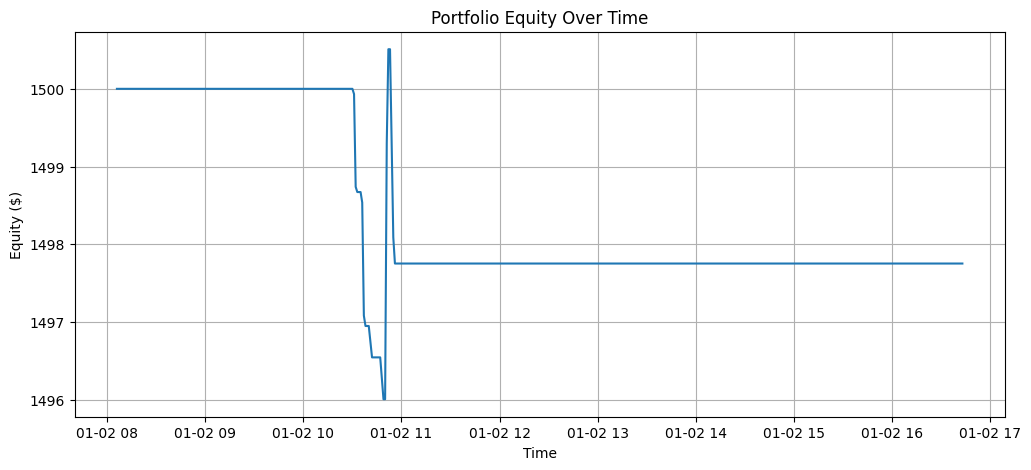

2026-01-02 | MAY22_DEFENSIVE | LOW_RISK | start $1,500.00 -> final $1,497.75 | global max $1,500.51


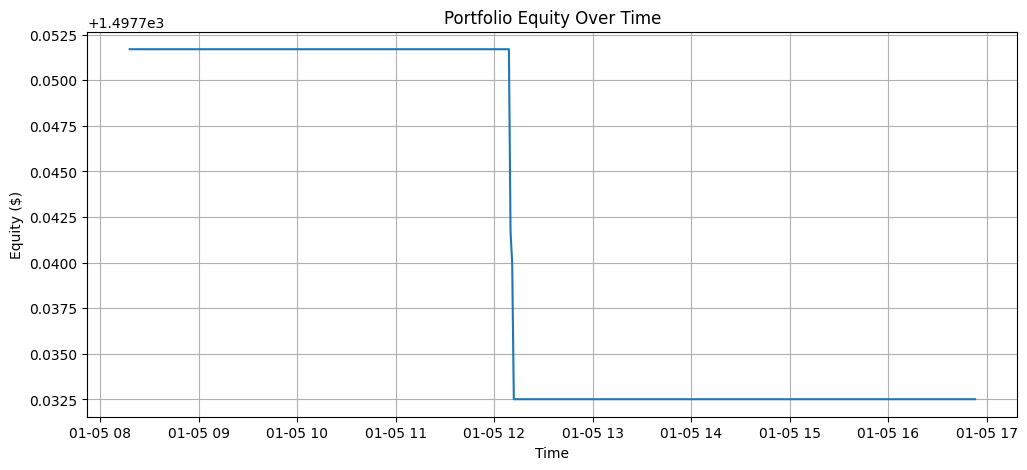

2026-01-05 | MAY22_DEFENSIVE | LOW_RISK | start $1,497.75 -> final $1,497.73 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

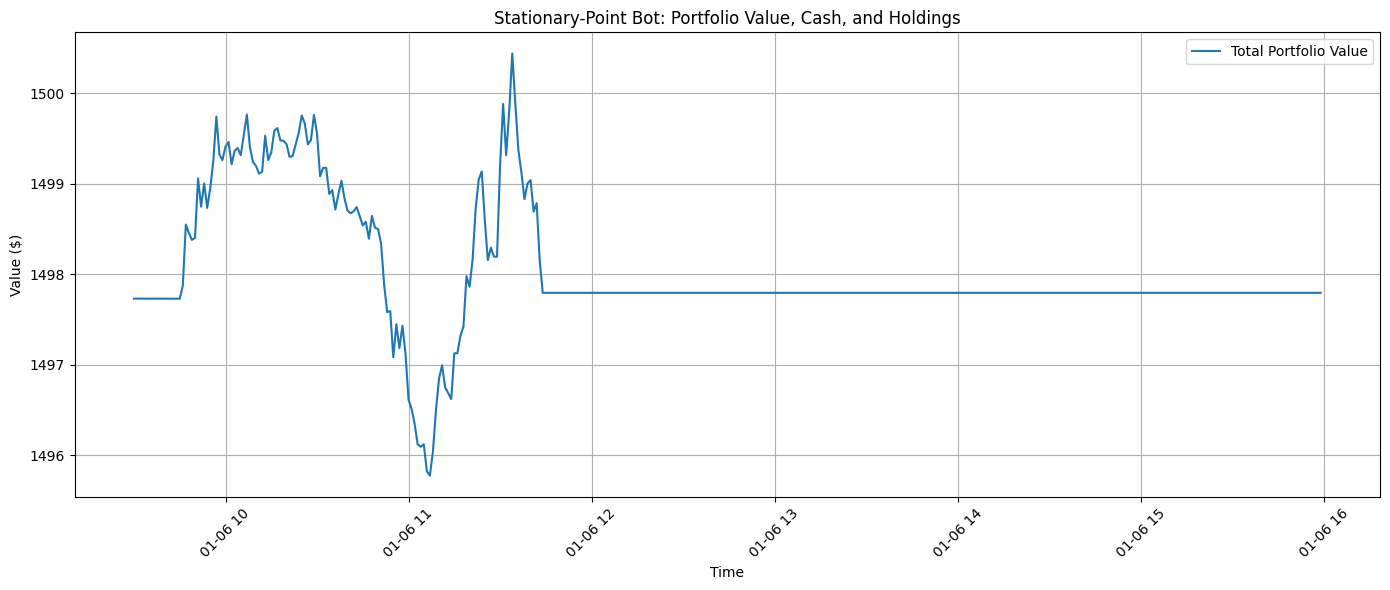

2026-01-06 | MAY21_AGGRESSIVE | CHOPPY | start $1,497.73 -> final $1,497.80 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-07_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-07_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-07_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-07_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

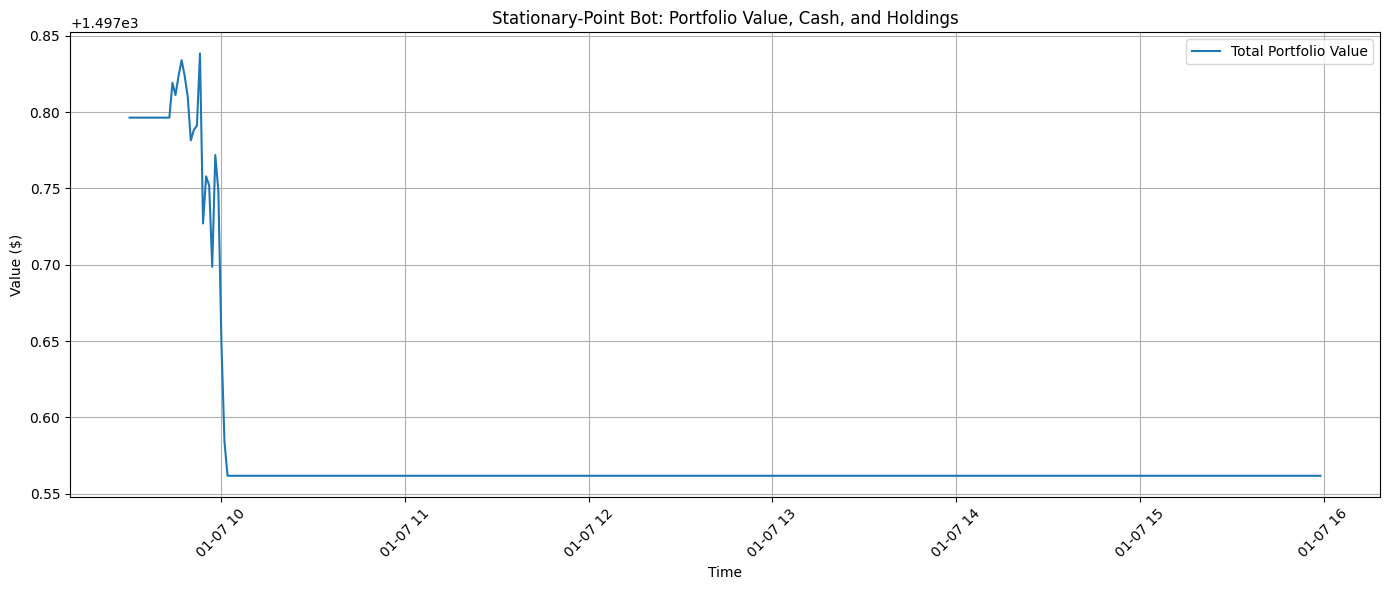

2026-01-07 | MAY21_AGGRESSIVE | LOW_RISK | start $1,497.80 -> final $1,497.56 | global max $1,500.51


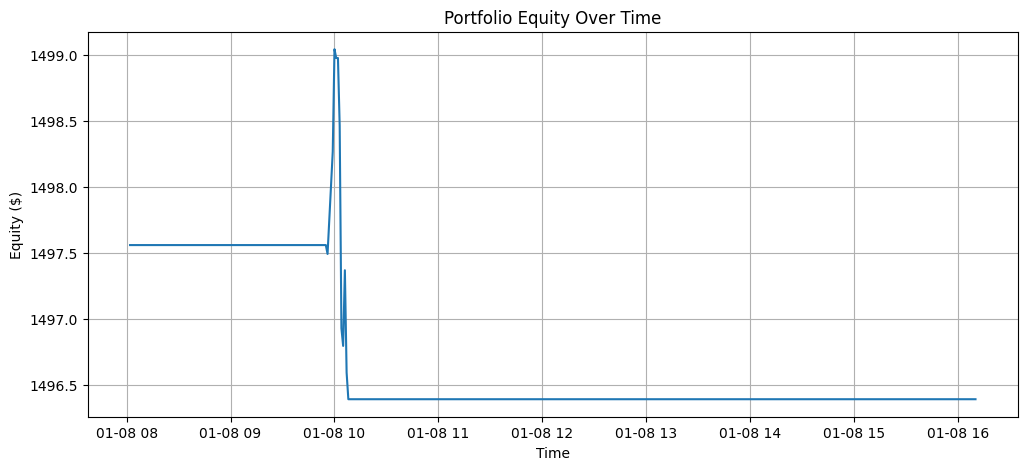

2026-01-08 | MAY22_DEFENSIVE | CHOPPY | start $1,497.56 -> final $1,496.39 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

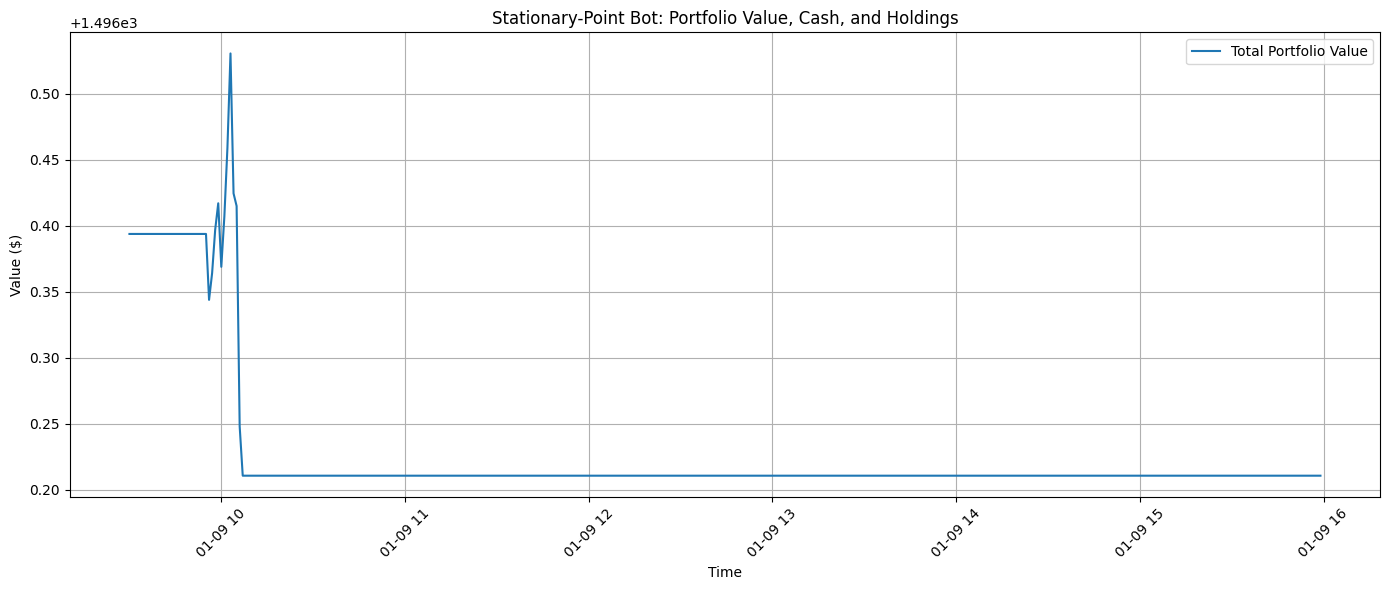

2026-01-09 | MAY21_AGGRESSIVE | LOW_RISK | start $1,496.39 -> final $1,496.21 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-12_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-12_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-12_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-12_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

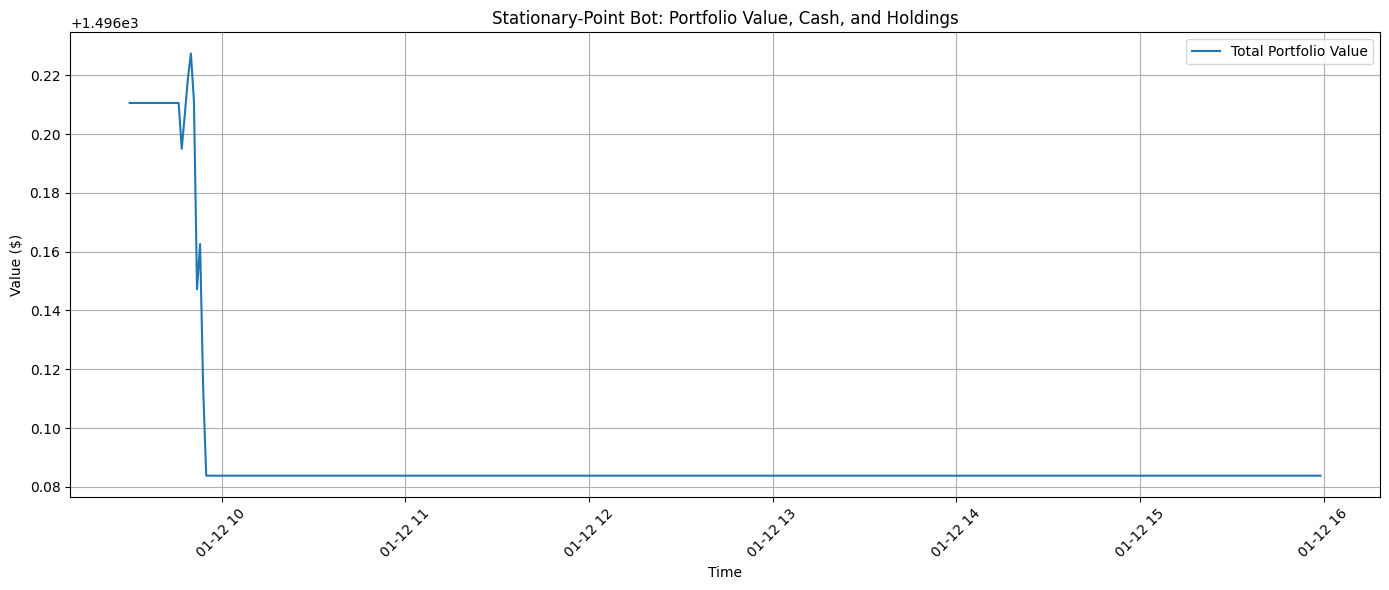

2026-01-12 | MAY21_AGGRESSIVE | LOW_RISK | start $1,496.21 -> final $1,496.08 | global max $1,500.51
2026-01-13 | NO_TRADE | NO_TRADE | start $1,496.08 -> final $1,496.08 | global max $1,500.51
2026-01-14 | NO_TRADE | NO_TRADE | start $1,496.08 -> final $1,496.08 | global max $1,500.51
2026-01-15 | NO_TRADE | NO_TRADE | start $1,496.08 -> final $1,496.08 | global max $1,500.51


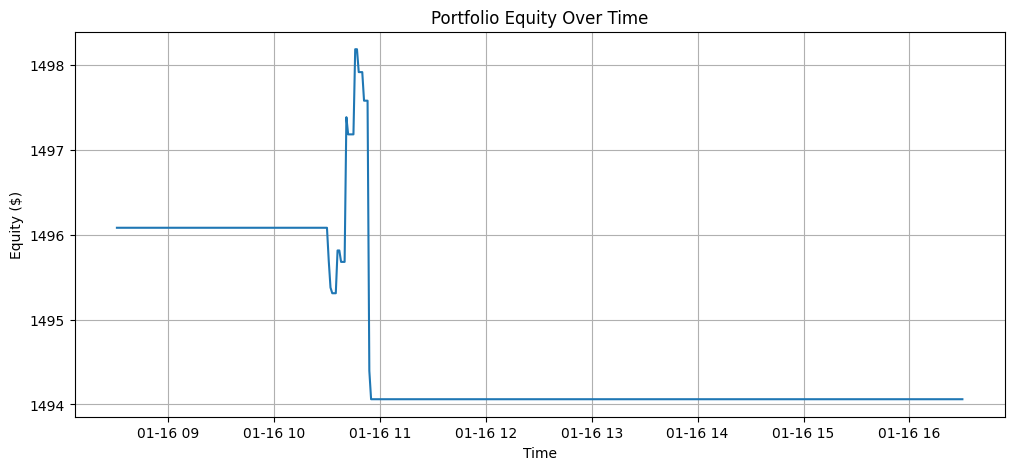

2026-01-16 | MAY22_DEFENSIVE | LOW_RISK | start $1,496.08 -> final $1,494.06 | global max $1,500.51
2026-01-19 | NO_TRADE | NO_TRADE | start $1,494.06 -> final $1,494.06 | global max $1,500.51
2026-01-20 | NO_TRADE | NO_TRADE | start $1,494.06 -> final $1,494.06 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-21_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-21_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-21_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-21_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

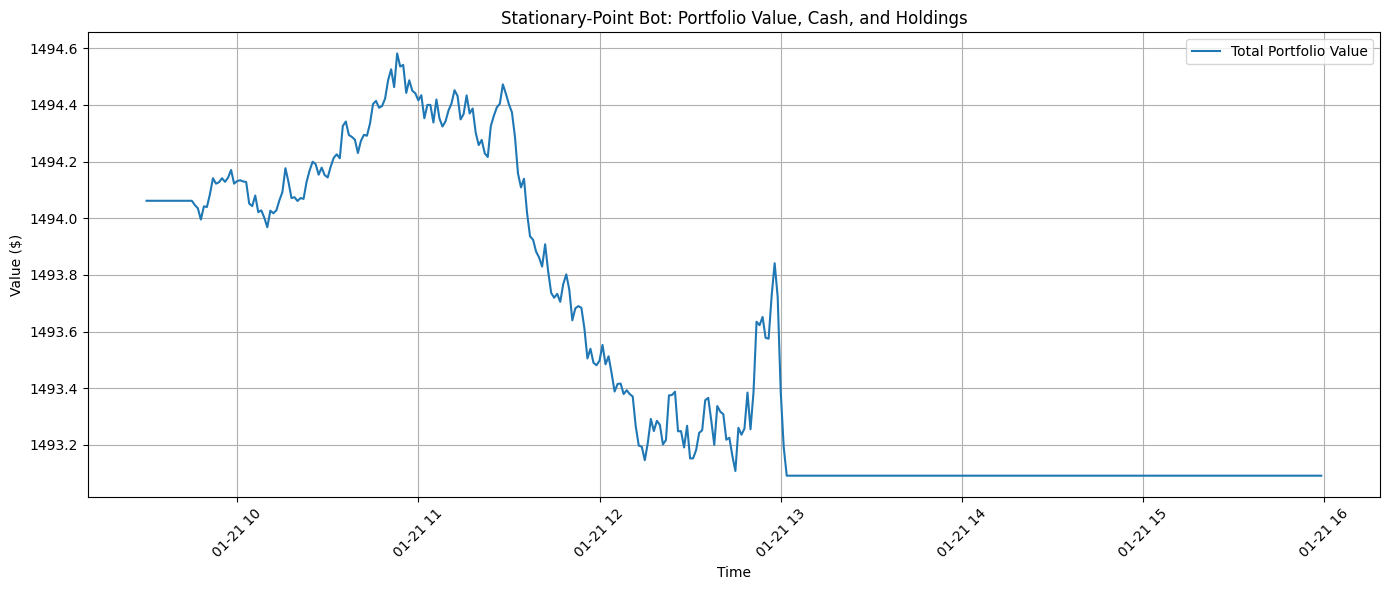

2026-01-21 | MAY21_AGGRESSIVE | LOW_RISK | start $1,494.06 -> final $1,493.09 | global max $1,500.51


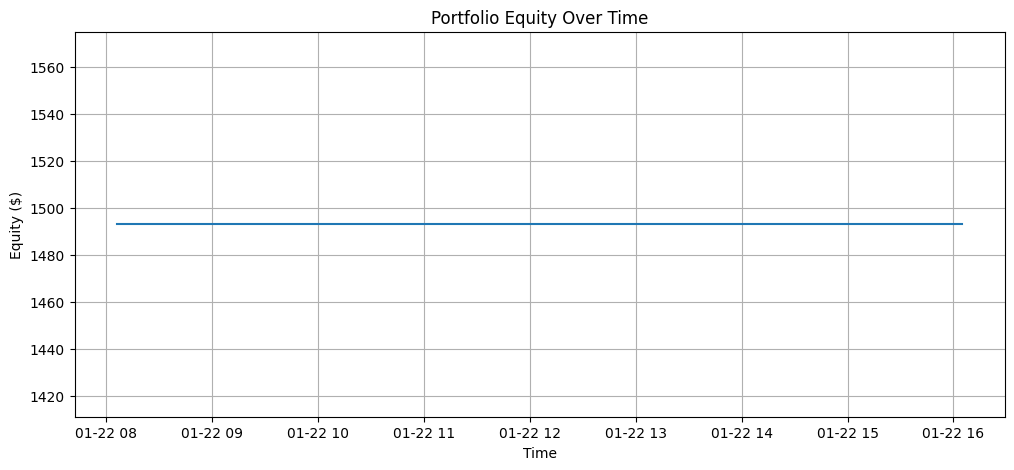

2026-01-22 | MAY22_DEFENSIVE | CHOPPY | start $1,493.09 -> final $1,493.09 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

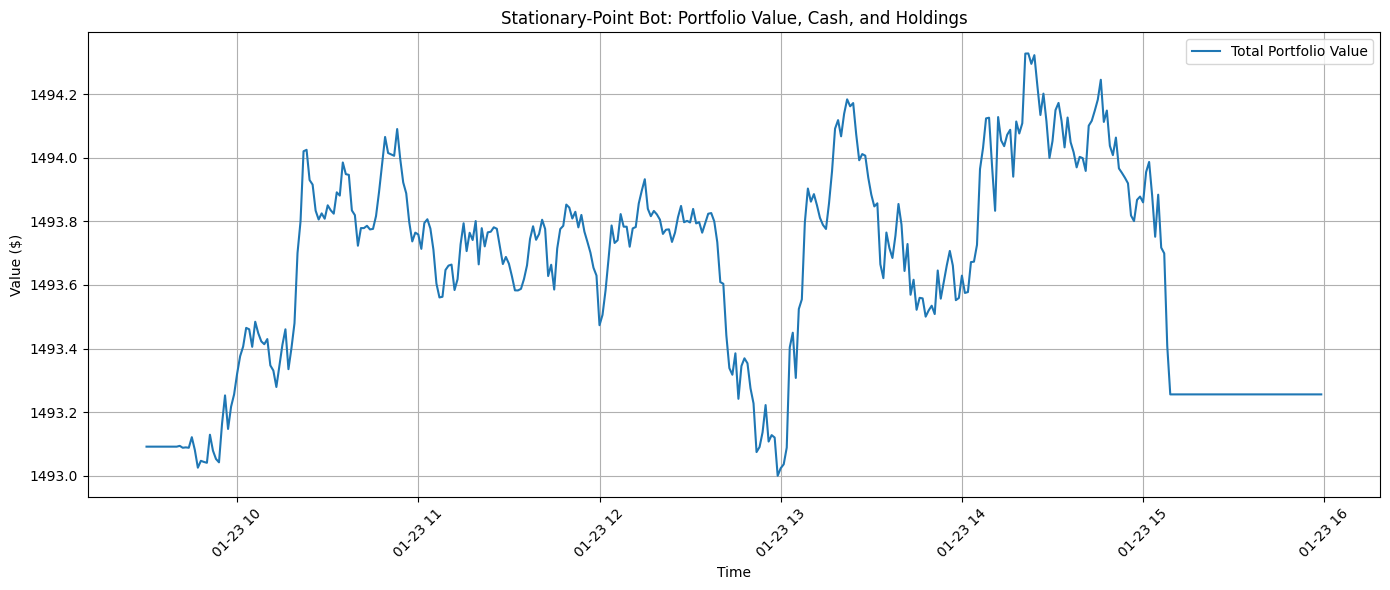

2026-01-23 | MAY21_AGGRESSIVE | LOW_RISK | start $1,493.09 -> final $1,493.26 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-26_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-26_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-26_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-26_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

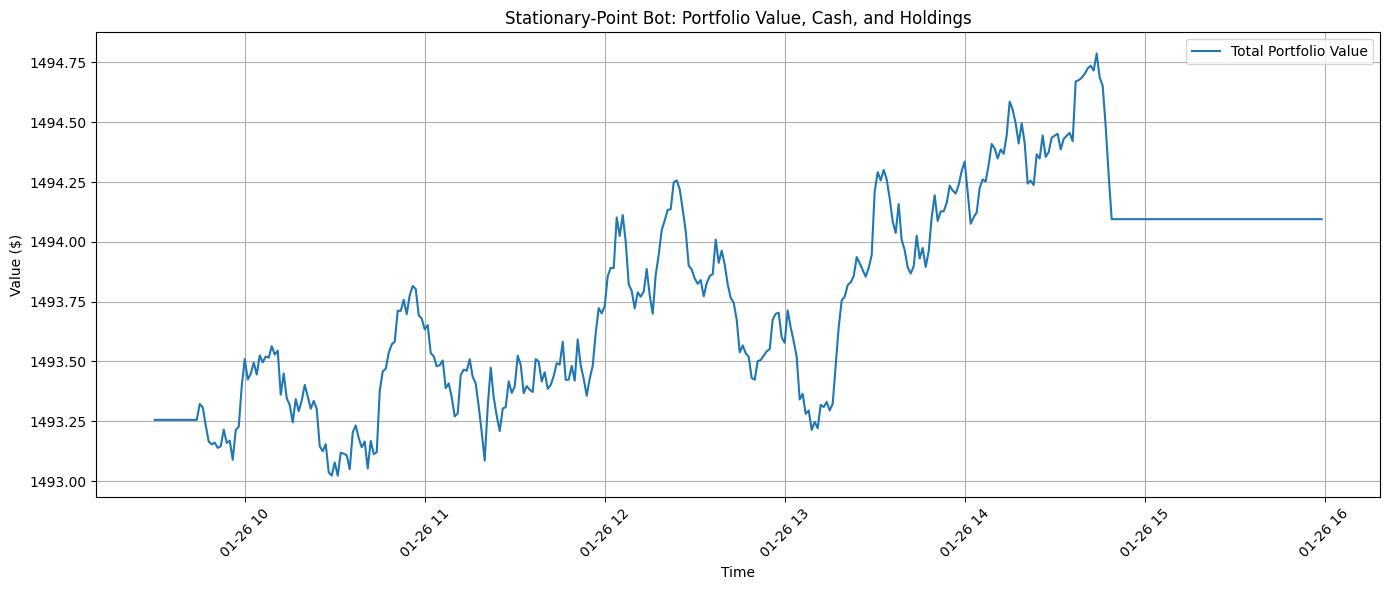

2026-01-26 | MAY21_AGGRESSIVE | LOW_RISK | start $1,493.26 -> final $1,494.09 | global max $1,500.51


<MAY21_AGGRESSIVE_2026-01-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

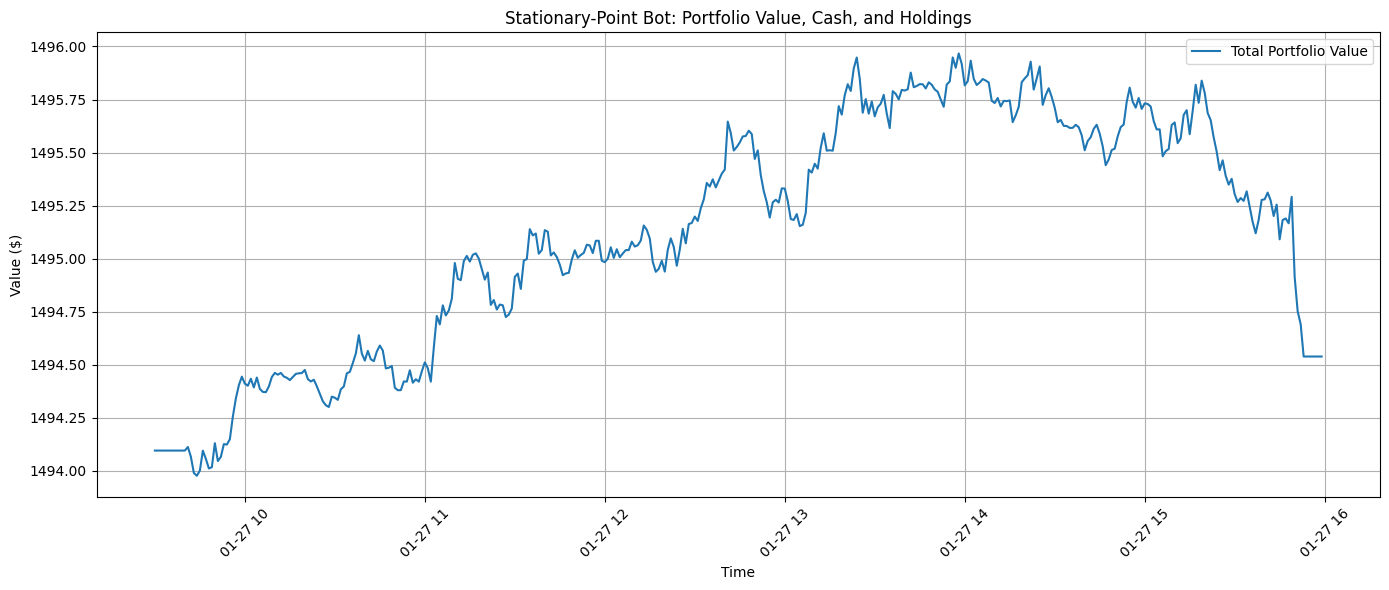

2026-01-27 | MAY21_AGGRESSIVE | LOW_RISK | start $1,494.09 -> final $1,494.54 | global max $1,500.51
2026-01-28 | NO_TRADE | NO_TRADE | start $1,494.54 -> final $1,494.54 | global max $1,500.51


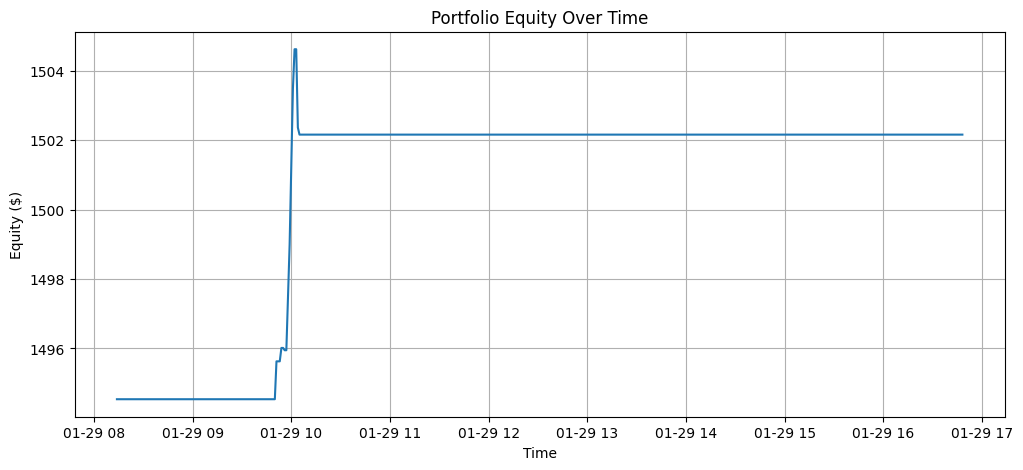

2026-01-29 | MAY22_DEFENSIVE | CHOPPY | start $1,494.54 -> final $1,502.16 | global max $1,504.62


<MAY21_AGGRESSIVE_2026-01-30_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-30_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-30_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-01-30_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

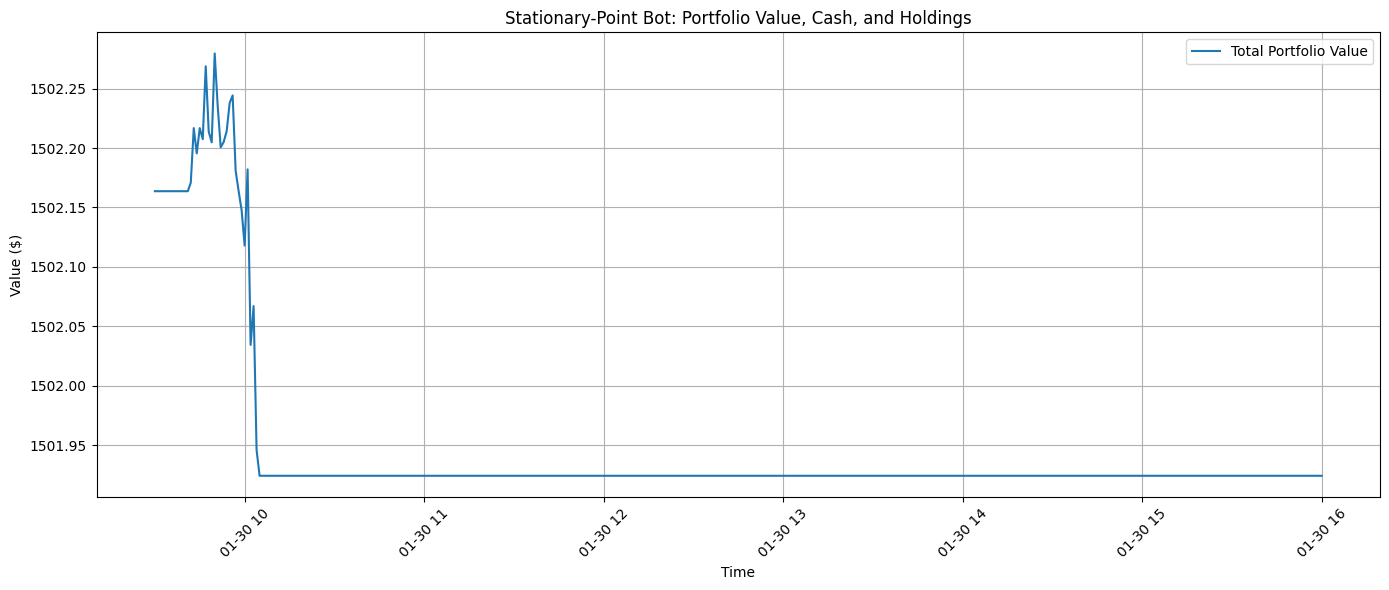

2026-01-30 | MAY21_AGGRESSIVE | LOW_RISK | start $1,502.16 -> final $1,501.92 | global max $1,504.62


<MAY21_AGGRESSIVE_2026-02-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

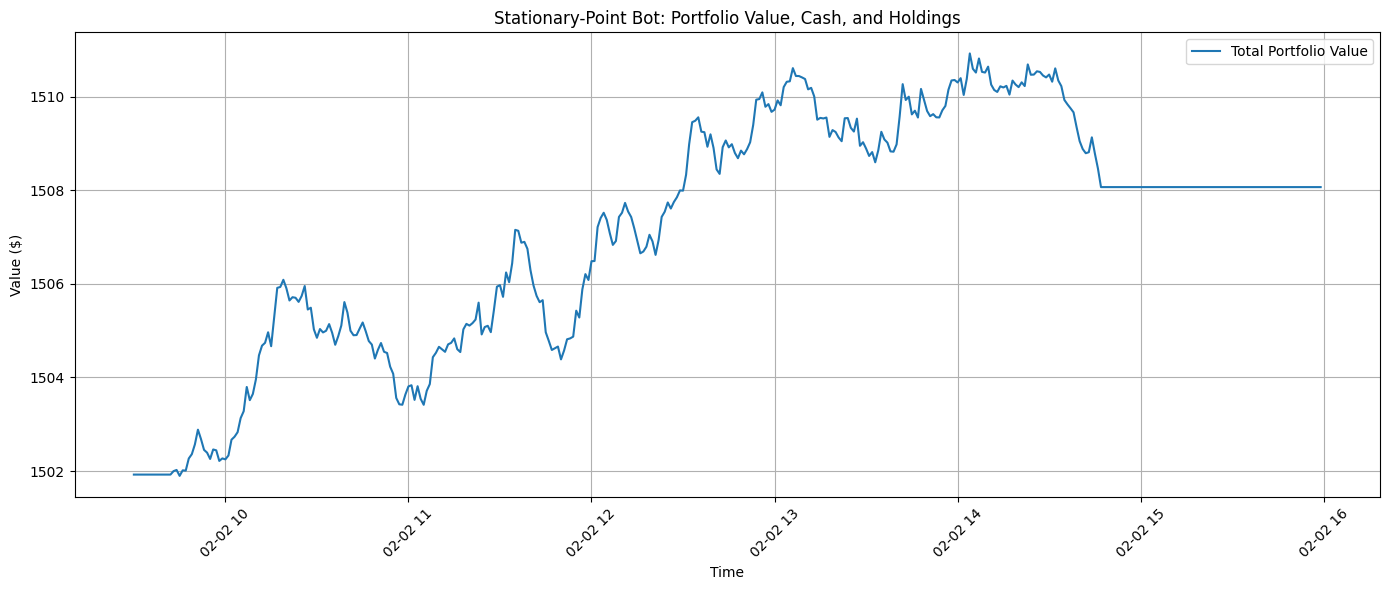

2026-02-02 | MAY21_AGGRESSIVE | CHOPPY | start $1,501.92 -> final $1,508.07 | global max $1,510.92


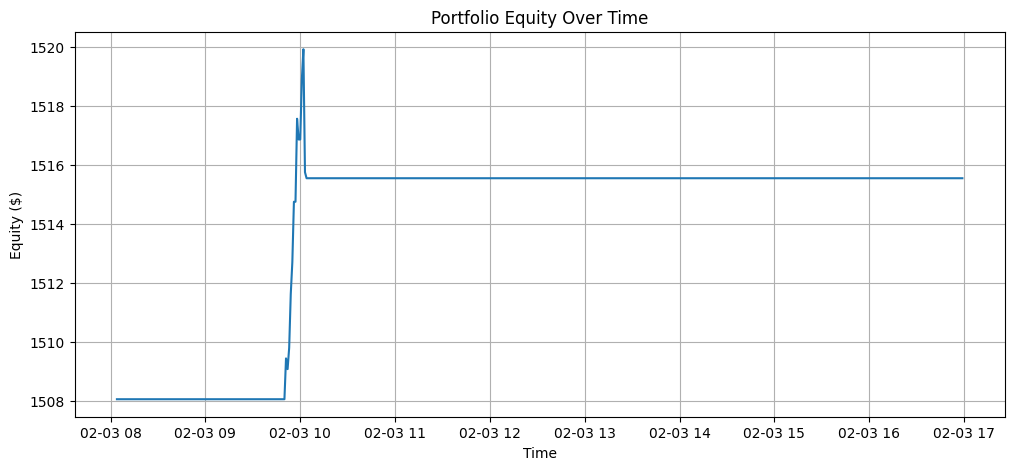

2026-02-03 | MAY22_DEFENSIVE | LOW_RISK | start $1,508.07 -> final $1,515.56 | global max $1,519.93


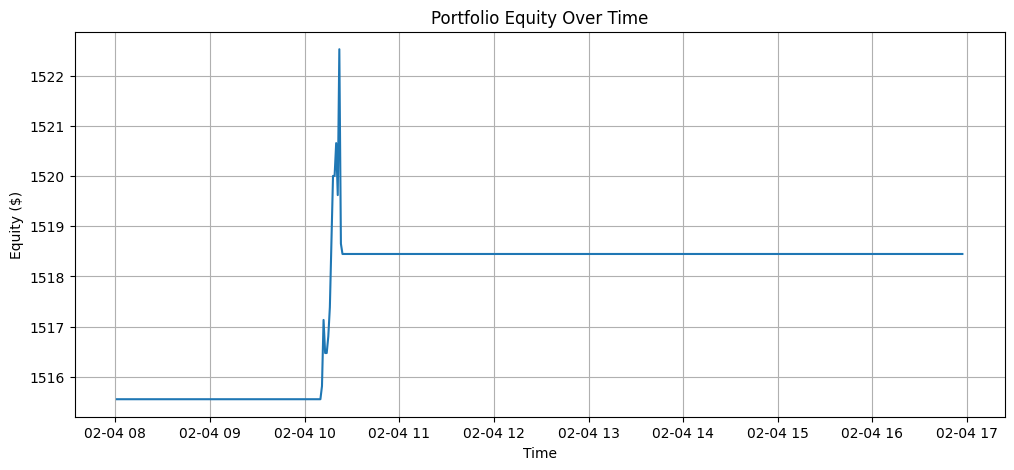

2026-02-04 | MAY22_DEFENSIVE | LOW_RISK | start $1,515.56 -> final $1,518.45 | global max $1,522.52


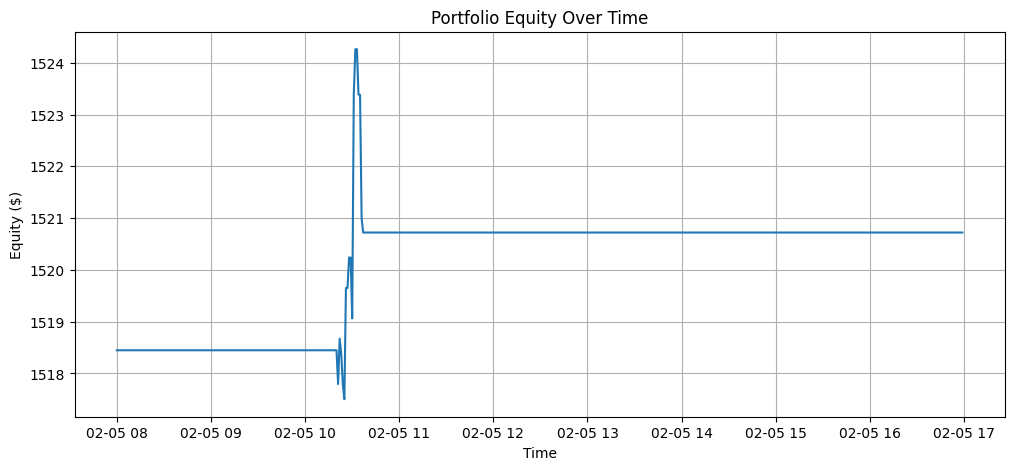

2026-02-05 | MAY22_DEFENSIVE | LOW_RISK | start $1,518.45 -> final $1,520.72 | global max $1,524.26
2026-02-06 | NO_TRADE | NO_TRADE | start $1,520.72 -> final $1,520.72 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

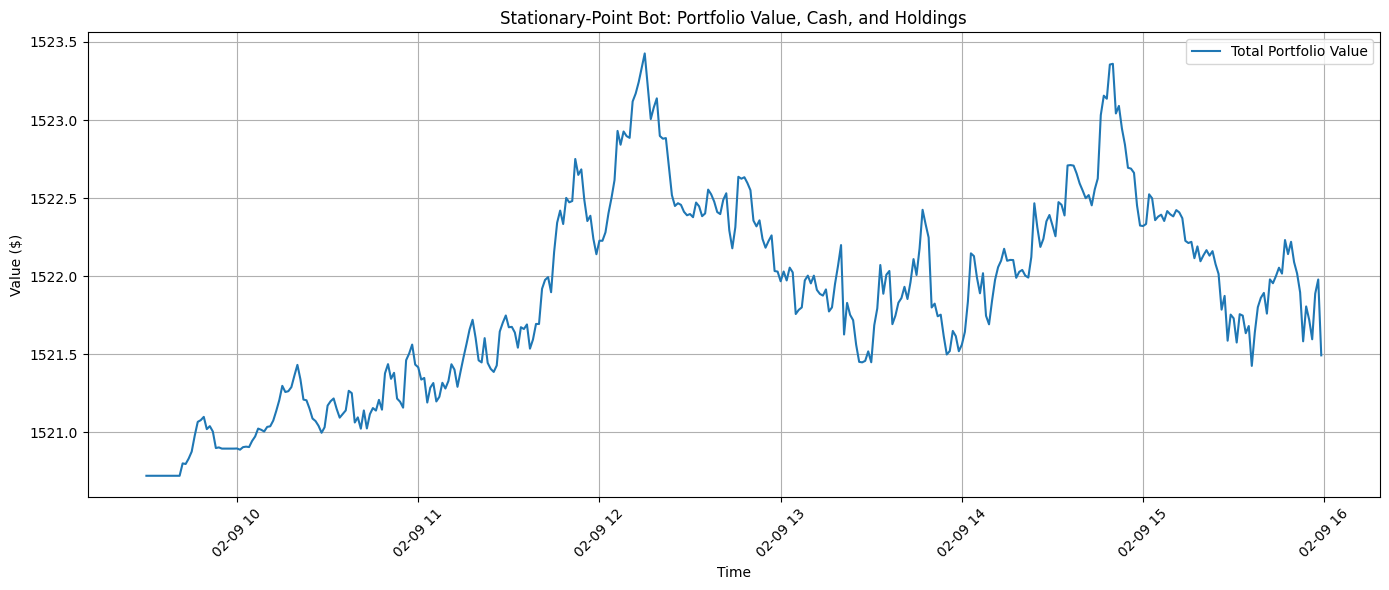

2026-02-09 | MAY21_AGGRESSIVE | LOW_RISK | start $1,520.72 -> final $1,521.49 | global max $1,524.26


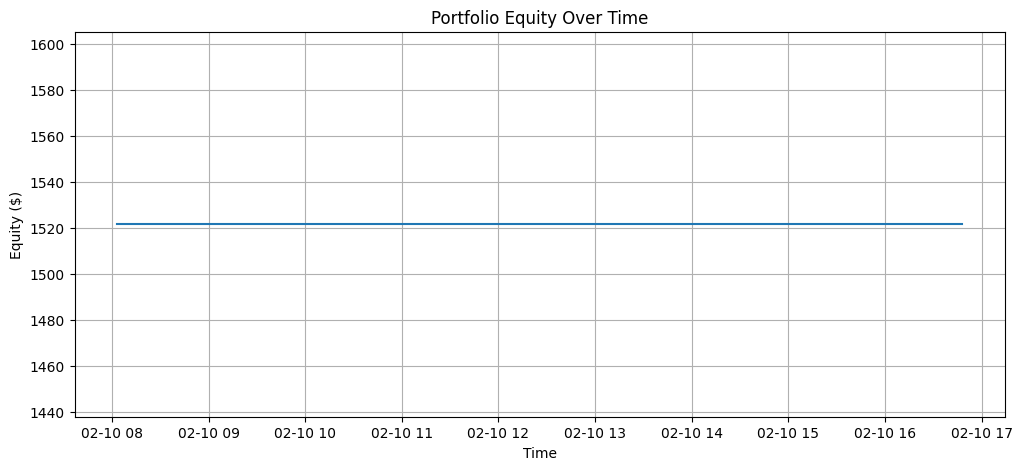

2026-02-10 | MAY22_DEFENSIVE | LOW_RISK | start $1,521.49 -> final $1,521.49 | global max $1,524.26


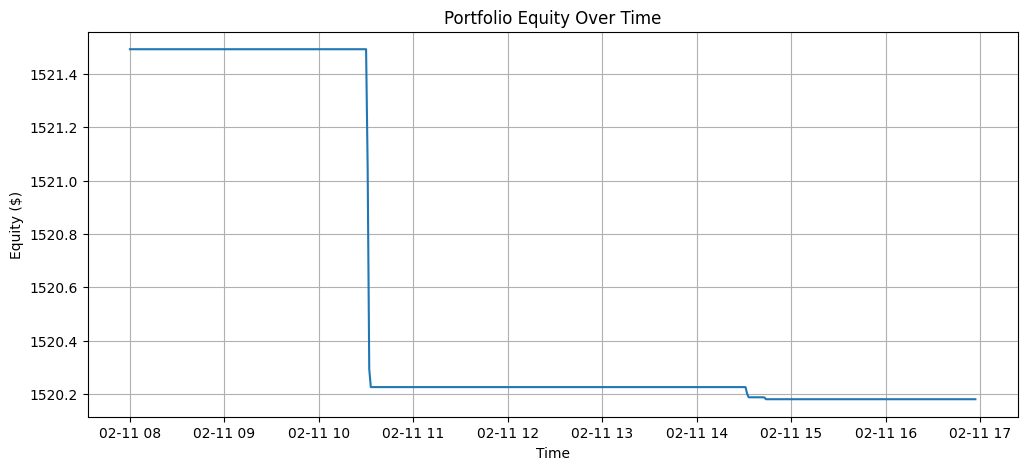

2026-02-11 | MAY22_DEFENSIVE | LOW_RISK | start $1,521.49 -> final $1,520.18 | global max $1,524.26


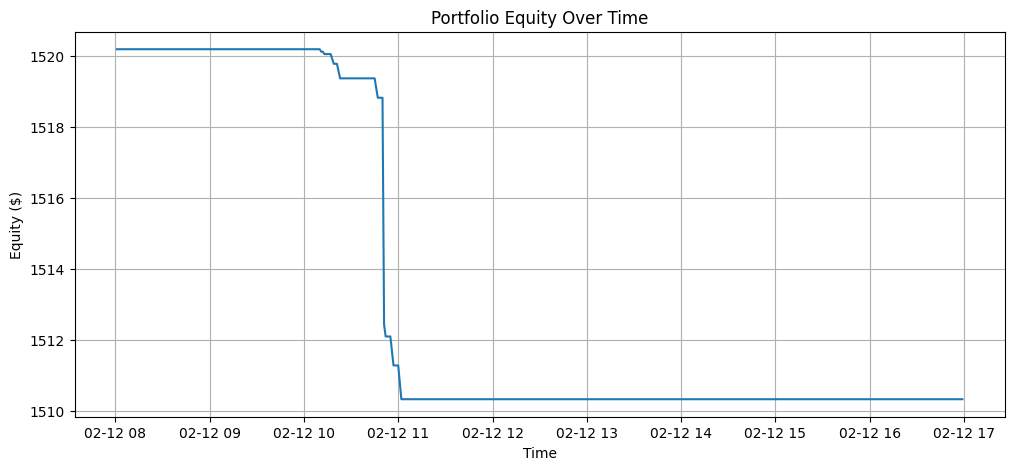

2026-02-12 | MAY22_DEFENSIVE | LOW_RISK | start $1,520.18 -> final $1,510.32 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-13_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-13_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-13_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-13_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

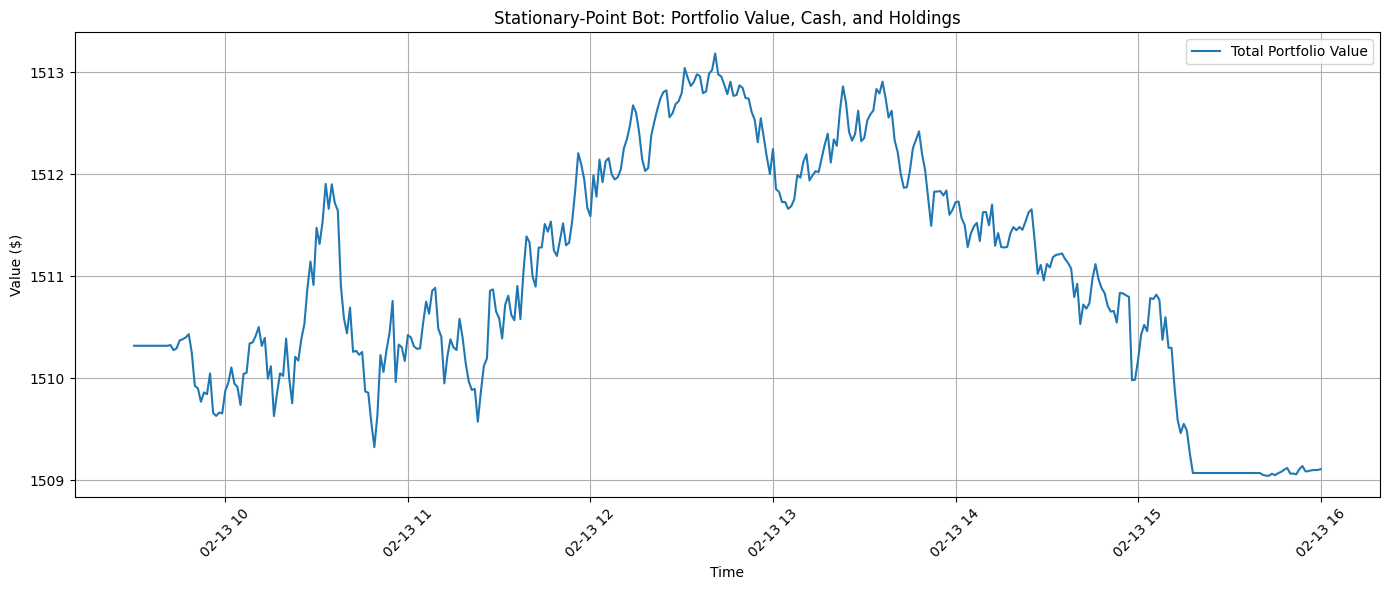

2026-02-13 | MAY21_AGGRESSIVE | LOW_RISK | start $1,510.32 -> final $1,509.11 | global max $1,524.26
2026-02-16 | NO_TRADE | NO_TRADE | start $1,509.11 -> final $1,509.11 | global max $1,524.26


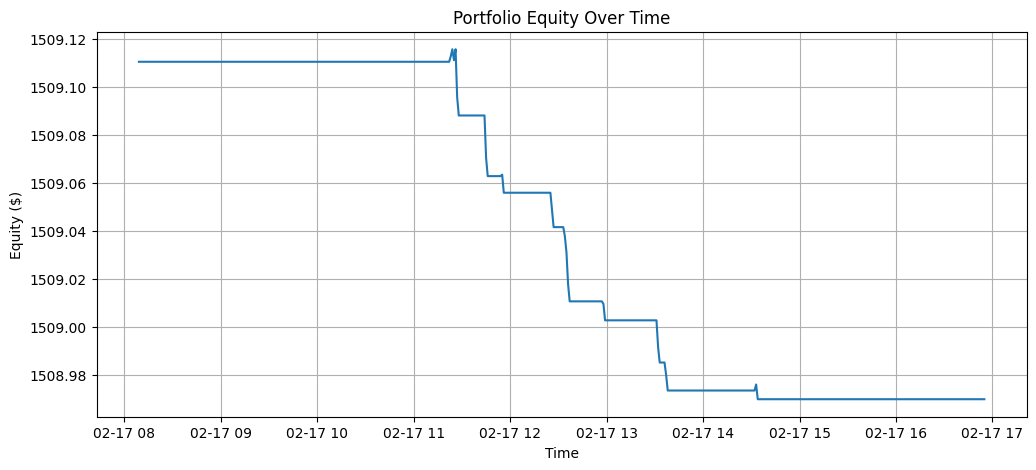

2026-02-17 | MAY22_DEFENSIVE | LOW_RISK | start $1,509.11 -> final $1,508.97 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-18_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-18_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-18_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-18_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

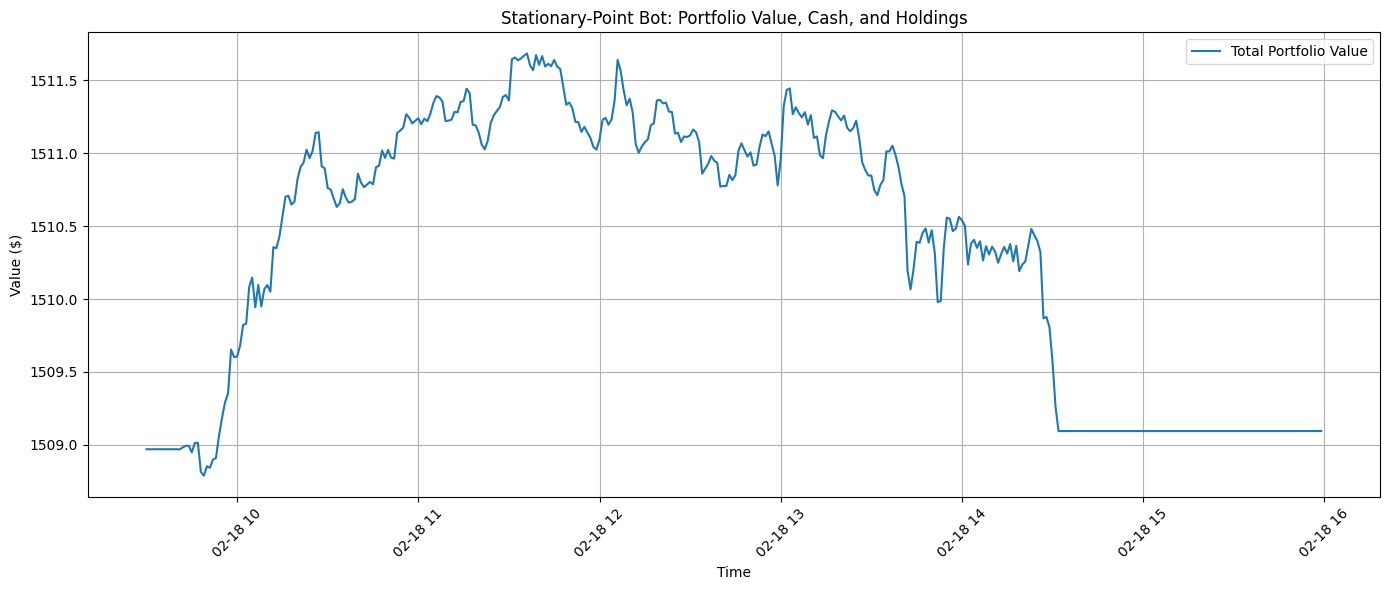

2026-02-18 | MAY21_AGGRESSIVE | LOW_RISK | start $1,508.97 -> final $1,509.09 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

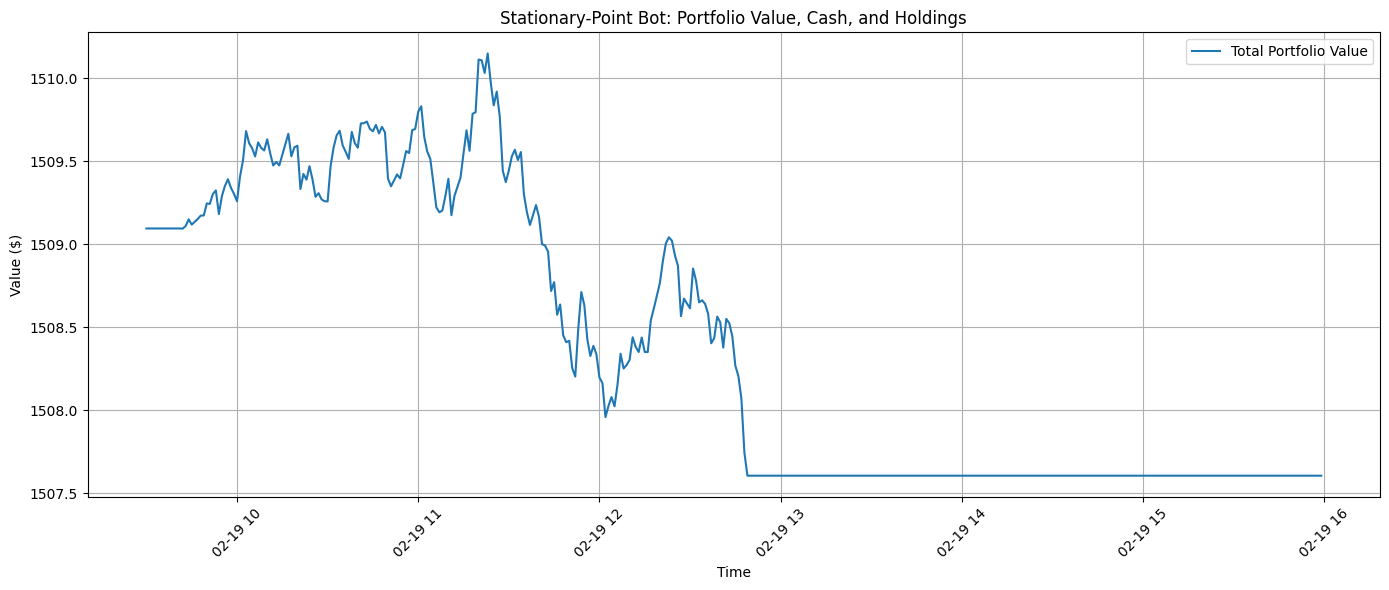

2026-02-19 | MAY21_AGGRESSIVE | LOW_RISK | start $1,509.09 -> final $1,507.61 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-20_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-20_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-20_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-20_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

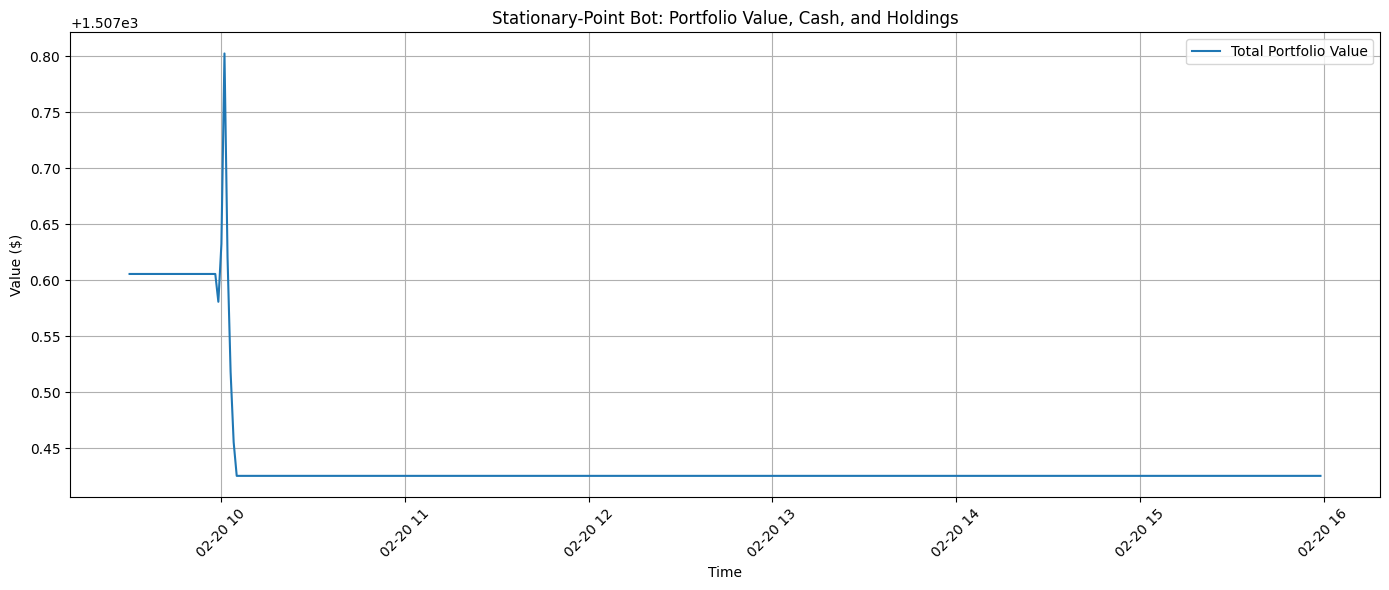

2026-02-20 | MAY21_AGGRESSIVE | LOW_RISK | start $1,507.61 -> final $1,507.43 | global max $1,524.26


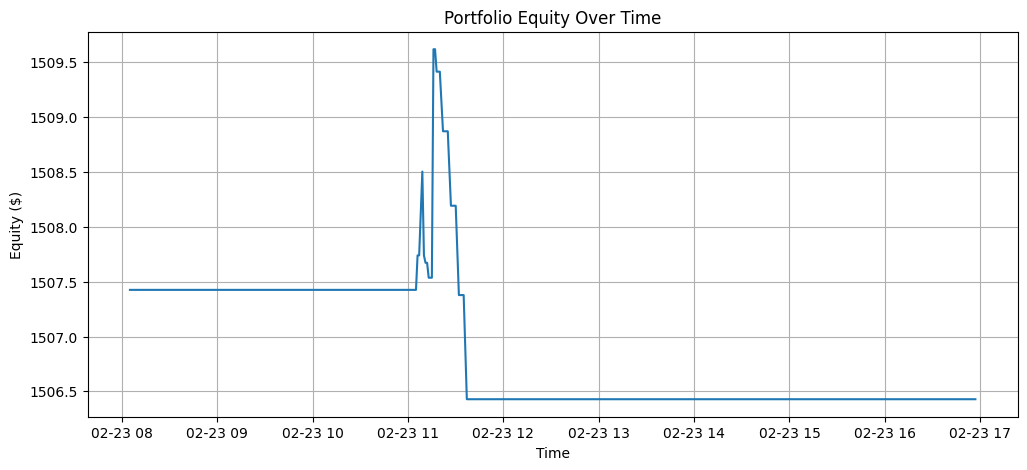

2026-02-23 | MAY22_DEFENSIVE | LOW_RISK | start $1,507.43 -> final $1,506.43 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-24_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-24_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-24_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-24_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

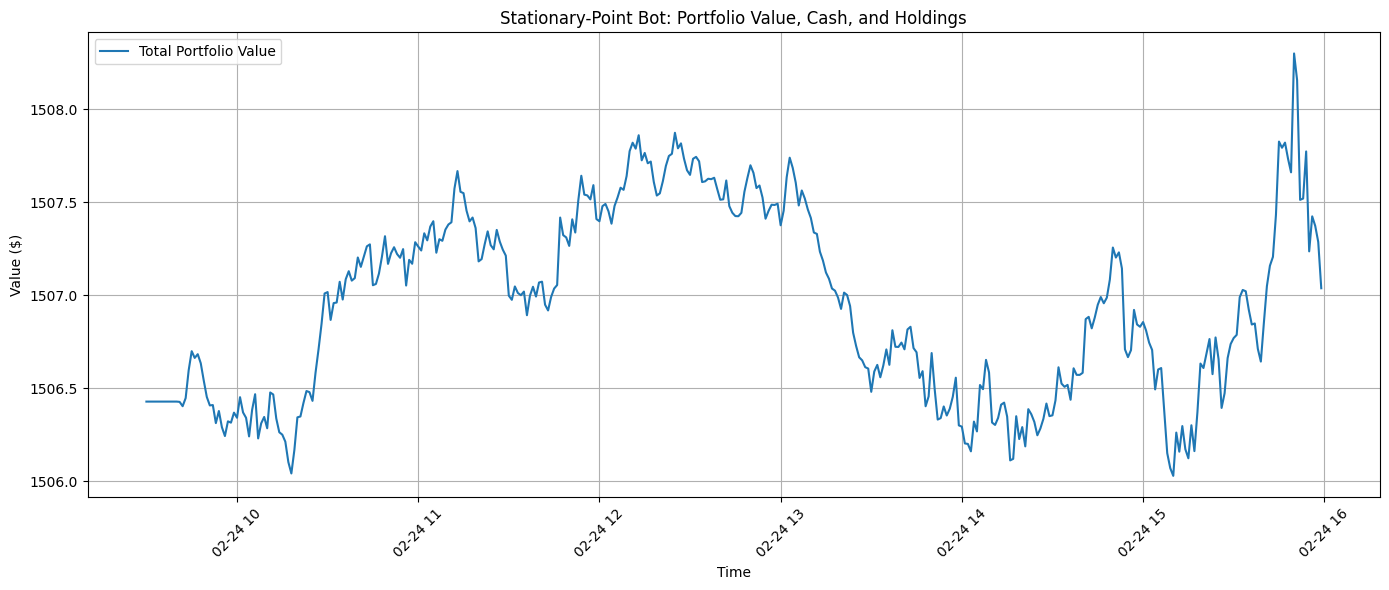

2026-02-24 | MAY21_AGGRESSIVE | LOW_RISK | start $1,506.43 -> final $1,507.04 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-25_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-25_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-25_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-25_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

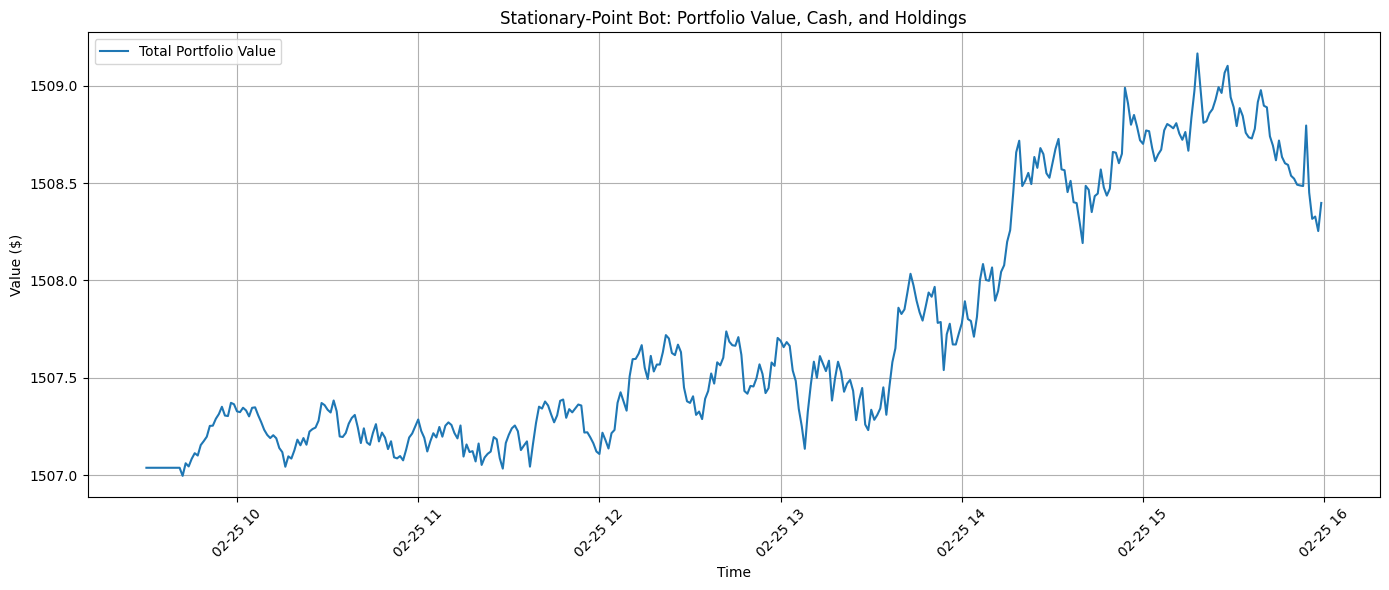

2026-02-25 | MAY21_AGGRESSIVE | LOW_RISK | start $1,507.04 -> final $1,508.40 | global max $1,524.26


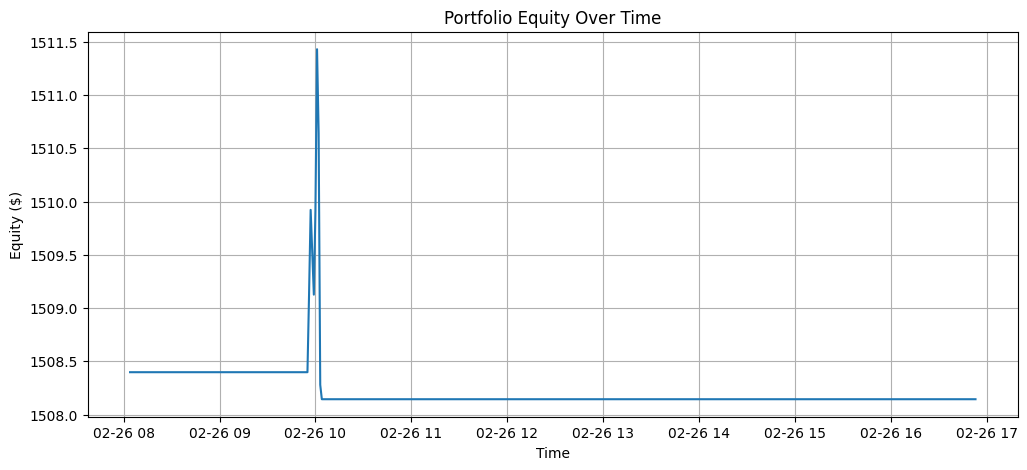

2026-02-26 | MAY22_DEFENSIVE | LOW_RISK | start $1,508.40 -> final $1,508.14 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-02-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-02-27_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

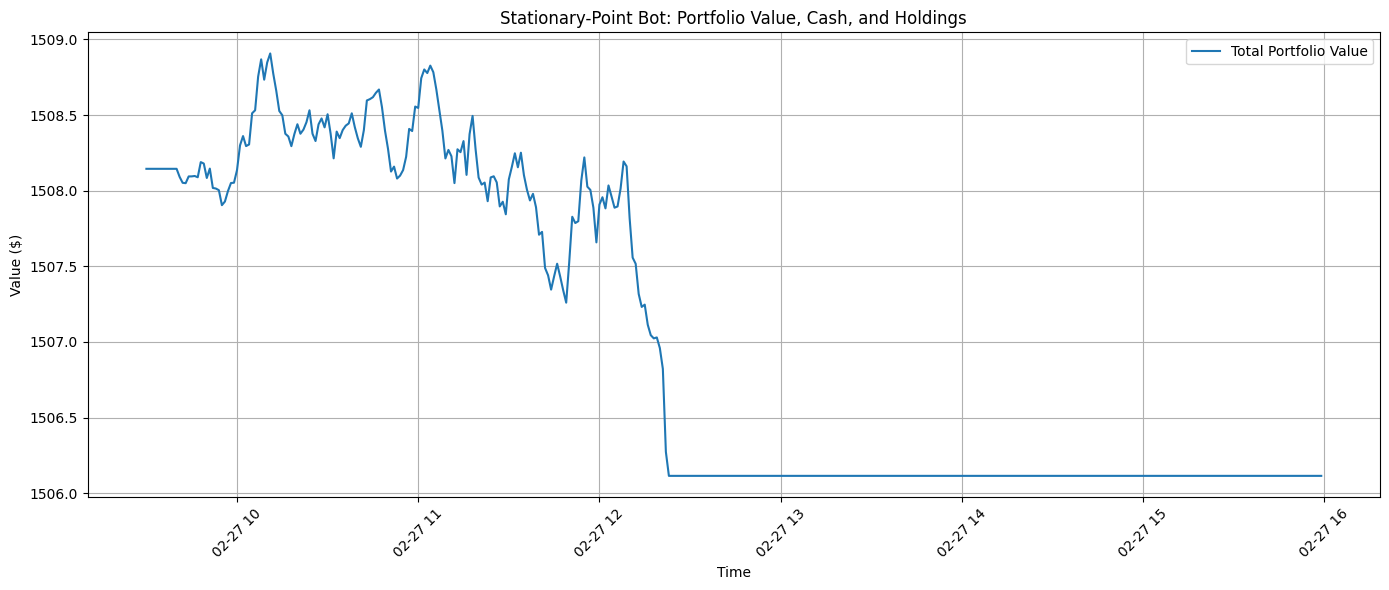

2026-02-27 | MAY21_AGGRESSIVE | LOW_RISK | start $1,508.14 -> final $1,506.11 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-02_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

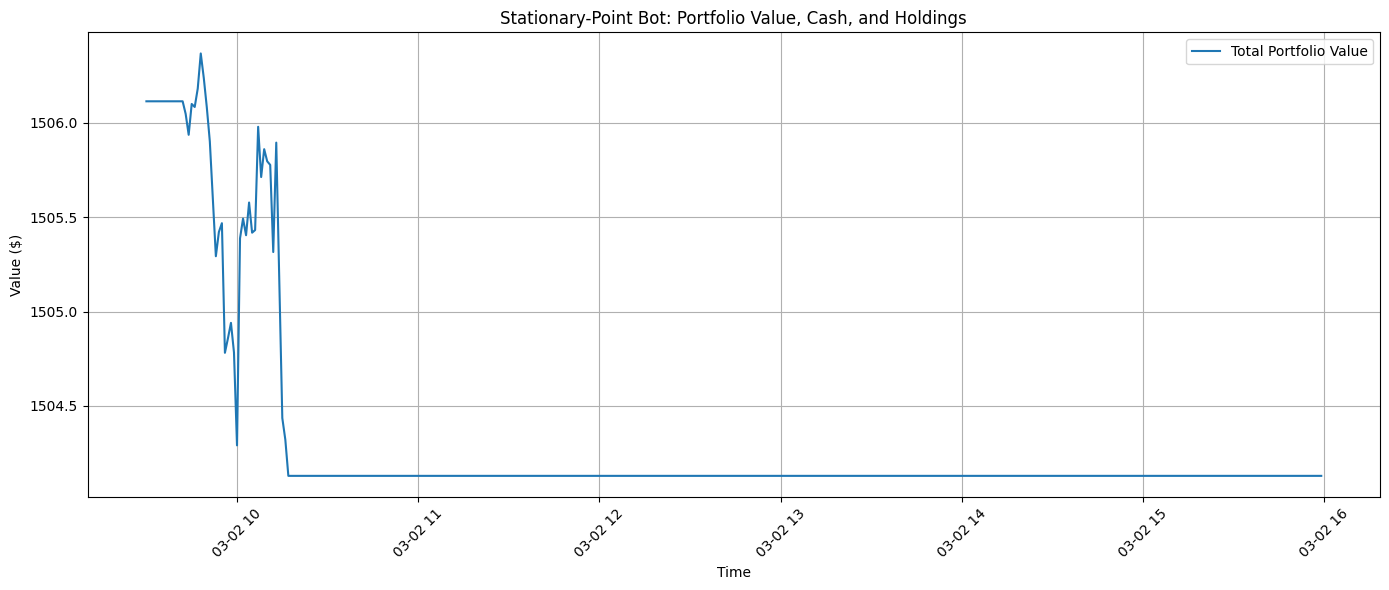

2026-03-02 | MAY21_AGGRESSIVE | CHOPPY | start $1,506.11 -> final $1,504.13 | global max $1,524.26
2026-03-03 | NO_TRADE | NO_TRADE | start $1,504.13 -> final $1,504.13 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-04_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-04_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-04_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-04_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

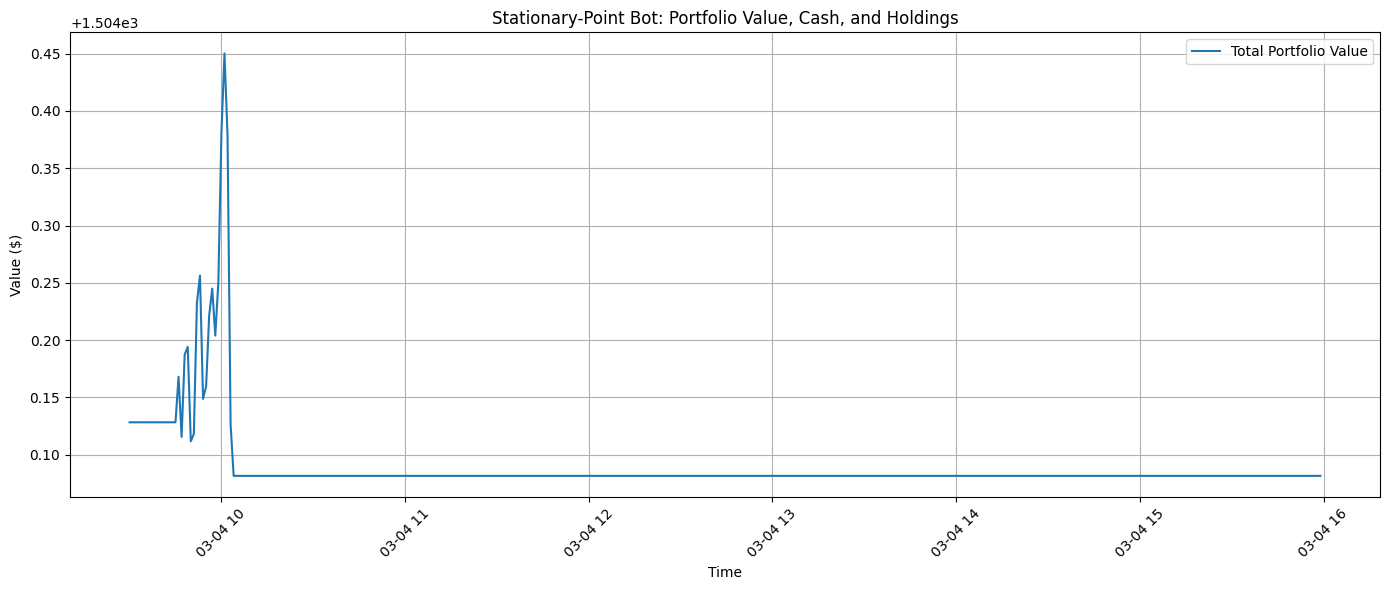

2026-03-04 | MAY21_AGGRESSIVE | LOW_RISK | start $1,504.13 -> final $1,504.08 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-05_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-05_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-05_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-05_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

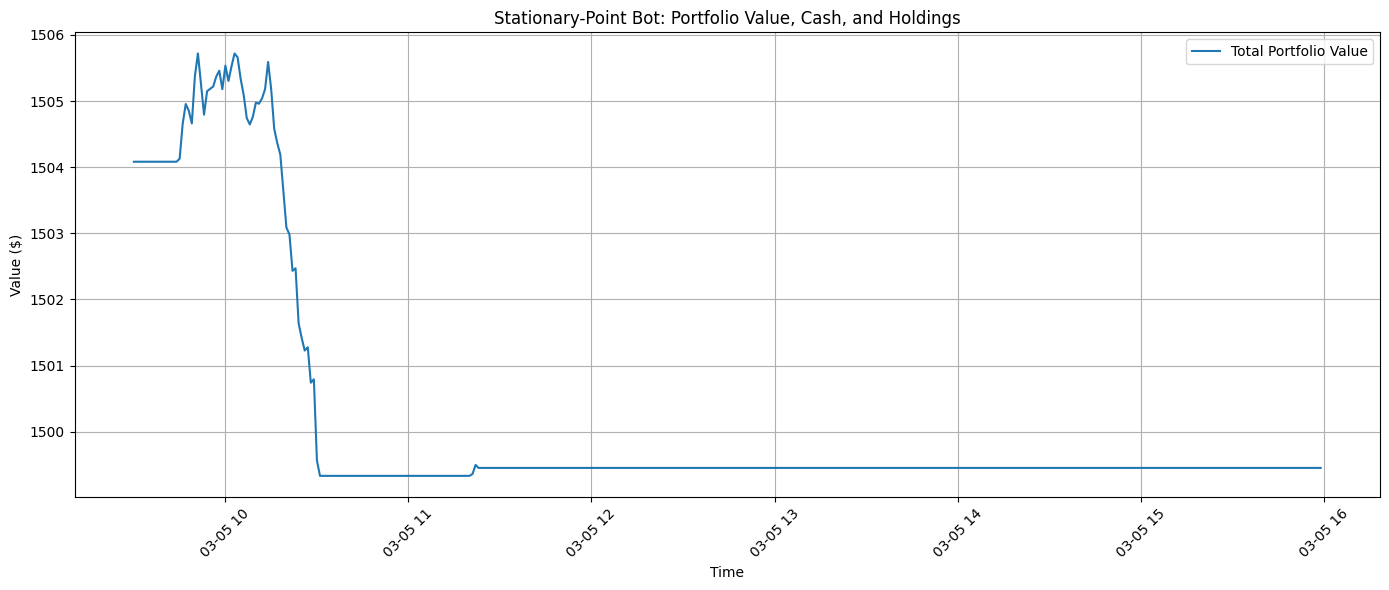

2026-03-05 | MAY21_AGGRESSIVE | CHOPPY | start $1,504.08 -> final $1,499.45 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-06_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

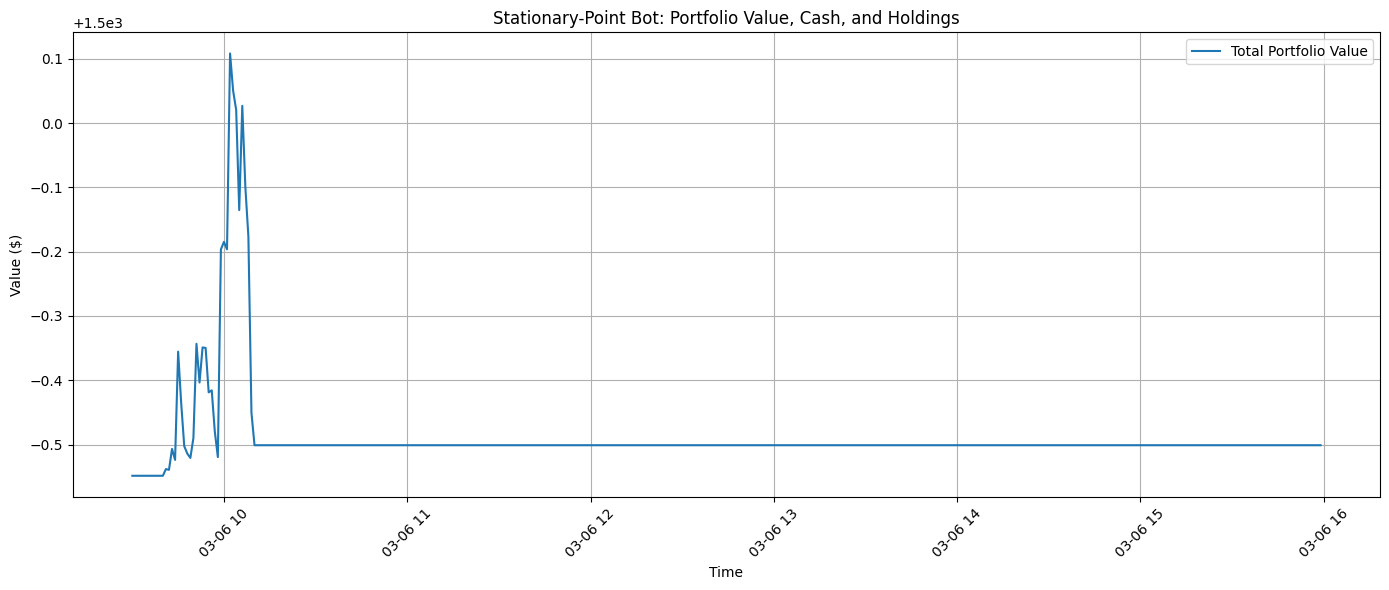

2026-03-06 | MAY21_AGGRESSIVE | LOW_RISK | start $1,499.45 -> final $1,499.50 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-09_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

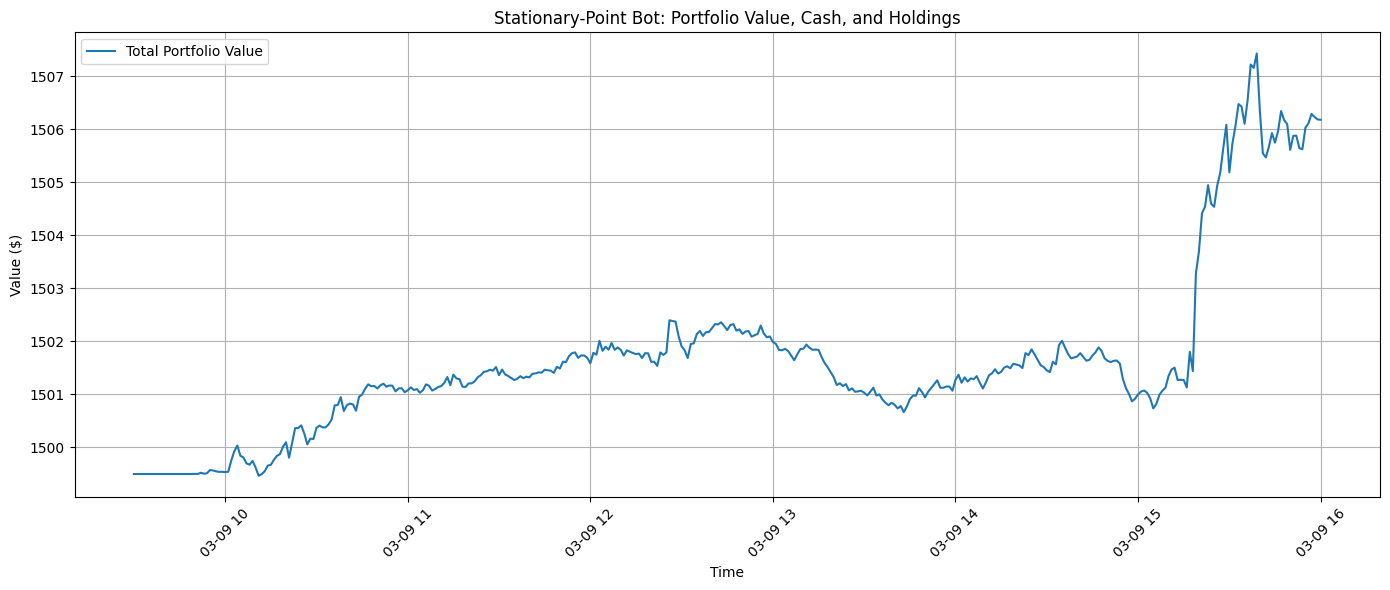

2026-03-09 | MAY21_AGGRESSIVE | LOW_RISK | start $1,499.50 -> final $1,506.18 | global max $1,524.26


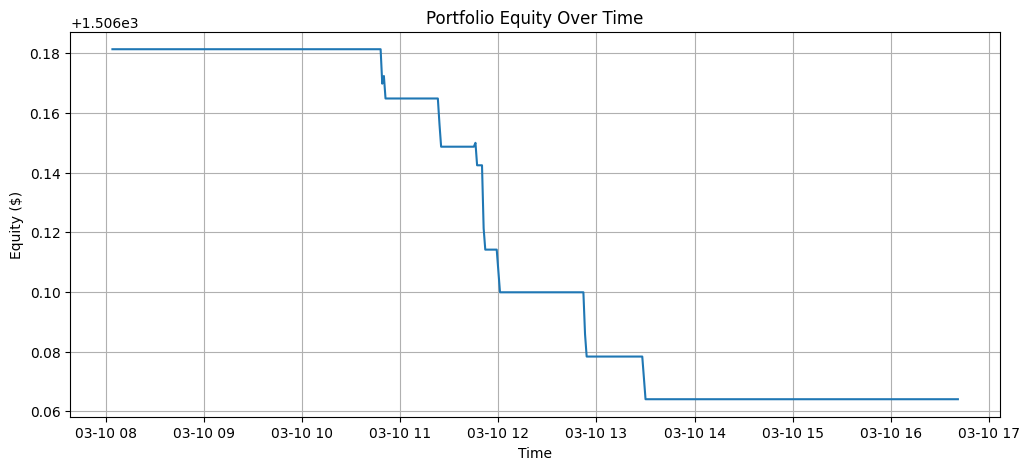

2026-03-10 | MAY22_DEFENSIVE | LOW_RISK | start $1,506.18 -> final $1,506.06 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-11_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-11_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-11_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-11_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

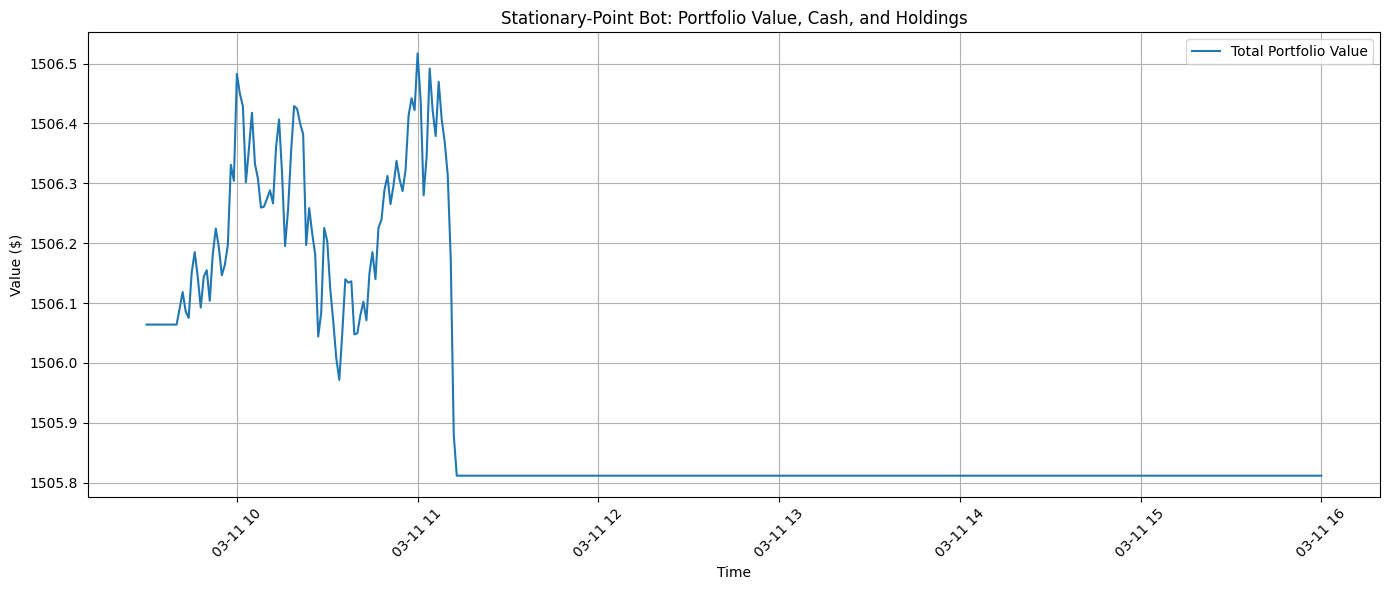

2026-03-11 | MAY21_AGGRESSIVE | LOW_RISK | start $1,506.06 -> final $1,505.81 | global max $1,524.26


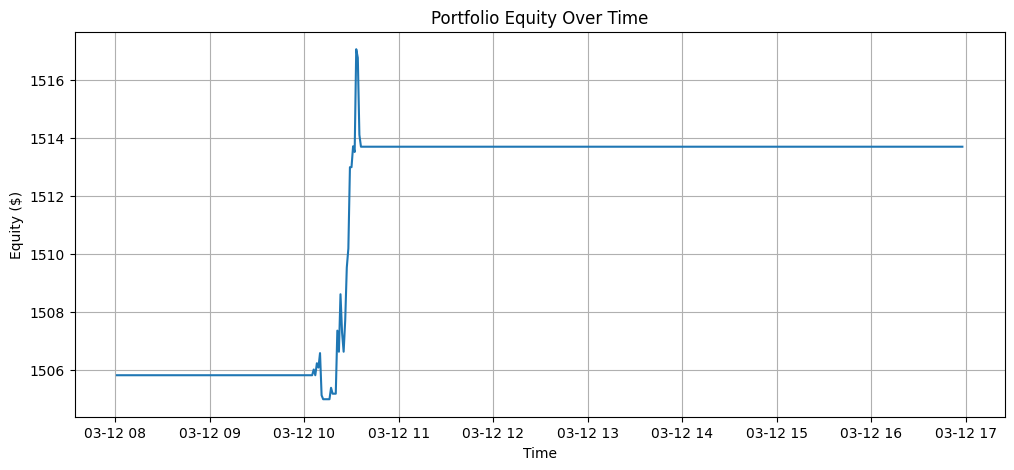

2026-03-12 | MAY22_DEFENSIVE | LOW_RISK | start $1,505.81 -> final $1,513.69 | global max $1,524.26
2026-03-13 | NO_TRADE | NO_TRADE | start $1,513.69 -> final $1,513.69 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-16_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-16_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-16_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-16_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

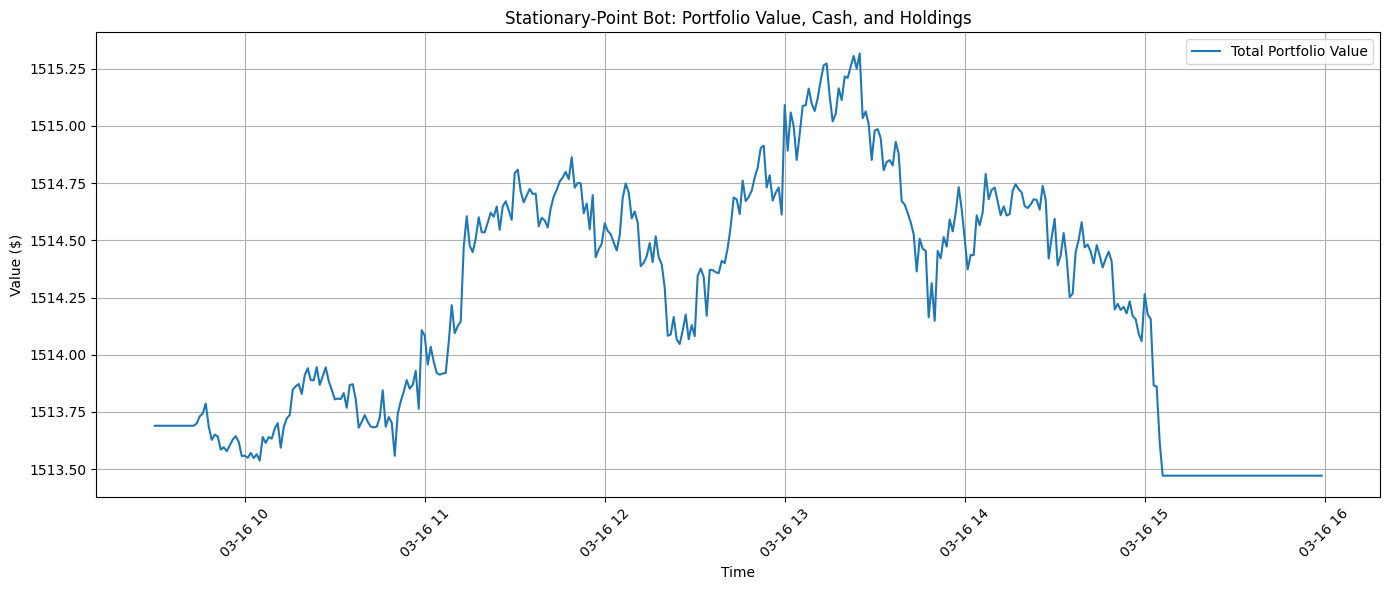

2026-03-16 | MAY21_AGGRESSIVE | LOW_RISK | start $1,513.69 -> final $1,513.47 | global max $1,524.26
2026-03-17 | NO_TRADE | NO_TRADE | start $1,513.47 -> final $1,513.47 | global max $1,524.26
2026-03-18 | NO_TRADE | NO_TRADE | start $1,513.47 -> final $1,513.47 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-19_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

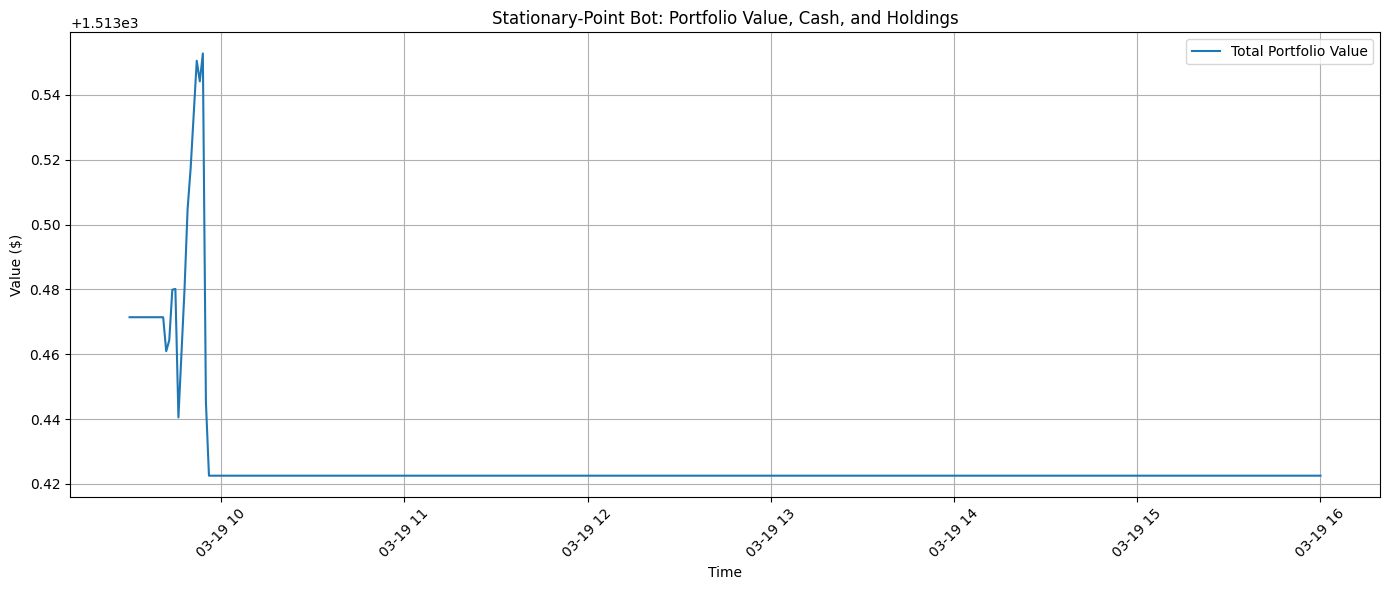

2026-03-19 | MAY21_AGGRESSIVE | LOW_RISK | start $1,513.47 -> final $1,513.42 | global max $1,524.26


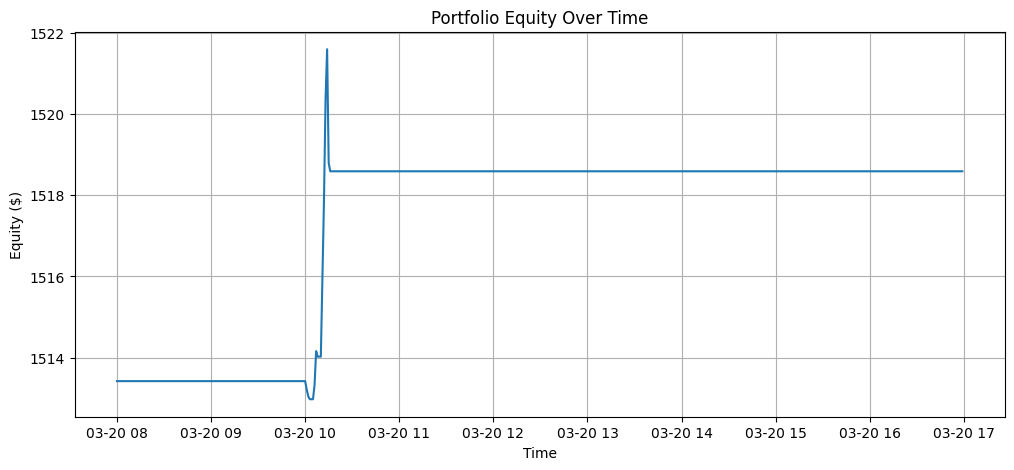

2026-03-20 | MAY22_DEFENSIVE | LOW_RISK | start $1,513.42 -> final $1,518.59 | global max $1,524.26


<MAY21_AGGRESSIVE_2026-03-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
<MAY21_AGGRESSIVE_2026-03-23_cell_2>:178: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in 

KeyboardInterrupt: 

In [2]:
# ============================================================
# TRUE ROUTER MULTI-DAY CONFIG
# ============================================================

import os
import getpass
import re
import io
import contextlib
from datetime import datetime, date, time, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd

try:
    from scipy.stats import t as student_t
except Exception:
    student_t = None

from IPython.display import display

# ------------------------------------------------------------
# Multi-day backtest date range.
# Weekends are skipped automatically. Market holidays/no-data days
# are also skipped when Alpaca returns no usable data.
# ------------------------------------------------------------
ROUTER_START_DAY = date(2026, 1, 2)
ROUTER_END_DAY   = date(2026, 5, 21)

# Starting account equity for the first backtest day.
MULTIDAY_STARTING_CASH = 1500.0

# If True, failed days are logged and the loop continues.
# If False, the notebook stops immediately on the first failed day.
CONTINUE_ON_DAY_ERROR = True

# If False, suppresses the very large daily branch printouts/plots.
# The final diagnostic cell still displays summary tables and combined results.
VERBOSE_DAILY_EXECUTION = False

# ------------------------------------------------------------
# Extra multi-day safety / output controls.
# ------------------------------------------------------------
# Adds a protect-gains switch to the May 21 bullish branch.
# This is separate from the 3% hard kill switch.
ENABLE_MAY21_BULLISH_PROFIT_LOCK = True
MAY21_BULL_PROFIT_LOCK_START_RETURN = 0.008   # arm after +0.20% from day start
MAY21_BULL_PROFIT_LOCK_TRAIL_DRAWDOWN = 0.004 # exit if equity gives back 0.10% from day peak


# Bull-market ETF mirror model.
# The May 21 aggressive branch mirrors the May 22 defensive stock/inverse-ETF
# framework, except it uses the matching normal ETF instead of an inverse ETF.
# Stocks are still traded normally; the ETF is added/trimmed in 9% steps using
# the same portfolio-derivative / drawdown trigger style as the bear branch.
ENABLE_MAY21_BULL_STRENGTH_ETF = True
MAY21_BULL_STRENGTH_ETF_SYMBOL = "AUTO"  # AUTO = use ROUTER_MICRO_REGIME_TICKER
MAY21_BULL_MODE_DRAWDOWN_TRIGGER = 0.005
MAY21_BULL_PORTFOLIO_DERIVATIVE_INTERVAL = "5min"
MAY21_BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW = 3
MAY21_BULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD = -0.0015
MAY21_BULL_ETF_WEIGHT_STEP = 0.09
MAY21_BULL_ETF_MAX_WEIGHT = 0.81
MAY21_BULL_ETF_MAJORITY_WEIGHT = 0.50
MAY21_BULL_ETF_MIN_REBALANCE_DOLLARS = 10.00

# Preserve no-overnight behaviour in the bullish branch by explicitly closing
# all May 21 stock and bull ETF positions at the final bar.
ENABLE_MAY21_FORCE_CLOSE_AT_END = True

# If the 3% hard portfolio kill switch fires in either branch, stop the
# whole multi-day backtest immediately. Profit-lock exits do not stop
# the full backtest; they only stop that trading day.
STOP_MULTIDAY_ON_HARD_KILL_SWITCH = False

# Suppress plot types that are noisy during long multi-day backtests.
SUPPRESS_DRAWDOWN_PLOTS = True
SUPPRESS_CASH_POSITION_VALUE_PLOTS = True
SUPPRESS_OPEN_POSITION_PLOTS = True

# ------------------------------------------------------------
# Branch override for validation.
# Set to:
#   None                  -> router decides using macro/micro regime each day
#   "MAY21_AGGRESSIVE"    -> force May 21 branch every day
#   "MAY22_DEFENSIVE"     -> force May 22 branch every day
# ------------------------------------------------------------
ROUTER_FORCE_BRANCH = None

# ------------------------------------------------------------
# Macro/micro branch-decision settings.
# For exact consistency with the May 22 notebook, both are set to QQQ by default.
# You can later change ROUTER_MICRO_REGIME_TICKER to "SMH" or another selected theme ETF.
# ------------------------------------------------------------
ROUTER_MACRO_REGIME_TICKER = "QQQ"
ROUTER_MICRO_REGIME_TICKER = "SMH"

ROUTER_DECISION_TIME = time(10, 15)
ROUTER_MARKET_OPEN = time(9, 30)
ROUTER_MARKET_CLOSE = time(16, 0)

ROUTER_BULL_RETURN_THRESHOLD = 0.0010   # +0.10%
ROUTER_BEAR_RETURN_THRESHOLD = -0.0025   # -0.25%

ROUTER_DATA_FEED_NAME = "IEX"           # use IEX unless you have SIP access

# ------------------------------------------------------------
# Market quality / choppiness routing settings.
# Direction is still decided using price vs VWAP and return-from-open.
# Quality is based on the early-window path efficiency:
#   choppiness = sum(abs(close.diff())) / abs(last_close - first_open)
# ------------------------------------------------------------
ENABLE_MARKET_QUALITY_ROUTER = True

ROUTER_CLEAN_CHOPPINESS_MAX = 2.5
ROUTER_CHOPPY_TRADABLE_MAX = 4.5
ROUTER_LOW_EARLY_RANGE_THRESHOLD = 0.003  # 0.30% early range = too dead/low range
ROUTER_MIN_TRADABILITY_RANGE_TRACK_ONLY = 0.003  # tracked only for now; does not block trading

# Risk profiles used after classifying the day.
# NORMAL = original May21/May22 sizing.
# CHOPPY = smaller stock buys + faster ETF/inverse protection.
# LOW_RISK = tiny stock buys + very fast ETF/inverse protection.
#
# IMPORTANT v8 split:
#   - GLOBAL_HARD_KILL_DRAWDOWN is the true 3% account-level hard kill
#     measured from the carried-forward global maximum equity.
#   - CHOPPY/LOW_RISK daily controls are day-only pause/stop rules.
#     They must not replace the 3% global hard-kill threshold.
NORMAL_BUY_FRACTION_OF_BUCKET = 0.50
CHOPPY_BUY_FRACTION_OF_BUCKET = 0.20
LOW_RISK_BUY_FRACTION_OF_BUCKET = 0.05

GLOBAL_HARD_KILL_DRAWDOWN = 0.03

NORMAL_PROTECTION_DRAWDOWN_TRIGGER = 0.005
CHOPPY_PROTECTION_DRAWDOWN_TRIGGER = 0.0025
LOW_RISK_PROTECTION_DRAWDOWN_TRIGGER = 0.0015

ENABLE_DAILY_RISK_CONTROLS = True

# v9 universal pause rule:
# Every trading profile gets a pause threshold, a stop threshold, and a cooldown.
# NO_TRADE mode is the only scenario where these rules are irrelevant because no
# branch is executed.
NORMAL_DAILY_PAUSE_TRIGGER = 0.0075
NORMAL_DAILY_STOP_TRIGGER = 0.0150

CHOPPY_DAILY_PAUSE_TRIGGER = 0.0040
CHOPPY_DAILY_STOP_TRIGGER = 0.0090

LOW_RISK_DAILY_PAUSE_TRIGGER = 0.0025
LOW_RISK_DAILY_STOP_TRIGGER = 0.0060

UNIVERSAL_COOLDOWN_MINUTES = 20
MAX_DAILY_PAUSES = 1
REENTRY_BUY_FRACTION_MULTIPLIER = 0.50

# v10 spike-top exit:
# If a held ticker rises near-vertically into a confirmed local maximum,
# sell the full position immediately instead of only taking partial profit.
ENABLE_SPIKE_TOP_EXIT = True
SPIKE_LOOKBACK_MINUTES = 10

NORMAL_SPIKE_MIN_TOTAL_RETURN = 0.0040
NORMAL_SPIKE_MIN_GRADIENT = 0.00040

CHOPPY_SPIKE_MIN_TOTAL_RETURN = 0.0030
CHOPPY_SPIKE_MIN_GRADIENT = 0.00030

LOW_RISK_SPIKE_MIN_TOTAL_RETURN = 0.0020
LOW_RISK_SPIKE_MIN_GRADIENT = 0.00020

# v11 portfolio-level spike lock:
# If total portfolio equity rises unusually fast, arm a portfolio profit lock.
# If it then gives back a small amount from the spike peak, sell everything.
# Profit-per-minute is used instead of dollars/minute so the rule scales with account size.
ENABLE_PORTFOLIO_SPIKE_LOCK = True
PORTFOLIO_SPIKE_LOOKBACK_MINUTES = 15
PORTFOLIO_SPIKE_MIN_TOTAL_RETURN = 0.0100       # +1.00% over lookback
PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN = 0.00075    # +0.075% per minute
PORTFOLIO_SPIKE_GIVEBACK_TRIGGER = 0.0015       # 0.15% giveback from spike peak
PORTFOLIO_SPIKE_STOP_FOR_DAY = True

# v13 portfolio-level negative spike warning/recovery:
# Medium-fast drops create a warning and must recover quickly.
# Extreme crash drops still stop immediately.
ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING = True

NEG_WARNING_LOOKBACK_MINUTES = 3
# v19 stricter downside detection than v16.
# Because downside events now sell-and-monitor instead of stop-for-day,
# these can be more sensitive without killing the whole day.
NEG_WARNING_RETURN = -0.0020
NEG_WARNING_LOSS_PER_MIN = -0.00060

NEG_RECOVERY_WINDOW_MINUTES = 5

# Minimum bounce from the warning low.
NEG_RECOVERY_MIN_RETURN_FROM_LOW = 0.0015

# Recovery only counts if it recovers a meaningful fraction of the original drop.
NEG_RECOVERY_FRACTION_REQUIRED = 0.65

# Legacy alias kept for old diagnostics / compatibility.
NEG_RECOVERY_REQUIRED = NEG_RECOVERY_MIN_RETURN_FROM_LOW

NEG_SECOND_LEG_RETURN = -0.0015  # legacy alias, not used for the main second-leg test
NEG_SECOND_LEG_FROM_LOW = -0.0010

NEG_CRASH_LOOKBACK_MINUTES = 3
NEG_CRASH_RETURN = -0.0030
NEG_CRASH_LOSS_PER_MIN = -0.00100

# v19: downside spike exits no longer stop trading for the whole day.
# They sell immediately, enter monitor/cooldown mode, and allow re-entry only
# on a later confirmed minimum after cooldown.
NEGATIVE_SPIKE_STOP_FOR_DAY = False
NEGATIVE_SPIKE_ENTER_MONITOR_MODE = True
NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES = 5

# v16 FFT choppiness feature:
# FFT is used as a router quality/choppiness feature, not as a direct buy/sell signal.
ENABLE_FFT_CHOPPINESS_FEATURE = True
ENABLE_FFT_ROUTER_QUALITY_ADJUSTMENT = True
FFT_MIN_SAMPLES = 16
FFT_CHOPPY_THRESHOLD = 0.55
FFT_VERY_CHOPPY_THRESHOLD = 0.65

# v16 t-distribution adaptive abnormal-move detection:
# Uses rolling 3-minute portfolio returns compared against the last 45 samples.
ENABLE_TDIST_ADAPTIVE_RISK = True
T_DIST_RETURN_LOOKBACK_MINUTES = 3
T_DIST_WINDOW = 45
MIN_T_DIST_SAMPLES = 20
T_DIST_DF = 5

NEG_T_LEFT_WARNING_PROB = 0.01
RECOVERY_T_RIGHT_PROB = 0.05
SECOND_LEG_T_LEFT_PROB = 0.05
PORTFOLIO_SPIKE_T_RIGHT_PROB = 0.01

# Keep old names as aliases for compatibility with any diagnostic cells.
ENABLE_PORTFOLIO_NEGATIVE_SPIKE_STOP = ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING
PORTFOLIO_NEG_SPIKE_LOOKBACK_MINUTES = NEG_WARNING_LOOKBACK_MINUTES
PORTFOLIO_NEG_SPIKE_MIN_TOTAL_RETURN = NEG_WARNING_RETURN
PORTFOLIO_NEG_SPIKE_MIN_LOSS_PER_MIN = NEG_WARNING_LOSS_PER_MIN
PORTFOLIO_NEG_SPIKE_STOP_FOR_DAY = NEGATIVE_SPIKE_STOP_FOR_DAY


# ------------------------------------------------------------
# Alpaca keys for router decision only.
# The selected branch will also use env/getpass.
# ------------------------------------------------------------
ROUTER_ALPACA_API_KEY = os.getenv("ALPACA_API_KEY")
ROUTER_ALPACA_SECRET_KEY = os.getenv("ALPACA_SECRET_KEY")

if not ROUTER_ALPACA_API_KEY:
    ROUTER_ALPACA_API_KEY = getpass.getpass("Enter your Alpaca API key for router decision: ")
    os.environ["ALPACA_API_KEY"] = ROUTER_ALPACA_API_KEY

if not ROUTER_ALPACA_SECRET_KEY:
    ROUTER_ALPACA_SECRET_KEY = getpass.getpass("Enter your Alpaca secret key for router decision: ")
    os.environ["ALPACA_SECRET_KEY"] = ROUTER_ALPACA_SECRET_KEY


# ============================================================
# ROUTER REGIME HELPERS
# ============================================================

NY_TZ = ZoneInfo("America/New_York")

def iter_weekdays(start_day, end_day):
    d = start_day
    while d <= end_day:
        if d.weekday() < 5:
            yield d
        d += timedelta(days=1)


def _router_get_bars(symbols, start_dt, end_dt):
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame
    from alpaca.data.enums import DataFeed

    client = StockHistoricalDataClient(
        ROUTER_ALPACA_API_KEY,
        ROUTER_ALPACA_SECRET_KEY,
    )

    feed = getattr(DataFeed, ROUTER_DATA_FEED_NAME)

    req = StockBarsRequest(
        symbol_or_symbols=list(symbols),
        timeframe=TimeFrame.Minute,
        start=start_dt,
        end=end_dt,
        feed=feed,
    )

    df = client.get_stock_bars(req).df
    if df is None or df.empty:
        return pd.DataFrame(columns=["symbol", "timestamp", "open", "high", "low", "close", "volume"])

    df = df.reset_index()

    # Robust Alpaca dataframe normalisation.
    # Different feeds / single-symbol requests can produce slightly different
    # column/index layouts. The classifier expects "symbol" and "timestamp".
    rename_map = {
        "ticker": "symbol",
        "Ticker": "symbol",
        "Symbol": "symbol",
        "time": "timestamp",
        "Time": "timestamp",
        "datetime": "timestamp",
        "Datetime": "timestamp",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    if "symbol" not in df.columns:
        if len(symbols) == 1:
            df["symbol"] = list(symbols)[0]
        else:
            # Return empty but well-formed data instead of crashing with KeyError.
            return pd.DataFrame(columns=["symbol", "timestamp", "open", "high", "low", "close", "volume"])

    if "timestamp" not in df.columns:
        # Try to find a datetime-like column.
        for c in df.columns:
            if "time" in str(c).lower() or "date" in str(c).lower():
                df = df.rename(columns={c: "timestamp"})
                break

    needed = ["symbol", "timestamp", "open", "high", "low", "close", "volume"]
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan

    return df



def _router_fft_choppiness_from_close(close_series):
    """Return high-frequency power ratio from 1-minute returns for router choppiness."""
    if not globals().get("ENABLE_FFT_CHOPPINESS_FEATURE", True):
        return {
            "fft_choppiness_score": np.nan,
            "fft_high_freq_power_ratio": np.nan,
            "fft_quality_label": "DISABLED",
        }

    s = pd.Series(close_series).astype(float).dropna()
    min_samples = int(globals().get("FFT_MIN_SAMPLES", 16))

    if len(s) < min_samples:
        return {
            "fft_choppiness_score": np.nan,
            "fft_high_freq_power_ratio": np.nan,
            "fft_quality_label": "INSUFFICIENT_DATA",
        }

    returns = s.pct_change(fill_method=None).dropna()
    if len(returns) < max(8, min_samples - 1):
        return {
            "fft_choppiness_score": np.nan,
            "fft_high_freq_power_ratio": np.nan,
            "fft_quality_label": "INSUFFICIENT_RETURNS",
        }

    x = returns - returns.mean()
    if float(np.abs(x).sum()) <= 0:
        return {
            "fft_choppiness_score": 0.0,
            "fft_high_freq_power_ratio": 0.0,
            "fft_quality_label": "CLEAN",
        }

    fft_vals = np.fft.rfft(x.values)
    power = np.abs(fft_vals) ** 2

    # Remove zero-frequency component after demeaning.
    power = power[1:]

    if len(power) == 0 or float(power.sum()) <= 0:
        return {
            "fft_choppiness_score": np.nan,
            "fft_high_freq_power_ratio": np.nan,
            "fft_quality_label": "NO_POWER",
        }

    n = len(power)
    split = max(1, n // 3)
    high_power = float(power[split:].sum()) if split < n else 0.0
    total_power = float(power.sum())
    high_ratio = high_power / total_power if total_power > 0 else np.nan

    if pd.isna(high_ratio):
        label = "UNKNOWN"
    elif high_ratio >= globals().get("FFT_VERY_CHOPPY_THRESHOLD", 0.65):
        label = "VERY_CHOPPY"
    elif high_ratio >= globals().get("FFT_CHOPPY_THRESHOLD", 0.55):
        label = "CHOPPY"
    else:
        label = "CLEAN"

    return {
        "fft_choppiness_score": high_ratio,
        "fft_high_freq_power_ratio": high_ratio,
        "fft_quality_label": label,
    }


def _router_classify_symbol(symbol, bars_df):
    """
    Classify early-window direction and market quality for a symbol.

    Direction:
        BULLISH / BEARISH / UNCERTAIN

    Quality:
        CLEAN / CHOPPY_TRADABLE / LOW_QUALITY_CHOP / LOW_RANGE

    Combined:
        CLEAN_BULL, CHOPPY_BULL, CLEAN_BEAR, CHOPPY_BEAR,
        UNCERTAIN, LOW_QUALITY
    """
    base = {
        "ticker": symbol,
        "regime": "UNCERTAIN",
        "direction": "UNCERTAIN",
        "quality": "UNKNOWN",
        "regime_quality": "UNCERTAIN",
        "reason": "not_calculated",
        "price": np.nan,
        "vwap": np.nan,
        "return_from_open": np.nan,
        "early_range": np.nan,
        "path_length": np.nan,
        "net_move": np.nan,
        "choppiness_score": np.nan,
        "vwap_crosses": np.nan,
        "fft_choppiness_score": np.nan,
        "fft_high_freq_power_ratio": np.nan,
        "fft_quality_label": "UNKNOWN",
        "bars": 0,
        "tradability_status": "UNKNOWN",
        "branch_confidence": "LOW",
        "branch_confidence_score": 0,
    }

    if bars_df.empty:
        base["reason"] = "no bars returned"
        return base

    sdf = bars_df[bars_df["symbol"] == symbol].copy()
    if sdf.empty:
        base["reason"] = "no bars for symbol"
        return base

    sdf = sdf.sort_values("timestamp").copy()
    base["bars"] = int(len(sdf))

    for col in ["open", "high", "low", "close", "volume"]:
        sdf[col] = pd.to_numeric(sdf[col], errors="coerce")

    sdf = sdf.dropna(subset=["open", "high", "low", "close"])
    if len(sdf) < 3:
        base["reason"] = "too few valid bars"
        base["bars"] = int(len(sdf))
        return base

    typical = (sdf["high"] + sdf["low"] + sdf["close"]) / 3.0
    volume = sdf["volume"].replace(0, np.nan)
    sdf["vwap"] = (typical * volume).cumsum() / volume.cumsum()

    open_price = float(sdf.iloc[0]["open"])
    close = sdf["close"]
    last = sdf.iloc[-1]
    price = float(last["close"])
    vwap = float(last["vwap"]) if not pd.isna(last["vwap"]) else np.nan

    if not open_price or open_price <= 0:
        base["reason"] = "bad open price"
        return base

    return_from_open = (price - open_price) / open_price

    high_so_far = float(sdf["high"].max())
    low_so_far = float(sdf["low"].min())
    early_range = (high_so_far - low_so_far) / open_price if open_price > 0 else np.nan

    path_length = float(close.diff().abs().sum())
    net_move = abs(price - open_price)
    if net_move <= 1e-9:
        choppiness_score = 999.0
    else:
        choppiness_score = min(float(path_length / net_move), 999.0)

    above_vwap = close > sdf["vwap"]
    above_vwap = above_vwap.dropna()
    if len(above_vwap) <= 1:
        vwap_crosses = 0
    else:
        vwap_crosses = max(0, int((above_vwap != above_vwap.shift(1)).sum() - 1))

    fft_info = _router_fft_choppiness_from_close(close)
    fft_choppiness_score = fft_info.get("fft_choppiness_score", np.nan)
    fft_high_freq_power_ratio = fft_info.get("fft_high_freq_power_ratio", np.nan)
    fft_quality_label = fft_info.get("fft_quality_label", "UNKNOWN")

    if price > vwap and return_from_open >= ROUTER_BULL_RETURN_THRESHOLD:
        regime = "BULLISH"
    elif price < vwap and return_from_open <= ROUTER_BEAR_RETURN_THRESHOLD:
        regime = "BEARISH"
    else:
        regime = "UNCERTAIN"

    # User-selected benchmark:
    # <= 2.5 clean, 2.5 to 4.5 choppy-tradable, > 4.5 low-quality chop.
    if pd.isna(early_range) or early_range < ROUTER_LOW_EARLY_RANGE_THRESHOLD:
        quality = "LOW_RANGE"
    elif choppiness_score <= ROUTER_CLEAN_CHOPPINESS_MAX:
        quality = "CLEAN"
    elif choppiness_score <= ROUTER_CHOPPY_TRADABLE_MAX:
        quality = "CHOPPY_TRADABLE"
    else:
        quality = "LOW_QUALITY_CHOP"

    # Optional FFT quality adjustment:
    # - very high high-frequency power makes a day low-quality/choppy
    # - moderate high-frequency power downgrades clean days to choppy-tradable
    if globals().get("ENABLE_FFT_ROUTER_QUALITY_ADJUSTMENT", True) and quality != "LOW_RANGE":
        if fft_quality_label == "VERY_CHOPPY":
            quality = "LOW_QUALITY_CHOP"
        elif fft_quality_label == "CHOPPY" and quality == "CLEAN":
            quality = "CHOPPY_TRADABLE"

    if regime == "BULLISH" and quality == "CLEAN":
        regime_quality = "CLEAN_BULL"
    elif regime == "BULLISH" and quality == "CHOPPY_TRADABLE":
        regime_quality = "CHOPPY_BULL"
    elif regime == "BEARISH" and quality == "CLEAN":
        regime_quality = "CLEAN_BEAR"
    elif regime == "BEARISH" and quality == "CHOPPY_TRADABLE":
        regime_quality = "CHOPPY_BEAR"
    elif regime == "UNCERTAIN":
        regime_quality = "UNCERTAIN"
    else:
        regime_quality = "LOW_QUALITY"

    # Track minimum tradability but do not yet use it to block trading.
    if pd.isna(early_range):
        tradability_status = "UNKNOWN"
    elif early_range < ROUTER_MIN_TRADABILITY_RANGE_TRACK_ONLY:
        tradability_status = "LOW_RANGE_TRACKED"
    else:
        tradability_status = "TRADABLE_RANGE"

    branch_confidence_score = 0
    if abs(return_from_open) >= 0.0020:
        branch_confidence_score += 1
    if early_range >= 0.0050:
        branch_confidence_score += 1
    if choppiness_score <= ROUTER_CLEAN_CHOPPINESS_MAX:
        branch_confidence_score += 1
    if regime in {"BULLISH", "BEARISH"}:
        branch_confidence_score += 1

    if branch_confidence_score >= 3:
        branch_confidence = "HIGH"
    elif branch_confidence_score >= 2:
        branch_confidence = "MEDIUM"
    else:
        branch_confidence = "LOW"

    return {
        "ticker": symbol,
        "regime": regime,
        "direction": regime,
        "quality": quality,
        "regime_quality": regime_quality,
        "reason": "price_vwap_return_plus_choppiness",
        "price": price,
        "vwap": vwap,
        "return_from_open": return_from_open,
        "early_range": early_range,
        "path_length": path_length,
        "net_move": net_move,
        "choppiness_score": choppiness_score,
        "vwap_crosses": vwap_crosses,
        "fft_choppiness_score": fft_choppiness_score,
        "fft_high_freq_power_ratio": fft_high_freq_power_ratio,
        "fft_quality_label": fft_quality_label,
        "bars": int(len(sdf)),
        "tradability_status": tradability_status,
        "branch_confidence": branch_confidence,
        "branch_confidence_score": branch_confidence_score,
    }


def _combine_router_market_quality(macro, micro):
    """
    Combine macro/micro early-window states into:
        selected_branch, risk_profile, selected_market_quality, confidence.

    v9:
        - Real NO_TRADE for uncertain/low-quality no-edge days.
        - Clean bull/bear first.
        - Choppy bull/bear next.
        - Directional low-quality days go LOW_RISK.
        - Minimum tradability is tracked, not used as a hard blocker by itself.
    """
    macro_regime = macro.get("regime", "UNCERTAIN")
    micro_regime = micro.get("regime", "UNCERTAIN")
    macro_quality = macro.get("quality", "UNKNOWN")
    micro_quality = micro.get("quality", "UNKNOWN")

    macro_conf_score = int(macro.get("branch_confidence_score", 0) or 0)
    micro_conf_score = int(micro.get("branch_confidence_score", 0) or 0)

    regime_score = 0
    if macro_regime == "BULLISH":
        regime_score += 1
    elif macro_regime == "BEARISH":
        regime_score -= 1

    if micro_regime == "BULLISH":
        regime_score += 2
    elif micro_regime == "BEARISH":
        regime_score -= 2

    both_clean = macro_quality == "CLEAN" and micro_quality == "CLEAN"

    micro_choppy_bull = micro_regime == "BULLISH" and micro_quality == "CHOPPY_TRADABLE"
    micro_choppy_bear = micro_regime == "BEARISH" and micro_quality == "CHOPPY_TRADABLE"

    macro_choppy_bull = macro_regime == "BULLISH" and macro_quality == "CHOPPY_TRADABLE" and micro_regime != "BEARISH"
    macro_choppy_bear = macro_regime == "BEARISH" and macro_quality == "CHOPPY_TRADABLE" and micro_regime != "BULLISH"

    micro_low_quality_bull = micro_regime == "BULLISH" and micro_quality in {"LOW_RANGE", "LOW_QUALITY_CHOP"}
    micro_low_quality_bear = micro_regime == "BEARISH" and micro_quality in {"LOW_RANGE", "LOW_QUALITY_CHOP"}

    both_uncertain = macro_regime == "UNCERTAIN" and micro_regime == "UNCERTAIN"
    both_low_quality = (
        macro_quality in {"LOW_RANGE", "LOW_QUALITY_CHOP", "UNKNOWN"}
        and micro_quality in {"LOW_RANGE", "LOW_QUALITY_CHOP", "UNKNOWN"}
    )

    combined_confidence_score = macro_conf_score + (2 * micro_conf_score)
    if combined_confidence_score >= 7:
        branch_confidence = "HIGH"
    elif combined_confidence_score >= 4:
        branch_confidence = "MEDIUM"
    else:
        branch_confidence = "LOW"

    if both_uncertain and both_low_quality:
        selected_branch = "NO_TRADE"
        risk_profile = "NO_TRADE"
        selected_market_quality = "NO_TRADE_UNCERTAIN_LOW_QUALITY"

    elif regime_score >= 3 and both_clean and branch_confidence != "LOW":
        selected_branch = "MAY21_AGGRESSIVE"
        risk_profile = "NORMAL"
        selected_market_quality = "CLEAN_BULL"

    elif regime_score <= -3 and both_clean and branch_confidence != "LOW":
        selected_branch = "MAY22_DEFENSIVE"
        risk_profile = "NORMAL"
        selected_market_quality = "CLEAN_BEAR"

    elif regime_score >= 1 and (micro_choppy_bull or macro_choppy_bull):
        selected_branch = "MAY21_AGGRESSIVE"
        risk_profile = "CHOPPY"
        selected_market_quality = "CHOPPY_BULL"

    elif regime_score <= -1 and (micro_choppy_bear or macro_choppy_bear):
        selected_branch = "MAY22_DEFENSIVE"
        risk_profile = "CHOPPY"
        selected_market_quality = "CHOPPY_BEAR"

    elif regime_score >= 1 or micro_low_quality_bull:
        selected_branch = "MAY21_AGGRESSIVE"
        risk_profile = "LOW_RISK"
        selected_market_quality = "LOW_QUALITY_BULL"

    elif regime_score <= -1 or micro_low_quality_bear:
        selected_branch = "MAY22_DEFENSIVE"
        risk_profile = "LOW_RISK"
        selected_market_quality = "LOW_QUALITY_BEAR"

    else:
        selected_branch = "NO_TRADE"
        risk_profile = "NO_TRADE"
        selected_market_quality = "NO_TRADE_UNCERTAIN"

    return selected_branch, risk_profile, selected_market_quality, branch_confidence, combined_confidence_score

def decide_router_branch(test_day):
    if ROUTER_FORCE_BRANCH in {"MAY21_AGGRESSIVE", "MAY22_DEFENSIVE"}:
        return {
            "date": test_day,
            "selected_branch": ROUTER_FORCE_BRANCH,
            "risk_profile": "NORMAL",
            "selected_market_quality": "FORCED",
            "branch_confidence": "FORCED",
            "branch_confidence_score": np.nan,
            "macro": {"ticker": ROUTER_MACRO_REGIME_TICKER, "regime": "FORCED", "quality": "FORCED", "regime_quality": "FORCED"},
            "micro": {"ticker": ROUTER_MICRO_REGIME_TICKER, "regime": "FORCED", "quality": "FORCED", "regime_quality": "FORCED"},
            "forced": True,
        }

    start_dt = datetime.combine(test_day, ROUTER_MARKET_OPEN, tzinfo=NY_TZ)
    end_dt = datetime.combine(test_day, ROUTER_DECISION_TIME, tzinfo=NY_TZ)

    symbols = sorted({ROUTER_MACRO_REGIME_TICKER, ROUTER_MICRO_REGIME_TICKER})
    bars = _router_get_bars(symbols, start_dt, end_dt)

    macro = _router_classify_symbol(ROUTER_MACRO_REGIME_TICKER, bars)
    micro = _router_classify_symbol(ROUTER_MICRO_REGIME_TICKER, bars)

    if ENABLE_MARKET_QUALITY_ROUTER:
        selected_branch, risk_profile, selected_market_quality, branch_confidence, branch_confidence_score = _combine_router_market_quality(macro, micro)
    else:
        if macro["regime"] == "BULLISH" and micro["regime"] == "BULLISH":
            selected_branch = "MAY21_AGGRESSIVE"
        else:
            selected_branch = "MAY22_DEFENSIVE"
        risk_profile = "NORMAL"
        selected_market_quality = "LEGACY_DIRECTION_ONLY"
        branch_confidence = "UNKNOWN"
        branch_confidence_score = np.nan

    return {
        "date": test_day,
        "selected_branch": selected_branch,
        "risk_profile": risk_profile,
        "selected_market_quality": selected_market_quality,
        "branch_confidence": branch_confidence,
        "branch_confidence_score": branch_confidence_score,
        "macro": macro,
        "micro": micro,
        "forced": False,
    }


# ============================================================
# PATCH SELECTED BRANCH WITHOUT CHANGING TRADING LOGIC
# ============================================================

def _remove_unwanted_plot_blocks(src):
    """Remove noisy plot blocks from embedded branch code before execution."""
    s = src

    if SUPPRESS_CASH_POSITION_VALUE_PLOTS:
        # May 22 branch: remove the Cash vs Position Value figure only.
        s = re.sub(
            r"\n\s*plt\.figure\(figsize=\(12, 5\)\)\s*\n"
            r"\s*plt\.plot\(equity_df\[\"time\"\], equity_df\[\"cash\"\], label=\"Cash\"\)\s*\n"
            r"\s*plt\.plot\(equity_df\[\"time\"\], equity_df\[\"position_value\"\], label=\"Position value\"\)\s*\n"
            r"\s*plt\.title\(\"Cash vs Position Value\"\)\s*\n"
            r"\s*plt\.xlabel\(\"Time\"\)\s*\n"
            r"\s*plt\.ylabel\(\"Value \(\$\)\"\)\s*\n"
            r"\s*plt\.legend\(\)\s*\n"
            r"\s*plt\.grid\(True\)\s*\n"
            r"\s*plt\.show\(\)[ \t]*",
            "\n\n    # Cash vs position value plot suppressed by multi-day router.\n",
            s,
        )

    if SUPPRESS_DRAWDOWN_PLOTS:
        # May 21 branch: remove Portfolio Drawdown Over Time figure.
        s = re.sub(
            r"\n\s*plt\.figure\(figsize=\(14, 4\)\)\s*\n"
            r"\s*plt\.plot\(equity_df\[\"time\"\], equity_df\[\"drawdown\"\]\)\s*\n\s*\n?"
            r"\s*plt\.title\(\"Portfolio Drawdown Over Time\"\)\s*\n"
            r"\s*plt\.xlabel\(\"Time\"\)\s*\n"
            r"\s*plt\.ylabel\(\"Drawdown\"\)\s*\n"
            r"\s*plt\.grid\(True\)\s*\n"
            r"\s*plt\.xticks\(rotation=45\)\s*\n"
            r"\s*plt\.tight_layout\(\)\s*\n"
            r"\s*plt\.show\(\)[ \t]*",
            "\n\n    # Drawdown plot suppressed by multi-day router.\n",
            s,
        )
        # May 22 branch: remove Portfolio Drawdown figure.
        s = re.sub(
            r"\n\s*plt\.figure\(figsize=\(12, 5\)\)\s*\n"
            r"\s*plt\.plot\(equity_df\[\"time\"\], equity_df\[\"drawdown\"\]\)\s*\n"
            r"\s*plt\.title\(\"Portfolio Drawdown\"\)\s*\n"
            r"\s*plt\.xlabel\(\"Time\"\)\s*\n"
            r"\s*plt\.ylabel\(\"Drawdown\"\)\s*\n"
            r"\s*plt\.grid\(True\)\s*\n"
            r"\s*plt\.show\(\)[ \t]*",
            "\n\n    # Drawdown plot suppressed by multi-day router.\n",
            s,
        )

    if globals().get("SUPPRESS_OPEN_POSITION_PLOTS", True):
        # Generic removal for branch plots titled like "Number of Open Positions Over Time".
        # This is intentionally line-based because the exact figsize/title can vary by branch.
        _lines = s.splitlines()
        _remove = set()
        for _i, _line in enumerate(_lines):
            if "Open Positions" in _line and "title" in _line:
                _start = _i
                while _start >= 0 and "plt.figure" not in _lines[_start]:
                    _start -= 1
                _end = _i
                while _end < len(_lines) and "plt.show()" not in _lines[_end]:
                    _end += 1
                if _start >= 0 and _end < len(_lines):
                    _remove.update(range(_start, _end + 1))
        if _remove:
            _lines = [
                _line if _i not in _remove else "    # Open-position plot suppressed by multi-day router."
                for _i, _line in enumerate(_lines)
            ]
            # Collapse repeated suppression comment lines.
            _collapsed = []
            _prev_suppressed = False
            for _line in _lines:
                _is_suppressed = "Open-position plot suppressed" in _line
                if _is_suppressed and _prev_suppressed:
                    continue
                _collapsed.append(_line)
                _prev_suppressed = _is_suppressed
            s = "\n".join(_collapsed) + ("\n" if src.endswith("\n") else "")

    return s


def _inject_may21_bullish_profit_lock(src):
    """Patch the May 21 bullish branch with a simple daily trailing profit lock."""
    s = src
    if "# Profit-lock state added by multi-day router." in s:
        return s

    # Only apply to the May 21 branch shape, not the May 22 branch which already has profit lock.
    if "FORCE_CLOSE_AT_END = False" not in s or "day_peak_equity" in s:
        return s

    settings_anchor = "PORTFOLIO_KILL_SWITCH = 0.03   # 3% drawdown from peak equity\n"
    settings_insert = settings_anchor + """
# Profit-lock / protect-gains switch added by the multi-day router for the bullish May 21 branch.
# This is a tighter daily trailing lockout, not the disaster-level hard kill switch.
ENABLE_PROFIT_LOCK = globals().get('ENABLE_MAY21_BULLISH_PROFIT_LOCK', True)
PROFIT_LOCK_START_RETURN = globals().get('MAY21_BULL_PROFIT_LOCK_START_RETURN', 0.002)
PROFIT_LOCK_TRAIL_DRAWDOWN = globals().get('MAY21_BULL_PROFIT_LOCK_TRAIL_DRAWDOWN', 0.001)
"""
    s = s.replace(settings_anchor, settings_insert, 1)

    init_anchor = "peak_equity = STARTING_CASH\ntrading_stopped = False\nkill_switch_time = None\n"
    init_insert = """peak_equity = STARTING_CASH
trading_stopped = False
kill_switch_time = None

# Profit-lock state added by multi-day router.
day_start_equity = STARTING_CASH
day_peak_equity = STARTING_CASH
profit_lock_armed = False
profit_lock_time = None
profit_lock_log = []
"""
    s = s.replace(init_anchor, init_insert, 1)

    calc_anchor = """    peak_equity = max(peak_equity, equity)

    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0

    equity_curve.append({
        "time": current_time,
        "equity": equity,
        "cash": total_cash,
        "position_value": position_value,
        "drawdown": drawdown,
        "open_positions": sum(pos is not None for pos in positions.values())
    })
"""
    calc_insert = """    peak_equity = max(peak_equity, equity)

    # Daily profit-lock tracking. This protects bullish-day gains without waiting
    # for the 3% hard drawdown kill switch.
    day_peak_equity = max(day_peak_equity, equity)
    day_return_from_start = (equity - day_start_equity) / day_start_equity if day_start_equity > 0 else 0.0
    day_peak_return_from_start = (day_peak_equity - day_start_equity) / day_start_equity if day_start_equity > 0 else 0.0
    day_drawdown_from_peak = (day_peak_equity - equity) / day_peak_equity if day_peak_equity > 0 else 0.0

    if (
        ENABLE_PROFIT_LOCK
        and not profit_lock_armed
        and day_peak_return_from_start >= PROFIT_LOCK_START_RETURN
    ):
        profit_lock_armed = True

    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0

    equity_curve.append({
        "time": current_time,
        "equity": equity,
        "cash": total_cash,
        "position_value": position_value,
        "drawdown": drawdown,
        "day_start_equity": day_start_equity,
        "day_peak_equity": day_peak_equity,
        "day_return_from_start": day_return_from_start,
        "day_peak_return_from_start": day_peak_return_from_start,
        "day_drawdown_from_peak": day_drawdown_from_peak,
        "profit_lock_armed": profit_lock_armed,
        "profit_lock_start_return": PROFIT_LOCK_START_RETURN,
        "profit_lock_trail_drawdown": PROFIT_LOCK_TRAIL_DRAWDOWN,
        "open_positions": sum(pos is not None for pos in positions.values())
    })
"""
    s = s.replace(calc_anchor, calc_insert, 1)

    risk_anchor = """    # ------------------------------------------------------------
    # Portfolio-level risk control
    # ------------------------------------------------------------

    if (
        ENABLE_PORTFOLIO_KILL_SWITCH
"""
    profit_lock_block = """    # ------------------------------------------------------------
    # Portfolio-level risk control
    # ------------------------------------------------------------

    # Tight bullish profit lock: close positions and stop trading for the day
    # once the day has moved up enough and then gives back too much from its peak.
    if (
        ENABLE_PROFIT_LOCK
        and not trading_stopped
        and profit_lock_armed
        and day_drawdown_from_peak >= PROFIT_LOCK_TRAIL_DRAWDOWN
    ):
        trading_stopped = True
        profit_lock_time = current_time

        print(
            f"Profit-lock switch triggered at {current_time}. "
            f"Day peak return = {day_peak_return_from_start:.2%}, "
            f"day drawdown from peak = {day_drawdown_from_peak:.2%}"
        )

        for ticker in TICKERS:
            pos = positions[ticker]

            if pos is None:
                continue

            current_price = get_current_price(
                ticker=ticker,
                current_time=current_time,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices
            )

            if pd.isna(current_price):
                continue

            exit_price = current_price * (1 - SLIPPAGE_RATE)
            quantity_to_sell = pos["quantity"]
            gross_value = quantity_to_sell * exit_price
            fee = gross_value * FEE_RATE
            net_value = gross_value - fee
            cost_basis_sold = pos["cost_basis"]
            realised_pnl = net_value - cost_basis_sold

            stock_cash[ticker] += net_value

            trade_log.append({
                "ticker": ticker,
                "action": "SELL",
                "reason": "profit_lock_protect_gains",
                "time": current_time,
                "price": exit_price,
                "quantity": quantity_to_sell,
                "gross_value": gross_value,
                "fee": fee,
                "net_value": net_value,
                "cost_basis_sold": cost_basis_sold,
                "realised_pnl": realised_pnl,
                "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
                "stock_cash_after": stock_cash[ticker]
            })

            positions[ticker] = None

        profit_lock_log.append({
            "time": current_time,
            "event": "profit_lock_protect_gains",
            "equity": equity,
            "day_start_equity": day_start_equity,
            "day_peak_equity": day_peak_equity,
            "day_return_from_start": day_return_from_start,
            "day_peak_return_from_start": day_peak_return_from_start,
            "day_drawdown_from_peak": day_drawdown_from_peak,
            "profit_lock_start_return": PROFIT_LOCK_START_RETURN,
            "profit_lock_trail_drawdown": PROFIT_LOCK_TRAIL_DRAWDOWN,
            "global_peak_equity": peak_equity,
            "global_drawdown": drawdown,
        })

        continue

    if (
        ENABLE_PORTFOLIO_KILL_SWITCH
"""
    s = s.replace(risk_anchor, profit_lock_block, 1)

    results_anchor = """if kill_switch_time is not None:
    print(f"Kill switch triggered:  {kill_switch_time}")
else:
    print("Kill switch triggered:  No")
"""
    results_insert = results_anchor + """

if profit_lock_time is not None:
    print(f"Profit lock triggered:  {profit_lock_time}")
    if len(profit_lock_log) > 0:
        last_profit_lock = profit_lock_log[-1]
        print(f"Profit lock arm:        {last_profit_lock.get('profit_lock_start_return', np.nan):.2%}")
        print(f"Profit lock trail:      {last_profit_lock.get('profit_lock_trail_drawdown', np.nan):.2%}")
else:
    print("Profit lock triggered:  No")
"""
    s = s.replace(results_anchor, results_insert, 1)

    return s



def _inject_may21_bull_strength_etf(src):
    """Patch the bullish May 21 branch with a true mirror stock + normal ETF model."""
    s = src
    if "# Bull ETF mirror state added by multi-day router." in s:
        return s
    if ("BUY / SELL / RISK BACKTEST CELL" not in s or "INITIAL_CASH_PER_TICKER = STARTING_CASH / len(TICKERS)" not in s or "calculate_profit_sell_fraction" not in s):
        return s
    settings_block = "\n# Bull ETF mirror settings added by the multi-day router.\nENABLE_BULL_STRENGTH_ETF = globals().get('ENABLE_MAY21_BULL_STRENGTH_ETF', True)\nBULL_STRENGTH_ETF_SYMBOL = globals().get('MAY21_BULL_STRENGTH_ETF_SYMBOL_RESOLVED', 'QQQ')\nBULL_MODE_DRAWDOWN_TRIGGER = globals().get('MAY21_BULL_MODE_DRAWDOWN_TRIGGER', 0.005)\nBULL_PORTFOLIO_DERIVATIVE_INTERVAL = globals().get('MAY21_BULL_PORTFOLIO_DERIVATIVE_INTERVAL', '5min')\nBULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW = globals().get('MAY21_BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW', 3)\nBULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD = globals().get('MAY21_BULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD', -0.0015)\nBULL_ETF_WEIGHT_STEP = globals().get('MAY21_BULL_ETF_WEIGHT_STEP', 0.09)\nBULL_ETF_MAX_WEIGHT = globals().get('MAY21_BULL_ETF_MAX_WEIGHT', 0.81)\nBULL_ETF_MAJORITY_WEIGHT = globals().get('MAY21_BULL_ETF_MAJORITY_WEIGHT', 0.50)\nBULL_ETF_MIN_REBALANCE_DOLLARS = globals().get('MAY21_BULL_ETF_MIN_REBALANCE_DOLLARS', 10.00)\n"
    s, settings_count = re.subn(r"(FORCE_CLOSE_AT_END\s*=\s*(?:False|globals\(\)\.get\('ENABLE_MAY21_FORCE_CLOSE_AT_END', True\))\n)", r"\1" + settings_block, s, count=1)
    if settings_count == 0:
        raise ValueError("Could not find May 21 FORCE_CLOSE_AT_END anchor for bull ETF mirror settings patch.")
    helper_anchor = 'def calculate_portfolio_value(stock_cash, positions, bars_by_ticker, current_time, last_known_prices):\n    """\n    Portfolio equity = all ticker cash buckets + current market value of positions.\n    """\n\n    total_cash = sum(stock_cash.values())\n    position_value = 0.0\n\n    per_ticker_values = {}\n\n    for ticker in TICKERS:\n        price = get_current_price(\n            ticker=ticker,\n            current_time=current_time,\n            bars_by_ticker=bars_by_ticker,\n            last_known_prices=last_known_prices\n        )\n\n        pos = positions.get(ticker)\n\n        if pos is None:\n            ticker_position_value = 0.0\n        else:\n            ticker_position_value = pos["quantity"] * price if not pd.isna(price) else 0.0\n\n        ticker_total_value = stock_cash[ticker] + ticker_position_value\n\n        per_ticker_values[ticker] = {\n            "cash": stock_cash[ticker],\n            "position_value": ticker_position_value,\n            "total_value": ticker_total_value,\n            "price": price\n        }\n\n        position_value += ticker_position_value\n\n    equity = total_cash + position_value\n\n    return equity, total_cash, position_value, per_ticker_values\n'
    helper_insert = 'def calculate_portfolio_value(stock_cash, positions, bars_by_ticker, current_time, last_known_prices):\n    total_cash = sum(stock_cash.values())\n    position_value = 0.0\n    per_ticker_values = {}\n\n    for ticker in TICKERS:\n        price = get_current_price(ticker=ticker, current_time=current_time, bars_by_ticker=bars_by_ticker, last_known_prices=last_known_prices)\n        pos = positions.get(ticker)\n        ticker_position_value = 0.0 if pos is None else (pos["quantity"] * price if not pd.isna(price) else 0.0)\n        ticker_total_value = stock_cash[ticker] + ticker_position_value\n        per_ticker_values[ticker] = {"cash": stock_cash[ticker], "position_value": ticker_position_value, "total_value": ticker_total_value, "price": price}\n        position_value += ticker_position_value\n\n    etf_pos = globals().get("bull_etf_position", None)\n    if ENABLE_BULL_STRENGTH_ETF and etf_pos is not None:\n        etf_price = get_current_price(ticker=BULL_STRENGTH_ETF_SYMBOL, current_time=current_time, bars_by_ticker=bars_by_ticker, last_known_prices=last_known_prices)\n        if not pd.isna(etf_price):\n            etf_position_value = etf_pos["quantity"] * etf_price\n            position_value += etf_position_value\n            per_ticker_values[BULL_STRENGTH_ETF_SYMBOL] = {"cash": 0.0, "position_value": etf_position_value, "total_value": etf_position_value, "price": etf_price}\n\n    equity = total_cash + position_value\n    return equity, total_cash, position_value, per_ticker_values\n\n\ndef get_portfolio_derivative_state():\n    if len(equity_curve) < max(5, BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW + 2):\n        return {"has_signal": False, "slope_return": np.nan, "accel_return": np.nan, "derivative_interval_time": None}\n    deriv_df = pd.DataFrame(equity_curve)[["time", "equity"]].copy()\n    deriv_df["time"] = pd.to_datetime(deriv_df["time"])\n    deriv_df["equity"] = pd.to_numeric(deriv_df["equity"], errors="coerce")\n    deriv_df = deriv_df.dropna(subset=["time", "equity"]).sort_values("time").drop_duplicates(subset=["time"], keep="last").set_index("time")\n    interval_df = deriv_df.resample(BULL_PORTFOLIO_DERIVATIVE_INTERVAL).last().dropna()\n    if interval_df.empty:\n        return {"has_signal": False, "slope_return": np.nan, "accel_return": np.nan, "derivative_interval_time": None}\n    interval_df["equity_smooth"] = interval_df["equity"].rolling(window=BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW, min_periods=BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW).mean()\n    interval_df["slope_return"] = interval_df["equity_smooth"].pct_change()\n    interval_df["accel_return"] = interval_df["slope_return"].diff()\n    last_row = interval_df.dropna(subset=["slope_return", "accel_return"]).tail(1)\n    if last_row.empty:\n        return {"has_signal": False, "slope_return": np.nan, "accel_return": np.nan, "derivative_interval_time": None}\n    return {"has_signal": True, "slope_return": float(last_row["slope_return"].iloc[0]), "accel_return": float(last_row["accel_return"].iloc[0]), "derivative_interval_time": last_row.index[0]}\n\n\ndef withdraw_cash_from_stock_buckets(amount_needed):\n    amount_needed = float(max(0.0, amount_needed))\n    available_cash = sum(stock_cash.values())\n    amount_taken = min(amount_needed, available_cash)\n    if amount_taken <= 0 or available_cash <= 0:\n        return 0.0\n    for ticker in TICKERS:\n        stock_cash[ticker] -= amount_taken * (stock_cash[ticker] / available_cash)\n    return amount_taken\n\n\ndef sell_stock_positions_to_raise_cash(amount_needed, current_time, reason):\n    amount_needed = float(max(0.0, amount_needed))\n    if amount_needed <= 0:\n        return 0.0\n    stock_position_values = {}; total_stock_value = 0.0\n    for ticker in TICKERS:\n        pos = positions[ticker]\n        if pos is None: continue\n        price = get_current_price(ticker, current_time, bars_by_ticker, last_known_prices)\n        if pd.isna(price): continue\n        value = pos["quantity"] * price\n        if value <= 0: continue\n        stock_position_values[ticker] = (pos, price, value); total_stock_value += value\n    amount_to_raise = min(amount_needed, total_stock_value)\n    if amount_to_raise <= 0 or total_stock_value <= 0:\n        return 0.0\n    raised_cash = 0.0\n    for ticker, (pos, price, value) in stock_position_values.items():\n        sell_fraction = min(1.0, (amount_to_raise * (value / total_stock_value)) / value) if value > 0 else 0.0\n        if sell_fraction <= 0: continue\n        quantity_to_sell = pos["quantity"] * sell_fraction\n        exit_price = price * (1 - SLIPPAGE_RATE)\n        gross_value = quantity_to_sell * exit_price\n        fee = gross_value * FEE_RATE\n        net_value = gross_value - fee\n        cost_basis_sold = pos["cost_basis"] * sell_fraction\n        realised_pnl = net_value - cost_basis_sold\n        remaining_quantity = pos["quantity"] - quantity_to_sell\n        remaining_cost_basis = pos["cost_basis"] - cost_basis_sold\n        if remaining_quantity <= 1e-12:\n            positions[ticker] = None\n        else:\n            pos["quantity"] = remaining_quantity; pos["cost_basis"] = remaining_cost_basis; pos["avg_entry_price"] = remaining_cost_basis / remaining_quantity; positions[ticker] = pos\n        stock_cash[ticker] += net_value; raised_cash += net_value\n        trade_log.append({"ticker": ticker, "action": "SELL", "reason": reason, "time": current_time, "price": exit_price, "quantity": quantity_to_sell, "gross_value": gross_value, "fee": fee, "net_value": net_value, "cost_basis_sold": cost_basis_sold, "realised_pnl": realised_pnl, "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan, "stock_cash_after": stock_cash[ticker]})\n    return raised_cash\n\n\ndef rebalance_bull_etf_to_target(target_bull_weight, equity, current_time):\n    global bull_etf_position\n    if not ENABLE_BULL_STRENGTH_ETF:\n        return "disabled"\n    etf_price = get_current_price(ticker=BULL_STRENGTH_ETF_SYMBOL, current_time=current_time, bars_by_ticker=bars_by_ticker, last_known_prices=last_known_prices)\n    if pd.isna(etf_price) or etf_price <= 0:\n        return "no_bull_etf_price"\n    current_bull_value = 0.0 if bull_etf_position is None else bull_etf_position["quantity"] * etf_price\n    target_bull_value = max(0.0, equity * target_bull_weight)\n    value_diff = target_bull_value - current_bull_value\n    if abs(value_diff) < BULL_ETF_MIN_REBALANCE_DOLLARS:\n        return "already_close_to_target"\n    if value_diff > 0:\n        needed = value_diff\n        if sum(stock_cash.values()) < needed:\n            sell_stock_positions_to_raise_cash(needed - sum(stock_cash.values()), current_time, "bull_etf_funding_sell")\n        cash_taken = withdraw_cash_from_stock_buckets(min(needed, sum(stock_cash.values())))\n        if cash_taken < BULL_ETF_MIN_REBALANCE_DOLLARS:\n            return "not_enough_cash_for_buy"\n        entry_price = etf_price * (1 + SLIPPAGE_RATE)\n        gross_cost = cash_taken / (1 + FEE_RATE)\n        fee = cash_taken - gross_cost\n        quantity_to_buy = gross_cost / entry_price\n        total_cost = cash_taken\n        if bull_etf_position is None:\n            bull_etf_position = {"quantity": quantity_to_buy, "cost_basis": total_cost, "avg_entry_price": total_cost / quantity_to_buy, "first_entry_time": current_time, "last_entry_time": current_time}\n        else:\n            new_quantity = bull_etf_position["quantity"] + quantity_to_buy; new_cost_basis = bull_etf_position["cost_basis"] + total_cost\n            bull_etf_position["quantity"] = new_quantity; bull_etf_position["cost_basis"] = new_cost_basis; bull_etf_position["avg_entry_price"] = new_cost_basis / new_quantity; bull_etf_position["last_entry_time"] = current_time\n        trade_log.append({"ticker": BULL_STRENGTH_ETF_SYMBOL, "action": "BUY", "reason": "bull_etf_mirror_rebalance_buy", "time": current_time, "price": entry_price, "quantity": quantity_to_buy, "gross_value": gross_cost, "fee": fee, "net_value": total_cost, "target_bull_etf_weight": target_bull_weight, "stock_cash_after": sum(stock_cash.values())})\n        return "buy_rebalanced"\n    amount_to_reduce = min(current_bull_value, abs(value_diff))\n    if amount_to_reduce < BULL_ETF_MIN_REBALANCE_DOLLARS or bull_etf_position is None:\n        return "reduction_too_small"\n    sell_fraction = min(1.0, amount_to_reduce / current_bull_value) if current_bull_value > 0 else 0.0\n    if sell_fraction <= 0:\n        return "reduction_fraction_zero"\n    quantity_to_sell = bull_etf_position["quantity"] * sell_fraction\n    exit_price = etf_price * (1 - SLIPPAGE_RATE)\n    gross_value = quantity_to_sell * exit_price; fee = gross_value * FEE_RATE; net_value = gross_value - fee\n    cost_basis_sold = bull_etf_position["cost_basis"] * sell_fraction; realised_pnl = net_value - cost_basis_sold\n    remaining_quantity = bull_etf_position["quantity"] - quantity_to_sell; remaining_cost_basis = bull_etf_position["cost_basis"] - cost_basis_sold\n    if remaining_quantity <= 1e-12:\n        bull_etf_position = None\n    else:\n        bull_etf_position["quantity"] = remaining_quantity; bull_etf_position["cost_basis"] = remaining_cost_basis; bull_etf_position["avg_entry_price"] = remaining_cost_basis / remaining_quantity\n    cash_per_ticker = net_value / len(TICKERS) if len(TICKERS) > 0 else 0.0\n    for ticker in TICKERS: stock_cash[ticker] += cash_per_ticker\n    trade_log.append({"ticker": BULL_STRENGTH_ETF_SYMBOL, "action": "SELL", "reason": "bull_etf_mirror_rebalance_sell", "time": current_time, "price": exit_price, "quantity": quantity_to_sell, "gross_value": gross_value, "fee": fee, "net_value": net_value, "cost_basis_sold": cost_basis_sold, "realised_pnl": realised_pnl, "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan, "target_bull_etf_weight": target_bull_weight, "stock_cash_after": sum(stock_cash.values())})\n    return "sell_rebalanced"\n\n\ndef maybe_update_bull_etf(current_time, equity, drawdown):\n    global target_bull_etf_weight, last_bull_rebalance_interval\n    if not ENABLE_BULL_STRENGTH_ETF or trading_stopped:\n        return\n    derivative_state = get_portfolio_derivative_state()\n    current_derivative_interval = derivative_state.get("derivative_interval_time")\n    bull_signal = (derivative_state.get("has_signal", False) and drawdown >= BULL_MODE_DRAWDOWN_TRIGGER and derivative_state["slope_return"] < 0 and derivative_state["accel_return"] <= BULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD)\n    new_bull_interval_signal = (current_derivative_interval is not None and current_derivative_interval != last_bull_rebalance_interval)\n    if bull_signal and new_bull_interval_signal:\n        previous_target_bull_weight = target_bull_etf_weight\n        if target_bull_etf_weight <= BULL_ETF_MAJORITY_WEIGHT:\n            target_bull_etf_weight = min(target_bull_etf_weight + BULL_ETF_WEIGHT_STEP, BULL_ETF_MAX_WEIGHT)\n            weight_rule = "mirror_normal_majority_increase_bull_etf"\n        else:\n            target_bull_etf_weight = max(target_bull_etf_weight - BULL_ETF_WEIGHT_STEP, 0.0)\n            weight_rule = "mirror_bull_etf_majority_reduce_bull_etf"\n        rebalance_status = rebalance_bull_etf_to_target(target_bull_weight=target_bull_etf_weight, equity=equity, current_time=current_time)\n        last_bull_rebalance_interval = current_derivative_interval\n        bull_etf_debug_log.append({"time": current_time, "drawdown": drawdown, "slope_return": derivative_state["slope_return"], "accel_return": derivative_state["accel_return"], "previous_target_bull_weight": previous_target_bull_weight, "target_bull_weight": target_bull_etf_weight, "weight_rule": weight_rule, "rebalance_status": rebalance_status, "bull_etf_symbol": BULL_STRENGTH_ETF_SYMBOL})\n\n\ndef close_bull_strength_etf(current_time, reason):\n    global bull_etf_position, target_bull_etf_weight\n    if bull_etf_position is None:\n        target_bull_etf_weight = 0.0\n        return 0.0\n    etf_price = get_current_price(ticker=BULL_STRENGTH_ETF_SYMBOL, current_time=current_time, bars_by_ticker=bars_by_ticker, last_known_prices=last_known_prices)\n    if pd.isna(etf_price):\n        return 0.0\n    exit_price = etf_price * (1 - SLIPPAGE_RATE)\n    quantity_to_sell = bull_etf_position["quantity"]\n    gross_value = quantity_to_sell * exit_price; fee = gross_value * FEE_RATE; net_value = gross_value - fee\n    cost_basis_sold = bull_etf_position["cost_basis"]; realised_pnl = net_value - cost_basis_sold\n    cash_per_ticker = net_value / len(TICKERS) if len(TICKERS) > 0 else 0.0\n    for ticker in TICKERS: stock_cash[ticker] += cash_per_ticker\n    trade_log.append({"ticker": BULL_STRENGTH_ETF_SYMBOL, "action": "SELL", "reason": reason, "time": current_time, "price": exit_price, "quantity": quantity_to_sell, "gross_value": gross_value, "fee": fee, "net_value": net_value, "cost_basis_sold": cost_basis_sold, "realised_pnl": realised_pnl, "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan, "stock_cash_after": sum(stock_cash.values())})\n    bull_etf_position = None; target_bull_etf_weight = 0.0\n    return net_value\n'
    if helper_anchor not in s:
        raise ValueError("Could not find May 21 calculate_portfolio_value anchor for bull ETF mirror patch.")
    s = s.replace(helper_anchor, helper_insert, 1)
    s = s.replace("for ticker in TICKERS:\n    ticker_bars = bars_df[bars_df[\"ticker\"] == ticker].copy()", "for ticker in sorted(set(TICKERS + ([BULL_STRENGTH_ETF_SYMBOL] if ENABLE_BULL_STRENGTH_ETF else []))):\n    ticker_bars = bars_df[bars_df[\"ticker\"] == ticker].copy()", 1)
    s = s.replace("for ticker in TICKERS:\n    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:", "for ticker in sorted(set(TICKERS + ([BULL_STRENGTH_ETF_SYMBOL] if ENABLE_BULL_STRENGTH_ETF else []))):\n    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:", 1)
    init_anchor = "trade_log = []\nequity_curve = []\n"
    init_insert = init_anchor + """
# Bull ETF mirror state added by multi-day router.
bull_etf_position = None
target_bull_etf_weight = 0.0
last_bull_rebalance_interval = None
bull_etf_debug_log = []
"""
    s = s.replace(init_anchor, init_insert, 1)
    s = s.replace("        # After kill switch, no more trading.\n        continue\n", "        # Close any bull ETF position too.\n        close_bull_strength_etf(current_time, reason=\"portfolio_kill_switch\")\n\n        # After kill switch, no more trading.\n        continue\n", 1)
    s = s.replace("        profit_lock_log.append({\n", "        close_bull_strength_etf(current_time, reason=\"profit_lock_protect_gains\")\n\n        profit_lock_log.append({\n", 1)
    strengthen_anchor = """    if trading_stopped:\n        continue\n\n    # ------------------------------------------------------------\n    # Process signals that occur at this timestamp\n"""
    strengthen_insert = """    if trading_stopped:\n        continue\n\n    # ------------------------------------------------------------\n    # Bull ETF mirror layer\n    # ------------------------------------------------------------\n    maybe_update_bull_etf(current_time=current_time, equity=equity, drawdown=drawdown)\n\n    # ------------------------------------------------------------\n    # Process signals that occur at this timestamp\n"""
    if strengthen_anchor not in s:
        raise ValueError("Could not find May 21 strengthen insertion anchor for bull ETF mirror patch.")
    s = s.replace(strengthen_anchor, strengthen_insert, 1)
    s = s.replace("if FORCE_CLOSE_AT_END:\n    final_time = all_times[-1]\n", "if FORCE_CLOSE_AT_END:\n    final_time = all_times[-1]\n\n    close_bull_strength_etf(final_time, reason=\"forced_end_close\")\n", 1)
    summary_anchor = "open_positions_df = pd.DataFrame(open_positions_summary)\n"
    summary_insert = '\nif ENABLE_BULL_STRENGTH_ETF:\n    etf_price = get_current_price(BULL_STRENGTH_ETF_SYMBOL, final_time, bars_by_ticker, last_known_prices)\n    open_positions_summary.append({"ticker": BULL_STRENGTH_ETF_SYMBOL, "cash_bucket": 0.0, "quantity": 0.0 if bull_etf_position is None else bull_etf_position["quantity"], "avg_entry_price": np.nan if bull_etf_position is None else bull_etf_position["avg_entry_price"], "final_price": etf_price, "position_value": 0.0 if bull_etf_position is None or pd.isna(etf_price) else bull_etf_position["quantity"] * etf_price, "cost_basis": 0.0 if bull_etf_position is None else bull_etf_position["cost_basis"], "unrealised_pnl": 0.0 if bull_etf_position is None or pd.isna(etf_price) else bull_etf_position["quantity"] * etf_price - bull_etf_position["cost_basis"], "unrealised_return_pct": 0.0, "total_ticker_value": 0.0 if bull_etf_position is None or pd.isna(etf_price) else bull_etf_position["quantity"] * etf_price, "asset_type": "bull_etf"})\n\nopen_positions_df = pd.DataFrame(open_positions_summary)\n'
    s = s.replace(summary_anchor, summary_insert, 1)
    return s

def patch_branch_sources_for_day(code_cells, test_day, starting_cash, risk_profile="NORMAL", selected_branch=None):
    y, m, d = test_day.year, test_day.month, test_day.day
    patched = []

    # Risk profile settings applied to the selected embedded branch.
    # NORMAL keeps original behaviour.
    # CHOPPY uses smaller stock buys and faster ETF/inverse protection.
    # LOW_RISK uses tiny stock buys and very fast protection.
    if risk_profile == "CHOPPY":
        buy_fraction = CHOPPY_BUY_FRACTION_OF_BUCKET
        protection_trigger = CHOPPY_PROTECTION_DRAWDOWN_TRIGGER
    elif risk_profile == "LOW_RISK":
        buy_fraction = LOW_RISK_BUY_FRACTION_OF_BUCKET
        protection_trigger = LOW_RISK_PROTECTION_DRAWDOWN_TRIGGER
    else:
        buy_fraction = NORMAL_BUY_FRACTION_OF_BUCKET
        protection_trigger = NORMAL_PROTECTION_DRAWDOWN_TRIGGER

    # v8: PORTFOLIO_KILL_SWITCH is always the true 3% global hard kill.
    # CHOPPY/LOW_RISK daily controls are patched separately as day-only behaviour.
    kill_switch = GLOBAL_HARD_KILL_DRAWDOWN

    for src in code_cells:
        s = src

        # May 22-style notebooks.
        s = re.sub(
            r"SINGLE_TEST_DAY\s*=\s*date\(\s*\d+\s*,\s*\d+\s*,\s*\d+\s*\)",
            f"SINGLE_TEST_DAY = date({y}, {m}, {d})",
            s,
        )

        # May 21-style notebooks.
        s = re.sub(
            r"START_TIME\s*=\s*datetime\(\s*\d+\s*,\s*\d+\s*,\s*\d+\s*,\s*9\s*,\s*30\s*,\s*tzinfo\s*=\s*NY_TZ\s*\)",
            f"START_TIME = datetime({y}, {m}, {d}, 9, 30, tzinfo=NY_TZ)",
            s,
        )
        s = re.sub(
            r"END_TIME\s*=\s*datetime\(\s*\d+\s*,\s*\d+\s*,\s*\d+\s*,\s*16\s*,\s*0\s*,\s*tzinfo\s*=\s*NY_TZ\s*\)",
            f"END_TIME   = datetime({y}, {m}, {d}, 16, 0, tzinfo=NY_TZ)",
            s,
        )

        # Carry portfolio value forward as the next day's starting cash.
        s = re.sub(
            r"STARTING_CASH\s*=\s*[0-9]+(?:\.[0-9]+)?",
            f"STARTING_CASH = {float(starting_cash)!r}",
            s,
            count=1,
        )

        # Apply risk-profile sizing to both embedded branches.
        # This is how CLEAN/CHOPPY/LOW_RISK changes behaviour without needing
        # separate copied notebooks.
        s = re.sub(
            r"BUY_FRACTION_OF_BUCKET\s*=\s*[0-9]+(?:\.[0-9]+)?",
            f"BUY_FRACTION_OF_BUCKET = {float(buy_fraction)!r}",
            s,
            count=1,
        )
        s = re.sub(
            r"PORTFOLIO_KILL_SWITCH\s*=\s*[0-9]+(?:\.[0-9]+)?",
            f"PORTFOLIO_KILL_SWITCH = {float(kill_switch)!r}",
            s,
            count=1,
        )
        # May22 defensive/inverse branch protection trigger.
        s = re.sub(
            r"MODE2_DRAWDOWN_TRIGGER\s*=\s*[0-9]+(?:\.[0-9]+)?",
            f"MODE2_DRAWDOWN_TRIGGER = {float(protection_trigger)!r}",
            s,
            count=1,
        )

        # Future-proof pandas pct_change warnings inside embedded branches.
        s = s.replace(".pct_change()", ".pct_change(fill_method=None)")

        # Robust normalisation: some Alpaca outputs use "symbol" while the
        # May21 branch expects "ticker".
        s = s.replace(
            "bars_df = raw_bars_df.copy()\n\n# Make sure columns are in the expected format.",
            "bars_df = raw_bars_df.copy()\n"
            "if 'ticker' not in bars_df.columns:\n"
            "    if 'symbol' in bars_df.columns:\n"
            "        bars_df = bars_df.rename(columns={'symbol': 'ticker'})\n"
            "    elif 'Symbol' in bars_df.columns:\n"
            "        bars_df = bars_df.rename(columns={'Symbol': 'ticker'})\n"
            "if 'time' not in bars_df.columns:\n"
            "    if 'timestamp' in bars_df.columns:\n"
            "        bars_df = bars_df.rename(columns={'timestamp': 'time'})\n"
            "    elif 'Timestamp' in bars_df.columns:\n"
            "        bars_df = bars_df.rename(columns={'Timestamp': 'time'})\n\n"
            "# Make sure columns are in the expected format.",
            1,
        )

        # v8 day-only risk controls. These are deliberately separate from the
        # true 3% global hard kill. They only pause/stop trading for the current day.
        daily_state_anchor = "trading_stopped = False\nkill_switch_time = None\n"
        daily_state_insert = daily_state_anchor + """
# Router v9 universal daily risk state.
ROUTER_RISK_PROFILE = globals().get('ROUTER_RISK_PROFILE', 'NORMAL')
ENABLE_DAILY_RISK_CONTROLS = globals().get('ENABLE_DAILY_RISK_CONTROLS', True)

NORMAL_DAILY_PAUSE_TRIGGER = globals().get('NORMAL_DAILY_PAUSE_TRIGGER', 0.0075)
NORMAL_DAILY_STOP_TRIGGER = globals().get('NORMAL_DAILY_STOP_TRIGGER', 0.0150)

CHOPPY_DAILY_PAUSE_TRIGGER = globals().get('CHOPPY_DAILY_PAUSE_TRIGGER', 0.0040)
CHOPPY_DAILY_STOP_TRIGGER = globals().get('CHOPPY_DAILY_STOP_TRIGGER', 0.0090)

LOW_RISK_DAILY_PAUSE_TRIGGER = globals().get('LOW_RISK_DAILY_PAUSE_TRIGGER', 0.0025)
LOW_RISK_DAILY_STOP_TRIGGER = globals().get('LOW_RISK_DAILY_STOP_TRIGGER', 0.0060)

UNIVERSAL_COOLDOWN_MINUTES = globals().get('UNIVERSAL_COOLDOWN_MINUTES', 20)
MAX_DAILY_PAUSES = globals().get('MAX_DAILY_PAUSES', 1)
REENTRY_BUY_FRACTION_MULTIPLIER = globals().get('REENTRY_BUY_FRACTION_MULTIPLIER', 0.50)

ENABLE_PORTFOLIO_SPIKE_LOCK = globals().get('ENABLE_PORTFOLIO_SPIKE_LOCK', True)
PORTFOLIO_SPIKE_LOOKBACK_MINUTES = globals().get('PORTFOLIO_SPIKE_LOOKBACK_MINUTES', 15)
PORTFOLIO_SPIKE_MIN_TOTAL_RETURN = globals().get('PORTFOLIO_SPIKE_MIN_TOTAL_RETURN', 0.0100)
PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN = globals().get('PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN', 0.00075)
PORTFOLIO_SPIKE_GIVEBACK_TRIGGER = globals().get('PORTFOLIO_SPIKE_GIVEBACK_TRIGGER', 0.0015)
PORTFOLIO_SPIKE_STOP_FOR_DAY = globals().get('PORTFOLIO_SPIKE_STOP_FOR_DAY', True)

ENABLE_PORTFOLIO_NEGATIVE_SPIKE_STOP = globals().get('ENABLE_PORTFOLIO_NEGATIVE_SPIKE_STOP', True)
PORTFOLIO_NEG_SPIKE_LOOKBACK_MINUTES = globals().get('PORTFOLIO_NEG_SPIKE_LOOKBACK_MINUTES', 5)
PORTFOLIO_NEG_SPIKE_MIN_TOTAL_RETURN = globals().get('PORTFOLIO_NEG_SPIKE_MIN_TOTAL_RETURN', -0.0060)
PORTFOLIO_NEG_SPIKE_MIN_LOSS_PER_MIN = globals().get('PORTFOLIO_NEG_SPIKE_MIN_LOSS_PER_MIN', -0.0010)
PORTFOLIO_NEG_SPIKE_STOP_FOR_DAY = globals().get('PORTFOLIO_NEG_SPIKE_STOP_FOR_DAY', True)

ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING = globals().get('ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING', True)
NEG_WARNING_LOOKBACK_MINUTES = globals().get('NEG_WARNING_LOOKBACK_MINUTES', 3)
NEG_WARNING_RETURN = globals().get('NEG_WARNING_RETURN', -0.0025)
NEG_WARNING_LOSS_PER_MIN = globals().get('NEG_WARNING_LOSS_PER_MIN', -0.00085)
NEG_RECOVERY_WINDOW_MINUTES = globals().get('NEG_RECOVERY_WINDOW_MINUTES', 3)
NEG_RECOVERY_REQUIRED = globals().get('NEG_RECOVERY_REQUIRED', 0.0015)
NEG_SECOND_LEG_RETURN = globals().get('NEG_SECOND_LEG_RETURN', -0.0015)
NEG_SECOND_LEG_FROM_LOW = globals().get('NEG_SECOND_LEG_FROM_LOW', -0.0010)
NEG_CRASH_LOOKBACK_MINUTES = globals().get('NEG_CRASH_LOOKBACK_MINUTES', 3)
NEG_CRASH_RETURN = globals().get('NEG_CRASH_RETURN', -0.0040)
NEG_CRASH_LOSS_PER_MIN = globals().get('NEG_CRASH_LOSS_PER_MIN', -0.00120)
NEGATIVE_SPIKE_STOP_FOR_DAY = globals().get('NEGATIVE_SPIKE_STOP_FOR_DAY', False)
NEGATIVE_SPIKE_ENTER_MONITOR_MODE = globals().get('NEGATIVE_SPIKE_ENTER_MONITOR_MODE', True)
NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES = globals().get('NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES', 5)

ENABLE_TDIST_ADAPTIVE_RISK = globals().get('ENABLE_TDIST_ADAPTIVE_RISK', True)
T_DIST_RETURN_LOOKBACK_MINUTES = globals().get('T_DIST_RETURN_LOOKBACK_MINUTES', 3)
T_DIST_WINDOW = globals().get('T_DIST_WINDOW', 45)
MIN_T_DIST_SAMPLES = globals().get('MIN_T_DIST_SAMPLES', 20)
T_DIST_DF = globals().get('T_DIST_DF', 5)
NEG_T_LEFT_WARNING_PROB = globals().get('NEG_T_LEFT_WARNING_PROB', 0.01)
RECOVERY_T_RIGHT_PROB = globals().get('RECOVERY_T_RIGHT_PROB', 0.05)
SECOND_LEG_T_LEFT_PROB = globals().get('SECOND_LEG_T_LEFT_PROB', 0.05)
PORTFOLIO_SPIKE_T_RIGHT_PROB = globals().get('PORTFOLIO_SPIKE_T_RIGHT_PROB', 0.01)

negative_spike_warning_active = False
negative_spike_warning_time = None
negative_spike_warning_low_equity = np.nan
negative_spike_warning_start_equity = np.nan
negative_spike_warning_count = 0

day_start_equity = STARTING_CASH
day_peak_equity = STARTING_CASH
daily_pause_time = None
daily_stop_time = None
daily_risk_event_log = []
universal_cooldown_active = False
universal_cooldown_until = None
daily_pause_count = 0
original_buy_fraction_of_bucket = BUY_FRACTION_OF_BUCKET

portfolio_spike_lock_armed = False
portfolio_spike_peak_equity = STARTING_CASH
portfolio_spike_lock_time = None
portfolio_spike_trigger_info = {}



def _router_t_cdf(x, df):
    # Use scipy's Student t CDF when available, otherwise fall back to normal approximation.
    try:
        _student_t = globals().get('student_t', None)
        if _student_t is not None and pd.notna(x):
            return float(_student_t.cdf(float(x), df=float(df)))
    except Exception:
        pass

    try:
        import math
        return float(0.5 * (1.0 + math.erf(float(x) / math.sqrt(2.0))))
    except Exception:
        return np.nan


def router_compute_tdist_equity_signal(current_equity, current_time):
    # Adaptive abnormal-move detector using rolling portfolio 3-minute returns.
    # It compares the current return against recent same-day returns only.
    empty = {
        'tdist_ready': False,
        'tdist_return': np.nan,
        'tdist_score': np.nan,
        'tdist_left_tail_prob': np.nan,
        'tdist_right_tail_prob': np.nan,
        'tdist_mean': np.nan,
        'tdist_std': np.nan,
        'tdist_samples': 0,
    }

    if not globals().get('ENABLE_TDIST_ADAPTIVE_RISK', True):
        return empty

    if 'equity_curve' not in globals() or not isinstance(equity_curve, list):
        return empty

    rows = []
    for _row in equity_curve:
        try:
            rows.append({
                'time': pd.Timestamp(_row.get('time')),
                'equity': float(_row.get('equity', np.nan)),
            })
        except Exception:
            continue

    try:
        rows.append({'time': pd.Timestamp(current_time), 'equity': float(current_equity)})
    except Exception:
        return empty

    if len(rows) < (MIN_T_DIST_SAMPLES + T_DIST_RETURN_LOOKBACK_MINUTES + 2):
        empty['tdist_samples'] = len(rows)
        return empty

    df = pd.DataFrame(rows).dropna(subset=['time', 'equity']).sort_values('time')
    if df.empty or len(df) < (MIN_T_DIST_SAMPLES + T_DIST_RETURN_LOOKBACK_MINUTES + 2):
        empty['tdist_samples'] = len(df)
        return empty

    # Collapse duplicate timestamps by keeping the latest equity value.
    df = df.groupby('time', as_index=False)['equity'].last().sort_values('time')
    ret_col = df['equity'] / df['equity'].shift(int(T_DIST_RETURN_LOOKBACK_MINUTES)) - 1.0
    df['tdist_return'] = ret_col

    returns = df['tdist_return'].dropna()
    if len(returns) < MIN_T_DIST_SAMPLES + 1:
        empty['tdist_samples'] = len(returns)
        return empty

    recent_returns = returns.iloc[-int(T_DIST_WINDOW):]
    if len(recent_returns) < MIN_T_DIST_SAMPLES + 1:
        empty['tdist_samples'] = len(recent_returns)
        return empty

    current_return = float(recent_returns.iloc[-1])
    hist = recent_returns.iloc[:-1].dropna()

    if len(hist) < MIN_T_DIST_SAMPLES:
        empty['tdist_samples'] = len(hist)
        return empty

    mu = float(hist.mean())
    sigma = float(hist.std(ddof=1))

    if not np.isfinite(sigma) or sigma <= 0:
        empty['tdist_samples'] = len(hist)
        empty['tdist_return'] = current_return
        empty['tdist_mean'] = mu
        empty['tdist_std'] = sigma
        return empty

    t_score = (current_return - mu) / sigma
    left_tail_prob = _router_t_cdf(t_score, T_DIST_DF)
    right_tail_prob = 1.0 - left_tail_prob if pd.notna(left_tail_prob) else np.nan

    return {
        'tdist_ready': True,
        'tdist_return': current_return,
        'tdist_score': float(t_score),
        'tdist_left_tail_prob': float(left_tail_prob) if pd.notna(left_tail_prob) else np.nan,
        'tdist_right_tail_prob': float(right_tail_prob) if pd.notna(right_tail_prob) else np.nan,
        'tdist_mean': mu,
        'tdist_std': sigma,
        'tdist_samples': int(len(hist)),
    }


def _router_get_recent_price_gradient(ticker, current_time, lookback_minutes):
    # Return recent return and per-minute gradient into the current timestamp.
    if 'bars_by_ticker' not in globals() or ticker not in bars_by_ticker:
        return {
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'price_now': np.nan,
            'price_then': np.nan,
        }

    df = bars_by_ticker[ticker].copy()
    if df is None or df.empty:
        return {
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'price_now': np.nan,
            'price_then': np.nan,
        }

    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
        df = df.sort_values('time').set_index('time')
    else:
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()

    if 'Close' not in df.columns:
        return {
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'price_now': np.nan,
            'price_then': np.nan,
        }

    current_time_ts = pd.Timestamp(current_time)
    df_before_now = df[df.index <= current_time_ts]
    if df_before_now.empty:
        return {
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'price_now': np.nan,
            'price_then': np.nan,
        }

    price_now = float(df_before_now.iloc[-1]['Close'])
    lookback_time = current_time_ts - pd.Timedelta(minutes=lookback_minutes)
    df_then = df[df.index <= lookback_time]

    if df_then.empty:
        return {
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'price_now': price_now,
            'price_then': np.nan,
        }

    price_then = float(df_then.iloc[-1]['Close'])

    if price_then <= 0:
        recent_return = np.nan
        gradient_per_min = np.nan
    else:
        recent_return = price_now / price_then - 1.0
        gradient_per_min = recent_return / lookback_minutes

    return {
        'recent_return': recent_return,
        'gradient_per_min': gradient_per_min,
        'price_now': price_now,
        'price_then': price_then,
    }


def _router_spike_thresholds_for_profile():
    if ROUTER_RISK_PROFILE == 'LOW_RISK':
        return (
            globals().get('LOW_RISK_SPIKE_MIN_TOTAL_RETURN', 0.0020),
            globals().get('LOW_RISK_SPIKE_MIN_GRADIENT', 0.00020),
        )
    if ROUTER_RISK_PROFILE == 'CHOPPY':
        return (
            globals().get('CHOPPY_SPIKE_MIN_TOTAL_RETURN', 0.0030),
            globals().get('CHOPPY_SPIKE_MIN_GRADIENT', 0.00030),
        )
    return (
        globals().get('NORMAL_SPIKE_MIN_TOTAL_RETURN', 0.0040),
        globals().get('NORMAL_SPIKE_MIN_GRADIENT', 0.00040),
    )


def router_detect_spike_top_exit(ticker, current_time):
    # Detect near-vertical rise into a confirmed local maximum.
    if not globals().get('ENABLE_SPIKE_TOP_EXIT', True):
        return {
            'spike_top_exit': False,
            'recent_return': np.nan,
            'gradient_per_min': np.nan,
            'min_total_return': np.nan,
            'min_gradient': np.nan,
        }

    lookback_minutes = globals().get('SPIKE_LOOKBACK_MINUTES', 10)
    grad = _router_get_recent_price_gradient(
        ticker=ticker,
        current_time=current_time,
        lookback_minutes=lookback_minutes,
    )
    min_total_return, min_gradient = _router_spike_thresholds_for_profile()

    recent_return = grad.get('recent_return', np.nan)
    gradient_per_min = grad.get('gradient_per_min', np.nan)

    spike_top_exit = (
        pd.notna(recent_return)
        and pd.notna(gradient_per_min)
        and recent_return >= min_total_return
        and gradient_per_min >= min_gradient
    )

    grad.update({
        'spike_top_exit': bool(spike_top_exit),
        'min_total_return': min_total_return,
        'min_gradient': min_gradient,
        'lookback_minutes': lookback_minutes,
    })
    return grad


def router_close_all_positions_for_day(current_time, reason):
    \"\"\"Close all normal stock / ETF / inverse-ETF positions for a day-only pause/stop.\"\"\"
    global universal_cooldown_active, universal_cooldown_until, daily_pause_count

    # Close May21 bull-strength ETF if that helper exists.
    if 'close_bull_strength_etf' in globals():
        try:
            close_bull_strength_etf(current_time, reason=reason)
        except Exception:
            pass

    total_raised = 0.0

    if 'positions' not in globals():
        return 0.0

    for ticker, pos in list(positions.items()):
        if pos is None:
            continue

        price = get_current_price(
            ticker=ticker,
            current_time=current_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices,
        )
        if pd.isna(price) or price <= 0:
            continue

        exit_price = price * (1 - SLIPPAGE_RATE)
        quantity_to_sell = pos.get('quantity', 0.0)
        if quantity_to_sell <= 0:
            positions[ticker] = None
            continue

        gross_value = quantity_to_sell * exit_price
        fee = gross_value * FEE_RATE
        net_value = gross_value - fee
        cost_basis_sold = pos.get('cost_basis', 0.0)
        realised_pnl = net_value - cost_basis_sold

        if 'cash_pool' in globals():
            globals()['cash_pool'] = globals().get('cash_pool', 0.0) + net_value
        elif 'stock_cash' in globals() and ticker in stock_cash:
            stock_cash[ticker] += net_value
        elif 'stock_cash' in globals() and len(stock_cash) > 0:
            add_each = net_value / len(stock_cash)
            for _t in stock_cash:
                stock_cash[_t] += add_each

        trade_log.append({
            'ticker': ticker,
            'action': 'SELL',
            'reason': reason,
            'time': current_time,
            'price': exit_price,
            'quantity': quantity_to_sell,
            'gross_value': gross_value,
            'fee': fee,
            'net_value': net_value,
            'cost_basis_sold': cost_basis_sold,
            'realised_pnl': realised_pnl,
            'realised_return_pct': realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
        })

        positions[ticker] = None
        total_raised += net_value

    return total_raised
"""
        if daily_state_anchor in s and "Router v8 day-only risk state" not in s:
            s = s.replace(daily_state_anchor, daily_state_insert, 1)

        daily_control_anchor = "    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0\n"
        daily_control_insert = daily_control_anchor + """
    # v9 universal day-only pause/stop controls.
    day_peak_equity = max(day_peak_equity, equity)
    daily_drawdown = (day_peak_equity - equity) / day_peak_equity if day_peak_equity > 0 else 0.0
    day_return_from_start = (equity / day_start_equity - 1.0) if day_start_equity > 0 else 0.0

    if ROUTER_RISK_PROFILE == 'LOW_RISK':
        daily_pause_trigger = LOW_RISK_DAILY_PAUSE_TRIGGER
        daily_stop_trigger = LOW_RISK_DAILY_STOP_TRIGGER
    elif ROUTER_RISK_PROFILE == 'CHOPPY':
        daily_pause_trigger = CHOPPY_DAILY_PAUSE_TRIGGER
        daily_stop_trigger = CHOPPY_DAILY_STOP_TRIGGER
    else:
        daily_pause_trigger = NORMAL_DAILY_PAUSE_TRIGGER
        daily_stop_trigger = NORMAL_DAILY_STOP_TRIGGER

    # v16 portfolio-level negative spike warning/recovery with t-distribution support.
    # Fixed thresholds remain as fallback; t-distribution adds adaptive abnormal-move detection.
    portfolio_neg_recent_return = np.nan
    portfolio_neg_loss_per_min = np.nan
    portfolio_crash_recent_return = np.nan
    portfolio_crash_loss_per_min = np.nan
    negative_warning_started_this_bar = False

    tdist_signal = router_compute_tdist_equity_signal(equity, current_time) if 'router_compute_tdist_equity_signal' in globals() else {}
    tdist_ready = bool(tdist_signal.get('tdist_ready', False))
    tdist_left_tail_prob = tdist_signal.get('tdist_left_tail_prob', np.nan)
    tdist_right_tail_prob = tdist_signal.get('tdist_right_tail_prob', np.nan)
    tdist_score = tdist_signal.get('tdist_score', np.nan)
    tdist_return = tdist_signal.get('tdist_return', np.nan)

    def _router_lookup_equity_minutes_ago(_minutes):
        _lookback_time = pd.Timestamp(current_time) - pd.Timedelta(minutes=_minutes)
        _lookback_equity = np.nan
        if 'equity_curve' in globals() and isinstance(equity_curve, list):
            for _row in reversed(equity_curve):
                try:
                    _row_time = pd.Timestamp(_row.get('time'))
                    if _row_time <= _lookback_time:
                        _lookback_equity = float(_row.get('equity', np.nan))
                        break
                except Exception:
                    continue
        return _lookback_equity

    def _router_enter_negative_spike_monitor_mode(_reason, _event, _extra=None):
        global universal_cooldown_active, universal_cooldown_until, daily_pause_time, daily_pause_count
        global negative_spike_warning_active, negative_spike_warning_time
        global negative_spike_warning_low_equity, negative_spike_warning_start_equity

        # Sell everything now, but do NOT necessarily stop the whole day.
        router_close_all_positions_for_day(current_time, reason=_reason)

        if NEGATIVE_SPIKE_ENTER_MONITOR_MODE:
            universal_cooldown_active = True
            universal_cooldown_until = pd.Timestamp(current_time) + pd.Timedelta(minutes=NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES)
            daily_pause_time = current_time
            daily_pause_count += 1

        if NEGATIVE_SPIKE_STOP_FOR_DAY:
            # Compatibility option: can still be turned back on if desired.
            globals()['trading_stopped'] = True
            globals()['daily_stop_time'] = current_time

        _payload = {
            'time': current_time,
            'event': _event,
            'risk_profile': ROUTER_RISK_PROFILE,
            'equity': equity,
            'monitor_mode': bool(NEGATIVE_SPIKE_ENTER_MONITOR_MODE),
            'cooldown_until': universal_cooldown_until,
            'negative_spike_stop_for_day': bool(NEGATIVE_SPIKE_STOP_FOR_DAY),
        }
        if isinstance(_extra, dict):
            _payload.update(_extra)
        daily_risk_event_log.append(_payload)

    if (
        ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING
        and not trading_stopped
        and ROUTER_RISK_PROFILE != 'NO_TRADE'
        and 'equity_curve' in globals()
        and isinstance(equity_curve, list)
        and len(equity_curve) > 0
    ):
        # 1. Extreme crash: immediate stop.
        crash_lookback_equity = _router_lookup_equity_minutes_ago(NEG_CRASH_LOOKBACK_MINUTES)
        if pd.notna(crash_lookback_equity) and crash_lookback_equity > 0:
            portfolio_crash_recent_return = equity / crash_lookback_equity - 1.0
            portfolio_crash_loss_per_min = portfolio_crash_recent_return / NEG_CRASH_LOOKBACK_MINUTES

            if (
                portfolio_crash_recent_return <= NEG_CRASH_RETURN
                or portfolio_crash_loss_per_min <= NEG_CRASH_LOSS_PER_MIN
            ):
                _router_enter_negative_spike_monitor_mode(
                    _reason='portfolio_negative_crash_monitor_exit',
                    _event='portfolio_negative_crash_monitor_exit',
                    _extra={
                        'lookback_equity': crash_lookback_equity,
                        'portfolio_neg_recent_return': portfolio_crash_recent_return,
                        'portfolio_neg_loss_per_min': portfolio_crash_loss_per_min,
                        'tdist_ready': tdist_ready,
                        'tdist_score': tdist_score,
                        'tdist_return': tdist_return,
                        'tdist_left_tail_prob': tdist_left_tail_prob,
                        'tdist_right_tail_prob': tdist_right_tail_prob,
                        'lookback_minutes': NEG_CRASH_LOOKBACK_MINUTES,
                        'min_total_return': NEG_CRASH_RETURN,
                        'min_loss_per_min': NEG_CRASH_LOSS_PER_MIN,
                    }
                )

        # 2. Warning: medium-fast dip, or statistically abnormal downside move.
        if not trading_stopped:
            warning_lookback_equity = _router_lookup_equity_minutes_ago(NEG_WARNING_LOOKBACK_MINUTES)
            if pd.notna(warning_lookback_equity) and warning_lookback_equity > 0:
                portfolio_neg_recent_return = equity / warning_lookback_equity - 1.0
                portfolio_neg_loss_per_min = portfolio_neg_recent_return / NEG_WARNING_LOOKBACK_MINUTES

                tdist_negative_warning = (
                    tdist_ready
                    and pd.notna(tdist_left_tail_prob)
                    and tdist_left_tail_prob <= NEG_T_LEFT_WARNING_PROB
                )

                if (
                    (not negative_spike_warning_active)
                    and (
                        portfolio_neg_recent_return <= NEG_WARNING_RETURN
                        or portfolio_neg_loss_per_min <= NEG_WARNING_LOSS_PER_MIN
                        or tdist_negative_warning
                    )
                ):
                    negative_spike_warning_active = True
                    negative_warning_started_this_bar = True
                    negative_spike_warning_time = current_time
                    negative_spike_warning_low_equity = equity
                    negative_spike_warning_start_equity = warning_lookback_equity
                    negative_spike_warning_count += 1
                    _router_enter_negative_spike_monitor_mode(
                        _reason='portfolio_negative_spike_warning_monitor_exit',
                        _event='portfolio_negative_spike_warning_monitor_exit',
                        _extra={
                            'lookback_equity': warning_lookback_equity,
                            'portfolio_neg_recent_return': portfolio_neg_recent_return,
                            'portfolio_neg_loss_per_min': portfolio_neg_loss_per_min,
                            'tdist_ready': tdist_ready,
                            'tdist_score': tdist_score,
                            'tdist_return': tdist_return,
                            'tdist_left_tail_prob': tdist_left_tail_prob,
                            'tdist_right_tail_prob': tdist_right_tail_prob,
                            'tdist_warning_triggered': bool(tdist_negative_warning),
                            'lookback_minutes': NEG_WARNING_LOOKBACK_MINUTES,
                            'warning_return': NEG_WARNING_RETURN,
                            'warning_loss_per_min': NEG_WARNING_LOSS_PER_MIN,
                            'neg_t_left_warning_prob': NEG_T_LEFT_WARNING_PROB,
                        }
                    )

        # 3. Active warning: require meaningful recovery, otherwise stop.
        # The t-distribution can confirm unusually strong positive recovery or another negative shock.
        if negative_spike_warning_active and not trading_stopped and not negative_warning_started_this_bar:
            previous_warning_low = negative_spike_warning_low_equity
            negative_spike_warning_low_equity = min(negative_spike_warning_low_equity, equity)
            minutes_since_warning = (
                (pd.Timestamp(current_time) - pd.Timestamp(negative_spike_warning_time)).total_seconds() / 60.0
                if negative_spike_warning_time is not None else 0.0
            )
            recovery_from_warning_low = (
                equity / negative_spike_warning_low_equity - 1.0
                if pd.notna(negative_spike_warning_low_equity) and negative_spike_warning_low_equity > 0
                else 0.0
            )

            drop_size = (
                negative_spike_warning_start_equity - negative_spike_warning_low_equity
                if (
                    pd.notna(negative_spike_warning_start_equity)
                    and pd.notna(negative_spike_warning_low_equity)
                )
                else np.nan
            )

            recovered_amount = (
                equity - negative_spike_warning_low_equity
                if pd.notna(negative_spike_warning_low_equity)
                else np.nan
            )

            recovery_fraction = (
                recovered_amount / drop_size
                if pd.notna(drop_size) and drop_size > 0
                else 0.0
            )

            second_leg_from_warning_low = (
                equity / previous_warning_low - 1.0
                if pd.notna(previous_warning_low) and previous_warning_low > 0
                else 0.0
            )
            second_leg_from_warning_start = (
                equity / negative_spike_warning_start_equity - 1.0
                if pd.notna(negative_spike_warning_start_equity) and negative_spike_warning_start_equity > 0
                else 0.0
            )

            tdist_positive_recovery = (
                tdist_ready
                and pd.notna(tdist_right_tail_prob)
                and tdist_right_tail_prob <= RECOVERY_T_RIGHT_PROB
            )
            tdist_second_leg = (
                tdist_ready
                and pd.notna(tdist_left_tail_prob)
                and tdist_left_tail_prob <= SECOND_LEG_T_LEFT_PROB
            )

            recovery_confirmed = (
                recovery_from_warning_low >= NEG_RECOVERY_MIN_RETURN_FROM_LOW
                and recovery_fraction >= NEG_RECOVERY_FRACTION_REQUIRED
                and ((not tdist_ready) or tdist_positive_recovery or minutes_since_warning >= 2)
            )

            if recovery_confirmed:
                daily_risk_event_log.append({
                    'time': current_time,
                    'event': 'portfolio_negative_spike_recovered',
                    'risk_profile': ROUTER_RISK_PROFILE,
                    'equity': equity,
                    'warning_low_equity': negative_spike_warning_low_equity,
                    'recovery_from_warning_low': recovery_from_warning_low,
                    'recovery_fraction': recovery_fraction,
                    'recovery_fraction_required': NEG_RECOVERY_FRACTION_REQUIRED,
                    'tdist_ready': tdist_ready,
                    'tdist_score': tdist_score,
                    'tdist_return': tdist_return,
                    'tdist_left_tail_prob': tdist_left_tail_prob,
                    'tdist_right_tail_prob': tdist_right_tail_prob,
                    'tdist_positive_recovery': bool(tdist_positive_recovery),
                    'minutes_since_warning': minutes_since_warning,
                    'recovery_min_return_from_low': NEG_RECOVERY_MIN_RETURN_FROM_LOW,
                    'recovery_t_right_prob': RECOVERY_T_RIGHT_PROB,
                })
                negative_spike_warning_active = False
                negative_spike_warning_time = None
                negative_spike_warning_low_equity = np.nan
                negative_spike_warning_start_equity = np.nan

            elif (
                minutes_since_warning >= NEG_RECOVERY_WINDOW_MINUTES
                or second_leg_from_warning_low <= NEG_SECOND_LEG_FROM_LOW
                or tdist_second_leg
            ):
                _router_enter_negative_spike_monitor_mode(
                    _reason='portfolio_negative_failed_recovery_monitor_exit',
                    _event='portfolio_negative_failed_recovery_monitor_exit',
                    _extra={
                        'warning_low_equity': negative_spike_warning_low_equity,
                        'warning_start_equity': negative_spike_warning_start_equity,
                        'recovery_from_warning_low': recovery_from_warning_low,
                        'recovery_fraction': recovery_fraction,
                        'recovery_fraction_required': NEG_RECOVERY_FRACTION_REQUIRED,
                        'second_leg_from_warning_low': second_leg_from_warning_low,
                        'second_leg_from_warning_start': second_leg_from_warning_start,
                        'tdist_ready': tdist_ready,
                        'tdist_score': tdist_score,
                        'tdist_return': tdist_return,
                        'tdist_left_tail_prob': tdist_left_tail_prob,
                        'tdist_right_tail_prob': tdist_right_tail_prob,
                        'tdist_second_leg': bool(tdist_second_leg),
                        'minutes_since_warning': minutes_since_warning,
                        'recovery_window_minutes': NEG_RECOVERY_WINDOW_MINUTES,
                        'recovery_min_return_from_low': NEG_RECOVERY_MIN_RETURN_FROM_LOW,
                        'second_leg_stop_from_low': NEG_SECOND_LEG_FROM_LOW,
                        'second_leg_t_left_prob': SECOND_LEG_T_LEFT_PROB,
                    }
                )

    # v11 portfolio-level spike profit lock.
    # This protects fast portfolio-level gains, even when no single ticker spike-top
    # exit fires. The trigger uses profit-per-minute so it scales with account size.
    portfolio_spike_recent_return = np.nan
    portfolio_spike_profit_per_min = np.nan
    portfolio_spike_giveback = np.nan

    if (
        ENABLE_PORTFOLIO_SPIKE_LOCK
        and not trading_stopped
        and ROUTER_RISK_PROFILE != 'NO_TRADE'
        and 'equity_curve' in globals()
        and isinstance(equity_curve, list)
        and len(equity_curve) > 0
    ):
        lookback_time = pd.Timestamp(current_time) - pd.Timedelta(minutes=PORTFOLIO_SPIKE_LOOKBACK_MINUTES)
        lookback_equity = np.nan

        for _row in reversed(equity_curve):
            try:
                _row_time = pd.Timestamp(_row.get('time'))
                if _row_time <= lookback_time:
                    lookback_equity = float(_row.get('equity', np.nan))
                    break
            except Exception:
                continue

        if pd.notna(lookback_equity) and lookback_equity > 0:
            portfolio_spike_recent_return = equity / lookback_equity - 1.0
            portfolio_spike_profit_per_min = portfolio_spike_recent_return / PORTFOLIO_SPIKE_LOOKBACK_MINUTES

            tdist_positive_spike = (
                'tdist_ready' in globals()
                and tdist_ready
                and pd.notna(tdist_right_tail_prob)
                and tdist_right_tail_prob <= PORTFOLIO_SPIKE_T_RIGHT_PROB
            )

            if (
                not portfolio_spike_lock_armed
                and (
                    portfolio_spike_recent_return >= PORTFOLIO_SPIKE_MIN_TOTAL_RETURN
                    or portfolio_spike_profit_per_min >= PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN
                    or tdist_positive_spike
                )
            ):
                portfolio_spike_lock_armed = True
                portfolio_spike_peak_equity = max(portfolio_spike_peak_equity, equity)
                portfolio_spike_trigger_info = {
                    'time': current_time,
                    'equity': equity,
                    'lookback_equity': lookback_equity,
                    'recent_return': portfolio_spike_recent_return,
                    'profit_per_min': portfolio_spike_profit_per_min,
                    'lookback_minutes': PORTFOLIO_SPIKE_LOOKBACK_MINUTES,
                    'min_total_return': PORTFOLIO_SPIKE_MIN_TOTAL_RETURN,
                    'min_profit_per_min': PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN,
                }
                daily_risk_event_log.append({
                    'time': current_time,
                    'event': 'portfolio_spike_lock_armed',
                    'risk_profile': ROUTER_RISK_PROFILE,
                    'equity': equity,
                    'lookback_equity': lookback_equity,
                    'portfolio_spike_recent_return': portfolio_spike_recent_return,
                    'portfolio_spike_profit_per_min': portfolio_spike_profit_per_min,
                    'lookback_minutes': PORTFOLIO_SPIKE_LOOKBACK_MINUTES,
                    'min_total_return': PORTFOLIO_SPIKE_MIN_TOTAL_RETURN,
                    'min_profit_per_min': PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN,
                    'tdist_ready': tdist_ready if 'tdist_ready' in globals() else False,
                    'tdist_score': tdist_score if 'tdist_score' in globals() else np.nan,
                    'tdist_return': tdist_return if 'tdist_return' in globals() else np.nan,
                    'tdist_left_tail_prob': tdist_left_tail_prob if 'tdist_left_tail_prob' in globals() else np.nan,
                    'tdist_right_tail_prob': tdist_right_tail_prob if 'tdist_right_tail_prob' in globals() else np.nan,
                    'tdist_positive_spike': bool(tdist_positive_spike) if 'tdist_positive_spike' in globals() else False,
                    'portfolio_spike_t_right_prob': PORTFOLIO_SPIKE_T_RIGHT_PROB,
                })

    if portfolio_spike_lock_armed:
        portfolio_spike_peak_equity = max(portfolio_spike_peak_equity, equity)
        portfolio_spike_giveback = (
            (portfolio_spike_peak_equity - equity) / portfolio_spike_peak_equity
            if portfolio_spike_peak_equity > 0 else 0.0
        )

        if (
            ENABLE_PORTFOLIO_SPIKE_LOCK
            and not trading_stopped
            and portfolio_spike_giveback >= PORTFOLIO_SPIKE_GIVEBACK_TRIGGER
        ):
            router_close_all_positions_for_day(current_time, reason='portfolio_spike_profit_lock')
            trading_stopped = bool(PORTFOLIO_SPIKE_STOP_FOR_DAY)
            daily_stop_time = current_time if PORTFOLIO_SPIKE_STOP_FOR_DAY else daily_stop_time
            portfolio_spike_lock_time = current_time
            daily_risk_event_log.append({
                'time': current_time,
                'event': 'portfolio_spike_profit_lock',
                'risk_profile': ROUTER_RISK_PROFILE,
                'equity': equity,
                'portfolio_spike_peak_equity': portfolio_spike_peak_equity,
                'portfolio_spike_giveback': portfolio_spike_giveback,
                'portfolio_spike_recent_return': portfolio_spike_recent_return,
                'portfolio_spike_profit_per_min': portfolio_spike_profit_per_min,
                'portfolio_spike_trigger_recent_return': portfolio_spike_trigger_info.get('recent_return', np.nan) if isinstance(portfolio_spike_trigger_info, dict) else np.nan,
                'portfolio_spike_trigger_profit_per_min': portfolio_spike_trigger_info.get('profit_per_min', np.nan) if isinstance(portfolio_spike_trigger_info, dict) else np.nan,
                'giveback_trigger': PORTFOLIO_SPIKE_GIVEBACK_TRIGGER,
            })

    if ENABLE_DAILY_RISK_CONTROLS and not trading_stopped and ROUTER_RISK_PROFILE != 'NO_TRADE':
        if daily_drawdown >= daily_stop_trigger:
            router_close_all_positions_for_day(current_time, reason='universal_daily_stop')
            trading_stopped = True
            daily_stop_time = current_time
            daily_risk_event_log.append({'time': current_time, 'event': 'universal_daily_stop', 'risk_profile': ROUTER_RISK_PROFILE, 'equity': equity, 'day_return_from_start': day_return_from_start, 'daily_drawdown': daily_drawdown, 'pause_count': daily_pause_count})
        elif (not universal_cooldown_active) and daily_pause_count < MAX_DAILY_PAUSES and daily_drawdown >= daily_pause_trigger:
            router_close_all_positions_for_day(current_time, reason='universal_daily_pause')
            daily_pause_count += 1
            daily_pause_time = current_time
            universal_cooldown_active = True
            universal_cooldown_until = current_time + pd.Timedelta(minutes=UNIVERSAL_COOLDOWN_MINUTES)
            BUY_FRACTION_OF_BUCKET = max(0.0, min(BUY_FRACTION_OF_BUCKET, original_buy_fraction_of_bucket * REENTRY_BUY_FRACTION_MULTIPLIER))
            daily_risk_event_log.append({'time': current_time, 'event': 'universal_daily_pause', 'risk_profile': ROUTER_RISK_PROFILE, 'equity': equity, 'day_return_from_start': day_return_from_start, 'daily_drawdown': daily_drawdown, 'pause_count': daily_pause_count, 'cooldown_until': universal_cooldown_until})
"""
        if daily_control_anchor in s and "v8 day-only risk controls" not in s:
            s = s.replace(daily_control_anchor, daily_control_insert, 1)

        # If low-risk cooldown is active, block new buys until cooldown has passed.
        # The first valid buy_check after the cooldown becomes the tiny re-entry attempt.
        buy_gate_anchor = "        if pd.isna(current_price):\n            continue\n\n        # ========================================================\n        # SELL LOGIC"
        buy_gate_insert = "        if pd.isna(current_price):\n            continue\n\n        if signal_action == 'buy_check' and universal_cooldown_active:\n            if universal_cooldown_until is not None and current_time < universal_cooldown_until:\n                continue\n            # Re-entry is allowed only on a later confirmed minimum signal after cooldown.\n            universal_cooldown_active = False\n            daily_risk_event_log.append({'time': current_time, 'event': 'universal_reentry_on_minimum', 'risk_profile': ROUTER_RISK_PROFILE, 'ticker': ticker})\n\n        # ========================================================\n        # SELL LOGIC"
        if buy_gate_anchor in s and "universal_reentry_on_minimum" not in s:
            s = s.replace(buy_gate_anchor, buy_gate_insert, 1)

        # v10 spike-top exit patch:
        # At confirmed local maxima, a near-vertical rise into the max sells 100%.
        spike_sell_anchor = '            sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n\n            if sell_fraction <= 0:\n'
        spike_sell_insert = '            sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n            sell_reason = "confirmed_maximum_profit_take"\n            spike_top_info = router_detect_spike_top_exit(ticker, current_time) if \'router_detect_spike_top_exit\' in globals() else {\'spike_top_exit\': False}\n\n            if spike_top_info.get(\'spike_top_exit\', False) and unrealised_return > 0:\n                sell_fraction = 1.0\n                sell_reason = "spike_top_exit_confirmed_maximum"\n\n            if sell_fraction <= 0:\n'
        if spike_sell_anchor in s and "spike_top_exit_confirmed_maximum" not in s:
            s = s.replace(spike_sell_anchor, spike_sell_insert)

        spike_reason_anchor = '                "reason": "confirmed_maximum_profit_take",\n'
        spike_reason_insert = '                "reason": sell_reason,\n                "spike_recent_return": spike_top_info.get("recent_return", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                "spike_gradient_per_min": spike_top_info.get("gradient_per_min", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                "spike_min_total_return": spike_top_info.get("min_total_return", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                "spike_min_gradient": spike_top_info.get("min_gradient", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n'
        if spike_reason_anchor in s and "spike_gradient_per_min" not in s:
            s = s.replace(spike_reason_anchor, spike_reason_insert)

        # v10 spike-top exit patch for deeper-indented May22 branch.
        spike_sell_anchor_20 = '                    sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n\n                    if sell_fraction <= 0:\n'
        spike_sell_insert_20 = '                    sell_fraction = calculate_profit_sell_fraction(unrealised_return)\n                    sell_reason = "confirmed_maximum_profit_take"\n                    spike_top_info = router_detect_spike_top_exit(ticker, current_time) if \'router_detect_spike_top_exit\' in globals() else {\'spike_top_exit\': False}\n\n                    if spike_top_info.get(\'spike_top_exit\', False) and unrealised_return > 0:\n                        sell_fraction = 1.0\n                        sell_reason = "spike_top_exit_confirmed_maximum"\n\n                    if sell_fraction <= 0:\n'
        if spike_sell_anchor_20 in s and "spike_top_exit_confirmed_maximum" not in s:
            s = s.replace(spike_sell_anchor_20, spike_sell_insert_20)

        spike_reason_anchor_20 = '                        "reason": "confirmed_maximum_profit_take",\n'
        spike_reason_insert_20 = '                        "reason": sell_reason,\n                        "spike_recent_return": spike_top_info.get("recent_return", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                        "spike_gradient_per_min": spike_top_info.get("gradient_per_min", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                        "spike_min_total_return": spike_top_info.get("min_total_return", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n                        "spike_min_gradient": spike_top_info.get("min_gradient", np.nan) if isinstance(spike_top_info, dict) else np.nan,\n'
        if spike_reason_anchor_20 in s and "spike_gradient_per_min" not in s:
            s = s.replace(spike_reason_anchor_20, spike_reason_insert_20)


        # Ensure the bullish branch explicitly closes all positions at end of day,
        # so the multi-day cash carry is backed by actual EOD close trades rather
        # than only a mark-to-market final equity value.
        s = re.sub(
            r"FORCE_CLOSE_AT_END\s*=\s*False",
            "FORCE_CLOSE_AT_END = globals().get('ENABLE_MAY21_FORCE_CLOSE_AT_END', True)",
            s,
            count=1,
        )

        # Add May 21 bullish protect-gains lockout before changing the peak-equity line,
        # because the injection anchor is based on the original May 21 code.
        s = _inject_may21_bullish_profit_lock(s)

        # Add May 21 matching long-ETF strengthening layer.
        s = _inject_may21_bull_strength_etf(s)

        # If this is the May 21 Alpaca download cell, include the selected theme ETF
        # in downloaded bars so the strengthening layer has prices. Stationary point
        # stock signals are still generated only for TICKERS.
        s = s.replace(
            "symbols=TICKERS,",
            "symbols=sorted(set(TICKERS + ([globals().get('MAY21_BULL_STRENGTH_ETF_SYMBOL_RESOLVED', globals().get('ROUTER_MICRO_REGIME_TICKER', 'QQQ'))] if globals().get('ENABLE_MAY21_BULL_STRENGTH_ETF', True) else []))),",
            1,
        )

        # The multi-day design carries the absolute max equity across days.
        # This only changes the starting reference for the branch's drawdown logic.
        s = re.sub(
            r"peak_equity\s*=\s*STARTING_CASH",
            "peak_equity = globals().get('ROUTER_STARTING_GLOBAL_PEAK', STARTING_CASH)",
            s,
            count=1,
        )

        # Suppress noisy plots after all branch modifications are complete.
        s = _remove_unwanted_plot_blocks(s)

        patched.append(s)

    return patched

def extract_final_equity(branch_ns, fallback_cash):
    equity_df_local = branch_ns.get("equity_df")
    if isinstance(equity_df_local, pd.DataFrame) and not equity_df_local.empty and "equity" in equity_df_local.columns:
        return float(equity_df_local["equity"].iloc[-1])

    # Fallback to branch variable if available.
    if "final_equity" in branch_ns:
        try:
            return float(branch_ns["final_equity"])
        except Exception:
            pass

    return float(fallback_cash)


def run_selected_branch_for_day(test_day, starting_cash, global_absolute_max_equity):
    router_decision = decide_router_branch(test_day)
    selected_branch = router_decision["selected_branch"]
    risk_profile = router_decision.get("risk_profile", "NORMAL")
    selected_market_quality = router_decision.get("selected_market_quality", "UNKNOWN")


    if selected_branch == "NO_TRADE":
        branch_ns = {
            "trade_log": [],
            "trades_df": pd.DataFrame(),
            "equity_df": pd.DataFrame([{
                "time": datetime.combine(test_day, ROUTER_DECISION_TIME, tzinfo=NY_TZ),
                "equity": float(starting_cash),
                "total_cash": float(starting_cash),
                "position_value": 0.0,
                "drawdown": 0.0,
            }]),
            "daily_risk_event_log": [],
            "kill_switch_time": None,
            "profit_lock_time": None,
        }
        return {
            "date": test_day,
            "selected_branch": selected_branch,
            "risk_profile": risk_profile,
            "selected_market_quality": selected_market_quality,
            "branch_confidence": router_decision.get("branch_confidence"),
            "branch_confidence_score": router_decision.get("branch_confidence_score"),
            "router_decision": router_decision,
            "starting_cash": float(starting_cash),
            "final_equity": float(starting_cash),
            "max_equity_today": float(starting_cash),
            "hard_kill_triggered": False,
            "hard_kill_time": None,
            "profit_lock_triggered": False,
            "profit_lock_time": None,
            "branch_ns": branch_ns,
        }

    if selected_branch == "MAY21_AGGRESSIVE":
        selected_cells = patch_branch_sources_for_day(MAY21_CODE_CELLS, test_day, starting_cash, risk_profile=risk_profile, selected_branch=selected_branch)
    elif selected_branch == "MAY22_DEFENSIVE":
        selected_cells = patch_branch_sources_for_day(MAY22_CODE_CELLS, test_day, starting_cash, risk_profile=risk_profile, selected_branch=selected_branch)
    else:
        raise ValueError(f"Unknown branch: {selected_branch}")

    def _quiet_display(*args, **kwargs):
        return None

    
    resolved_bull_strength_etf = (
        ROUTER_MICRO_REGIME_TICKER
        if MAY21_BULL_STRENGTH_ETF_SYMBOL == "AUTO"
        else MAY21_BULL_STRENGTH_ETF_SYMBOL
    )

    branch_ns = {
        "__name__": "__main__",
        "display": display if VERBOSE_DAILY_EXECUTION else _quiet_display,
        "ROUTER_STARTING_GLOBAL_PEAK": float(global_absolute_max_equity),
        "ROUTER_MICRO_REGIME_TICKER": ROUTER_MICRO_REGIME_TICKER,
        "ENABLE_MAY21_BULLISH_PROFIT_LOCK": ENABLE_MAY21_BULLISH_PROFIT_LOCK,
        "MAY21_BULL_PROFIT_LOCK_START_RETURN": MAY21_BULL_PROFIT_LOCK_START_RETURN,
        "MAY21_BULL_PROFIT_LOCK_TRAIL_DRAWDOWN": MAY21_BULL_PROFIT_LOCK_TRAIL_DRAWDOWN,
        "ENABLE_MAY21_BULL_STRENGTH_ETF": ENABLE_MAY21_BULL_STRENGTH_ETF,
        "MAY21_BULL_STRENGTH_ETF_SYMBOL": MAY21_BULL_STRENGTH_ETF_SYMBOL,
        "MAY21_BULL_STRENGTH_ETF_SYMBOL_RESOLVED": resolved_bull_strength_etf,
        "MAY21_BULL_MODE_DRAWDOWN_TRIGGER": (CHOPPY_PROTECTION_DRAWDOWN_TRIGGER if risk_profile == "CHOPPY" else LOW_RISK_PROTECTION_DRAWDOWN_TRIGGER if risk_profile == "LOW_RISK" else MAY21_BULL_MODE_DRAWDOWN_TRIGGER),
        "MAY21_BULL_PORTFOLIO_DERIVATIVE_INTERVAL": MAY21_BULL_PORTFOLIO_DERIVATIVE_INTERVAL,
        "MAY21_BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW": MAY21_BULL_PORTFOLIO_DERIVATIVE_SMOOTH_WINDOW,
        "MAY21_BULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD": MAY21_BULL_PORTFOLIO_ACCEL_RETURN_THRESHOLD,
        "MAY21_BULL_ETF_WEIGHT_STEP": MAY21_BULL_ETF_WEIGHT_STEP,
        "MAY21_BULL_ETF_MAX_WEIGHT": MAY21_BULL_ETF_MAX_WEIGHT,
        "MAY21_BULL_ETF_MAJORITY_WEIGHT": MAY21_BULL_ETF_MAJORITY_WEIGHT,
        "MAY21_BULL_ETF_MIN_REBALANCE_DOLLARS": MAY21_BULL_ETF_MIN_REBALANCE_DOLLARS,
        "ENABLE_MAY21_FORCE_CLOSE_AT_END": ENABLE_MAY21_FORCE_CLOSE_AT_END,
        "ROUTER_RISK_PROFILE": risk_profile,
        "ENABLE_DAILY_RISK_CONTROLS": ENABLE_DAILY_RISK_CONTROLS,
        "NORMAL_DAILY_PAUSE_TRIGGER": NORMAL_DAILY_PAUSE_TRIGGER,
        "NORMAL_DAILY_STOP_TRIGGER": NORMAL_DAILY_STOP_TRIGGER,
        "CHOPPY_DAILY_PAUSE_TRIGGER": CHOPPY_DAILY_PAUSE_TRIGGER,
        "CHOPPY_DAILY_STOP_TRIGGER": CHOPPY_DAILY_STOP_TRIGGER,
        "LOW_RISK_DAILY_PAUSE_TRIGGER": LOW_RISK_DAILY_PAUSE_TRIGGER,
        "LOW_RISK_DAILY_STOP_TRIGGER": LOW_RISK_DAILY_STOP_TRIGGER,
        "UNIVERSAL_COOLDOWN_MINUTES": UNIVERSAL_COOLDOWN_MINUTES,
        "MAX_DAILY_PAUSES": MAX_DAILY_PAUSES,
        "REENTRY_BUY_FRACTION_MULTIPLIER": REENTRY_BUY_FRACTION_MULTIPLIER,
        "ENABLE_SPIKE_TOP_EXIT": ENABLE_SPIKE_TOP_EXIT,
        "SPIKE_LOOKBACK_MINUTES": SPIKE_LOOKBACK_MINUTES,
        "NORMAL_SPIKE_MIN_TOTAL_RETURN": NORMAL_SPIKE_MIN_TOTAL_RETURN,
        "NORMAL_SPIKE_MIN_GRADIENT": NORMAL_SPIKE_MIN_GRADIENT,
        "CHOPPY_SPIKE_MIN_TOTAL_RETURN": CHOPPY_SPIKE_MIN_TOTAL_RETURN,
        "CHOPPY_SPIKE_MIN_GRADIENT": CHOPPY_SPIKE_MIN_GRADIENT,
        "LOW_RISK_SPIKE_MIN_TOTAL_RETURN": LOW_RISK_SPIKE_MIN_TOTAL_RETURN,
        "LOW_RISK_SPIKE_MIN_GRADIENT": LOW_RISK_SPIKE_MIN_GRADIENT,
        "ENABLE_PORTFOLIO_SPIKE_LOCK": ENABLE_PORTFOLIO_SPIKE_LOCK,
        "PORTFOLIO_SPIKE_LOOKBACK_MINUTES": PORTFOLIO_SPIKE_LOOKBACK_MINUTES,
        "PORTFOLIO_SPIKE_MIN_TOTAL_RETURN": PORTFOLIO_SPIKE_MIN_TOTAL_RETURN,
        "PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN": PORTFOLIO_SPIKE_MIN_PROFIT_PER_MIN,
        "PORTFOLIO_SPIKE_GIVEBACK_TRIGGER": PORTFOLIO_SPIKE_GIVEBACK_TRIGGER,
        "PORTFOLIO_SPIKE_STOP_FOR_DAY": PORTFOLIO_SPIKE_STOP_FOR_DAY,
        "ENABLE_PORTFOLIO_NEGATIVE_SPIKE_STOP": ENABLE_PORTFOLIO_NEGATIVE_SPIKE_STOP,
        "PORTFOLIO_NEG_SPIKE_LOOKBACK_MINUTES": PORTFOLIO_NEG_SPIKE_LOOKBACK_MINUTES,
        "PORTFOLIO_NEG_SPIKE_MIN_TOTAL_RETURN": PORTFOLIO_NEG_SPIKE_MIN_TOTAL_RETURN,
        "PORTFOLIO_NEG_SPIKE_MIN_LOSS_PER_MIN": PORTFOLIO_NEG_SPIKE_MIN_LOSS_PER_MIN,
        "PORTFOLIO_NEG_SPIKE_STOP_FOR_DAY": PORTFOLIO_NEG_SPIKE_STOP_FOR_DAY,
        "ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING": ENABLE_PORTFOLIO_NEGATIVE_SPIKE_WARNING,
        "NEG_WARNING_LOOKBACK_MINUTES": NEG_WARNING_LOOKBACK_MINUTES,
        "NEG_WARNING_RETURN": NEG_WARNING_RETURN,
        "NEG_WARNING_LOSS_PER_MIN": NEG_WARNING_LOSS_PER_MIN,
        "NEG_RECOVERY_WINDOW_MINUTES": NEG_RECOVERY_WINDOW_MINUTES,
        "NEG_RECOVERY_REQUIRED": NEG_RECOVERY_REQUIRED,
        "NEG_RECOVERY_MIN_RETURN_FROM_LOW": NEG_RECOVERY_MIN_RETURN_FROM_LOW,
        "NEG_RECOVERY_FRACTION_REQUIRED": NEG_RECOVERY_FRACTION_REQUIRED,
        "NEG_SECOND_LEG_RETURN": NEG_SECOND_LEG_RETURN,
        "NEG_SECOND_LEG_FROM_LOW": NEG_SECOND_LEG_FROM_LOW,
        "NEG_CRASH_LOOKBACK_MINUTES": NEG_CRASH_LOOKBACK_MINUTES,
        "NEG_CRASH_RETURN": NEG_CRASH_RETURN,
        "NEG_CRASH_LOSS_PER_MIN": NEG_CRASH_LOSS_PER_MIN,
        "NEGATIVE_SPIKE_STOP_FOR_DAY": NEGATIVE_SPIKE_STOP_FOR_DAY,
        "NEGATIVE_SPIKE_ENTER_MONITOR_MODE": NEGATIVE_SPIKE_ENTER_MONITOR_MODE,
        "NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES": NEGATIVE_SPIKE_MONITOR_COOLDOWN_MINUTES,
        "ENABLE_TDIST_ADAPTIVE_RISK": ENABLE_TDIST_ADAPTIVE_RISK,
        "T_DIST_RETURN_LOOKBACK_MINUTES": T_DIST_RETURN_LOOKBACK_MINUTES,
        "T_DIST_WINDOW": T_DIST_WINDOW,
        "MIN_T_DIST_SAMPLES": MIN_T_DIST_SAMPLES,
        "T_DIST_DF": T_DIST_DF,
        "NEG_T_LEFT_WARNING_PROB": NEG_T_LEFT_WARNING_PROB,
        "RECOVERY_T_RIGHT_PROB": RECOVERY_T_RIGHT_PROB,
        "SECOND_LEG_T_LEFT_PROB": SECOND_LEG_T_LEFT_PROB,
        "PORTFOLIO_SPIKE_T_RIGHT_PROB": PORTFOLIO_SPIKE_T_RIGHT_PROB,
        "student_t": student_t,
    }

    if VERBOSE_DAILY_EXECUTION:
        print(f"\n===== {test_day} | {selected_branch} | starting cash ${starting_cash:,.2f} =====")
        for i, src in enumerate(selected_cells, start=1):
            print(f"--- Executing {selected_branch} cell {i}/{len(selected_cells)} ---")
            exec(compile(src, filename=f"<{selected_branch}_{test_day}_cell_{i}>", mode="exec"), branch_ns)
    else:
        with contextlib.redirect_stdout(io.StringIO()):
            for i, src in enumerate(selected_cells, start=1):
                exec(compile(src, filename=f"<{selected_branch}_{test_day}_cell_{i}>", mode="exec"), branch_ns)

    final_equity = extract_final_equity(branch_ns, starting_cash)

    equity_df_local = branch_ns.get("equity_df")
    max_equity_today = final_equity
    if isinstance(equity_df_local, pd.DataFrame) and not equity_df_local.empty and "equity" in equity_df_local.columns:
        max_equity_today = float(equity_df_local["equity"].max())

    hard_kill_triggered = branch_ns.get("kill_switch_time") is not None
    profit_lock_triggered = branch_ns.get("profit_lock_time") is not None

    return {
        "date": test_day,
        "selected_branch": selected_branch,
        "risk_profile": risk_profile,
        "selected_market_quality": selected_market_quality,
        "branch_confidence": router_decision.get("branch_confidence"),
        "branch_confidence_score": router_decision.get("branch_confidence_score"),
        "router_decision": router_decision,
        "starting_cash": float(starting_cash),
        "final_equity": float(final_equity),
        "max_equity_today": float(max_equity_today),
        "hard_kill_triggered": bool(hard_kill_triggered),
        "hard_kill_time": branch_ns.get("kill_switch_time"),
        "profit_lock_triggered": bool(profit_lock_triggered),
        "profit_lock_time": branch_ns.get("profit_lock_time"),
        "branch_ns": branch_ns,
    }


# ============================================================
# RUN MULTI-DAY BACKTEST
# ============================================================

daily_results = []
day_error_log = []
all_trade_logs = []
all_equity_curves = []
all_bull_etf_debug_logs = []
all_daily_risk_event_logs = []

current_cash = float(MULTIDAY_STARTING_CASH)
GLOBAL_ABSOLUTE_MAX_EQUITY = float(MULTIDAY_STARTING_CASH)

print("========== TRUE ROUTER MULTI-DAY BACKTEST ==========")
print("Date range:", ROUTER_START_DAY, "to", ROUTER_END_DAY)
print("Starting cash:", f"${MULTIDAY_STARTING_CASH:,.2f}")
print("Force branch:", ROUTER_FORCE_BRANCH)
print("Verbose daily execution:", VERBOSE_DAILY_EXECUTION)
print("====================================================")

for test_day in iter_weekdays(ROUTER_START_DAY, ROUTER_END_DAY):
    try:
        result = run_selected_branch_for_day(
            test_day=test_day,
            starting_cash=current_cash,
            global_absolute_max_equity=GLOBAL_ABSOLUTE_MAX_EQUITY,
        )

        branch_ns = result["branch_ns"]
        router_decision = result["router_decision"]

        daily_results.append({
            "date": result["date"],
            "selected_branch": result["selected_branch"],
            "risk_profile": result.get("risk_profile", "UNKNOWN"),
            "selected_market_quality": result.get("selected_market_quality", "UNKNOWN"),
            "branch_confidence": result.get("branch_confidence"),
            "branch_confidence_score": result.get("branch_confidence_score"),
            "starting_cash": result["starting_cash"],
            "final_equity": result["final_equity"],
            "daily_return_pct": (result["final_equity"] / result["starting_cash"] - 1.0) if result["starting_cash"] > 0 else np.nan,
            "max_equity_today": result["max_equity_today"],
            "global_abs_max_before_day": GLOBAL_ABSOLUTE_MAX_EQUITY,
            "global_kill_level_before_day": GLOBAL_ABSOLUTE_MAX_EQUITY * (1.0 - GLOBAL_HARD_KILL_DRAWDOWN),
            "global_drawdown_at_start": (GLOBAL_ABSOLUTE_MAX_EQUITY - result["starting_cash"]) / GLOBAL_ABSOLUTE_MAX_EQUITY if GLOBAL_ABSOLUTE_MAX_EQUITY > 0 else np.nan,
            "hard_kill_triggered": result["hard_kill_triggered"],
            "daily_stop_time": branch_ns.get("daily_stop_time"),
            "daily_pause_time": branch_ns.get("daily_pause_time"),
            "daily_risk_events": len(branch_ns.get("daily_risk_event_log", [])) if isinstance(branch_ns.get("daily_risk_event_log", []), list) else 0,
            "macro_regime": result["router_decision"].get("macro", {}).get("regime"),
            "macro_quality": result["router_decision"].get("macro", {}).get("quality"),
            "macro_choppiness_score": result["router_decision"].get("macro", {}).get("choppiness_score"),
            "macro_fft_choppiness_score": result["router_decision"].get("macro", {}).get("fft_choppiness_score"),
            "macro_fft_quality_label": result["router_decision"].get("macro", {}).get("fft_quality_label"),
            "macro_tradability_status": result["router_decision"].get("macro", {}).get("tradability_status"),
            "macro_branch_confidence": result["router_decision"].get("macro", {}).get("branch_confidence"),
            "micro_regime": result["router_decision"].get("micro", {}).get("regime"),
            "micro_quality": result["router_decision"].get("micro", {}).get("quality"),
            "micro_choppiness_score": result["router_decision"].get("micro", {}).get("choppiness_score"),
            "micro_fft_choppiness_score": result["router_decision"].get("micro", {}).get("fft_choppiness_score"),
            "micro_fft_quality_label": result["router_decision"].get("micro", {}).get("fft_quality_label"),
            "micro_tradability_status": result["router_decision"].get("micro", {}).get("tradability_status"),
            "micro_branch_confidence": result["router_decision"].get("micro", {}).get("branch_confidence"),
            "hard_kill_time": result["hard_kill_time"],
            "profit_lock_triggered": result["profit_lock_triggered"],
            "profit_lock_time": result["profit_lock_time"],
            "macro_ticker": router_decision["macro"].get("ticker"),
            "macro_regime": router_decision["macro"].get("regime"),
            "macro_return_from_open": router_decision["macro"].get("return_from_open"),
            "macro_fft_choppiness_score_2": router_decision["macro"].get("fft_choppiness_score"),
            "macro_fft_quality_label_2": router_decision["macro"].get("fft_quality_label"),
            "micro_ticker": router_decision["micro"].get("ticker"),
            "micro_regime": router_decision["micro"].get("regime"),
            "micro_return_from_open": router_decision["micro"].get("return_from_open"),
            "micro_fft_choppiness_score_2": router_decision["micro"].get("fft_choppiness_score"),
            "micro_fft_quality_label_2": router_decision["micro"].get("fft_quality_label"),
            "forced": router_decision.get("forced", False),
        })

        # Collect daily equity curve. Logging is nonfatal.
        try:
            equity_df_local = branch_ns.get("equity_df")
            if isinstance(equity_df_local, pd.DataFrame) and not equity_df_local.empty:
                tmp = equity_df_local.copy()
                tmp["date"] = test_day
                tmp["selected_branch"] = result["selected_branch"]
                front_cols = ["date", "selected_branch"]
                other_cols = [c for c in tmp.columns if c not in front_cols]
                tmp = tmp[front_cols + other_cols]
                all_equity_curves.append(tmp)
        except Exception as log_error:
            print(f"{test_day} | WARNING | equity log collection failed: {log_error}")

        # Collect daily trade log. Logging is nonfatal.
        try:
            trades_df_local = branch_ns.get("trades_df")
            if not isinstance(trades_df_local, pd.DataFrame):
                raw_trade_log = branch_ns.get("trade_log", [])
                trades_df_local = pd.DataFrame(raw_trade_log)
            if isinstance(trades_df_local, pd.DataFrame) and not trades_df_local.empty:
                tmp = trades_df_local.copy()
                tmp["date"] = test_day
                tmp["selected_branch"] = result["selected_branch"]
                front_cols = ["date", "selected_branch"]
                other_cols = [c for c in tmp.columns if c not in front_cols]
                tmp = tmp[front_cols + other_cols]
                all_trade_logs.append(tmp)
        except Exception as log_error:
            print(f"{test_day} | WARNING | trade log collection failed: {log_error}")

        # Collect v10 daily risk event log, if created. Logging is nonfatal.
        try:
            daily_risk_log_local = branch_ns.get("daily_risk_event_log", [])
            if isinstance(daily_risk_log_local, list) and len(daily_risk_log_local) > 0:
                tmp = pd.DataFrame(daily_risk_log_local)
                tmp["date"] = test_day
                tmp["selected_branch"] = result["selected_branch"]
                if "risk_profile" not in tmp.columns:
                    tmp["risk_profile"] = result.get("risk_profile", "UNKNOWN")
                front_cols = ["date", "selected_branch", "risk_profile"]
                other_cols = [c for c in tmp.columns if c not in front_cols]
                tmp = tmp[front_cols + other_cols]
                all_daily_risk_event_logs.append(tmp)
        except Exception as log_error:
            print(f"{test_day} | WARNING | daily risk log collection failed: {log_error}")

        # Collect bull ETF mirror debug log, if the May 21 branch created one. Logging is nonfatal.
        try:
            bull_debug_log_local = branch_ns.get("bull_etf_debug_log", [])
            if isinstance(bull_debug_log_local, list) and len(bull_debug_log_local) > 0:
                tmp = pd.DataFrame(bull_debug_log_local)
                tmp["date"] = test_day
                tmp["selected_branch"] = result["selected_branch"]
                front_cols = ["date", "selected_branch"]
                other_cols = [c for c in tmp.columns if c not in front_cols]
                tmp = tmp[front_cols + other_cols]
                all_bull_etf_debug_logs.append(tmp)
        except Exception as log_error:
            print(f"{test_day} | WARNING | bull ETF debug log collection failed: {log_error}")

        GLOBAL_ABSOLUTE_MAX_EQUITY = max(
            GLOBAL_ABSOLUTE_MAX_EQUITY,
            result["max_equity_today"],
            result["final_equity"],
        )
        current_cash = result["final_equity"]

        stop_suffix = " | HARD KILL — stopping multi-day run" if result["hard_kill_triggered"] else ""
        lock_suffix = " | profit lock" if result["profit_lock_triggered"] and not result["hard_kill_triggered"] else ""
        print(
            f"{test_day} | {result['selected_branch']} | {result.get('risk_profile', 'UNKNOWN')} | "
            f"start ${result['starting_cash']:,.2f} -> final ${result['final_equity']:,.2f} | "
            f"global max ${GLOBAL_ABSOLUTE_MAX_EQUITY:,.2f}"
            f"{lock_suffix}{stop_suffix}"
        )

        if STOP_MULTIDAY_ON_HARD_KILL_SWITCH and result["hard_kill_triggered"]:
            print("Stopping multi-day backtest because the 3% hard kill switch was activated.")
            break

    except Exception as e:
        day_error_log.append({
            "date": test_day,
            "starting_cash": current_cash,
            "global_abs_max_before_day": GLOBAL_ABSOLUTE_MAX_EQUITY,
            "error_type": type(e).__name__,
            "error": str(e),
        })
        print(f"{test_day} | ERROR | {type(e).__name__}: {e}")
        if not CONTINUE_ON_DAY_ERROR:
            raise

# Final combined dataframes.
daily_summary_df = pd.DataFrame(daily_results)
day_error_log_df = pd.DataFrame(day_error_log)
combined_equity_df = pd.concat(all_equity_curves, ignore_index=True) if all_equity_curves else pd.DataFrame()
combined_trades_df = pd.concat(all_trade_logs, ignore_index=True) if all_trade_logs else pd.DataFrame()
combined_bull_etf_debug_df = pd.concat(all_bull_etf_debug_logs, ignore_index=True) if all_bull_etf_debug_logs else pd.DataFrame()
combined_daily_risk_events_df = pd.concat(all_daily_risk_event_logs, ignore_index=True) if all_daily_risk_event_logs else pd.DataFrame()

# Lightweight PnL attribution. This is created for inspection but not displayed
# by default, to keep notebook output manageable.
def _classify_trade_bucket(row):
    ticker = str(row.get("ticker", ""))
    reason = str(row.get("reason", "")).lower()
    if "bull_etf" in reason:
        return "bull_etf"
    if "inverse" in reason or ticker in {"SQQQ", "SH", "RWM", "SOXS", "TECS", "SKF", "FAZ", "DOG"}:
        return "inverse_etf"
    if "forced" in reason or "kill" in reason or "pause" in reason or "stop" in reason or "cooldown" in reason or "lock" in reason or "negative_spike" in reason or "failed_recovery" in reason or "crash" in reason:
        return "forced_exit"
    return "stocks"

if not combined_trades_df.empty:
    combined_pnl_attribution_df = combined_trades_df.copy()
    if "realised_pnl" not in combined_pnl_attribution_df.columns:
        combined_pnl_attribution_df["realised_pnl"] = np.nan
    combined_pnl_attribution_df["pnl_bucket"] = combined_pnl_attribution_df.apply(_classify_trade_bucket, axis=1)
    pnl_summary_df = (
        combined_pnl_attribution_df
        .groupby(["date", "selected_branch", "pnl_bucket"], dropna=False)["realised_pnl"]
        .sum(min_count=1)
        .reset_index()
    )
else:
    combined_pnl_attribution_df = pd.DataFrame()
    pnl_summary_df = pd.DataFrame()

if not daily_summary_df.empty:
    total_return_pct = current_cash / MULTIDAY_STARTING_CASH - 1.0
    daily_summary_df["cumulative_return_pct"] = daily_summary_df["final_equity"] / MULTIDAY_STARTING_CASH - 1.0
    daily_summary_df["global_abs_max_after_day"] = daily_summary_df["max_equity_today"].cummax().clip(lower=MULTIDAY_STARTING_CASH)
else:
    total_return_pct = np.nan

# Export latest branch variables to globals for compatibility with the old diagnostic cell style.
if daily_results:
    LAST_BRANCH_NS = result["branch_ns"]
    LAST_SELECTED_BRANCH = result["selected_branch"]
    for k, v in LAST_BRANCH_NS.items():
        if not k.startswith("__"):
            globals()[k] = v
else:
    LAST_BRANCH_NS = {}
    LAST_SELECTED_BRANCH = None

print("\n========== MULTI-DAY BACKTEST COMPLETE ==========")
print("Days completed:", len(daily_summary_df))
print("Days with errors/skips:", len(day_error_log_df))
print("Final equity:", f"${current_cash:,.2f}")
print("Total return:", f"{total_return_pct:.2%}" if pd.notna(total_return_pct) else "n/a")
print("Global absolute max equity:", f"${GLOBAL_ABSOLUTE_MAX_EQUITY:,.2f}")
print("Combined trades:", len(combined_trades_df))
print("Combined equity rows:", len(combined_equity_df))
print("Bull ETF mirror debug rows:", len(combined_bull_etf_debug_df))
print("Daily risk event rows:", len(combined_daily_risk_events_df))
print("PnL attribution rows:", len(combined_pnl_attribution_df))
if not daily_summary_df.empty and "hard_kill_triggered" in daily_summary_df.columns and daily_summary_df["hard_kill_triggered"].any():
    first_kill = daily_summary_df.loc[daily_summary_df["hard_kill_triggered"].idxmax()]
    print("Stopped on hard kill switch:", first_kill["date"], first_kill.get("hard_kill_time"))
print("=================================================")



Last selected branch: NO_TRADE
Global absolute max equity: $1,538.44

Daily summary:


,date,selected_branch,risk_profile,selected_market_quality,branch_confidence,branch_confidence_score,starting_cash,final_equity,daily_return_pct,max_equity_today,...,macro_return_from_open,macro_fft_choppiness_score_2,macro_fft_quality_label_2,micro_ticker,micro_return_from_open,micro_fft_choppiness_score_2,micro_fft_quality_label_2,forced,cumulative_return_pct,global_abs_max_after_day
0,2026-01-02,MAY22_DEFENSIVE,LOW_RISK,LOW_QUALITY_BEAR,HIGH,7,1500.000000,1497.716774,-1.522150e-03,1500.000000,...,-0.003581,0.610601,CHOPPY,SMH,0.014492,0.710552,VERY_CHOPPY,False,-0.001522,1500.000000
1,2026-01-05,MAY22_DEFENSIVE,LOW_RISK,LOW_QUALITY_BEAR,HIGH,7,1497.716774,1497.717844,7.142107e-07,1497.737161,...,-0.000501,0.609365,CHOPPY,SMH,-0.004585,0.647742,CHOPPY,False,-0.001521,1500.000000
2,2026-01-06,MAY21_AGGRESSIVE,CHOPPY,CHOPPY_BULL,HIGH,9,1497.717844,1497.781717,4.264667e-05,1500.427916,...,0.004417,0.590908,CHOPPY,SMH,0.015076,0.751438,VERY_CHOPPY,False,-0.001479,1500.427916
3,2026-01-07,MAY21_AGGRESSIVE,LOW_RISK,LOW_QUALITY_BULL,HIGH,7,1497.781717,1497.830331,3.245776e-05,1497.860326,...,0.001758,0.662237,VERY_CHOPPY,SMH,0.002912,0.740197,VERY_CHOPPY,False,-0.001446,1500.427916
4,2026-01-08,MAY22_DEFENSIVE,CHOPPY,CHOPPY_BEAR,HIGH,8,1497.830331,1496.042672,-1.193499e-03,1499.314641,...,-0.004478,0.636500,CHOPPY,SMH,-0.015174,0.601273,CHOPPY,False,-0.002638,1500.427916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-05-15,MAY21_AGGRESSIVE,LOW_RISK,LOW_QUALITY_BULL,HIGH,8,1535.024181,1534.424049,-3.909598e-04,1535.093908,...,0.001310,0.541460,CLEAN,SMH,0.003155,0.659134,VERY_CHOPPY,False,0.022949,1538.436786
96,2026-05-18,MAY22_DEFENSIVE,LOW_RISK,LOW_QUALITY_BEAR,HIGH,7,1534.424049,1531.821490,-1.696114e-03,1535.179089,...,-0.001827,0.724482,VERY_CHOPPY,SMH,-0.022150,0.745646,VERY_CHOPPY,False,0.021214,1538.436786
97,2026-05-19,MAY22_DEFENSIVE,LOW_RISK,LOW_QUALITY_BEAR,HIGH,9,1531.821490,1530.361827,-9.528942e-04,1531.821490,...,-0.004643,0.707947,VERY_CHOPPY,SMH,-0.010693,0.678040,VERY_CHOPPY,False,0.020241,1538.436786
98,2026-05-20,MAY21_AGGRESSIVE,LOW_RISK,LOW_QUALITY_BULL,HIGH,7,1530.361827,1532.493422,1.392870e-03,1533.191413,...,0.000808,0.712718,VERY_CHOPPY,SMH,0.010244,0.835258,VERY_CHOPPY,False,0.021662,1538.436786



Combined trade log rows: 2705


,date,selected_branch,ticker,action,reason,time,price,quantity,gross_value,fee,...,stock_momentum_ok,stock_lookback_minutes,stock_min_recent_return,spike_recent_return,spike_gradient_per_min,spike_min_total_return,spike_min_gradient,unrealised_return_pct_before_sell,sell_fraction,stop_new_normal_buys_after_time
0,2026-01-02,MAY22_DEFENSIVE,NVDA,NO_BUY,market_regime_not_bullish,2026-01-02 10:27:00-05:00,190.200000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-02,MAY22_DEFENSIVE,MU,NO_BUY,market_regime_not_bullish,2026-01-02 10:29:00-05:00,307.480000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-02,MAY22_DEFENSIVE,SOXS,BUY,adaptive_inverse_rebalance_buy_to_target,2026-01-02 10:30:00-05:00,2.826412,47.763729,135.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-02,MAY22_DEFENSIVE,SOXS,NO_SELL,local_maximum_but_not_profitable,2026-01-02 10:32:00-05:00,2.800000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-02,MAY22_DEFENSIVE,AMD,NO_BUY,market_regime_not_bullish,2026-01-02 10:32:00-05:00,222.450000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-01-02,MAY22_DEFENSIVE,AVGO,NO_BUY,market_regime_not_bullish,2026-01-02 10:32:00-05:00,354.970000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-01-02,MAY22_DEFENSIVE,MU,NO_BUY,market_regime_not_bullish,2026-01-02 10:32:00-05:00,307.590000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-01-02,MAY22_DEFENSIVE,QCOM,NO_BUY,market_regime_not_bullish,2026-01-02 10:32:00-05:00,172.755000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-01-02,MAY22_DEFENSIVE,SOXS,SELL,portfolio_negative_failed_recovery_stop,2026-01-02 10:33:00-05:00,2.778610,47.763729,132.716774,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-01-05,MAY22_DEFENSIVE,AVGO,NO_BUY,market_regime_not_bullish,2026-01-05 10:16:00-05:00,342.160000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Combined equity curve tail:


,date,selected_branch,time,equity,cash,cash_pool,bucket_cash,position_value,drawdown,day_start_equity,...,open_positions,selected_count,selected_theme,selected_theme_etf,theme_failed_today,theme_switches_today,inverse_mode_active,inverse_symbol,target_inverse_weight,total_cash
34125,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:42:00-04:00,1532.487390,1108.905120,NaN,NaN,423.582270,0.003867,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34126,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:43:00-04:00,1532.618945,1108.905120,NaN,NaN,423.713825,0.003782,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34127,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:44:00-04:00,1532.608935,1097.932821,NaN,NaN,434.676114,0.003788,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34128,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:45:00-04:00,1532.877172,1097.932821,NaN,NaN,434.944351,0.003614,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34129,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:46:00-04:00,1533.191413,1097.932821,NaN,NaN,435.258592,0.003410,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34130,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:47:00-04:00,1532.874139,1097.932821,NaN,NaN,434.941319,0.003616,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34131,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:48:00-04:00,1533.010605,1097.932821,NaN,NaN,435.077784,0.003527,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34132,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:49:00-04:00,1532.751589,1097.932821,NaN,NaN,434.818768,0.003695,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34133,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:50:00-04:00,1532.434270,1097.932821,NaN,NaN,434.501449,0.003902,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34134,2026-05-20,MAY21_AGGRESSIVE,2026-05-20 15:51:00-04:00,1532.578165,1097.932821,NaN,NaN,434.645344,0.003808,NaN,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


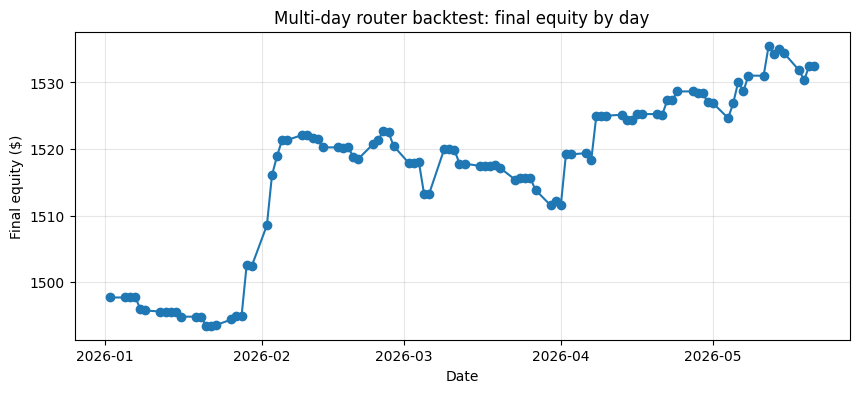


Daily risk events:


,date,selected_branch,risk_profile,time,event,equity,lookback_equity,portfolio_neg_recent_return,portfolio_neg_loss_per_min,tdist_ready,...,portfolio_spike_trigger_recent_return,portfolio_spike_trigger_profit_per_min,giveback_trigger,tdist_positive_recovery,recovery_t_right_prob,day_return_from_start,daily_drawdown,pause_count,cooldown_until,ticker
0,2026-01-02,MAY22_DEFENSIVE,LOW_RISK,2026-01-02 10:32:00-05:00,portfolio_negative_spike_warning,1498.738441,1500.000000,-0.000841,-0.000280,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,2026-01-02,MAY22_DEFENSIVE,LOW_RISK,2026-01-02 10:33:00-05:00,portfolio_negative_failed_recovery_stop,1497.783166,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2,2026-01-05,MAY22_DEFENSIVE,LOW_RISK,2026-01-05 12:11:00-05:00,portfolio_negative_spike_warning,1497.705067,1497.716774,-0.000008,-0.000003,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
3,2026-01-05,MAY22_DEFENSIVE,LOW_RISK,2026-01-05 12:12:00-05:00,portfolio_spike_lock_armed,1497.724070,1497.716774,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
4,2026-01-05,MAY22_DEFENSIVE,LOW_RISK,2026-01-05 12:16:00-05:00,portfolio_negative_failed_recovery_stop,1497.725337,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,2026-05-18,MAY22_DEFENSIVE,LOW_RISK,2026-05-18 10:49:00-04:00,portfolio_spike_lock_armed,1535.179089,1534.424049,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
186,2026-05-18,MAY22_DEFENSIVE,LOW_RISK,2026-05-18 10:51:00-04:00,portfolio_negative_failed_recovery_stop,1531.958215,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
187,2026-05-19,MAY22_DEFENSIVE,LOW_RISK,2026-05-19 10:27:00-04:00,portfolio_negative_spike_warning,1529.863264,1531.821490,-0.001278,-0.000426,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
188,2026-05-19,MAY22_DEFENSIVE,LOW_RISK,2026-05-19 10:28:00-04:00,portfolio_negative_failed_recovery_stop,1530.430063,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN



PnL attribution summary:


,date,selected_branch,pnl_bucket,realised_pnl
0,2026-01-02,MAY22_DEFENSIVE,inverse_etf,-2.283226
1,2026-01-02,MAY22_DEFENSIVE,stocks,NaN
2,2026-01-05,MAY22_DEFENSIVE,forced_exit,0.001070
3,2026-01-05,MAY22_DEFENSIVE,stocks,NaN
4,2026-01-06,MAY21_AGGRESSIVE,forced_exit,-1.908682
...,...,...,...,...
151,2026-05-18,MAY22_DEFENSIVE,stocks,NaN
152,2026-05-19,MAY22_DEFENSIVE,inverse_etf,-1.459664
153,2026-05-19,MAY22_DEFENSIVE,stocks,NaN
154,2026-05-20,MAY21_AGGRESSIVE,forced_exit,-0.319264


In [ ]:
# ============================================================
# MULTI-DAY ROUTER DIAGNOSTIC CELL
# ============================================================

print("Last selected branch:", LAST_SELECTED_BRANCH)
print("Global absolute max equity:", f"${GLOBAL_ABSOLUTE_MAX_EQUITY:,.2f}")

if "daily_summary_df" in globals() and not daily_summary_df.empty:
    print("\nDaily summary:")
    display(daily_summary_df)
else:
    print("No daily_summary_df found or no completed days.")

if "day_error_log_df" in globals() and not day_error_log_df.empty:
    print("\nDays with errors/skips:")
    display(day_error_log_df)

if "combined_trades_df" in globals() and not combined_trades_df.empty:
    print("\nCombined trade log rows:", len(combined_trades_df))
    display(combined_trades_df.head(30))
else:
    print("\nNo combined trades found.")

if "combined_equity_df" in globals() and not combined_equity_df.empty:
    print("\nCombined equity curve tail:")
    display(combined_equity_df.tail(20))
else:
    print("\nNo combined equity curve found.")

# Optional quick plot of final equity by day.
if "daily_summary_df" in globals() and not daily_summary_df.empty:
    import matplotlib.pyplot as plt
    ax = daily_summary_df.plot(x="date", y="final_equity", marker="o", figsize=(10, 4), legend=False)
    ax.set_title("Multi-day router backtest: final equity by day")
    ax.set_xlabel("Date")
    ax.set_ylabel("Final equity ($)")
    plt.grid(True, alpha=0.3)
    plt.show()



print("\nDaily risk events:")
if "combined_daily_risk_events_df" in globals() and not combined_daily_risk_events_df.empty:
    display(combined_daily_risk_events_df)
else:
    print("No daily risk events recorded.")


print("\nPnL attribution summary:")
if "pnl_summary_df" in globals() and not pnl_summary_df.empty:
    display(pnl_summary_df)
else:
    print("No PnL attribution rows.")
